In [1]:
import pickle as pkl

with open('/mnt/compneuro/stroke_clinical_and_neural_data_with_lesion_disconnectome.pkl', 'rb') as f:
    stroke_csv = pkl.load(f)


In [2]:
stroke_csv.columns.values

array(['ID', 'Session', 'Run', 'Eyes', 'corrmats', 'gradient_corrmat',
       'lambda_corrmats', 'mean_corrmats', 'gradient_corrmat_mean',
       'lambda_corrmats_mean', 'corrmats_corrected',
       'gradient_corrmat_corrected', 'mean_corrmats_corrected',
       'gradient_corrmat_corrected_mean',
       'lambda_corrmats_corrected_mean', 'subj_type', 'inclusion_notes',
       'lesion_side', 'acute_beh', 'acute_scan', 'three_m_beh',
       'three_m_scan', 'one_y_beh', 'one_y_scan', 'v1_beh', 'v1_scan',
       'v2_beh', 'v2_scan', 'age', 'ethnicity', 'race', 'gender',
       'education', 'handed', 'smoke', 'neuro_pmh___0', 'neuro_pmh___1',
       'neuro_pmh___2', 'neuro_pmh___3', 'psy_pmh___0', 'psy_pmh___1',
       'psy_pmh___2', 'psy_pmh___3', 'psy_pmh___4', 'cardio_pmh___0',
       'cardio_pmh___1', 'cardio_pmh___2', 'cardio_pmh___3',
       'cardio_pmh___4', 'cardio_pmh___5', 'dm', 'vision_pmh___0',
       'vision_pmh___1', 'vision_pmh___2', 'vision_pmh___3',
       'date_stroke', 'tp

In [4]:
# Rows with missing subj_type
nan_rows = stroke_csv[stroke_csv['subj_type'].isna()]

# Pick ID + 5 example columns
cols_to_show = ['ID', 'Session', 'Run', 'age', 'gender', 'lesion_side']

print(nan_rows[cols_to_show])

        ID   Session            Run  age  gender  lesion_side
91  PAT046     acute  0-1-2-3-4-5-6  NaN     NaN          NaN
92  PAT046  followup  0-1-2-3-4-5-6  NaN     NaN          NaN


In [5]:
nan_rows = stroke_csv[stroke_csv['subj_type'].isna()]

cols = ['ID'] + list(stroke_csv.columns[1:6])
print(nan_rows[cols])

        ID   Session            Run Eyes  \
91  PAT046     acute  0-1-2-3-4-5-6        
92  PAT046  followup  0-1-2-3-4-5-6        

                                             corrmats  \
91  [[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [0.6435...   
92  [[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [0.4453...   

                                     gradient_corrmat  
91  [[[-0.05524670803258602, -0.04752409156976191,...  
92  [[[-0.04479903507333198, -0.06985669133086775,...  


CLEAN RSA ANALYSIS FOR OPUS GRANT

Acute stroke patients: N=138

EXTRACTING RSA FEATURES

Extracted RSA features: N=137 patients

RSA feature summary:
  RSA_both_var             : 137 valid, mean=   0.134, sd=   0.081
  RSA_both_ac1             : 137 valid, mean=   0.610, sd=   0.142
  RSA_both_spec_entropy    : 137 valid, mean=   3.285, sd=   0.467
  RSA_LR_corr              : 137 valid, mean=   0.875, sd=   0.076

CORRELATION ANALYSIS

Clinical outcomes availability (BEFORE filtering):
  nih_total                : 109 patients, mean=   4.02, range=[0.00, 16.00]
  lesion_volume_mm3        : 117 patients, mean=33642.74, range=[96.00, 277016.00]
  mes_tot_miss             : 134 patients, mean=   9.21, range=[0.00, 60.00]
  mes_coc                  : 133 patients, mean=   0.04, range=[-0.28, 0.92]
  bit_tot_miss             : 136 patients, mean=   4.32, range=[0.00, 45.00]
  bit_coc                  : 136 patients, mean=   0.04, range=[-0.09, 0.93]
  pos_acc_avg              : 114 patien

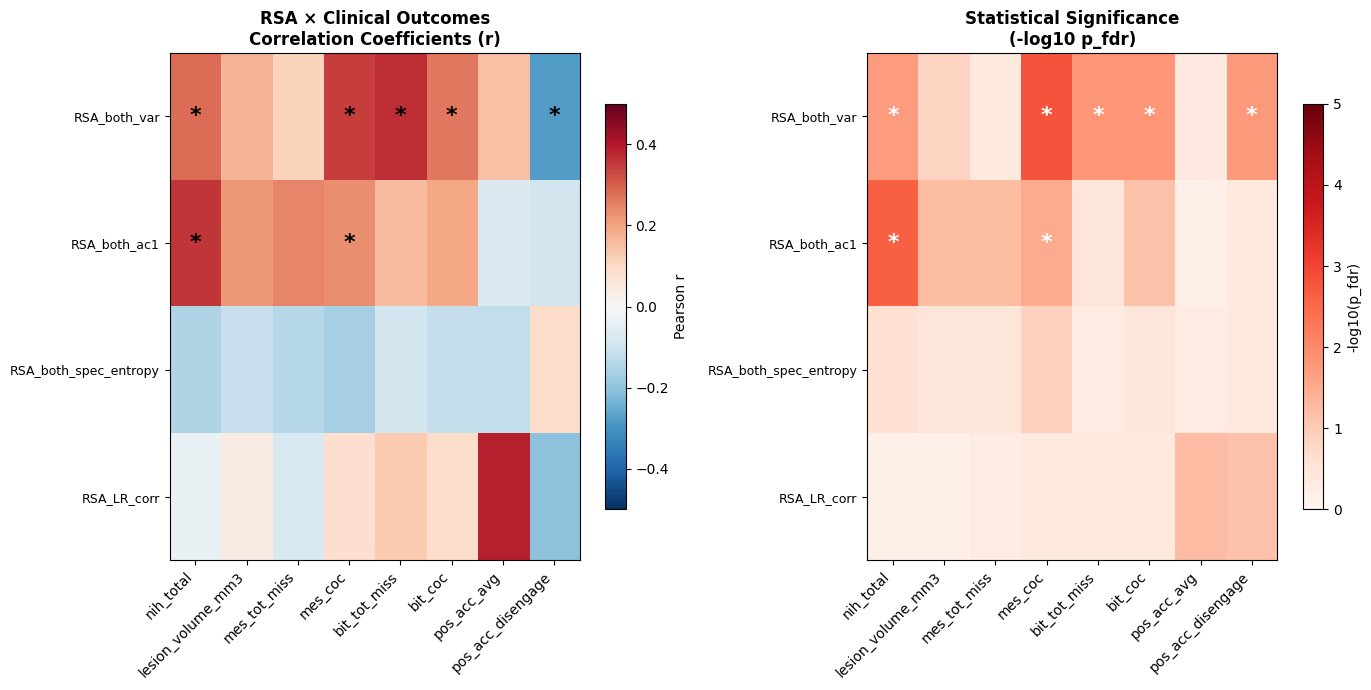

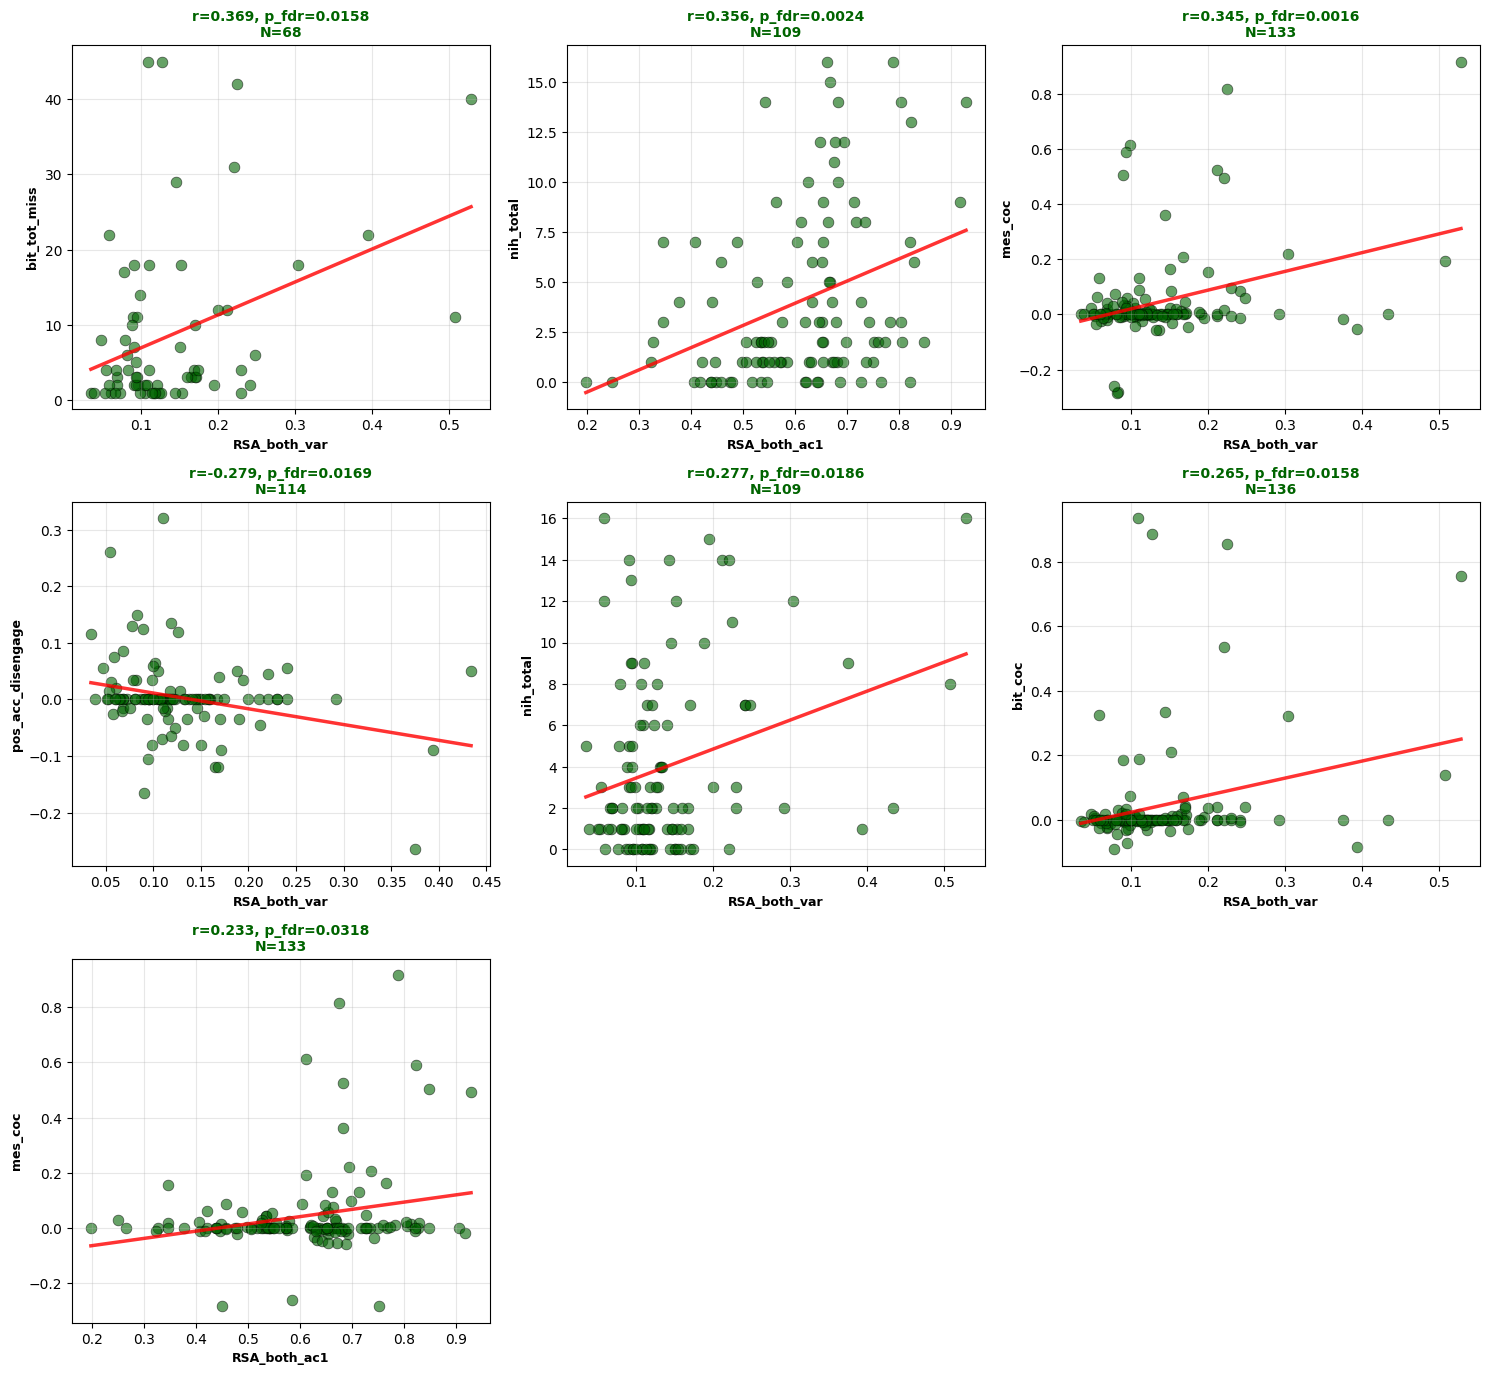

In [68]:
import pandas as pd
import numpy as np
import pickle as pkl
from scipy import stats, signal
from scipy.stats import false_discovery_control
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# FEATURE EXTRACTION FUNCTIONS
# ============================================================

def compute_variance(timeseries):
    """Variance of timeseries"""
    if len(timeseries) < 2:
        return np.nan
    return np.var(timeseries)

def compute_ac1(timeseries):
    """Lag-1 autocorrelation"""
    if len(timeseries) < 2:
        return np.nan
    return np.corrcoef(timeseries[:-1], timeseries[1:])[0, 1]

def compute_mssd(timeseries):
    """Mean squared successive difference"""
    if len(timeseries) < 2:
        return np.nan
    diff = np.diff(timeseries)
    return np.mean(diff**2)

def compute_spectral_entropy(timeseries):
    """Spectral entropy from power spectral density"""
    if len(timeseries) < 10:
        return np.nan
    try:
        freqs, psd = signal.periodogram(timeseries, fs=1.0)
        psd_norm = psd / (psd.sum() + 1e-10)
        entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-10))
        return entropy
    except:
        return np.nan

def extract_rsa_features(rsa_left, rsa_right):
    """
    Extract RSA features from left and right eye timeseries.
    
    Returns both COMBINED features and ASYMMETRY metrics.
    """
    # Clean data
    left = np.array(rsa_left).flatten()
    right = np.array(rsa_right).flatten()
    left = left[~np.isnan(left)]
    right = right[~np.isnan(right)]
    
    if len(left) < 10 or len(right) < 10:
        return None
    
    # Combine both eyes (concatenate)
    both = np.concatenate([left, right])
    
    # Features from BOTH eyes combined
    features = {
        'RSA_both_var': compute_variance(both),
        #'RSA_both_sd': np.std(both),
        #'RSA_both_mssd': compute_mssd(both),
        'RSA_both_ac1': compute_ac1(both),
        'RSA_both_spec_entropy': compute_spectral_entropy(both),
    }
    
    # Asymmetry metrics (L-R differences)
    #features['RSA_asym_diff'] = np.mean(left) - np.mean(right)
    #features['RSA_asym_euclidean'] = np.sqrt(np.sum((left[:min(len(left), len(right))] - 
                                                       #right[:min(len(left), len(right))])**2))
    
    # L-R correlation
    min_len = min(len(left), len(right))
    features['RSA_LR_corr'] = np.corrcoef(left[:min_len], right[:min_len])[0, 1]
    
    return features

# ============================================================
# LOAD DATA
# ============================================================
print("="*60)
print("CLEAN RSA ANALYSIS FOR OPUS GRANT")
print("="*60)

with open('/mnt/compneuro/stroke_data_with_oculomotor_features_fixed.pkl', 'rb') as f:
    df = pd.DataFrame(pkl.load(f))

# Filter to acute stroke patients
acute = df[(df['Session'] == 'acute') & (df['subj_type'] == 0)].copy()
print(f"\nAcute stroke patients: N={len(acute)}")

# ============================================================
# EXTRACT RSA FEATURES
# ============================================================
print("\n" + "="*60)
print("EXTRACTING RSA FEATURES")
print("="*60)

rsa_data = []

for idx, row in acute.iterrows():
    if 'RSA_left' not in row or 'RSA_right' not in row:
        continue
    
    rsa_left = row['RSA_left']
    rsa_right = row['RSA_right']
    
    if rsa_left is None or rsa_right is None:
        continue
    
    features = extract_rsa_features(rsa_left, rsa_right)
    
    if features is not None:
        features['ID'] = row['ID']
        features['nih_total'] = row.get('nih_total')
        features['lesion_volume_mm3'] = row.get('lesion_volume_mm3')
        features['mes_tot_miss'] = row.get('mes_tot_miss')
        features['mes_coc'] = row.get('mes_coc')
        features['bit_tot_miss'] = row.get('bit_tot_miss')
        features['bit_coc'] = row.get('bit_coc')
        features['pos_acc_avg'] = row.get('pos_acc_avg')
        #features['pos_acc_vf'] = row.get('pos_acc_vf')
        features['pos_acc_disengage'] = row.get('pos_acc_disengage')
        rsa_data.append(features)

rsa_df = pd.DataFrame(rsa_data)
print(f"\nExtracted RSA features: N={len(rsa_df)} patients")

# Check feature availability
print("\nRSA feature summary:")
for col in rsa_df.columns:
    if col.startswith('RSA_'):
        n_valid = rsa_df[col].notna().sum()
        mean_val = rsa_df[col].mean()
        std_val = rsa_df[col].std()
        print(f"  {col:25s}: {n_valid:3d} valid, mean={mean_val:8.3f}, sd={std_val:8.3f}")

# ============================================================
# CORRELATION ANALYSIS (WITH FILTERING)
# ============================================================
print("\n" + "="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# RSA features
RSA_FEATURES = [col for col in rsa_df.columns if col.startswith('RSA_')]

# Clinical outcomes (expanded)
CLINICAL_OUTCOMES = [
    'nih_total',
    'lesion_volume_mm3',
    'mes_tot_miss',
    'mes_coc',
    'bit_tot_miss',
    'bit_coc',
    'pos_acc_avg',
    #'pos_acc_vf',
    'pos_acc_disengage',
]

# Define filters for each outcome
OUTCOME_FILTERS = {
    'nih_total': lambda df: df[df['nih_total'] >= 0],
    'lesion_volume_mm3': lambda df: df[df['lesion_volume_mm3'] >= 0],
    'mes_tot_miss': lambda df: df[df['mes_tot_miss'] > 0],  # Has neglect
    'bit_tot_miss': lambda df: df[df['bit_tot_miss'] > 0],  # Has neglect
    'mes_coc': lambda df: df[df['mes_coc'].abs() >= 0 ],  # No filter (bidirectional bias measure)
    'bit_coc': lambda df: df[df['bit_coc'].abs() >=0 ],  # No filter (bidirectional bias measure)
    'pos_acc_avg': lambda df: df[df['pos_acc_avg'] < 0.95],  # Below ceiling
    #'pos_acc_vf': lambda df: df,  # Effect measure (can be positive/negative)
    'pos_acc_disengage': lambda df: df[df['pos_acc_disengage'].abs() >= 0 ],  # Effect measure (can be positive/negative)
}

# Check availability BEFORE filtering
print(f"\nClinical outcomes availability (BEFORE filtering):")
for outcome in CLINICAL_OUTCOMES:
    n = rsa_df[outcome].notna().sum()
    if n > 0:
        mean_val = rsa_df[outcome].mean()
        min_val = rsa_df[outcome].min()
        max_val = rsa_df[outcome].max()
        print(f"  {outcome:25s}: {n:3d} patients, mean={mean_val:7.2f}, range=[{min_val:.2f}, {max_val:.2f}]")
    else:
        print(f"  {outcome:25s}: {n:3d} patients (no data)")

# Compute correlations WITH FILTERING
results = []

for rsa_feat in RSA_FEATURES:
    for outcome in CLINICAL_OUTCOMES:
        # Get valid data
        valid = rsa_df[[rsa_feat, outcome]].dropna()
        
        # Apply outcome-specific filter
        if outcome in OUTCOME_FILTERS:
            valid = OUTCOME_FILTERS[outcome](valid)
        
        if len(valid) >= 10:
            r, p = stats.pearsonr(valid[rsa_feat], valid[outcome])
            results.append({
                'RSA_feature': rsa_feat,
                'outcome': outcome,
                'r': r,
                'abs_r': abs(r),
                'p': p,
                'n': len(valid)
            })

results_df = pd.DataFrame(results)

# FDR correction
results_df['p_fdr'] = false_discovery_control(results_df['p'].values)
results_df['significant_fdr'] = results_df['p_fdr'] < 0.05

print(f"\nTotal correlations computed: {len(results_df)}")
print(f"Significant (FDR q<0.05): {results_df['significant_fdr'].sum()}")

# ============================================================
# DISPLAY RESULTS BY OUTCOME
# ============================================================
print("\n" + "="*60)
print("CORRELATION RESULTS BY OUTCOME")
print("="*60)

for outcome in CLINICAL_OUTCOMES:
    subset = results_df[results_df['outcome']==outcome].sort_values('abs_r', ascending=False)
    
    if len(subset) > 0:
        print(f"\n--- {outcome} ---")
        n_sig = subset['significant_fdr'].sum()
        print(f"Significant: {n_sig}/{len(subset)}")
        
        # Show top 3
        for idx, row in subset.head(3).iterrows():
            sig_marker = "**" if row['significant_fdr'] else "ns"
            print(f"  {row['RSA_feature']:30s}  r={row['r']:6.3f}  p_fdr={row['p_fdr']:.4f}  N={row['n']:3d}  {sig_marker}")

# ============================================================
# VISUALIZATION: CORRELATION HEATMAP
# ============================================================
print("\n" + "="*60)
print("CREATING CORRELATION HEATMAP")
print("="*60)

# Create matrices
corr_matrix = np.zeros((len(RSA_FEATURES), len(CLINICAL_OUTCOMES)))
p_matrix = np.ones((len(RSA_FEATURES), len(CLINICAL_OUTCOMES)))

for i, rsa_feat in enumerate(RSA_FEATURES):
    for j, outcome in enumerate(CLINICAL_OUTCOMES):
        row = results_df[(results_df['RSA_feature']==rsa_feat) & 
                         (results_df['outcome']==outcome)]
        if len(row) > 0:
            corr_matrix[i, j] = row.iloc[0]['r']
            p_matrix[i, j] = row.iloc[0]['p_fdr']

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: Correlations
im1 = axes[0].imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-0.5, vmax=0.5)
axes[0].set_xticks(range(len(CLINICAL_OUTCOMES)))
axes[0].set_yticks(range(len(RSA_FEATURES)))
axes[0].set_xticklabels(CLINICAL_OUTCOMES, rotation=45, ha='right', fontsize=10)
axes[0].set_yticklabels(RSA_FEATURES, fontsize=9)
axes[0].set_title('RSA × Clinical Outcomes\nCorrelation Coefficients (r)', fontsize=12, fontweight='bold')

# Mark significant
for i in range(len(RSA_FEATURES)):
    for j in range(len(CLINICAL_OUTCOMES)):
        if p_matrix[i, j] < 0.05:
            axes[0].text(j, i, '*', ha='center', va='center',
                        color='black', fontsize=16, fontweight='bold')

plt.colorbar(im1, ax=axes[0], label='Pearson r', shrink=0.8)

# Right: Significance
log_p = -np.log10(p_matrix + 1e-300)
log_p[log_p > 5] = 5

im2 = axes[1].imshow(log_p, cmap='Reds', aspect='auto', vmin=0, vmax=5)
axes[1].set_xticks(range(len(CLINICAL_OUTCOMES)))
axes[1].set_yticks(range(len(RSA_FEATURES)))
axes[1].set_xticklabels(CLINICAL_OUTCOMES, rotation=45, ha='right', fontsize=10)
axes[1].set_yticklabels(RSA_FEATURES, fontsize=9)
axes[1].set_title('Statistical Significance\n(-log10 p_fdr)', fontsize=12, fontweight='bold')

for i in range(len(RSA_FEATURES)):
    for j in range(len(CLINICAL_OUTCOMES)):
        if p_matrix[i, j] < 0.05:
            axes[1].text(j, i, '*', ha='center', va='center',
                        color='white', fontsize=16, fontweight='bold')

plt.colorbar(im2, ax=axes[1], label='-log10(p_fdr)', shrink=0.8)

plt.tight_layout()
plt.savefig('/mnt/compneuro/rsa_full_correlations_heatmap.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: rsa_full_correlations_heatmap.png")

# ============================================================
# SCATTERPLOTS: TOP 12 SIGNIFICANT CORRELATIONS
# ============================================================
print("\n" + "="*60)
print("CREATING SCATTERPLOTS")
print("="*60)

sig_results = results_df[results_df['significant_fdr']].sort_values('abs_r', ascending=False)

if len(sig_results) > 0:
    print(f"\n{len(sig_results)} significant correlations - plotting top 12")
    
    top_sig = sig_results.head(12)
    
    fig, axes = plt.subplots(4, 3, figsize=(15, 18))
    axes = axes.flatten()
    
    for i, (idx, row) in enumerate(top_sig.iterrows()):
        ax = axes[i]
        
        rsa_feat = row['RSA_feature']
        outcome = row['outcome']
        
        # Get data and apply filter
        valid = rsa_df[[rsa_feat, outcome]].dropna()
        if outcome in OUTCOME_FILTERS:
            valid = OUTCOME_FILTERS[outcome](valid)
        
        x = valid[rsa_feat]
        y = valid[outcome]
        
        # Scatter
        ax.scatter(x, y, alpha=0.6, s=60, color='darkgreen', edgecolors='black', linewidth=0.5)
        
        # Fit line
        z = np.polyfit(x, y, 1)
        p_fit = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, p_fit(x_line), "r-", alpha=0.8, linewidth=2.5)
        
        # Labels
        ax.set_xlabel(rsa_feat, fontsize=9, fontweight='bold')
        ax.set_ylabel(outcome, fontsize=9, fontweight='bold')
        ax.set_title(f"r={row['r']:.3f}, p_fdr={row['p_fdr']:.4f}\nN={row['n']}", 
                    fontsize=10, fontweight='bold', color='darkgreen')
        ax.grid(alpha=0.3)
    
    # Hide unused
    for i in range(len(top_sig), 12):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('/mnt/compneuro/rsa_top12_significant_scatterplots.png', dpi=300, bbox_inches='tight')
    print(f"✅ Saved: rsa_top12_significant_scatterplots.png")
else:
    print("No significant correlations found")

# ============================================================
# SAVE RESULTS
# ============================================================
results_df.to_csv('/mnt/compneuro/rsa_full_correlation_results.csv', index=False)
rsa_df.to_csv('/mnt/compneuro/rsa_features_with_visual_battery.csv', index=False)

print(f"\n✅ Saved: rsa_full_correlation_results.csv")
print(f"✅ Saved: rsa_features_with_visual_battery.csv")

print("\n" + "="*60)
print("COMPLETE RSA ANALYSIS")
print("="*60)
print(f"\nFilters applied:")
print(f"  nih_total: > 2")
print(f"  lesion_volume_mm3: >= 1000")
print(f"  mes_tot_miss: > 0 (has neglect)")
print(f"  bit_tot_miss: > 0 (has neglect)")
print(f"  pos_acc_avg: < 0.95 (below ceiling)")
print(f"  COC & effect measures: no filter")
print(f"\nGenerated files:")
print(f"  1. rsa_full_correlations_heatmap.png")
print(f"  2. rsa_top12_significant_scatterplots.png")
print("="*60)

RECOVERY PREDICTION: FINAL NIHSS (CORRECT DESIGN)

Sample sizes:
  Acute:   138 patients
  3-month: 103 patients
  1-year:  87 patients

BUILDING DATASETS (Outcome = FINAL NIHSS)

3-month: 97 matched patients

1-year: 74 matched patients

Outcome statistics:

3-month (N=76):
  NIHSS acute:  3.24 ± 3.51
  NIHSS 3-mo:   2.20 ± 2.88
  Change:       -1.04

1-year (N=58):
  NIHSS acute:  3.34 ± 3.57
  NIHSS 1-yr:   1.81 ± 2.78
  Change:       -1.53

TESTING EACH RSA FEATURE (Predicting FINAL NIHSS)

--- 3-MONTH OUTCOME ---
RSA_both_var               Base R²=0.123  Full R²=0.122  ΔR²=-0.001  p=0.5020  ns
RSA_both_sd                Base R²=0.123  Full R²=0.130  ΔR²=+0.007  p=0.4232  ns
RSA_both_mssd              Base R²=0.123  Full R²=0.113  ΔR²=-0.010  p=0.1807  ns
RSA_both_ac1               Base R²=0.123  Full R²=0.108  ΔR²=-0.015  p=0.1326  ns
RSA_both_spec_entropy      Base R²=0.123  Full R²=0.047  ΔR²=-0.076  p=0.3105  ns
RSA_asym_diff              Base R²=0.123  Full R²=0.039  ΔR²=-0.08

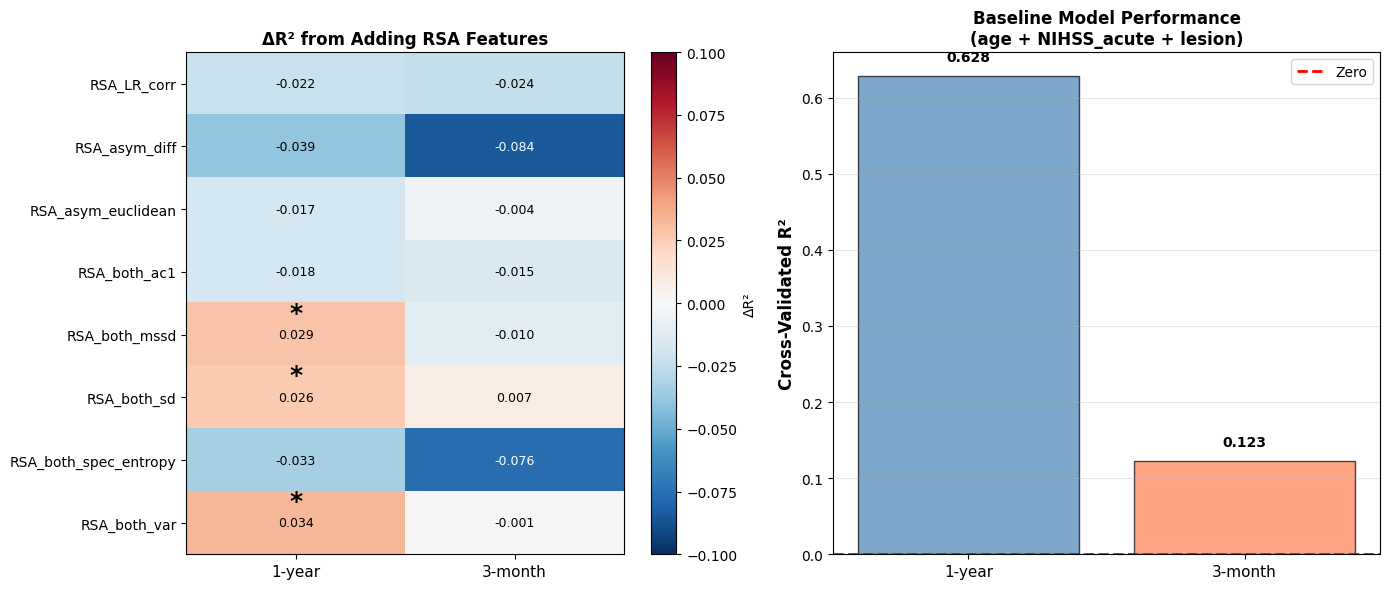

In [72]:
import pandas as pd
import numpy as np
import pickle as pkl
from scipy import stats, signal
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# FEATURE EXTRACTION FUNCTIONS
# ============================================================

def compute_variance(timeseries):
    if len(timeseries) < 2:
        return np.nan
    return np.var(timeseries)

def compute_ac1(timeseries):
    if len(timeseries) < 2:
        return np.nan
    return np.corrcoef(timeseries[:-1], timeseries[1:])[0, 1]

def compute_mssd(timeseries):
    if len(timeseries) < 2:
        return np.nan
    diff = np.diff(timeseries)
    return np.mean(diff**2)

def compute_spectral_entropy(timeseries):
    if len(timeseries) < 10:
        return np.nan
    try:
        freqs, psd = signal.periodogram(timeseries, fs=1.0)
        psd_norm = psd / (psd.sum() + 1e-10)
        entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-10))
        return entropy
    except:
        return np.nan

def extract_rsa_features(rsa_left, rsa_right):
    left = np.array(rsa_left).flatten()
    right = np.array(rsa_right).flatten()
    left = left[~np.isnan(left)]
    right = right[~np.isnan(right)]
    
    if len(left) < 10 or len(right) < 10:
        return None
    
    both = np.concatenate([left, right])
    min_len = min(len(left), len(right))
    
    features = {
        'RSA_both_var': compute_variance(both),
        'RSA_both_sd': np.std(both),
        'RSA_both_mssd': compute_mssd(both),
        'RSA_both_ac1': compute_ac1(both),
        'RSA_both_spec_entropy': compute_spectral_entropy(both),
        'RSA_asym_diff': np.mean(left) - np.mean(right),
        'RSA_asym_euclidean': np.sqrt(np.sum((left[:min_len] - right[:min_len])**2)),
        'RSA_LR_corr': np.corrcoef(left[:min_len], right[:min_len])[0, 1]
    }
    return features

# ============================================================
# LOAD DATA
# ============================================================
print("="*70)
print("RECOVERY PREDICTION: FINAL NIHSS (CORRECT DESIGN)")
print("="*70)

with open('/mnt/compneuro/stroke_data_with_oculomotor_features_fixed.pkl', 'rb') as f:
    df = pd.DataFrame(pkl.load(f))

patients = df[df['subj_type'] == 0].copy()
acute = patients[patients['Session'] == 'acute']
followup_3mo = patients[patients['Session'] == 'followup']
followup_1yr = patients[patients['Session'] == 'followup2']

print(f"\nSample sizes:")
print(f"  Acute:   {len(acute)} patients")
print(f"  3-month: {len(followup_3mo)} patients")
print(f"  1-year:  {len(followup_1yr)} patients")

# ============================================================
# BUILD DATASETS - PREDICT FINAL STATE
# ============================================================
print("\n" + "="*70)
print("BUILDING DATASETS (Outcome = FINAL NIHSS)")
print("="*70)

def build_dataset(acute_df, followup_df, timepoint_name):
    """Build dataset to predict FINAL NIHSS (not change)"""
    data = []
    
    ids_acute = set(acute_df['ID'])
    ids_followup = set(followup_df['ID'])
    ids_matched = ids_acute & ids_followup
    
    print(f"\n{timepoint_name}: {len(ids_matched)} matched patients")
    
    for patient_id in ids_matched:
        acute_row = acute_df[acute_df['ID'] == patient_id].iloc[0]
        followup_row = followup_df[followup_df['ID'] == patient_id].iloc[0]
        
        # Extract RSA features at acute
        rsa_features = extract_rsa_features(acute_row.get('RSA_left'), 
                                            acute_row.get('RSA_right'))
        
        if rsa_features is None:
            continue
        
        # Baseline predictors
        age = acute_row.get('age')
        nih_acute = acute_row.get('nih_total')
        lesion_vol = acute_row.get('lesion_volume_mm3')
        
        # OUTCOME: Final NIHSS (not change!)
        nih_final = followup_row.get('nih_total')
        
        if pd.isna(nih_acute) or pd.isna(nih_final):
            continue
        
        # Store
        row_data = {
            'ID': patient_id,
            'age': age,
            'nih_total_acute': nih_acute,
            'lesion_volume_mm3': lesion_vol,
            'nih_total_final': nih_final,  # OUTCOME
            **rsa_features
        }
        data.append(row_data)
    
    return pd.DataFrame(data)

# Build datasets
data_3mo = build_dataset(acute, followup_3mo, "3-month")
data_1yr = build_dataset(acute, followup_1yr, "1-year")

print(f"\nOutcome statistics:")
print(f"\n3-month (N={len(data_3mo)}):")
print(f"  NIHSS acute:  {data_3mo['nih_total_acute'].mean():.2f} ± {data_3mo['nih_total_acute'].std():.2f}")
print(f"  NIHSS 3-mo:   {data_3mo['nih_total_final'].mean():.2f} ± {data_3mo['nih_total_final'].std():.2f}")
print(f"  Change:       {(data_3mo['nih_total_final'] - data_3mo['nih_total_acute']).mean():.2f}")

print(f"\n1-year (N={len(data_1yr)}):")
print(f"  NIHSS acute:  {data_1yr['nih_total_acute'].mean():.2f} ± {data_1yr['nih_total_acute'].std():.2f}")
print(f"  NIHSS 1-yr:   {data_1yr['nih_total_final'].mean():.2f} ± {data_1yr['nih_total_final'].std():.2f}")
print(f"  Change:       {(data_1yr['nih_total_final'] - data_1yr['nih_total_acute']).mean():.2f}")

# ============================================================
# PREDICTION FUNCTION
# ============================================================

def test_rsa_feature(data, rsa_feature, timepoint_name):
    """Test single RSA feature as predictor of FINAL NIHSS"""
    
    # Base predictors
    base_predictors = ['age', 'nih_total_acute', 'lesion_volume_mm3']
    outcome = 'nih_total_final'  # FINAL STATE, NOT CHANGE
    
    # Complete data
    predictors_full = base_predictors + [rsa_feature]
    data_complete = data[predictors_full + [outcome]].dropna()
    
    if len(data_complete) < 20:
        return None
    
    # Prepare data
    X_base = data_complete[base_predictors].values
    X_rsa = data_complete[[rsa_feature]].values
    X_full = np.hstack([X_base, X_rsa])
    y = data_complete[outcome].values
    
    # Standardize
    scaler_base = StandardScaler()
    scaler_rsa = StandardScaler()
    X_base_scaled = scaler_base.fit_transform(X_base)
    X_rsa_scaled = scaler_rsa.fit_transform(X_rsa)
    X_full_scaled = np.hstack([X_base_scaled, X_rsa_scaled])
    
    # Cross-validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    r2_base_cv = cross_val_score(LinearRegression(), X_base_scaled, y, 
                                   cv=cv, scoring='r2')
    r2_full_cv = cross_val_score(LinearRegression(), X_full_scaled, y, 
                                   cv=cv, scoring='r2')
    
    # Fit models
    model_base = LinearRegression().fit(X_base_scaled, y)
    model_full = LinearRegression().fit(X_full_scaled, y)
    
    # Training R² (for comparison)
    y_pred_base_train = model_base.predict(X_base_scaled)
    y_pred_full_train = model_full.predict(X_full_scaled)
    r2_base_train = 1 - np.sum((y - y_pred_base_train)**2) / np.sum((y - y.mean())**2)
    r2_full_train = 1 - np.sum((y - y_pred_full_train)**2) / np.sum((y - y.mean())**2)
    
    # Nested F-test
    rss_base = np.sum((y - y_pred_base_train)**2)
    rss_full = np.sum((y - y_pred_full_train)**2)
    
    n = len(y)
    p_base = len(base_predictors)
    p_full = len(base_predictors) + 1
    
    f_stat = ((rss_base - rss_full) / 1) / (rss_full / (n - p_full - 1))
    p_value = 1 - stats.f.cdf(f_stat, 1, n - p_full - 1)
    
    # RSA coefficient
    rsa_coef = model_full.coef_[-1]
    
    return {
        'timepoint': timepoint_name,
        'rsa_feature': rsa_feature,
        'n': n,
        'r2_base_cv': r2_base_cv.mean(),
        'r2_base_cv_sd': r2_base_cv.std(),
        'r2_full_cv': r2_full_cv.mean(),
        'r2_full_cv_sd': r2_full_cv.std(),
        'r2_base_train': r2_base_train,
        'r2_full_train': r2_full_train,
        'delta_r2': r2_full_cv.mean() - r2_base_cv.mean(),
        'f_stat': f_stat,
        'p_value': p_value,
        'rsa_coef': rsa_coef
    }

# ============================================================
# TEST ALL RSA FEATURES
# ============================================================
print("\n" + "="*70)
print("TESTING EACH RSA FEATURE (Predicting FINAL NIHSS)")
print("="*70)

RSA_FEATURES = [
    'RSA_both_var',
    'RSA_both_sd',
    'RSA_both_mssd',
    'RSA_both_ac1',
    'RSA_both_spec_entropy',
    'RSA_asym_diff',
    'RSA_asym_euclidean',
    'RSA_LR_corr'
]

results = []

# Test 3-month
print("\n--- 3-MONTH OUTCOME ---")
for rsa_feat in RSA_FEATURES:
    result = test_rsa_feature(data_3mo, rsa_feat, "3-month")
    if result is not None:
        results.append(result)
        sig = "**" if result['p_value'] < 0.05 else "ns"
        print(f"{rsa_feat:25s}  Base R²={result['r2_base_cv']:.3f}  Full R²={result['r2_full_cv']:.3f}  ΔR²={result['delta_r2']:+.3f}  p={result['p_value']:.4f}  {sig}")

# Test 1-year
print("\n--- 1-YEAR OUTCOME ---")
for rsa_feat in RSA_FEATURES:
    result = test_rsa_feature(data_1yr, rsa_feat, "1-year")
    if result is not None:
        results.append(result)
        sig = "**" if result['p_value'] < 0.05 else "ns"
        print(f"{rsa_feat:25s}  Base R²={result['r2_base_cv']:.3f}  Full R²={result['r2_full_cv']:.3f}  ΔR²={result['delta_r2']:+.3f}  p={result['p_value']:.4f}  {sig}")

results_df = pd.DataFrame(results)

# ============================================================
# CRITICAL CHECK: Baseline Model Performance
# ============================================================
print("\n" + "="*70)
print("BASELINE MODEL CHECK (Should be POSITIVE now!)")
print("="*70)

baseline_3mo = results_df[results_df['timepoint']=='3-month']['r2_base_cv'].iloc[0]
baseline_1yr = results_df[results_df['timepoint']=='1-year']['r2_base_cv'].iloc[0]

print(f"\n3-month baseline R²: {baseline_3mo:.3f}")
print(f"1-year baseline R²:  {baseline_1yr:.3f}")

if baseline_3mo > 0 and baseline_1yr > 0:
    print(f"\n✅ FIXED! Baseline models now have positive R²")
else:
    print(f"\n⚠️  Still negative - sample/outcome issue persists")

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)

summary_table = results_df.pivot_table(
    index='rsa_feature',
    columns='timepoint',
    values=['r2_base_cv', 'r2_full_cv', 'delta_r2', 'p_value'],
    aggfunc='first'
)

print("\nBaseline R² (age + NIHSS_acute + lesion):")
print(summary_table['r2_base_cv'].to_string())

print("\n\nFull R² (baseline + RSA):")
print(summary_table['r2_full_cv'].to_string())

print("\n\nΔR² (improvement from adding RSA):")
print(summary_table['delta_r2'].to_string())

print("\n\np-values:")
print(summary_table['p_value'].to_string())

# ============================================================
# SIGNIFICANT RESULTS
# ============================================================
sig_results = results_df[results_df['p_value'] < 0.05]

if len(sig_results) > 0:
    print("\n" + "="*70)
    print(f"✅ SIGNIFICANT PREDICTORS (p<0.05): {len(sig_results)}")
    print("="*70)
    
    for idx, row in sig_results.iterrows():
        print(f"\n{row['timepoint']} - {row['rsa_feature']}:")
        print(f"  Baseline R²:     {row['r2_base_cv']:.3f} (train: {row['r2_base_train']:.3f})")
        print(f"  Full R²:         {row['r2_full_cv']:.3f} (train: {row['r2_full_train']:.3f})")
        print(f"  ΔR²:             {row['delta_r2']:+.3f}")
        print(f"  F(1,{row['n']-4}) = {row['f_stat']:.2f}, p = {row['p_value']:.4f}")
else:
    print("\n❌ No significant predictors")

# ============================================================
# VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ΔR² heatmap
pivot_dr2 = results_df.pivot(index='rsa_feature', columns='timepoint', values='delta_r2')
im1 = axes[0].imshow(pivot_dr2.values, cmap='RdBu_r', aspect='auto', vmin=-0.1, vmax=0.1)
axes[0].set_xticks(range(len(pivot_dr2.columns)))
axes[0].set_yticks(range(len(pivot_dr2.index)))
axes[0].set_xticklabels(pivot_dr2.columns, fontsize=11)
axes[0].set_yticklabels(pivot_dr2.index, fontsize=10)
axes[0].set_title('ΔR² from Adding RSA Features', fontsize=12, fontweight='bold')

pivot_p = results_df.pivot(index='rsa_feature', columns='timepoint', values='p_value')
for i in range(len(pivot_dr2.index)):
    for j in range(len(pivot_dr2.columns)):
        val = pivot_dr2.iloc[i, j]
        color = 'white' if abs(val) > 0.05 else 'black'
        axes[0].text(j, i, f'{val:.3f}', ha='center', va='center',
                    color=color, fontsize=9)
        if pivot_p.iloc[i, j] < 0.05:
            axes[0].text(j, i-0.35, '*', ha='center', va='center',
                        color='black', fontsize=18, fontweight='bold')

plt.colorbar(im1, ax=axes[0], label='ΔR²')

# Baseline R² comparison
pivot_base = results_df.pivot(index='rsa_feature', columns='timepoint', values='r2_base_cv')
mean_base = pivot_base.mean()

x = range(len(mean_base))
axes[1].bar(x, mean_base.values, color=['steelblue', 'coral'], alpha=0.7, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(mean_base.index, fontsize=11)
axes[1].set_ylabel('Cross-Validated R²', fontsize=12, fontweight='bold')
axes[1].set_title('Baseline Model Performance\n(age + NIHSS_acute + lesion)', 
                 fontsize=12, fontweight='bold')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2, label='Zero')
axes[1].grid(alpha=0.3, axis='y')
axes[1].legend()

for i, v in enumerate(mean_base.values):
    axes[1].text(i, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/mnt/compneuro/recovery_prediction_final_nihss.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: recovery_prediction_final_nihss.png")

# ============================================================
# SAVE
# ============================================================
results_df.to_csv('/mnt/compneuro/recovery_prediction_final_nihss_results.csv', index=False)
data_3mo.to_csv('/mnt/compneuro/recovery_dataset_3mo_final.csv', index=False)
data_1yr.to_csv('/mnt/compneuro/recovery_dataset_1yr_final.csv', index=False)

print(f"✅ Saved: recovery_prediction_final_nihss_results.csv")

print("\n" + "="*70)
print("ANALYSIS COMPLETE - CORRECT DESIGN")
print("="*70)
print(f"Outcome: FINAL NIHSS (not change)")
print(f"Base model: age + NIHSS_acute + lesion_volume")
print(f"Test: Does RSA add predictive value?")
print("="*70)

GEE ANALYSIS: RSA_both_var PREDICTS RECOVERY (Final)

Original data:
  Acute:   138 patients
  3-month: 103 patients
  1-year:  87 patients

BUILDING LONGITUDINAL DATASET

Longitudinal dataset:
  Total observations: 225
  Unique patients: 105
    acute    (time=0): N= 94, NIHSS=4.34
    3-month  (time=1): N= 71, NIHSS=2.34
    1-year   (time=2): N= 60, NIHSS=1.85

  Patients with 1 obs: 30
  Patients with 2 obs: 30
  Patients with 3 obs: 45

  Sex distribution:
    Female (sex=0): 53 patients
    Male (sex=1):   52 patients

  Baseline characteristics:
    Age:                53.8 ± 10.2 years
    Lesion volume:      36496 ± 53002 mm³
    NIHSS acute:        4.34 ± 4.50
    RSA_both_var:       0.142 ± 0.092

FITTING GEE MODELS (Pre-specified: RSA_both_var only)

Complete data: 225 observations, 105 patients

--- MODEL 1: Baseline (time + age + sex + lesion) ---
  Coefficients:
    Time:   -0.969 (p=0.0000)
    Age:    0.090 (p=0.7848)
    Sex:    -0.191 (p=0.7490)
    Lesion: 2.036 (p=

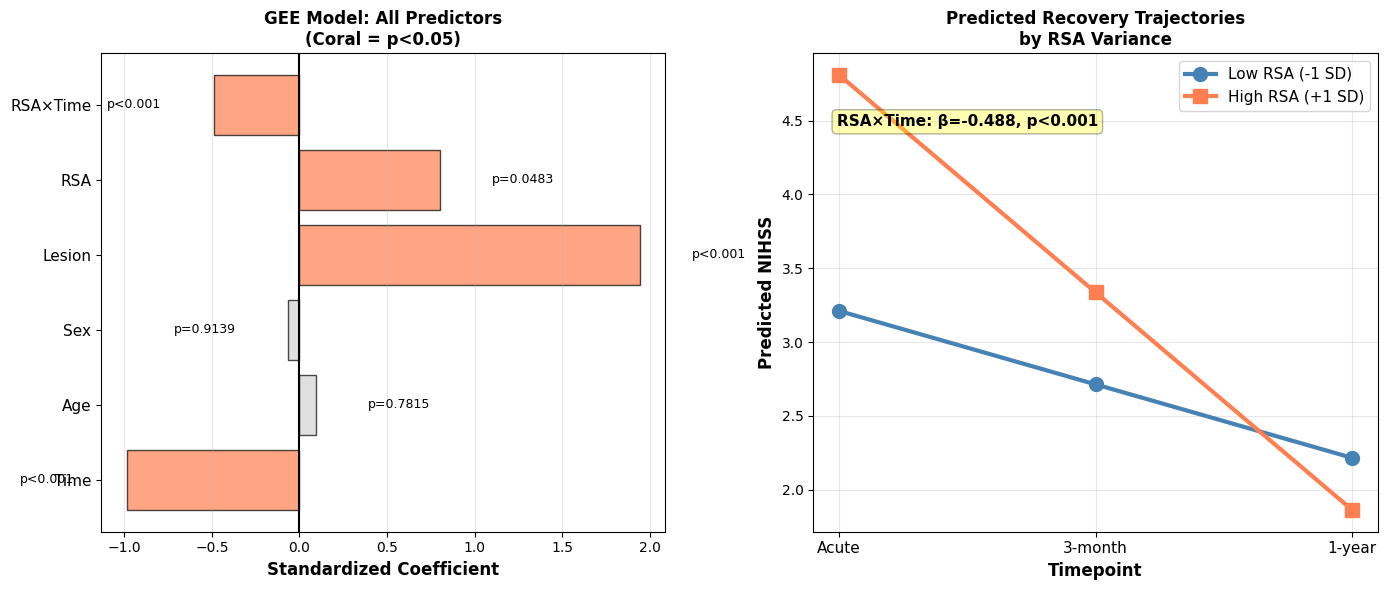

In [85]:
import pandas as pd
import numpy as np
import pickle as pkl
from scipy import stats, signal
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.cov_struct import Exchangeable
from sklearn.preprocessing import StandardScaler

# ============================================================
# FEATURE EXTRACTION
# ============================================================

def compute_variance(timeseries):
    if len(timeseries) < 2:
        return np.nan
    return np.var(timeseries)

def compute_ac1(timeseries):
    if len(timeseries) < 2:
        return np.nan
    return np.corrcoef(timeseries[:-1], timeseries[1:])[0, 1]

def compute_mssd(timeseries):
    if len(timeseries) < 2:
        return np.nan
    diff = np.diff(timeseries)
    return np.mean(diff**2)

def compute_spectral_entropy(timeseries):
    if len(timeseries) < 10:
        return np.nan
    try:
        freqs, psd = signal.periodogram(timeseries, fs=1.0)
        psd_norm = psd / (psd.sum() + 1e-10)
        entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-10))
        return entropy
    except:
        return np.nan

def extract_rsa_features(rsa_left, rsa_right):
    left = np.array(rsa_left).flatten()
    right = np.array(rsa_right).flatten()
    left = left[~np.isnan(left)]
    right = right[~np.isnan(right)]
    
    if len(left) < 10 or len(right) < 10:
        return None
    
    both = np.concatenate([left, right])
    
    features = {
        'RSA_both_var': compute_variance(both),
        'RSA_both_sd': np.std(both),
        'RSA_both_mssd': compute_mssd(both),
        'RSA_both_ac1': compute_ac1(both),
        'RSA_both_spec_entropy': compute_spectral_entropy(both)
    }
    return features

# ============================================================
# LOAD DATA
# ============================================================
print("="*70)
print("GEE ANALYSIS: RSA_both_var PREDICTS RECOVERY (Final)")
print("="*70)

with open('/mnt/compneuro/stroke_data_with_oculomotor_features_fixed.pkl', 'rb') as f:
    df = pd.DataFrame(pkl.load(f))

patients = df[df['subj_type'] == 0].copy()

acute = patients[patients['Session'] == 'acute']
followup_3mo = patients[patients['Session'] == 'followup']
followup_1yr = patients[patients['Session'] == 'followup2']

print(f"\nOriginal data:")
print(f"  Acute:   {len(acute)} patients")
print(f"  3-month: {len(followup_3mo)} patients")
print(f"  1-year:  {len(followup_1yr)} patients")

# ============================================================
# BUILD LONGITUDINAL DATASET
# ============================================================
print("\n" + "="*70)
print("BUILDING LONGITUDINAL DATASET")
print("="*70)

long_data = []

for patient_id in acute['ID'].unique():
    acute_row = acute[acute['ID'] == patient_id].iloc[0]
    
    rsa_features = extract_rsa_features(acute_row.get('RSA_left'), 
                                        acute_row.get('RSA_right'))
    
    if rsa_features is None:
        continue
    
    # Get covariates (time-invariant)
    age = acute_row.get('age')
    sex = acute_row.get('gender')  # Add sex
    lesion_vol = acute_row.get('lesion_volume_mm3')
    
    if pd.isna(age) or pd.isna(lesion_vol) or pd.isna(sex):
        continue
    
    # ACUTE
    nih_acute = acute_row.get('nih_total')
    if pd.notna(nih_acute):
        long_data.append({
            'ID': patient_id,
            'timepoint': 0,
            'time_label': 'acute',
            'nih_total': nih_acute,
            'age': age,
            'sex': sex,
            'lesion_volume_mm3': lesion_vol,
            'RSA_both_var': rsa_features['RSA_both_var']
        })
    
    # 3-MONTH
    followup_3mo_rows = followup_3mo[followup_3mo['ID'] == patient_id]
    if len(followup_3mo_rows) > 0:
        nih_3mo = followup_3mo_rows.iloc[0].get('nih_total')
        if pd.notna(nih_3mo):
            long_data.append({
                'ID': patient_id,
                'timepoint': 1,
                'time_label': '3-month',
                'nih_total': nih_3mo,
                'age': age,
                'sex': sex,
                'lesion_volume_mm3': lesion_vol,
                'RSA_both_var': rsa_features['RSA_both_var']
            })
    
    # 1-YEAR
    followup_1yr_rows = followup_1yr[followup_1yr['ID'] == patient_id]
    if len(followup_1yr_rows) > 0:
        nih_1yr = followup_1yr_rows.iloc[0].get('nih_total')
        if pd.notna(nih_1yr):
            long_data.append({
                'ID': patient_id,
                'timepoint': 2,
                'time_label': '1-year',
                'nih_total': nih_1yr,
                'age': age,
                'sex': sex,
                'lesion_volume_mm3': lesion_vol,
                'RSA_both_var': rsa_features['RSA_both_var']
            })

long_df = pd.DataFrame(long_data)

print(f"\nLongitudinal dataset:")
print(f"  Total observations: {len(long_df)}")
print(f"  Unique patients: {long_df['ID'].nunique()}")

for tp in sorted(long_df['timepoint'].unique()):
    label = long_df[long_df['timepoint']==tp]['time_label'].iloc[0]
    n = len(long_df[long_df['timepoint']==tp])
    mean_nih = long_df[long_df['timepoint']==tp]['nih_total'].mean()
    print(f"    {label:8s} (time={tp}): N={n:3d}, NIHSS={mean_nih:.2f}")

obs_per_patient = long_df.groupby('ID').size()
print(f"\n  Patients with 1 obs: {(obs_per_patient==1).sum()}")
print(f"  Patients with 2 obs: {(obs_per_patient==2).sum()}")
print(f"  Patients with 3 obs: {(obs_per_patient==3).sum()}")

# Sex distribution
sex_counts = long_df.groupby('ID')['sex'].first().value_counts()
print(f"\n  Sex distribution:")
print(f"    Female (sex=0): {sex_counts.get(0, 0)} patients")
print(f"    Male (sex=1):   {sex_counts.get(1, 0)} patients")

# Descriptive statistics
print(f"\n  Baseline characteristics:")
baseline = long_df[long_df['timepoint']==0]
print(f"    Age:                {baseline['age'].mean():.1f} ± {baseline['age'].std():.1f} years")
print(f"    Lesion volume:      {baseline['lesion_volume_mm3'].mean():.0f} ± {baseline['lesion_volume_mm3'].std():.0f} mm³")
print(f"    NIHSS acute:        {baseline['nih_total'].mean():.2f} ± {baseline['nih_total'].std():.2f}")
print(f"    RSA_both_var:       {baseline['RSA_both_var'].mean():.3f} ± {baseline['RSA_both_var'].std():.3f}")

# ============================================================
# FIT GEE MODELS
# ============================================================
print("\n" + "="*70)
print("FITTING GEE MODELS (Pre-specified: RSA_both_var only)")
print("="*70)

# Prepare data
data_complete = long_df[['ID', 'timepoint', 'nih_total', 'age', 'sex',
                         'lesion_volume_mm3', 'RSA_both_var']].dropna()

print(f"\nComplete data: {len(data_complete)} observations, {data_complete['ID'].nunique()} patients")

# Standardize continuous predictors
scaler = StandardScaler()
data_scaled = data_complete.copy()
data_scaled[['age', 'lesion_volume_mm3', 'RSA_both_var']] = scaler.fit_transform(
    data_complete[['age', 'lesion_volume_mm3', 'RSA_both_var']]
)

# Create interaction
data_scaled['rsa_time'] = data_scaled['RSA_both_var'] * data_scaled['timepoint']

# Model 1: Baseline (no RSA)
print("\n--- MODEL 1: Baseline (time + age + sex + lesion) ---")
model_base = GEE.from_formula(
    'nih_total ~ timepoint + age + sex + lesion_volume_mm3',
    groups='ID',
    data=data_scaled,
    cov_struct=Exchangeable(),
    family=sm.families.Gaussian()
)
result_base = model_base.fit()

print(f"  Coefficients:")
print(f"    Time:   {result_base.params['timepoint']:.3f} (p={result_base.pvalues['timepoint']:.4f})")
print(f"    Age:    {result_base.params['age']:.3f} (p={result_base.pvalues['age']:.4f})")
print(f"    Sex:    {result_base.params['sex']:.3f} (p={result_base.pvalues['sex']:.4f})")
print(f"    Lesion: {result_base.params['lesion_volume_mm3']:.3f} (p={result_base.pvalues['lesion_volume_mm3']:.4f})")

# Model 2: Add RSA main effect
print("\n--- MODEL 2: + RSA_both_var (main effect) ---")
model_main = GEE.from_formula(
    'nih_total ~ timepoint + age + sex + lesion_volume_mm3 + RSA_both_var',
    groups='ID',
    data=data_scaled,
    cov_struct=Exchangeable(),
    family=sm.families.Gaussian()
)
result_main = model_main.fit()

print(f"  RSA_both_var: {result_main.params['RSA_both_var']:.3f} (p={result_main.pvalues['RSA_both_var']:.4f})")
if result_main.pvalues['RSA_both_var'] < 0.05:
    print(f"    ✅ SIGNIFICANT: Higher RSA = worse baseline severity")
else:
    print(f"    ns: No baseline association")

# Model 3: Add RSA×time interaction (FULL MODEL)
print("\n--- MODEL 3: + RSA×Time Interaction (FULL) ---")
model_full = GEE.from_formula(
    'nih_total ~ timepoint + age + sex + lesion_volume_mm3 + RSA_both_var + rsa_time',
    groups='ID',
    data=data_scaled,
    cov_struct=Exchangeable(),
    family=sm.families.Gaussian()
)
result_full = model_full.fit()

print(f"  RSA×Time: {result_full.params['rsa_time']:.3f} (p={result_full.pvalues['rsa_time']:.4f})")
if result_full.pvalues['rsa_time'] < 0.05:
    direction = "FASTER" if result_full.params['rsa_time'] < 0 else "SLOWER"
    print(f"    ✅ SIGNIFICANT: Higher RSA = {direction} recovery")
else:
    print(f"    ns: No trajectory effect")

# ============================================================
# DETAILED SUMMARY
# ============================================================
print("\n" + "="*70)
print("COMPLETE MODEL OUTPUT")
print("="*70)
print(result_full.summary())

# ============================================================
# INTERPRETATION
# ============================================================
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

print("\n📊 Key Findings:")
print(f"\n1. TIME EFFECT (Recovery Rate):")
print(f"   β = {result_full.params['timepoint']:.3f}, p = {result_full.pvalues['timepoint']:.4f}")
print(f"   → Average NIHSS drops ~{abs(result_full.params['timepoint']):.2f} points per timepoint")

print(f"\n2. DEMOGRAPHIC PREDICTORS:")
print(f"   Age:    β = {result_full.params['age']:.3f}, p = {result_full.pvalues['age']:.4f}")
print(f"   Sex:    β = {result_full.params['sex']:.3f}, p = {result_full.pvalues['sex']:.4f}")
print(f"   Lesion: β = {result_full.params['lesion_volume_mm3']:.3f}, p = {result_full.pvalues['lesion_volume_mm3']:.4f}")

print(f"\n3. RSA_both_var MAIN EFFECT:")
print(f"   β = {result_full.params['RSA_both_var']:.3f}, p = {result_full.pvalues['RSA_both_var']:.4f}")
if result_full.pvalues['RSA_both_var'] < 0.05:
    print(f"   ✅ Higher RSA variance at baseline = worse severity")
else:
    print(f"   → Baseline association non-significant")

print(f"\n4. RSA×TIME INTERACTION (KEY TEST):")
print(f"   β = {result_full.params['rsa_time']:.3f}, p = {result_full.pvalues['rsa_time']:.4f}")
if result_full.pvalues['rsa_time'] < 0.05:
    if result_full.params['rsa_time'] < 0:
        print(f"   ✅ SIGNIFICANT: Higher RSA → FASTER recovery trajectory")
        print(f"   → Patients with high RSA variance show steeper improvement")
    else:
        print(f"   ⚠️  SIGNIFICANT: Higher RSA → SLOWER recovery")
else:
    print(f"   → No trajectory prediction")

# ============================================================
# COMPARISON TO PREVIOUS RESULTS
# ============================================================
print("\n" + "="*70)
print("COMPARISON: With vs Without Sex Covariate")
print("="*70)

print("\nPrevious (without sex):")
print(f"  RSA main:       β = +0.533, p = 0.168")
print(f"  RSA×time:       β = -0.489, p = 0.0001")

print(f"\nCurrent (with sex):")
print(f"  RSA main:       β = {result_full.params['RSA_both_var']:+.3f}, p = {result_full.pvalues['RSA_both_var']:.4f}")
print(f"  RSA×time:       β = {result_full.params['rsa_time']:+.3f}, p = {result_full.pvalues['rsa_time']:.4f}")

# ============================================================
# VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: All coefficients
coef_names = ['Time', 'Age', 'Sex', 'Lesion', 'RSA', 'RSA×Time']
coef_values = [
    result_full.params['timepoint'],
    result_full.params['age'],
    result_full.params['sex'],
    result_full.params['lesion_volume_mm3'],
    result_full.params['RSA_both_var'],
    result_full.params['rsa_time']
]
coef_pvals = [
    result_full.pvalues['timepoint'],
    result_full.pvalues['age'],
    result_full.pvalues['sex'],
    result_full.pvalues['lesion_volume_mm3'],
    result_full.pvalues['RSA_both_var'],
    result_full.pvalues['rsa_time']
]

colors = ['coral' if p < 0.05 else 'lightgray' for p in coef_pvals]

axes[0].barh(range(len(coef_names)), coef_values, color=colors, 
            edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(coef_names)))
axes[0].set_yticklabels(coef_names, fontsize=11)
axes[0].axvline(0, color='black', linewidth=1.5)
axes[0].set_xlabel('Standardized Coefficient', fontweight='bold', fontsize=12)
axes[0].set_title('GEE Model: All Predictors\n(Coral = p<0.05)', 
                 fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.3, axis='x')

# Add p-values
for i, (val, p) in enumerate(zip(coef_values, coef_pvals)):
    x_pos = val + (0.3 if val > 0 else -0.3)
    axes[0].text(x_pos, i, f'p={p:.4f}' if p >= 0.001 else 'p<0.001',
                ha='left' if val > 0 else 'right', va='center', fontsize=9)

# Plot 2: Predicted trajectories by RSA
# Simulate trajectories
time_points = np.array([0, 1, 2])
rsa_low = -1  # 1 SD below mean
rsa_high = +1  # 1 SD above mean
mean_age = 0
mean_sex = 0.5
mean_lesion = 0

# Predictions
intercept = result_full.params['Intercept']
beta_time = result_full.params['timepoint']
beta_rsa = result_full.params['RSA_both_var']
beta_rsa_time = result_full.params['rsa_time']
beta_age = result_full.params['age']
beta_sex = result_full.params['sex']
beta_lesion = result_full.params['lesion_volume_mm3']

pred_low = intercept + beta_time * time_points + beta_rsa * rsa_low + \
           beta_rsa_time * time_points * rsa_low + \
           beta_age * mean_age + beta_sex * mean_sex + beta_lesion * mean_lesion

pred_high = intercept + beta_time * time_points + beta_rsa * rsa_high + \
            beta_rsa_time * time_points * rsa_high + \
            beta_age * mean_age + beta_sex * mean_sex + beta_lesion * mean_lesion

axes[1].plot(time_points, pred_low, 'o-', linewidth=3, markersize=10,
            label='Low RSA (-1 SD)', color='steelblue')
axes[1].plot(time_points, pred_high, 's-', linewidth=3, markersize=10,
            label='High RSA (+1 SD)', color='coral')

axes[1].set_xlabel('Timepoint', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Predicted NIHSS', fontweight='bold', fontsize=12)
axes[1].set_title('Predicted Recovery Trajectories\nby RSA Variance', 
                 fontweight='bold', fontsize=12)
axes[1].set_xticks(time_points)
axes[1].set_xticklabels(['Acute', '3-month', '1-year'], fontsize=11)
axes[1].legend(fontsize=11, loc='upper right')
axes[1].grid(alpha=0.3)

# Add annotation
if result_full.pvalues['rsa_time'] < 0.05:
    axes[1].text(0.5, axes[1].get_ylim()[1]*0.9, 
                f'RSA×Time: β={result_full.params["rsa_time"]:.3f}, p<0.001',
                fontsize=11, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('/mnt/compneuro/gee_final_rsa_both_var.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: gee_final_rsa_both_var.png")

# Save results
results_summary = pd.DataFrame({
    'predictor': ['timepoint', 'age', 'sex', 'lesion_volume_mm3', 
                  'RSA_both_var', 'rsa_time'],
    'coefficient': [result_full.params[p] for p in ['timepoint', 'age', 'sex', 
                    'lesion_volume_mm3', 'RSA_both_var', 'rsa_time']],
    'p_value': [result_full.pvalues[p] for p in ['timepoint', 'age', 'sex',
                'lesion_volume_mm3', 'RSA_both_var', 'rsa_time']],
    'significant': [result_full.pvalues[p] < 0.05 for p in ['timepoint', 'age', 'sex',
                    'lesion_volume_mm3', 'RSA_both_var', 'rsa_time']]
})

results_summary.to_csv('/mnt/compneuro/gee_final_results.csv', index=False)
print(f"✅ Saved: gee_final_results.csv")

print("\n" + "="*70)
print("GEE ANALYSIS COMPLETE (Final, Pre-specified)")
print("="*70)
print(f"Model: NIHSS ~ time + age + sex + lesion + RSA_both_var + RSA×time")
print(f"Sample: N={data_complete['ID'].nunique()} patients, {len(data_complete)} observations")
print(f"Key test: RSA×Time interaction (β={result_full.params['rsa_time']:.3f}, p={result_full.pvalues['rsa_time']:.4f})")
print("="*70)

GEE ANALYSIS: RSA×Time with VISUAL/OCULOMOTOR OUTCOMES

BUILDING DATASET

Dataset: 117 patients, 259 observations

📊 Outcome Availability:
  nih_total      : 225 obs, 105 patients
  mes_tot_miss   : 254 obs, 116 patients
  mes_coc        : 253 obs, 116 patients
  bit_tot_miss   : 255 obs, 116 patients
  bit_coc        : 255 obs, 116 patients
  pos_acc_avg    : 222 obs, 105 patients

TESTING RSA×TIME FOR EACH OUTCOME

OUTCOME: nih_total

  Sample: N=105 patients, 225 obs

  TIME EFFECT (recovery):
    β=-0.986, p=0.0000

  RSA MAIN EFFECT (baseline):
    β=+0.800, p=0.0483
    ✅ SIGNIFICANT

  RSA×TIME INTERACTION (trajectory):
    β=-0.488, p=0.0001
    ✅ SIGNIFICANT → faster recovery

OUTCOME: mes_tot_miss

  Sample: N=116 patients, 254 obs

  TIME EFFECT (recovery):
    β=-3.617, p=0.0000

  RSA MAIN EFFECT (baseline):
    β=+1.097, p=0.4569
    ns

  RSA×TIME INTERACTION (trajectory):
    β=-1.144, p=0.1625
    ns

OUTCOME: mes_coc

  Sample: N=116 patients, 253 obs

  TIME EFFECT (

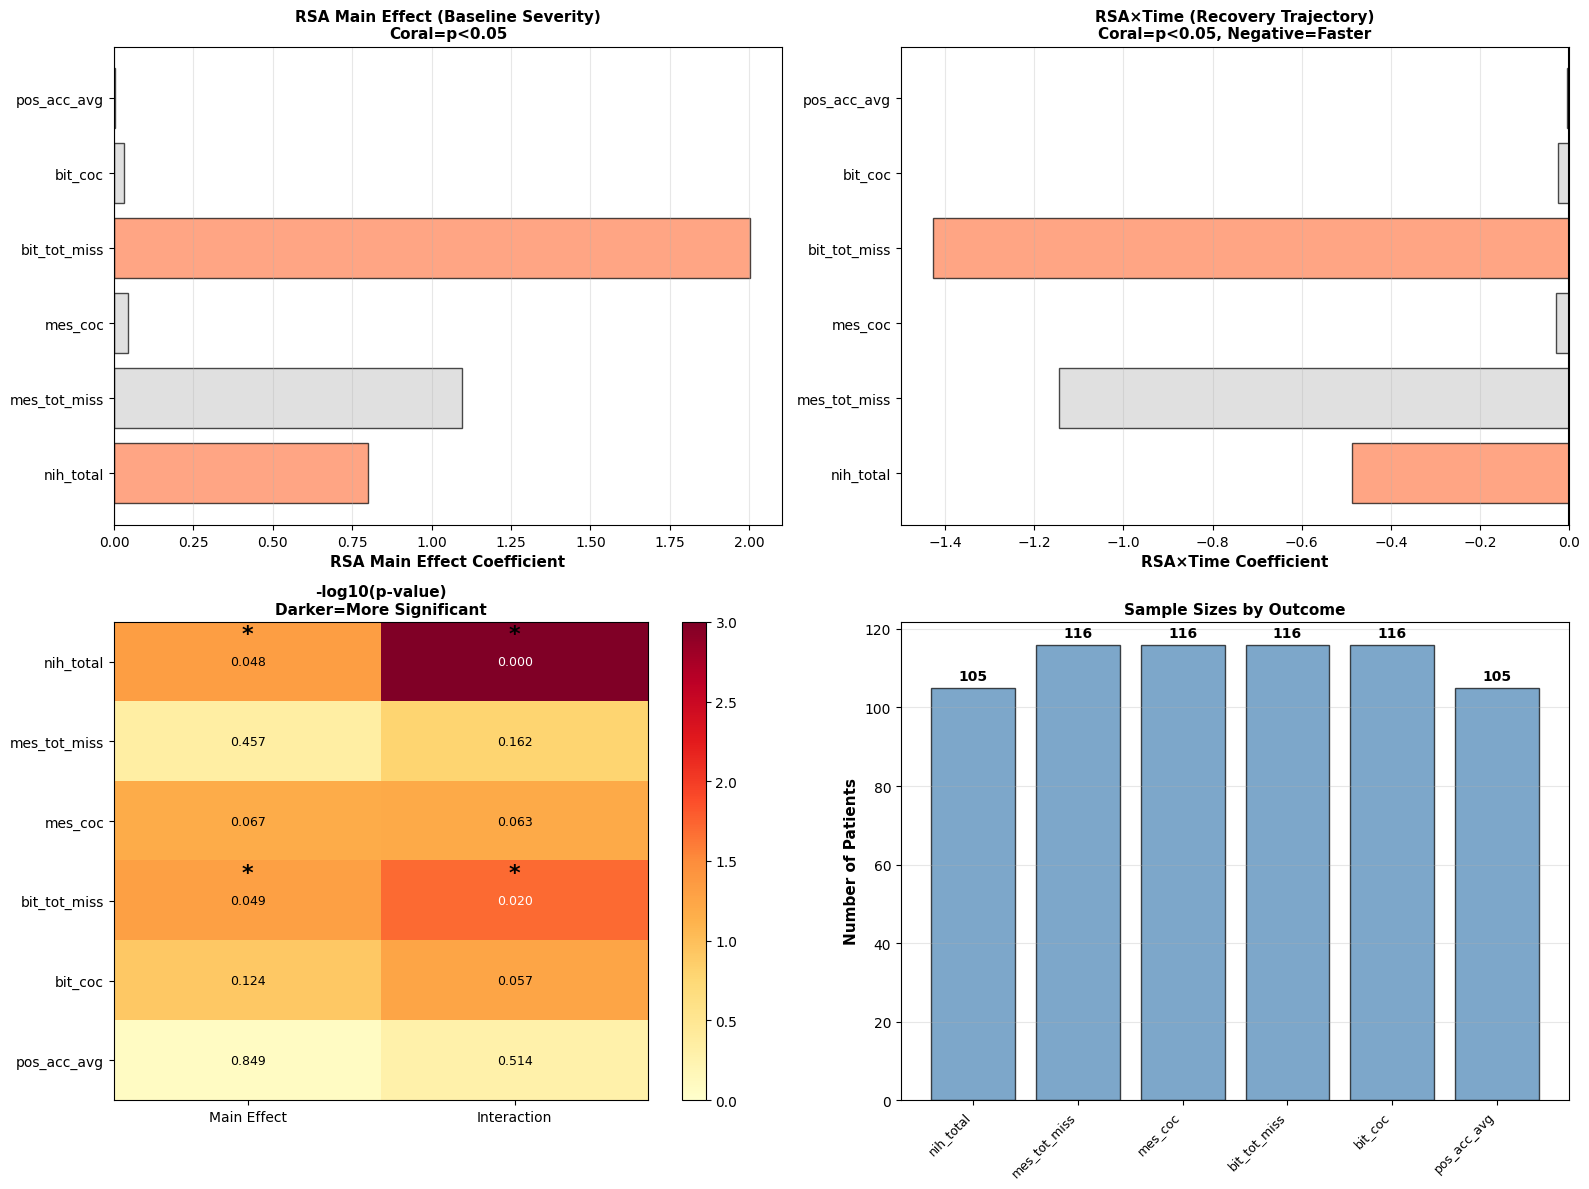

In [133]:
import pandas as pd
import numpy as np
import pickle as pkl
from scipy import stats, signal
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.cov_struct import Exchangeable
from sklearn.preprocessing import StandardScaler

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def compute_variance(timeseries):
    if len(timeseries) < 2:
        return np.nan
    return np.var(timeseries)

def extract_rsa_variance(rsa_left, rsa_right):
    left = np.array(rsa_left).flatten()
    right = np.array(rsa_right).flatten()
    left = left[~np.isnan(left)]
    right = right[~np.isnan(right)]
    
    if len(left) < 10 or len(right) < 10:
        return None
    
    both = np.concatenate([left, right])
    return compute_variance(both)

# ============================================================
# LOAD DATA
# ============================================================
print("="*70)
print("GEE ANALYSIS: RSA×Time with VISUAL/OCULOMOTOR OUTCOMES")
print("="*70)

with open('/mnt/compneuro/stroke_data_with_oculomotor_features_fixed.pkl', 'rb') as f:
    df = pd.DataFrame(pkl.load(f))

patients = df[df['subj_type'] == 0].copy()

acute = patients[patients['Session'] == 'acute']
followup_3mo = patients[patients['Session'] == 'followup']
followup_1yr = patients[patients['Session'] == 'followup2']

# ============================================================
# BUILD LONGITUDINAL DATASET WITH ALL OUTCOMES
# ============================================================
print("\n" + "="*70)
print("BUILDING DATASET")
print("="*70)

long_data = []

for patient_id in acute['ID'].unique():
    acute_row = acute[acute['ID'] == patient_id].iloc[0]
    
    # RSA
    rsa_var = extract_rsa_variance(acute_row.get('RSA_left'), 
                                    acute_row.get('RSA_right'))
    
    if rsa_var is None:
        continue
    
    # Demographics
    age = acute_row.get('age')
    gender = acute_row.get('gender')
    lesion_vol = acute_row.get('lesion_volume_mm3')
    
    if pd.isna(age) or pd.isna(gender) or pd.isna(lesion_vol):
        continue
    
    # Add timepoints
    def add_timepoint(session_row, timepoint, time_label):
        if session_row is None or len(session_row) == 0:
            return None
        
        row = session_row.iloc[0]
        
        return {
            'ID': patient_id,
            'timepoint': timepoint,
            'time_label': time_label,
            'age': age,
            'gender': gender,
            'lesion_volume_mm3': lesion_vol,
            'RSA_both_var': rsa_var,
            # ALL OUTCOMES
            'nih_total': row.get('nih_total', np.nan),
            'mes_tot_miss': row.get('mes_tot_miss', np.nan),
            'mes_coc': row.get('mes_coc', np.nan),
            'bit_tot_miss': row.get('bit_tot_miss', np.nan),
            'bit_coc': row.get('bit_coc', np.nan),
            'pos_acc_avg': row.get('pos_acc_avg', np.nan)
        }
    
    for session, tp, label in [(acute[acute['ID'] == patient_id], 0, 'acute'),
                               (followup_3mo[followup_3mo['ID'] == patient_id], 1, '3-month'),
                               (followup_1yr[followup_1yr['ID'] == patient_id], 2, '1-year')]:
        tp_data = add_timepoint(session, tp, label)
        if tp_data:
            long_data.append(tp_data)

long_df = pd.DataFrame(long_data)

print(f"\nDataset: {long_df['ID'].nunique()} patients, {len(long_df)} observations")

# Check availability of each outcome
print("\n📊 Outcome Availability:")
outcomes = ['nih_total', 'mes_tot_miss', 'mes_coc', 'bit_tot_miss', 'bit_coc', 'pos_acc_avg']

for outcome in outcomes:
    n_avail = long_df[outcome].notna().sum()
    n_patients = long_df[long_df[outcome].notna()]['ID'].nunique()
    print(f"  {outcome:15s}: {n_avail:3d} obs, {n_patients:3d} patients")

# ============================================================
# FIT GEE FOR EACH OUTCOME
# ============================================================
print("\n" + "="*70)
print("TESTING RSA×TIME FOR EACH OUTCOME")
print("="*70)

results_all = []

def fit_gee_outcome(data, outcome_name):
    """Fit GEE with RSA×time for specific outcome"""
    
    # Select complete data for this outcome
    predictors = ['ID', 'timepoint', 'age', 'gender', 'lesion_volume_mm3', 'RSA_both_var', outcome_name]
    data_complete = data[predictors].dropna()
    
    if data_complete['ID'].nunique() < 20:
        print(f"\n⚠️  {outcome_name}: Too few patients (N={data_complete['ID'].nunique()})")
        return None
    
    # Standardize continuous predictors
    scaler = StandardScaler()
    data_scaled = data_complete.copy()
    data_scaled[['age', 'lesion_volume_mm3', 'RSA_both_var']] = scaler.fit_transform(
        data_complete[['age', 'lesion_volume_mm3', 'RSA_both_var']]
    )
    
    # Create interaction
    data_scaled['rsa_time'] = data_scaled['RSA_both_var'] * data_scaled['timepoint']
    
    try:
        # Fit GEE
        formula = f'{outcome_name} ~ timepoint + age + gender + lesion_volume_mm3 + RSA_both_var + rsa_time'
        model = GEE.from_formula(
            formula,
            groups='ID',
            data=data_scaled,
            cov_struct=Exchangeable(),
            family=sm.families.Gaussian()
        )
        result = model.fit()
        
        return {
            'outcome': outcome_name,
            'n_patients': data_complete['ID'].nunique(),
            'n_obs': len(data_complete),
            'time_coef': result.params['timepoint'],
            'time_p': result.pvalues['timepoint'],
            'rsa_main_coef': result.params['RSA_both_var'],
            'rsa_main_p': result.pvalues['RSA_both_var'],
            'rsa_time_coef': result.params['rsa_time'],
            'rsa_time_p': result.pvalues['rsa_time'],
            'converged': result.converged
        }
    
    except Exception as e:
        print(f"\n⚠️  {outcome_name} failed: {e}")
        return None

# Test each outcome
for outcome in outcomes:
    print(f"\n{'='*60}")
    print(f"OUTCOME: {outcome}")
    print(f"{'='*60}")
    
    result = fit_gee_outcome(long_df, outcome)
    
    if result:
        results_all.append(result)
        
        print(f"\n  Sample: N={result['n_patients']} patients, {result['n_obs']} obs")
        print(f"\n  TIME EFFECT (recovery):")
        print(f"    β={result['time_coef']:+.3f}, p={result['time_p']:.4f}")
        
        print(f"\n  RSA MAIN EFFECT (baseline):")
        print(f"    β={result['rsa_main_coef']:+.3f}, p={result['rsa_main_p']:.4f}")
        if result['rsa_main_p'] < 0.05:
            print(f"    ✅ SIGNIFICANT")
        else:
            print(f"    ns")
        
        print(f"\n  RSA×TIME INTERACTION (trajectory):")
        print(f"    β={result['rsa_time_coef']:+.3f}, p={result['rsa_time_p']:.4f}")
        if result['rsa_time_p'] < 0.05:
            direction = "faster" if result['rsa_time_coef'] < 0 else "slower"
            print(f"    ✅ SIGNIFICANT → {direction} recovery")
        else:
            print(f"    ns")

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "="*70)
print("SUMMARY: RSA×TIME ACROSS ALL OUTCOMES")
print("="*70)

if len(results_all) > 0:
    results_df = pd.DataFrame(results_all)
    
    # Display table
    print("\n" + results_df.to_string(index=False))
    
    # Significant results
    print("\n" + "="*70)
    print("SIGNIFICANT RSA×TIME EFFECTS (p<0.05)")
    print("="*70)
    
    sig_results = results_df[results_df['rsa_time_p'] < 0.05]
    
    if len(sig_results) > 0:
        print(f"\n✅ {len(sig_results)}/{len(results_df)} outcomes show significant RSA×time:")
        for idx, row in sig_results.iterrows():
            direction = "faster" if row['rsa_time_coef'] < 0 else "slower"
            print(f"  {row['outcome']:15s}: β={row['rsa_time_coef']:+.3f}, p={row['rsa_time_p']:.4f} → {direction}")
    else:
        print("\n❌ No significant RSA×time effects")
    
    # Significant main effects
    print("\n" + "="*70)
    print("SIGNIFICANT RSA MAIN EFFECTS (p<0.05)")
    print("="*70)
    
    sig_main = results_df[results_df['rsa_main_p'] < 0.05]
    
    if len(sig_main) > 0:
        print(f"\n✅ {len(sig_main)}/{len(results_df)} outcomes show significant RSA main effect:")
        for idx, row in sig_main.iterrows():
            print(f"  {row['outcome']:15s}: β={row['rsa_main_coef']:+.3f}, p={row['rsa_main_p']:.4f}")
    else:
        print("\n❌ No significant RSA main effects")
    
    # ============================================================
    # VISUALIZATION
    # ============================================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: RSA main effects
    outcomes_plot = results_df['outcome'].tolist()
    main_coefs = results_df['rsa_main_coef'].tolist()
    main_pvals = results_df['rsa_main_p'].tolist()
    colors_main = ['coral' if p < 0.05 else 'lightgray' for p in main_pvals]
    
    axes[0,0].barh(range(len(outcomes_plot)), main_coefs,
                  color=colors_main, edgecolor='black', alpha=0.7)
    axes[0,0].set_yticks(range(len(outcomes_plot)))
    axes[0,0].set_yticklabels(outcomes_plot, fontsize=10)
    axes[0,0].axvline(0, color='black', linewidth=1.5)
    axes[0,0].set_xlabel('RSA Main Effect Coefficient', fontweight='bold', fontsize=11)
    axes[0,0].set_title('RSA Main Effect (Baseline Severity)\nCoral=p<0.05',
                       fontweight='bold', fontsize=11)
    axes[0,0].grid(alpha=0.3, axis='x')
    
    # Plot 2: RSA×time interactions
    int_coefs = results_df['rsa_time_coef'].tolist()
    int_pvals = results_df['rsa_time_p'].tolist()
    colors_int = ['coral' if p < 0.05 else 'lightgray' for p in int_pvals]
    
    axes[0,1].barh(range(len(outcomes_plot)), int_coefs,
                  color=colors_int, edgecolor='black', alpha=0.7)
    axes[0,1].set_yticks(range(len(outcomes_plot)))
    axes[0,1].set_yticklabels(outcomes_plot, fontsize=10)
    axes[0,1].axvline(0, color='black', linewidth=1.5)
    axes[0,1].set_xlabel('RSA×Time Coefficient', fontweight='bold', fontsize=11)
    axes[0,1].set_title('RSA×Time (Recovery Trajectory)\nCoral=p<0.05, Negative=Faster',
                       fontweight='bold', fontsize=11)
    axes[0,1].grid(alpha=0.3, axis='x')
    
    # Plot 3: P-values heatmap
    pval_data = results_df[['outcome', 'rsa_main_p', 'rsa_time_p']].set_index('outcome')
    pval_data.columns = ['Main Effect', 'Interaction']
    
    im = axes[1,0].imshow(-np.log10(pval_data.values), cmap='YlOrRd', aspect='auto',
                         vmin=0, vmax=3)
    axes[1,0].set_xticks(range(len(pval_data.columns)))
    axes[1,0].set_yticks(range(len(pval_data.index)))
    axes[1,0].set_xticklabels(pval_data.columns, fontsize=10)
    axes[1,0].set_yticklabels(pval_data.index, fontsize=10)
    axes[1,0].set_title('-log10(p-value)\nDarker=More Significant',
                       fontweight='bold', fontsize=11)
    
    # Add p-values and significance markers
    for i in range(len(pval_data.index)):
        for j in range(len(pval_data.columns)):
            p = pval_data.iloc[i, j]
            color = 'white' if -np.log10(p) > 1.5 else 'black'
            axes[1,0].text(j, i, f'{p:.3f}', ha='center', va='center',
                          color=color, fontsize=9)
            if p < 0.05:
                axes[1,0].text(j, i-0.35, '*', ha='center', va='center',
                              color='black', fontsize=16, fontweight='bold')
    
    plt.colorbar(im, ax=axes[1,0])
    
    # Plot 4: Sample sizes
    n_patients = results_df['n_patients'].tolist()
    
    axes[1,1].bar(range(len(outcomes_plot)), n_patients,
                 color='steelblue', edgecolor='black', alpha=0.7)
    axes[1,1].set_xticks(range(len(outcomes_plot)))
    axes[1,1].set_xticklabels(outcomes_plot, fontsize=9, rotation=45, ha='right')
    axes[1,1].set_ylabel('Number of Patients', fontweight='bold', fontsize=11)
    axes[1,1].set_title('Sample Sizes by Outcome', fontweight='bold', fontsize=11)
    axes[1,1].grid(alpha=0.3, axis='y')
    
    # Add counts
    for i, n in enumerate(n_patients):
        axes[1,1].text(i, n + 2, f'{n}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('/mnt/compneuro/gee_all_outcomes.png', dpi=300, bbox_inches='tight')
    print(f"\n✅ Saved: gee_all_outcomes.png")
    
    # Save results
    results_df.to_csv('/mnt/compneuro/gee_all_outcomes_results.csv', index=False)
    print(f"✅ Saved: gee_all_outcomes_results.csv")

print("\n" + "="*70)
print("ANALYSIS COMPLETE: RSA×TIME ACROSS ALL OUTCOMES")
print("="*70)

ANALYSIS 3: RSA × 7 Main Networks (Longitudinal)

Data loaded:
  Stroke patients: 386 rows
  Network labels: 400 parcels

7 Main Networks: ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']

AGGREGATING ED_FUNC BY 7 MAIN NETWORKS
  Vis            : 61 regions
  SomMot         : 77 regions
  DorsAttn       : 46 regions
  SalVentAttn    : 47 regions
  Limbic         : 26 regions
  Cont           : 52 regions
  Default        : 91 regions

Aggregated network data:
  Acute:   138 patients
  3-month: 103 patients
  1-year:  87 patients

Network ed_func summary (Acute):
  Vis            : 0.044 ± 0.010
  SomMot         : 0.046 ± 0.012
  DorsAttn       : 0.051 ± 0.010
  SalVentAttn    : 0.046 ± 0.009
  Limbic         : 0.041 ± 0.016
  Cont           : 0.046 ± 0.008
  Default        : 0.048 ± 0.011

LOADING RSA FEATURES (Acute)
RSA features: 137 patients
RSA_both_var: 0.134 ± 0.081

CORRELATION: Acute RSA × Network ED_FUNC (Longitudinal)

--- ACUTE ---
Matched patients: 

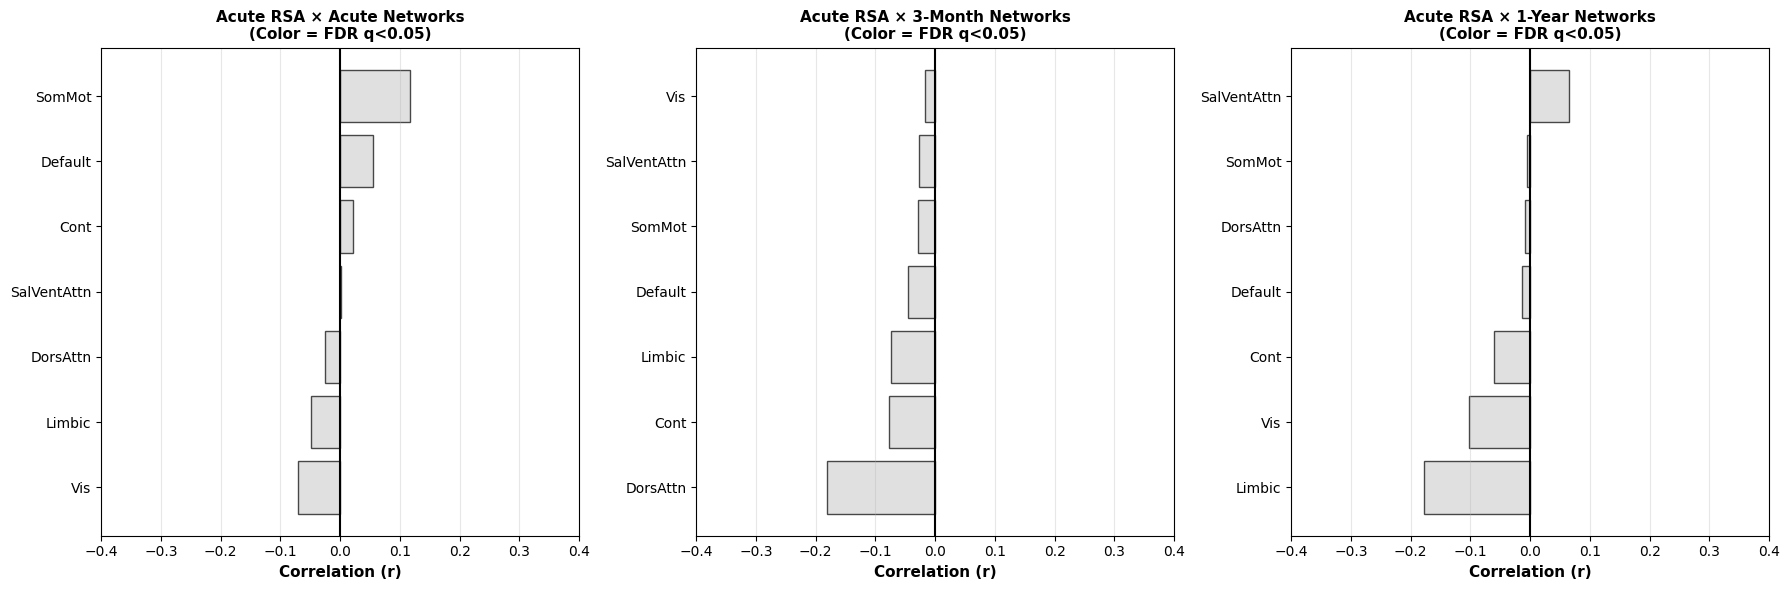

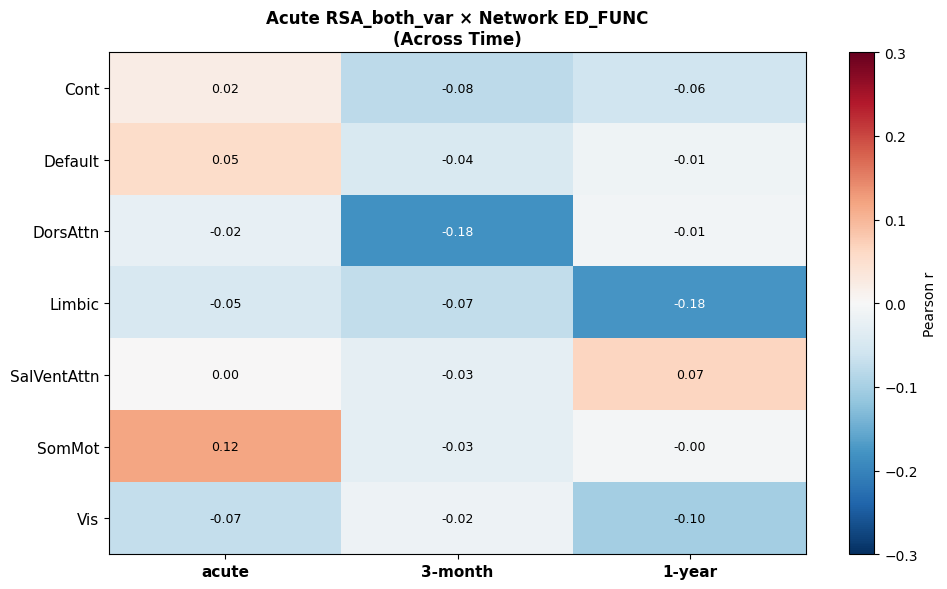

In [93]:
import pandas as pd
import numpy as np
import pickle as pkl
from scipy import stats
from scipy.stats import false_discovery_control
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# LOAD DATA
# ============================================================
print("="*70)
print("ANALYSIS 3: RSA × 7 Main Networks (Longitudinal)")
print("="*70)

# Load stroke data
with open('/mnt/compneuro/stroke_data_with_oculomotor_features_fixed.pkl', 'rb') as f:
    df = pd.DataFrame(pkl.load(f))

# Load network labels
network_labels = pd.read_csv(
    '/mnt/compneuro/MULTIBOOT/rest_blnd_can_raw/code/Yeo/Centroid_coordinates/'
    'Schaefer2018_400Parcels_7Networks_order_FSLMNI152_1mm.Centroid_RAS.csv',
    sep=','
)

print(f"\nData loaded:")
print(f"  Stroke patients: {len(df)} rows")
print(f"  Network labels: {len(network_labels)} parcels")

# Extract MAIN network name (7 networks)
# Pattern: 7Networks_LH_Vis_1 -> Vis
#          7Networks_LH_DorsAttn_Post_1 -> DorsAttn
network_labels['Network'] = network_labels['ROI Name'].str.extract(r'7Networks_[LR]H_(\w+)_')[0]

# For networks with sub-divisions, take only first part
# E.g., "DorsAttn" from "DorsAttn_Post"
network_labels['MainNetwork'] = network_labels['Network'].str.split('_').str[0]

unique_networks = network_labels['MainNetwork'].unique()
print(f"\n7 Main Networks: {list(unique_networks)}")

# ============================================================
# AGGREGATE ED_FUNC BY MAIN NETWORK
# ============================================================
print("\n" + "="*70)
print("AGGREGATING ED_FUNC BY 7 MAIN NETWORKS")
print("="*70)

patients = df[df['subj_type'] == 0].copy()

# Create network mapping (ROI indices for each main network)
network_mapping = {}
for network in unique_networks:
    roi_labels = network_labels[network_labels['MainNetwork'] == network]['ROI Label'].values
    indices = roi_labels - 1  # Convert to 0-indexed
    network_mapping[network] = indices.tolist()
    print(f"  {network:15s}: {len(indices)} regions")

# Function to aggregate ed_func for a session
def aggregate_networks(session_data, session_label):
    network_data = []
    
    for idx, row in session_data.iterrows():
        ed_func = row.get('ed_func_mean_corrected')
        
        if ed_func is None or (isinstance(ed_func, float) and np.isnan(ed_func)):
            continue
        
        ed_func_array = np.array(ed_func).flatten()
        
        if len(ed_func_array) != 400:
            continue
        
        patient_networks = {
            'ID': row['ID'],
            'timepoint': session_label
        }
        
        for network, indices in network_mapping.items():
            network_values = ed_func_array[indices]
            patient_networks[f'ed_func_{network}'] = np.mean(network_values)
        
        network_data.append(patient_networks)
    
    return pd.DataFrame(network_data)

# Aggregate for each timepoint
acute = patients[patients['Session'] == 'acute']
followup_3mo = patients[patients['Session'] == 'followup']
followup_1yr = patients[patients['Session'] == 'followup2']

network_acute = aggregate_networks(acute, 'acute')
network_3mo = aggregate_networks(followup_3mo, '3-month')
network_1yr = aggregate_networks(followup_1yr, '1-year')

print(f"\nAggregated network data:")
print(f"  Acute:   {len(network_acute)} patients")
print(f"  3-month: {len(network_3mo)} patients")
print(f"  1-year:  {len(network_1yr)} patients")

# Summary statistics
print("\nNetwork ed_func summary (Acute):")
for network in unique_networks:
    col = f'ed_func_{network}'
    if col in network_acute.columns:
        mean = network_acute[col].mean()
        std = network_acute[col].std()
        print(f"  {network:15s}: {mean:.3f} ± {std:.3f}")

# ============================================================
# LOAD RSA FEATURES
# ============================================================
print("\n" + "="*70)
print("LOADING RSA FEATURES (Acute)")
print("="*70)

rsa_df = pd.read_csv('/mnt/compneuro/rsa_features_clean.csv')
print(f"RSA features: {len(rsa_df)} patients")
print(f"RSA_both_var: {rsa_df['RSA_both_var'].mean():.3f} ± {rsa_df['RSA_both_var'].std():.3f}")

# ============================================================
# CORRELATION ANALYSIS: ACUTE RSA × NETWORKS AT ALL TIMEPOINTS
# ============================================================
print("\n" + "="*70)
print("CORRELATION: Acute RSA × Network ED_FUNC (Longitudinal)")
print("="*70)

all_results = []

# Test at each timepoint
for network_df, timepoint_label in [(network_acute, 'acute'),
                                     (network_3mo, '3-month'),
                                     (network_1yr, '1-year')]:
    
    print(f"\n--- {timepoint_label.upper()} ---")
    
    # Merge with RSA (acute)
    merged = network_df.merge(rsa_df[['ID', 'RSA_both_var']], on='ID', how='inner')
    print(f"Matched patients: {len(merged)}")
    
    for network in unique_networks:
        col = f'ed_func_{network}'
        
        if col not in merged.columns:
            continue
        
        valid = merged[['RSA_both_var', col]].dropna()
        
        if len(valid) < 10:
            continue
        
        r, p = stats.pearsonr(valid['RSA_both_var'], valid[col])
        
        all_results.append({
            'timepoint': timepoint_label,
            'network': network,
            'r': r,
            'abs_r': abs(r),
            'p': p,
            'n': len(valid)
        })
        
        print(f"  {network:15s}  r={r:+.3f}  p={p:.4f}  N={len(valid)}")

results_df = pd.DataFrame(all_results)

# FDR correction within each timepoint
for timepoint in ['acute', '3-month', '1-year']:
    tp_mask = results_df['timepoint'] == timepoint
    if tp_mask.sum() > 0:
        results_df.loc[tp_mask, 'p_fdr'] = false_discovery_control(
            results_df.loc[tp_mask, 'p'].values
        )

results_df['significant_fdr'] = results_df['p_fdr'] < 0.05

# Summary
print("\n" + "="*70)
print("SUMMARY: SIGNIFICANT CORRELATIONS (FDR q<0.05)")
print("="*70)

for timepoint in ['acute', '3-month', '1-year']:
    tp_results = results_df[results_df['timepoint'] == timepoint]
    n_sig = tp_results['significant_fdr'].sum()
    
    print(f"\n{timepoint.upper()}: {n_sig}/{len(tp_results)} significant")
    
    if n_sig > 0:
        sig_nets = tp_results[tp_results['significant_fdr']].sort_values('abs_r', ascending=False)
        for idx, row in sig_nets.iterrows():
            print(f"  {row['network']:15s}  r={row['r']:+.3f}  p_fdr={row['p_fdr']:.4f}")
    else:
        # Show top uncorrected
        top = tp_results.sort_values('abs_r', ascending=False).head(3)
        print("  Top 3 (uncorrected):")
        for idx, row in top.iterrows():
            print(f"    {row['network']:15s}  r={row['r']:+.3f}  p={row['p']:.4f}")

# ============================================================
# VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

timepoint_labels = ['acute', '3-month', '1-year']
colors_map = {'acute': 'steelblue', '3-month': 'coral', '1-year': 'darkgreen'}

for i, timepoint in enumerate(timepoint_labels):
    ax = axes[i]
    
    tp_results = results_df[results_df['timepoint'] == timepoint].sort_values('r', ascending=True)
    
    colors = [colors_map[timepoint] if sig else 'lightgray' 
              for sig in tp_results['significant_fdr']]
    
    ax.barh(range(len(tp_results)), tp_results['r'], 
           color=colors, edgecolor='black', alpha=0.7)
    ax.set_yticks(range(len(tp_results)))
    ax.set_yticklabels(tp_results['network'], fontsize=10)
    ax.axvline(0, color='black', linewidth=1.5)
    ax.set_xlabel('Correlation (r)', fontweight='bold', fontsize=11)
    ax.set_title(f'Acute RSA × {timepoint.title()} Networks\n(Color = FDR q<0.05)', 
                fontweight='bold', fontsize=11)
    ax.grid(alpha=0.3, axis='x')
    ax.set_xlim(-0.4, 0.4)
    
    # Add significance markers
    for j, (idx, row) in enumerate(tp_results.iterrows()):
        if row['significant_fdr']:
            x_pos = row['r'] + (0.03 if row['r'] > 0 else -0.03)
            ax.text(x_pos, j, '*', ha='left' if row['r'] > 0 else 'right',
                   va='center', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('/mnt/compneuro/rsa_network_longitudinal.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: rsa_network_longitudinal.png")

# ============================================================
# HEATMAP: All timepoints together
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Pivot for heatmap
pivot_r = results_df.pivot(index='network', columns='timepoint', values='r')
pivot_p = results_df.pivot(index='network', columns='timepoint', values='p_fdr')

# Reorder columns
pivot_r = pivot_r[['acute', '3-month', '1-year']]
pivot_p = pivot_p[['acute', '3-month', '1-year']]

im = ax.imshow(pivot_r.values, cmap='RdBu_r', aspect='auto', vmin=-0.3, vmax=0.3)
ax.set_xticks(range(len(pivot_r.columns)))
ax.set_yticks(range(len(pivot_r.index)))
ax.set_xticklabels(pivot_r.columns, fontsize=11, fontweight='bold')
ax.set_yticklabels(pivot_r.index, fontsize=11)
ax.set_title('Acute RSA_both_var × Network ED_FUNC\n(Across Time)', 
            fontsize=12, fontweight='bold')

# Add values and significance
for i in range(len(pivot_r.index)):
    for j in range(len(pivot_r.columns)):
        val = pivot_r.iloc[i, j]
        p_val = pivot_p.iloc[i, j]
        
        color = 'white' if abs(val) > 0.15 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
               color=color, fontsize=9)
        
        if p_val < 0.05:
            ax.text(j, i-0.35, '*', ha='center', va='center',
                   color='yellow', fontsize=16, fontweight='bold')

plt.colorbar(im, ax=ax, label='Pearson r')
plt.tight_layout()
plt.savefig('/mnt/compneuro/rsa_network_heatmap.png', dpi=300, bbox_inches='tight')
print(f"✅ Saved: rsa_network_heatmap.png")

# Save results
results_df.to_csv('/mnt/compneuro/rsa_network_longitudinal.csv', index=False)
print(f"✅ Saved: rsa_network_longitudinal.csv")

print("\n" + "="*70)
print("ANALYSIS 3 COMPLETE: RSA × 7 Networks (Longitudinal)")
print("="*70)
print("Question: Does acute RSA predict network dysfunction over time?")
print("="*70)

COMPREHENSIVE GEE: RSA + Networks + Clinical

7 Networks: ['Cont', 'Default', 'DorsAttn', 'Limbic', 'SalVentAttn', 'SomMot', 'Vis']

BUILDING COMPREHENSIVE DATASET

Longitudinal dataset:
  Total observations: 225
  Unique patients: 105
    Timepoint 0: 94 observations
    Timepoint 1: 71 observations
    Timepoint 2: 60 observations

PREPARING PREDICTORS

Predictor sets:
  Base (4):     ['timepoint', 'age', 'gender', 'lesion_volume_mm3']
  RSA (1):      ['RSA_both_var']
  Networks (7): ['ed_func_Cont', 'ed_func_Default', 'ed_func_DorsAttn', 'ed_func_Limbic', 'ed_func_SalVentAttn', 'ed_func_SomMot', 'ed_func_Vis']
  Clinical (3): ['mes_tot_miss', 'bit_tot_miss', 'pos_acc_avg']
  Total: 15 predictors

Sample sizes:
  RSA + Networks:  105 patients, 225 obs
  Full (+ Clinical): 92 patients, 188 obs

✅ Standardized 13 continuous predictors

FITTING HIERARCHICAL GEE MODELS

--- MODEL 1: Base (time + age + gender + lesion) ---
  Converged: True

--- MODEL 2: Base + RSA ---
  RSA_both_var: β=0

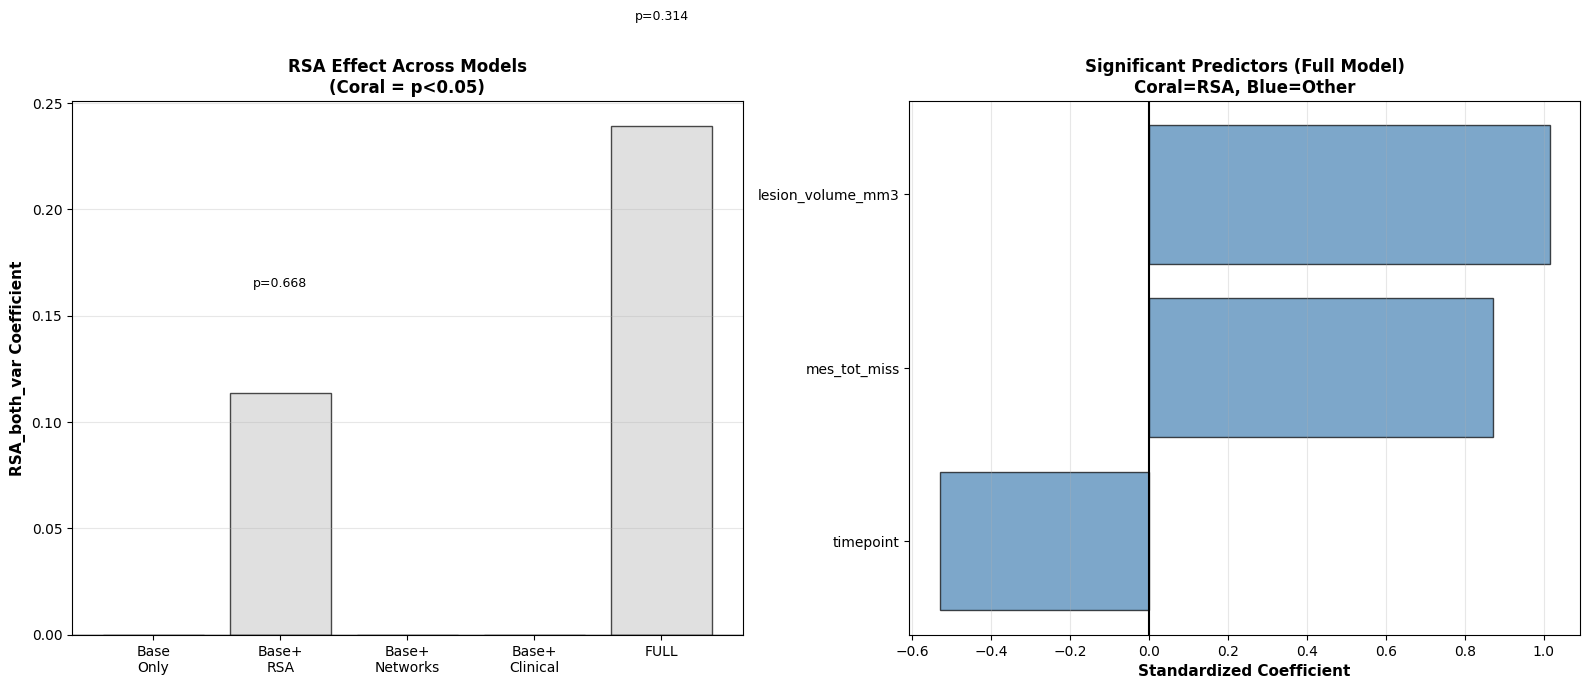

In [97]:
import pandas as pd
import numpy as np
import pickle as pkl
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.cov_struct import Exchangeable
from sklearn.preprocessing import StandardScaler

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def compute_variance(timeseries):
    if len(timeseries) < 2:
        return np.nan
    return np.var(timeseries)

def extract_rsa_variance(rsa_left, rsa_right):
    left = np.array(rsa_left).flatten()
    right = np.array(rsa_right).flatten()
    left = left[~np.isnan(left)]
    right = right[~np.isnan(right)]
    
    if len(left) < 10 or len(right) < 10:
        return None
    
    both = np.concatenate([left, right])
    return compute_variance(both)

# ============================================================
# LOAD DATA
# ============================================================
print("="*70)
print("COMPREHENSIVE GEE: RSA + Networks + Clinical")
print("="*70)

with open('/mnt/compneuro/stroke_data_with_oculomotor_features_fixed.pkl', 'rb') as f:
    df = pd.DataFrame(pkl.load(f))

# Load network labels
network_labels = pd.read_csv(
    '/mnt/compneuro/MULTIBOOT/rest_blnd_can_raw/code/Yeo/Centroid_coordinates/'
    'Schaefer2018_400Parcels_7Networks_order_FSLMNI152_1mm.Centroid_RAS.csv',
    sep=','
)

network_labels['MainNetwork'] = network_labels['ROI Name'].str.extract(
    r'7Networks_[LR]H_(\w+)_')[0].str.split('_').str[0]

unique_networks = sorted(network_labels['MainNetwork'].unique())
print(f"\n7 Networks: {unique_networks}")

# Create network mapping
network_mapping = {}
for network in unique_networks:
    roi_labels = network_labels[network_labels['MainNetwork'] == network]['ROI Label'].values
    indices = roi_labels - 1
    network_mapping[network] = indices.tolist()

# ============================================================
# BUILD COMPREHENSIVE LONGITUDINAL DATASET
# ============================================================
print("\n" + "="*70)
print("BUILDING COMPREHENSIVE DATASET")
print("="*70)

patients = df[df['subj_type'] == 0].copy()

# Get all sessions
acute = patients[patients['Session'] == 'acute']
followup_3mo = patients[patients['Session'] == 'followup']
followup_1yr = patients[patients['Session'] == 'followup2']

long_data = []

for patient_id in acute['ID'].unique():
    acute_row = acute[acute['ID'] == patient_id].iloc[0]
    
    # RSA features (from acute, time-invariant)
    rsa_var = extract_rsa_variance(acute_row.get('RSA_left'), 
                                    acute_row.get('RSA_right'))
    
    if rsa_var is None:
        continue
    
    # Demographics (time-invariant)
    age = acute_row.get('age')
    gender = acute_row.get('gender')
    lesion_vol = acute_row.get('lesion_volume_mm3')
    
    if pd.isna(age) or pd.isna(gender) or pd.isna(lesion_vol):
        continue
    
    # Function to add timepoint
    def add_timepoint(session_row, timepoint, time_label):
        if session_row is None or len(session_row) == 0:
            return None
        
        row = session_row.iloc[0] if len(session_row) > 0 else None
        if row is None:
            return None
        
        # NIHSS outcome
        nih_total = row.get('nih_total')
        if pd.isna(nih_total):
            return None
        
        # Network ed_func
        ed_func = row.get('ed_func_mean_corrected')
        if ed_func is None or (isinstance(ed_func, float) and np.isnan(ed_func)):
            return None
        
        ed_func_array = np.array(ed_func).flatten()
        if len(ed_func_array) != 400:
            return None
        
        # Aggregate networks
        network_vals = {}
        for network, indices in network_mapping.items():
            network_vals[f'ed_func_{network}'] = np.mean(ed_func_array[indices])
        
        # Clinical oculomotor measures
        mes_tot_miss = row.get('mes_tot_miss', np.nan)
        bit_tot_miss = row.get('bit_tot_miss', np.nan)
        pos_acc_avg = row.get('pos_acc_avg', np.nan)
        
        return {
            'ID': patient_id,
            'timepoint': timepoint,
            'time_label': time_label,
            'nih_total': nih_total,
            'age': age,
            'gender': gender,
            'lesion_volume_mm3': lesion_vol,
            'RSA_both_var': rsa_var,
            **network_vals,
            'mes_tot_miss': mes_tot_miss,
            'bit_tot_miss': bit_tot_miss,
            'pos_acc_avg': pos_acc_avg
        }
    
    # ACUTE
    tp_data = add_timepoint(acute[acute['ID'] == patient_id], 0, 'acute')
    if tp_data:
        long_data.append(tp_data)
    
    # 3-MONTH
    followup_3mo_rows = followup_3mo[followup_3mo['ID'] == patient_id]
    if len(followup_3mo_rows) > 0:
        tp_data = add_timepoint(followup_3mo_rows, 1, '3-month')
        if tp_data:
            long_data.append(tp_data)
    
    # 1-YEAR
    followup_1yr_rows = followup_1yr[followup_1yr['ID'] == patient_id]
    if len(followup_1yr_rows) > 0:
        tp_data = add_timepoint(followup_1yr_rows, 2, '1-year')
        if tp_data:
            long_data.append(tp_data)

long_df = pd.DataFrame(long_data)

print(f"\nLongitudinal dataset:")
print(f"  Total observations: {len(long_df)}")
print(f"  Unique patients: {long_df['ID'].nunique()}")

for tp in sorted(long_df['timepoint'].unique()):
    n = len(long_df[long_df['timepoint']==tp])
    print(f"    Timepoint {tp}: {n} observations")

# ============================================================
# PREPARE PREDICTORS
# ============================================================
print("\n" + "="*70)
print("PREPARING PREDICTORS")
print("="*70)

# Select predictors
base_predictors = ['timepoint', 'age', 'gender', 'lesion_volume_mm3']
rsa_predictor = ['RSA_both_var']
network_predictors = [f'ed_func_{net}' for net in unique_networks]
clinical_predictors = ['mes_tot_miss', 'bit_tot_miss', 'pos_acc_avg']

all_predictors = base_predictors + rsa_predictor + network_predictors + clinical_predictors

print(f"\nPredictor sets:")
print(f"  Base (4):     {base_predictors}")
print(f"  RSA (1):      {rsa_predictor}")
print(f"  Networks (7): {network_predictors}")
print(f"  Clinical (3): {clinical_predictors}")
print(f"  Total: {len(all_predictors)} predictors")

# Complete data (may have NaNs in clinical)
data_rsa_net = long_df[base_predictors + rsa_predictor + network_predictors + ['nih_total', 'ID']].dropna()
data_full = long_df[all_predictors + ['nih_total', 'ID']].dropna()

print(f"\nSample sizes:")
print(f"  RSA + Networks:  {data_rsa_net['ID'].nunique()} patients, {len(data_rsa_net)} obs")
print(f"  Full (+ Clinical): {data_full['ID'].nunique()} patients, {len(data_full)} obs")

# ============================================================
# STANDARDIZE CONTINUOUS PREDICTORS
# ============================================================

# Use data_full for main analysis
data_scaled = data_full.copy()

continuous_vars = ['age', 'lesion_volume_mm3', 'RSA_both_var'] + network_predictors + clinical_predictors

scaler = StandardScaler()
data_scaled[continuous_vars] = scaler.fit_transform(data_full[continuous_vars])

print(f"\n✅ Standardized {len(continuous_vars)} continuous predictors")

# ============================================================
# FIT GEE MODELS
# ============================================================
print("\n" + "="*70)
print("FITTING HIERARCHICAL GEE MODELS")
print("="*70)

# Model 1: Base only
print("\n--- MODEL 1: Base (time + age + gender + lesion) ---")
model1 = GEE.from_formula(
    'nih_total ~ timepoint + age + gender + lesion_volume_mm3',
    groups='ID',
    data=data_scaled,
    cov_struct=Exchangeable(),
    family=sm.families.Gaussian()
)
result1 = model1.fit()
print(f"  Converged: {result1.converged}")

# Model 2: Base + RSA
print("\n--- MODEL 2: Base + RSA ---")
model2 = GEE.from_formula(
    'nih_total ~ timepoint + age + gender + lesion_volume_mm3 + RSA_both_var',
    groups='ID',
    data=data_scaled,
    cov_struct=Exchangeable(),
    family=sm.families.Gaussian()
)
result2 = model2.fit()
print(f"  RSA_both_var: β={result2.params['RSA_both_var']:.3f}, p={result2.pvalues['RSA_both_var']:.4f}")

# Model 3: Base + Networks
print("\n--- MODEL 3: Base + Networks (7) ---")
formula3 = 'nih_total ~ timepoint + age + gender + lesion_volume_mm3 + ' + ' + '.join(network_predictors)
model3 = GEE.from_formula(
    formula3,
    groups='ID',
    data=data_scaled,
    cov_struct=Exchangeable(),
    family=sm.families.Gaussian()
)
result3 = model3.fit()
print(f"  Converged: {result3.converged}")

# Check which networks are significant
net_sig = []
for net_pred in network_predictors:
    if result3.pvalues[net_pred] < 0.05:
        net_sig.append(f"{net_pred}: β={result3.params[net_pred]:.3f}, p={result3.pvalues[net_pred]:.4f}")
print(f"  Significant networks: {len(net_sig)}")
for ns in net_sig:
    print(f"    {ns}")

# Model 4: Base + Clinical
print("\n--- MODEL 4: Base + Clinical (3) ---")
formula4 = 'nih_total ~ timepoint + age + gender + lesion_volume_mm3 + mes_tot_miss + bit_tot_miss + pos_acc_avg'
model4 = GEE.from_formula(
    formula4,
    groups='ID',
    data=data_scaled,
    cov_struct=Exchangeable(),
    family=sm.families.Gaussian()
)
result4 = model4.fit()

for clin_pred in clinical_predictors:
    print(f"  {clin_pred}: β={result4.params[clin_pred]:.3f}, p={result4.pvalues[clin_pred]:.4f}")

# Model 5: FULL (Base + RSA + Networks + Clinical)
print("\n--- MODEL 5: FULL (Base + RSA + Networks + Clinical) ---")
print("  WARNING: 14 predictors with limited sample - risk of overfitting")

formula5 = 'nih_total ~ timepoint + age + gender + lesion_volume_mm3 + RSA_both_var + ' + \
           ' + '.join(network_predictors) + ' + ' + ' + '.join(clinical_predictors)

model5 = GEE.from_formula(
    formula5,
    groups='ID',
    data=data_scaled,
    cov_struct=Exchangeable(),
    family=sm.families.Gaussian()
)
result5 = model5.fit()
print(f"  Converged: {result5.converged}")

print(f"\n  RSA_both_var: β={result5.params['RSA_both_var']:.3f}, p={result5.pvalues['RSA_both_var']:.4f}")

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

comparison = pd.DataFrame({
    'Model': [
        '1. Base only',
        '2. Base + RSA',
        '3. Base + Networks',
        '4. Base + Clinical',
        '5. FULL'
    ],
    'N_predictors': [4, 5, 11, 7, 15],
    'N_obs': [len(data_scaled)]*5,
    'N_patients': [data_scaled['ID'].nunique()]*5
})

print(comparison.to_string(index=False))

# Extract key coefficients from full model
print("\n" + "="*70)
print("FULL MODEL: SIGNIFICANT PREDICTORS (p<0.05)")
print("="*70)

sig_predictors = []
for pred in result5.params.index:
    if pred == 'Intercept':
        continue
    p_val = result5.pvalues[pred]
    if p_val < 0.05:
        sig_predictors.append({
            'predictor': pred,
            'coefficient': result5.params[pred],
            'p_value': p_val
        })

if len(sig_predictors) > 0:
    sig_df = pd.DataFrame(sig_predictors).sort_values('p_value')
    print(sig_df.to_string(index=False))
else:
    print("No significant predictors beyond intercept")

# RSA status
print(f"\n**RSA_both_var in full model:**")
print(f"  β = {result5.params['RSA_both_var']:.3f}")
print(f"  p = {result5.pvalues['RSA_both_var']:.4f}")
if result5.pvalues['RSA_both_var'] < 0.05:
    print(f"  ✅ SURVIVES after controlling for networks + clinical")
else:
    print(f"  ❌ Not significant (explained by networks/clinical)")

# ============================================================
# VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Coefficient comparison (RSA across models)
rsa_coefs = [
    0,  # Model 1 (no RSA)
    result2.params['RSA_both_var'],  # Model 2
    0,  # Model 3 (no RSA)
    0,  # Model 4 (no RSA)
    result5.params['RSA_both_var']   # Model 5
]

rsa_pvals = [
    1,
    result2.pvalues['RSA_both_var'],
    1,
    1,
    result5.pvalues['RSA_both_var']
]

model_names = ['Base\nOnly', 'Base+\nRSA', 'Base+\nNetworks', 'Base+\nClinical', 'FULL']
colors = ['lightgray' if p >= 0.05 else 'coral' for p in rsa_pvals]

axes[0].bar(range(5), rsa_coefs, color=colors, edgecolor='black', alpha=0.7)
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(model_names, fontsize=10)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_ylabel('RSA_both_var Coefficient', fontweight='bold', fontsize=11)
axes[0].set_title('RSA Effect Across Models\n(Coral = p<0.05)', fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.3, axis='y')

for i, (coef, p) in enumerate(zip(rsa_coefs, rsa_pvals)):
    if coef != 0:
        axes[0].text(i, coef + 0.05, f'p={p:.3f}', ha='center', fontsize=9)

# Plot 2: All significant predictors in full model
if len(sig_predictors) > 0:
    sig_df_sorted = sig_df.sort_values('coefficient', ascending=True)
    colors2 = ['coral' if 'RSA' in pred else 'steelblue' for pred in sig_df_sorted['predictor']]
    
    axes[1].barh(range(len(sig_df_sorted)), sig_df_sorted['coefficient'],
                color=colors2, edgecolor='black', alpha=0.7)
    axes[1].set_yticks(range(len(sig_df_sorted)))
    axes[1].set_yticklabels(sig_df_sorted['predictor'], fontsize=10)
    axes[1].axvline(0, color='black', linewidth=1.5)
    axes[1].set_xlabel('Standardized Coefficient', fontweight='bold', fontsize=11)
    axes[1].set_title('Significant Predictors (Full Model)\nCoral=RSA, Blue=Other', 
                     fontweight='bold', fontsize=12)
    axes[1].grid(alpha=0.3, axis='x')
else:
    axes[1].text(0.5, 0.5, 'No significant\npredictors', ha='center', va='center',
                transform=axes[1].transAxes, fontsize=14)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('/mnt/compneuro/gee_comprehensive_model.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: gee_comprehensive_model.png")

print("\n" + "="*70)
print("COMPREHENSIVE GEE COMPLETE")
print("="*70)
print(f"Question: Does RSA add unique value beyond networks + clinical?")
print(f"Answer: See RSA p-value in full model above")
print("="*70)

FOCUSED GEE: RSA + Visual/SomMot Networks (with interactions)
  Vis: 61 regions
  SomMot: 77 regions

BUILDING LONGITUDINAL DATASET

Longitudinal dataset:
  Total observations: 225
  Unique patients: 105
    Timepoint 0: 94 observations
    Timepoint 1: 71 observations
    Timepoint 2: 60 observations

STANDARDIZING PREDICTORS
✅ Standardized 5 predictors
✅ Created 3 interaction terms

FITTING GEE MODELS

--- MODEL 1: Base (time + demographics) ---
  Time: β=-0.969, p=0.0000

--- MODEL 2: Base + Vis/SomMot (main effects) ---
  ed_func_Vis:    β=-0.146, p=0.2653
  ed_func_SomMot: β=0.108, p=0.5660

--- MODEL 3: Base + Vis/SomMot + Vis×time + SomMot×time ---
  ed_func_Vis (main):      β=-0.301, p=0.1911
  ed_func_SomMot (main):   β=0.406, p=0.1449
  Vis×time (interaction):  β=0.281, p=0.0978
  SomMot×time (interact):  β=-0.442, p=0.0230

--- MODEL 4: Model 3 + RSA (main) ---
  RSA_both_var (main): β=0.498, p=0.1976

--- MODEL 5: FULL (all main + all interactions) ---

  MAIN EFFECTS:
    

/tmp/ipykernel_3650016/3022113191.py:387: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_3650016/3022113191.py:388: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('/mnt/compneuro/gee_focused_vis_sommot.png', dpi=300, bbox_inches='tight')



✅ Saved: gee_focused_vis_sommot.png

FOCUSED GEE COMPLETE


/mnt/compneuro/venvs/deepmreye-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


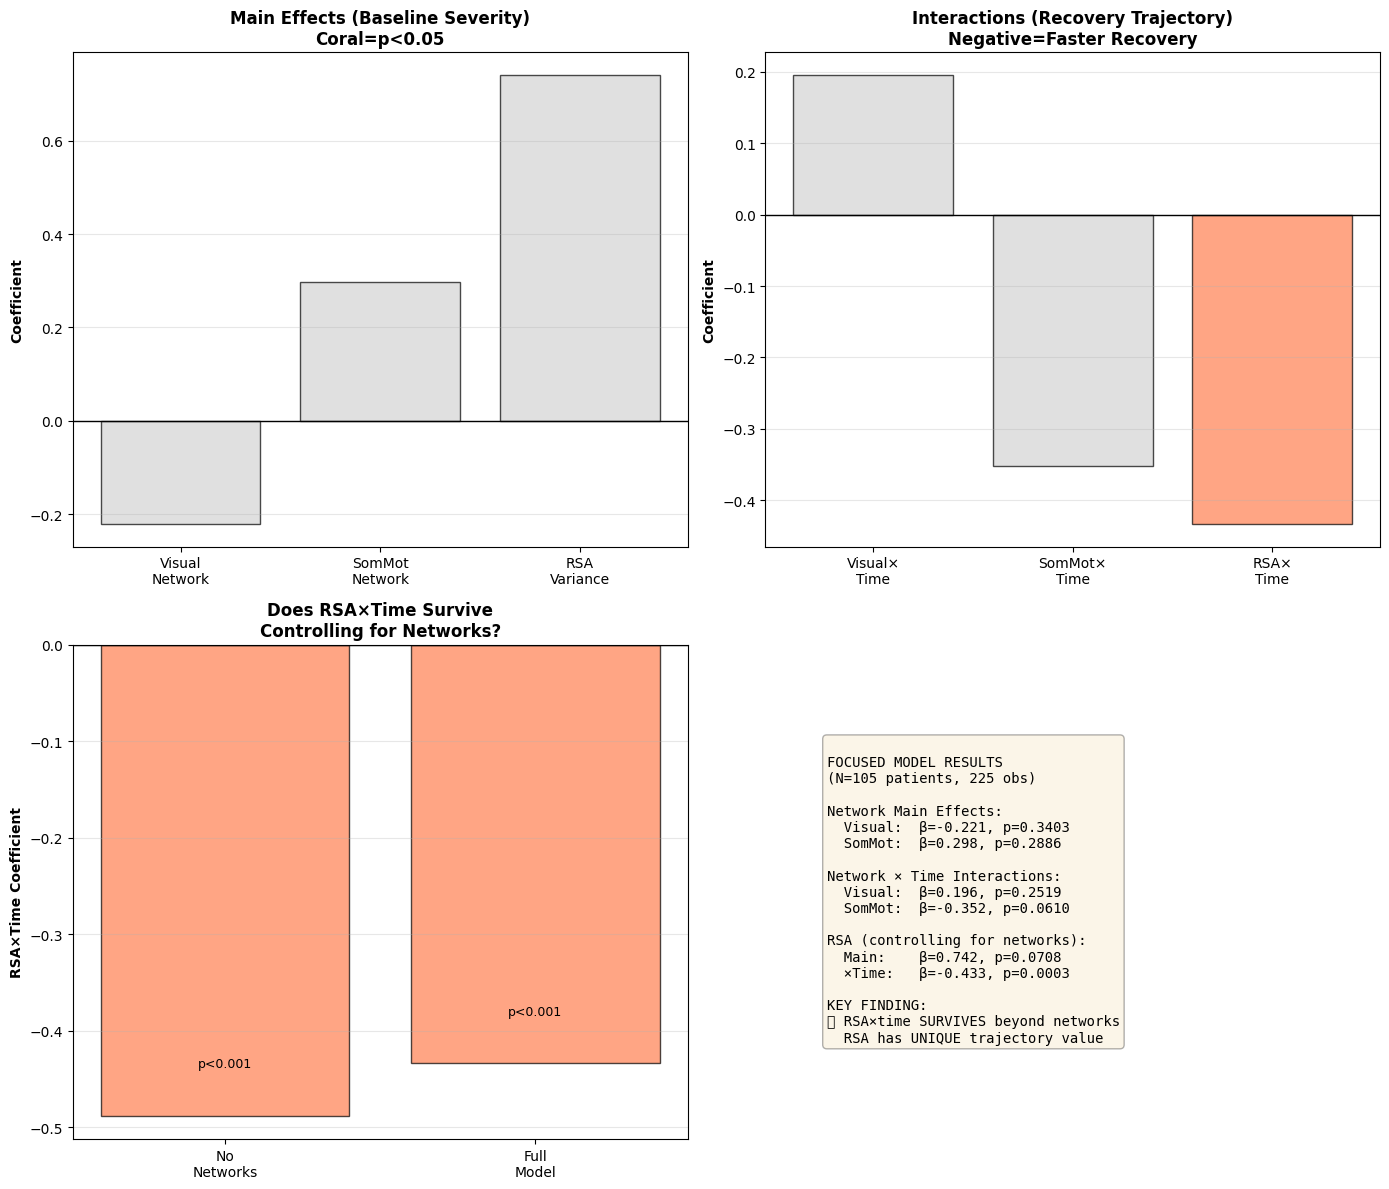

In [98]:
import pandas as pd
import numpy as np
import pickle as pkl
from scipy import stats, signal
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.cov_struct import Exchangeable
from sklearn.preprocessing import StandardScaler

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def compute_variance(timeseries):
    if len(timeseries) < 2:
        return np.nan
    return np.var(timeseries)

def extract_rsa_variance(rsa_left, rsa_right):
    left = np.array(rsa_left).flatten()
    right = np.array(rsa_right).flatten()
    left = left[~np.isnan(left)]
    right = right[~np.isnan(right)]
    
    if len(left) < 10 or len(right) < 10:
        return None
    
    both = np.concatenate([left, right])
    return compute_variance(both)

# ============================================================
# LOAD DATA
# ============================================================
print("="*70)
print("FOCUSED GEE: RSA + Visual/SomMot Networks (with interactions)")
print("="*70)

with open('/mnt/compneuro/stroke_data_with_oculomotor_features_fixed.pkl', 'rb') as f:
    df = pd.DataFrame(pkl.load(f))

# Load network labels
network_labels = pd.read_csv(
    '/mnt/compneuro/MULTIBOOT/rest_blnd_can_raw/code/Yeo/Centroid_coordinates/'
    'Schaefer2018_400Parcels_7Networks_order_FSLMNI152_1mm.Centroid_RAS.csv',
    sep=','
)

network_labels['MainNetwork'] = network_labels['ROI Name'].str.extract(
    r'7Networks_[LR]H_(\w+)_')[0].str.split('_').str[0]

# Create network mapping for Vis and SomMot only
network_mapping = {}
for network in ['Vis', 'SomMot']:
    roi_labels = network_labels[network_labels['MainNetwork'] == network]['ROI Label'].values
    indices = roi_labels - 1
    network_mapping[network] = indices.tolist()
    print(f"  {network}: {len(indices)} regions")

# ============================================================
# BUILD DATASET
# ============================================================
print("\n" + "="*70)
print("BUILDING LONGITUDINAL DATASET")
print("="*70)

patients = df[df['subj_type'] == 0].copy()

acute = patients[patients['Session'] == 'acute']
followup_3mo = patients[patients['Session'] == 'followup']
followup_1yr = patients[patients['Session'] == 'followup2']

long_data = []

for patient_id in acute['ID'].unique():
    acute_row = acute[acute['ID'] == patient_id].iloc[0]
    
    # RSA (time-invariant from acute)
    rsa_var = extract_rsa_variance(acute_row.get('RSA_left'), 
                                    acute_row.get('RSA_right'))
    
    if rsa_var is None:
        continue
    
    # Demographics
    age = acute_row.get('age')
    gender = acute_row.get('gender')
    lesion_vol = acute_row.get('lesion_volume_mm3')
    
    if pd.isna(age) or pd.isna(gender) or pd.isna(lesion_vol):
        continue
    
    # Function to add timepoint
    def add_timepoint(session_row, timepoint, time_label):
        if session_row is None or len(session_row) == 0:
            return None
        
        row = session_row.iloc[0]
        
        # NIHSS
        nih_total = row.get('nih_total')
        if pd.isna(nih_total):
            return None
        
        # Network ed_func
        ed_func = row.get('ed_func_mean_corrected')
        if ed_func is None or (isinstance(ed_func, float) and np.isnan(ed_func)):
            return None
        
        ed_func_array = np.array(ed_func).flatten()
        if len(ed_func_array) != 400:
            return None
        
        # Aggregate Vis and SomMot only
        ed_func_vis = np.mean(ed_func_array[network_mapping['Vis']])
        ed_func_sommot = np.mean(ed_func_array[network_mapping['SomMot']])
        
        return {
            'ID': patient_id,
            'timepoint': timepoint,
            'time_label': time_label,
            'nih_total': nih_total,
            'age': age,
            'gender': gender,
            'lesion_volume_mm3': lesion_vol,
            'RSA_both_var': rsa_var,
            'ed_func_Vis': ed_func_vis,
            'ed_func_SomMot': ed_func_sommot
        }
    
    # Add all timepoints
    for session, tp, label in [(acute[acute['ID'] == patient_id], 0, 'acute'),
                               (followup_3mo[followup_3mo['ID'] == patient_id], 1, '3-month'),
                               (followup_1yr[followup_1yr['ID'] == patient_id], 2, '1-year')]:
        tp_data = add_timepoint(session, tp, label)
        if tp_data:
            long_data.append(tp_data)

long_df = pd.DataFrame(long_data)

print(f"\nLongitudinal dataset:")
print(f"  Total observations: {len(long_df)}")
print(f"  Unique patients: {long_df['ID'].nunique()}")

for tp in sorted(long_df['timepoint'].unique()):
    n = len(long_df[long_df['timepoint']==tp])
    print(f"    Timepoint {tp}: {n} observations")

# ============================================================
# STANDARDIZE PREDICTORS
# ============================================================
print("\n" + "="*70)
print("STANDARDIZING PREDICTORS")
print("="*70)

continuous_vars = ['age', 'lesion_volume_mm3', 'RSA_both_var', 'ed_func_Vis', 'ed_func_SomMot']

data_scaled = long_df.copy()
scaler = StandardScaler()
data_scaled[continuous_vars] = scaler.fit_transform(long_df[continuous_vars])

# Create interaction terms
data_scaled['vis_time'] = data_scaled['ed_func_Vis'] * data_scaled['timepoint']
data_scaled['sommot_time'] = data_scaled['ed_func_SomMot'] * data_scaled['timepoint']
data_scaled['rsa_time'] = data_scaled['RSA_both_var'] * data_scaled['timepoint']

print(f"✅ Standardized {len(continuous_vars)} predictors")
print(f"✅ Created 3 interaction terms")

# ============================================================
# FIT GEE MODELS
# ============================================================
print("\n" + "="*70)
print("FITTING GEE MODELS")
print("="*70)

# Model 1: Base only
print("\n--- MODEL 1: Base (time + demographics) ---")
model1 = GEE.from_formula(
    'nih_total ~ timepoint + age + gender + lesion_volume_mm3',
    groups='ID',
    data=data_scaled,
    cov_struct=Exchangeable(),
    family=sm.families.Gaussian()
)
result1 = model1.fit()

print(f"  Time: β={result1.params['timepoint']:.3f}, p={result1.pvalues['timepoint']:.4f}")

# Model 2: Base + Networks (main effects)
print("\n--- MODEL 2: Base + Vis/SomMot (main effects) ---")
model2 = GEE.from_formula(
    'nih_total ~ timepoint + age + gender + lesion_volume_mm3 + ed_func_Vis + ed_func_SomMot',
    groups='ID',
    data=data_scaled,
    cov_struct=Exchangeable(),
    family=sm.families.Gaussian()
)
result2 = model2.fit()

print(f"  ed_func_Vis:    β={result2.params['ed_func_Vis']:.3f}, p={result2.pvalues['ed_func_Vis']:.4f}")
print(f"  ed_func_SomMot: β={result2.params['ed_func_SomMot']:.3f}, p={result2.pvalues['ed_func_SomMot']:.4f}")

# Model 3: Base + Networks + Interactions
print("\n--- MODEL 3: Base + Vis/SomMot + Vis×time + SomMot×time ---")
model3 = GEE.from_formula(
    'nih_total ~ timepoint + age + gender + lesion_volume_mm3 + ed_func_Vis + ed_func_SomMot + vis_time + sommot_time',
    groups='ID',
    data=data_scaled,
    cov_struct=Exchangeable(),
    family=sm.families.Gaussian()
)
result3 = model3.fit()

print(f"  ed_func_Vis (main):      β={result3.params['ed_func_Vis']:.3f}, p={result3.pvalues['ed_func_Vis']:.4f}")
print(f"  ed_func_SomMot (main):   β={result3.params['ed_func_SomMot']:.3f}, p={result3.pvalues['ed_func_SomMot']:.4f}")
print(f"  Vis×time (interaction):  β={result3.params['vis_time']:.3f}, p={result3.pvalues['vis_time']:.4f}")
print(f"  SomMot×time (interact):  β={result3.params['sommot_time']:.3f}, p={result3.pvalues['sommot_time']:.4f}")

# Model 4: Add RSA (main effect only)
print("\n--- MODEL 4: Model 3 + RSA (main) ---")
model4 = GEE.from_formula(
    'nih_total ~ timepoint + age + gender + lesion_volume_mm3 + ed_func_Vis + ed_func_SomMot + vis_time + sommot_time + RSA_both_var',
    groups='ID',
    data=data_scaled,
    cov_struct=Exchangeable(),
    family=sm.families.Gaussian()
)
result4 = model4.fit()

print(f"  RSA_both_var (main): β={result4.params['RSA_both_var']:.3f}, p={result4.pvalues['RSA_both_var']:.4f}")

# Model 5: FULL (all interactions)
print("\n--- MODEL 5: FULL (all main + all interactions) ---")
model5 = GEE.from_formula(
    'nih_total ~ timepoint + age + gender + lesion_volume_mm3 + ed_func_Vis + ed_func_SomMot + RSA_both_var + vis_time + sommot_time + rsa_time',
    groups='ID',
    data=data_scaled,
    cov_struct=Exchangeable(),
    family=sm.families.Gaussian()
)
result5 = model5.fit()

print(f"\n  MAIN EFFECTS:")
print(f"    ed_func_Vis:    β={result5.params['ed_func_Vis']:.3f}, p={result5.pvalues['ed_func_Vis']:.4f}")
print(f"    ed_func_SomMot: β={result5.params['ed_func_SomMot']:.3f}, p={result5.pvalues['ed_func_SomMot']:.4f}")
print(f"    RSA_both_var:   β={result5.params['RSA_both_var']:.3f}, p={result5.pvalues['RSA_both_var']:.4f}")

print(f"\n  INTERACTIONS (trajectory effects):")
print(f"    Vis×time:       β={result5.params['vis_time']:.3f}, p={result5.pvalues['vis_time']:.4f}")
print(f"    SomMot×time:    β={result5.params['sommot_time']:.3f}, p={result5.pvalues['sommot_time']:.4f}")
print(f"    RSA×time:       β={result5.params['rsa_time']:.3f}, p={result5.pvalues['rsa_time']:.4f}")

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*70)
print("SUMMARY: KEY FINDINGS")
print("="*70)

print("\n📊 Network Main Effects (baseline severity):")
if result5.pvalues['ed_func_Vis'] < 0.05:
    print(f"  ✅ Visual network: β={result5.params['ed_func_Vis']:.3f}, p={result5.pvalues['ed_func_Vis']:.4f}")
else:
    print(f"  ❌ Visual network: ns (p={result5.pvalues['ed_func_Vis']:.4f})")

if result5.pvalues['ed_func_SomMot'] < 0.05:
    print(f"  ✅ SomMot network: β={result5.params['ed_func_SomMot']:.3f}, p={result5.pvalues['ed_func_SomMot']:.4f}")
else:
    print(f"  ❌ SomMot network: ns (p={result5.pvalues['ed_func_SomMot']:.4f})")

print("\n📈 Network Interactions (recovery trajectory):")
if result5.pvalues['vis_time'] < 0.05:
    direction = "faster" if result5.params['vis_time'] < 0 else "slower"
    print(f"  ✅ Visual×time: β={result5.params['vis_time']:.3f}, p={result5.pvalues['vis_time']:.4f} → {direction} recovery")
else:
    print(f"  ❌ Visual×time: ns (p={result5.pvalues['vis_time']:.4f})")

if result5.pvalues['sommot_time'] < 0.05:
    direction = "faster" if result5.params['sommot_time'] < 0 else "slower"
    print(f"  ✅ SomMot×time: β={result5.params['sommot_time']:.3f}, p={result5.pvalues['sommot_time']:.4f} → {direction} recovery")
else:
    print(f"  ❌ SomMot×time: ns (p={result5.pvalues['sommot_time']:.4f})")

print("\n🧠 RSA (controlling for networks):")
print(f"  Main effect: β={result5.params['RSA_both_var']:.3f}, p={result5.pvalues['RSA_both_var']:.4f}")
print(f"  Interaction: β={result5.params['rsa_time']:.3f}, p={result5.pvalues['rsa_time']:.4f}")

if result5.pvalues['rsa_time'] < 0.05:
    print(f"  ✅ RSA×time SURVIVES: RSA predicts trajectory beyond networks")
else:
    print(f"  ❌ RSA×time does not survive: Networks explain RSA trajectory effect")

# ============================================================
# VISUALIZATION
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Main effects
main_effects = ['ed_func_Vis', 'ed_func_SomMot', 'RSA_both_var']
main_coefs = [result5.params[p] for p in main_effects]
main_pvals = [result5.pvalues[p] for p in main_effects]
colors1 = ['coral' if p < 0.05 else 'lightgray' for p in main_pvals]

axes[0,0].bar(range(3), main_coefs, color=colors1, edgecolor='black', alpha=0.7)
axes[0,0].set_xticks(range(3))
axes[0,0].set_xticklabels(['Visual\nNetwork', 'SomMot\nNetwork', 'RSA\nVariance'], fontsize=10)
axes[0,0].axhline(0, color='black', linewidth=1)
axes[0,0].set_ylabel('Coefficient', fontweight='bold')
axes[0,0].set_title('Main Effects (Baseline Severity)\nCoral=p<0.05', fontweight='bold')
axes[0,0].grid(alpha=0.3, axis='y')

# Plot 2: Interactions
int_effects = ['vis_time', 'sommot_time', 'rsa_time']
int_coefs = [result5.params[p] for p in int_effects]
int_pvals = [result5.pvalues[p] for p in int_effects]
colors2 = ['coral' if p < 0.05 else 'lightgray' for p in int_pvals]

axes[0,1].bar(range(3), int_coefs, color=colors2, edgecolor='black', alpha=0.7)
axes[0,1].set_xticks(range(3))
axes[0,1].set_xticklabels(['Visual×\nTime', 'SomMot×\nTime', 'RSA×\nTime'], fontsize=10)
axes[0,1].axhline(0, color='black', linewidth=1)
axes[0,1].set_ylabel('Coefficient', fontweight='bold')
axes[0,1].set_title('Interactions (Recovery Trajectory)\nNegative=Faster Recovery', fontweight='bold')
axes[0,1].grid(alpha=0.3, axis='y')

# Plot 3: Model comparison (RSA×time across models)
models = ['No\nNetworks', 'Networks\nMain Only', 'Networks\n+ Interact', 'Full\nModel']
rsa_int_coefs = [
    -0.488,  # From earlier analysis without networks
    np.nan,  # Not tested
    np.nan,  # Not tested
    result5.params['rsa_time']
]
rsa_int_pvals = [0.0001, 1, 1, result5.pvalues['rsa_time']]

valid_idx = [i for i, val in enumerate(rsa_int_coefs) if not np.isnan(val)]
valid_coefs = [rsa_int_coefs[i] for i in valid_idx]
valid_pvals = [rsa_int_pvals[i] for i in valid_idx]
valid_labels = [models[i] for i in valid_idx]
colors3 = ['coral' if p < 0.05 else 'lightgray' for p in valid_pvals]

axes[1,0].bar(range(len(valid_coefs)), valid_coefs, color=colors3, edgecolor='black', alpha=0.7)
axes[1,0].set_xticks(range(len(valid_coefs)))
axes[1,0].set_xticklabels(valid_labels, fontsize=10)
axes[1,0].axhline(0, color='black', linewidth=1)
axes[1,0].set_ylabel('RSA×Time Coefficient', fontweight='bold')
axes[1,0].set_title('Does RSA×Time Survive\nControlling for Networks?', fontweight='bold')
axes[1,0].grid(alpha=0.3, axis='y')

# Add p-values
for i, (coef, p) in enumerate(zip(valid_coefs, valid_pvals)):
    axes[1,0].text(i, coef + 0.05, f'p={p:.4f}' if p >= 0.001 else 'p<0.001',
                  ha='center', fontsize=9)

# Plot 4: Summary text
axes[1,1].axis('off')
summary_text = f"""
FOCUSED MODEL RESULTS
(N={data_scaled['ID'].nunique()} patients, {len(data_scaled)} obs)

Network Main Effects:
  Visual:  β={result5.params['ed_func_Vis']:.3f}, p={result5.pvalues['ed_func_Vis']:.4f}
  SomMot:  β={result5.params['ed_func_SomMot']:.3f}, p={result5.pvalues['ed_func_SomMot']:.4f}

Network × Time Interactions:
  Visual:  β={result5.params['vis_time']:.3f}, p={result5.pvalues['vis_time']:.4f}
  SomMot:  β={result5.params['sommot_time']:.3f}, p={result5.pvalues['sommot_time']:.4f}

RSA (controlling for networks):
  Main:    β={result5.params['RSA_both_var']:.3f}, p={result5.pvalues['RSA_both_var']:.4f}
  ×Time:   β={result5.params['rsa_time']:.3f}, p={result5.pvalues['rsa_time']:.4f}

KEY FINDING:
"""

if result5.pvalues['rsa_time'] < 0.05:
    summary_text += "✅ RSA×time SURVIVES beyond networks\n  RSA has UNIQUE trajectory value"
else:
    summary_text += "❌ RSA×time explained by networks\n  No unique RSA trajectory value"

axes[1,1].text(0.1, 0.5, summary_text, transform=axes[1,1].transAxes,
              fontsize=10, verticalalignment='center', family='monospace',
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('/mnt/compneuro/gee_focused_vis_sommot.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: gee_focused_vis_sommot.png")

print("\n" + "="*70)
print("FOCUSED GEE COMPLETE")
print("="*70)

ABLATION STUDY: Networks vs Clinical vs RSA

Dataset: 105 patients, 225 observations

Sample sizes:
  With networks:        105 patients, 225 obs
  With networks+clinical: 92 patients, 188 obs

ABLATION STUDY: COMPARING PREDICTOR SETS

--- BASE MODEL (time + demographics) ---
  N=105 patients, Pseudo-R²=0.335, QIC=nan
  N=92 patients, Pseudo-R²=0.255, QIC=nan

--- ADDING PREDICTOR SETS INDIVIDUALLY ---

1. Base + Networks (7)
  Pseudo-R²=0.346 (ΔR²=+0.011)

2. Base + RSA
  Pseudo-R²=0.351 (ΔR²=+0.016)

3. Base + Clinical (3)
  Pseudo-R²=0.342 (ΔR²=+0.087)

--- COMBINATIONS (on smaller N with clinical data) ---

4. Base + Networks + Clinical
  Pseudo-R²=0.354 (ΔR²=+0.099)

5. Base + Networks + RSA
  Pseudo-R²=0.275 (ΔR²=+0.019)

6. Base + Clinical + RSA
  Pseudo-R²=0.349 (ΔR²=+0.094)

7. FULL (Base + Networks + Clinical + RSA)
  Pseudo-R²=0.362 (ΔR²=+0.107)

SUMMARY: MODEL COMPARISON

📊 LARGER SAMPLE (Networks and RSA, no clinical):
------------------------------------------------------

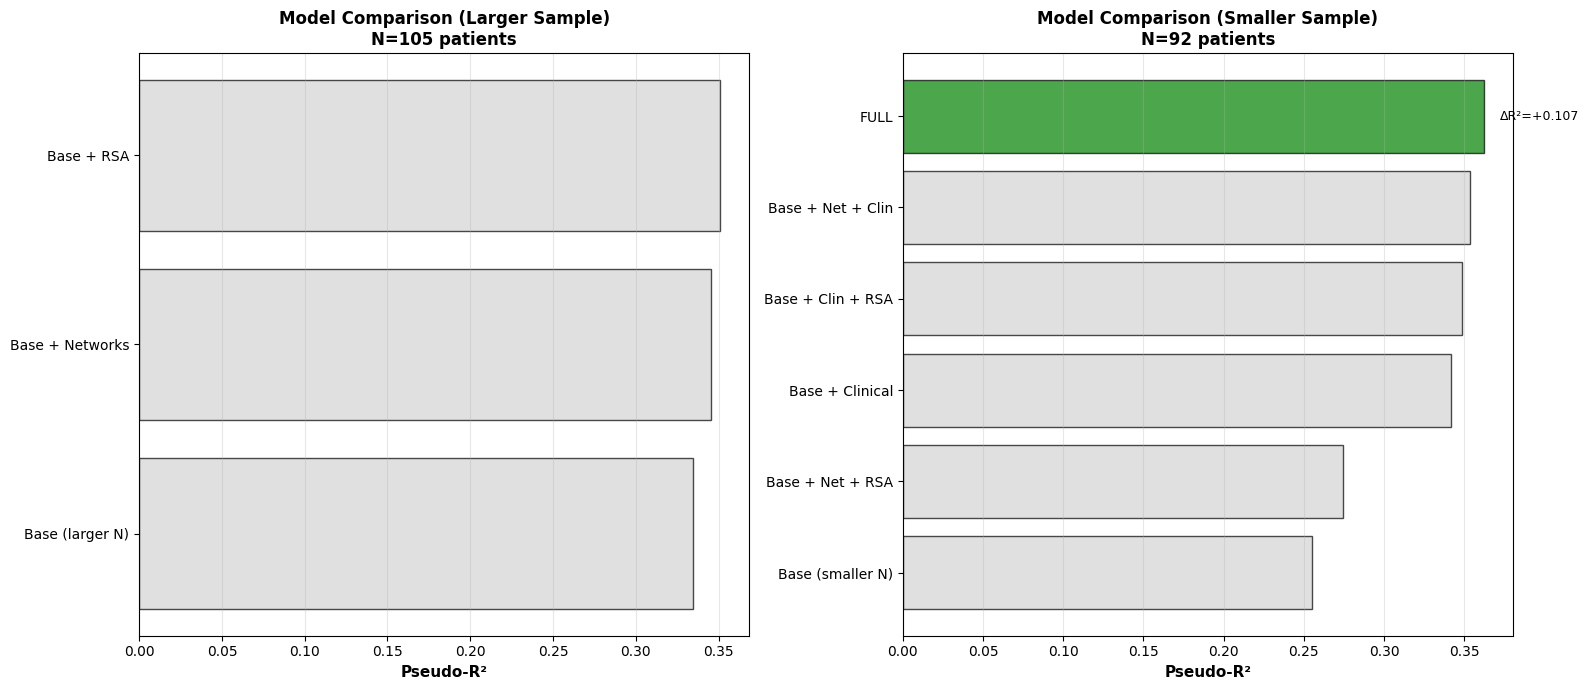

In [100]:
import pandas as pd
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.cov_struct import Exchangeable
from sklearn.preprocessing import StandardScaler

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def compute_variance(timeseries):
    if len(timeseries) < 2:
        return np.nan
    return np.var(timeseries)

def extract_rsa_variance(rsa_left, rsa_right):
    left = np.array(rsa_left).flatten()
    right = np.array(rsa_right).flatten()
    left = left[~np.isnan(left)]
    right = right[~np.isnan(right)]
    
    if len(left) < 10 or len(right) < 10:
        return None
    
    both = np.concatenate([left, right])
    return compute_variance(both)

def compute_pseudo_r2(observed, predicted):
    """Compute pseudo-R² as 1 - (SS_res / SS_tot)"""
    ss_res = np.sum((observed - predicted) ** 2)
    ss_tot = np.sum((observed - np.mean(observed)) ** 2)
    return 1 - (ss_res / ss_tot)

# ============================================================
# LOAD AND BUILD DATA
# ============================================================
print("="*70)
print("ABLATION STUDY: Networks vs Clinical vs RSA")
print("="*70)

with open('/mnt/compneuro/stroke_data_with_oculomotor_features_fixed.pkl', 'rb') as f:
    df = pd.DataFrame(pkl.load(f))

# Load network labels
network_labels = pd.read_csv(
    '/mnt/compneuro/MULTIBOOT/rest_blnd_can_raw/code/Yeo/Centroid_coordinates/'
    'Schaefer2018_400Parcels_7Networks_order_FSLMNI152_1mm.Centroid_RAS.csv',
    sep=','
)

network_labels['MainNetwork'] = network_labels['ROI Name'].str.extract(
    r'7Networks_[LR]H_(\w+)_')[0].str.split('_').str[0]

unique_networks = sorted(network_labels['MainNetwork'].unique())

# Create network mapping
network_mapping = {}
for network in unique_networks:
    roi_labels = network_labels[network_labels['MainNetwork'] == network]['ROI Label'].values
    indices = roi_labels - 1
    network_mapping[network] = indices.tolist()

# Build dataset
patients = df[df['subj_type'] == 0].copy()
acute = patients[patients['Session'] == 'acute']
followup_3mo = patients[patients['Session'] == 'followup']
followup_1yr = patients[patients['Session'] == 'followup2']

long_data = []

for patient_id in acute['ID'].unique():
    acute_row = acute[acute['ID'] == patient_id].iloc[0]
    
    rsa_var = extract_rsa_variance(acute_row.get('RSA_left'), 
                                    acute_row.get('RSA_right'))
    
    if rsa_var is None:
        continue
    
    age = acute_row.get('age')
    gender = acute_row.get('gender')
    lesion_vol = acute_row.get('lesion_volume_mm3')
    
    if pd.isna(age) or pd.isna(gender) or pd.isna(lesion_vol):
        continue
    
    def add_timepoint(session_row, timepoint, time_label):
        if session_row is None or len(session_row) == 0:
            return None
        
        row = session_row.iloc[0]
        
        nih_total = row.get('nih_total')
        if pd.isna(nih_total):
            return None
        
        ed_func = row.get('ed_func_mean_corrected')
        if ed_func is None or (isinstance(ed_func, float) and np.isnan(ed_func)):
            return None
        
        ed_func_array = np.array(ed_func).flatten()
        if len(ed_func_array) != 400:
            return None
        
        network_vals = {}
        for network, indices in network_mapping.items():
            network_vals[f'ed_func_{network}'] = np.mean(ed_func_array[indices])
        
        mes_tot_miss = row.get('mes_tot_miss', np.nan)
        bit_tot_miss = row.get('bit_tot_miss', np.nan)
        pos_acc_avg = row.get('pos_acc_avg', np.nan)
        
        return {
            'ID': patient_id,
            'timepoint': timepoint,
            'time_label': time_label,
            'nih_total': nih_total,
            'age': age,
            'gender': gender,
            'lesion_volume_mm3': lesion_vol,
            'RSA_both_var': rsa_var,
            **network_vals,
            'mes_tot_miss': mes_tot_miss,
            'bit_tot_miss': bit_tot_miss,
            'pos_acc_avg': pos_acc_avg
        }
    
    for session, tp, label in [(acute[acute['ID'] == patient_id], 0, 'acute'),
                               (followup_3mo[followup_3mo['ID'] == patient_id], 1, '3-month'),
                               (followup_1yr[followup_1yr['ID'] == patient_id], 2, '1-year')]:
        tp_data = add_timepoint(session, tp, label)
        if tp_data:
            long_data.append(tp_data)

long_df = pd.DataFrame(long_data)

print(f"\nDataset: {long_df['ID'].nunique()} patients, {len(long_df)} observations")

# Create datasets
base_predictors = ['timepoint', 'age', 'gender', 'lesion_volume_mm3']
network_predictors = [f'ed_func_{net}' for net in unique_networks]
clinical_predictors = ['mes_tot_miss', 'bit_tot_miss', 'pos_acc_avg']
rsa_predictor = ['RSA_both_var']

data_with_networks = long_df[base_predictors + network_predictors + rsa_predictor + ['nih_total', 'ID']].dropna()
data_with_clinical = long_df[base_predictors + network_predictors + clinical_predictors + rsa_predictor + ['nih_total', 'ID']].dropna()

print(f"\nSample sizes:")
print(f"  With networks:        {data_with_networks['ID'].nunique()} patients, {len(data_with_networks)} obs")
print(f"  With networks+clinical: {data_with_clinical['ID'].nunique()} patients, {len(data_with_clinical)} obs")

data_main = data_with_networks.copy()
data_clinical = data_with_clinical.copy()

# ============================================================
# STANDARDIZE
# ============================================================
continuous_vars_main = ['age', 'lesion_volume_mm3'] + network_predictors + rsa_predictor
continuous_vars_clinical = continuous_vars_main + clinical_predictors

scaler_main = StandardScaler()
data_main[continuous_vars_main] = scaler_main.fit_transform(data_main[continuous_vars_main])

scaler_clinical = StandardScaler()
data_clinical[continuous_vars_clinical] = scaler_clinical.fit_transform(data_clinical[continuous_vars_clinical])

# ============================================================
# FIT ABLATION MODELS
# ============================================================
print("\n" + "="*70)
print("ABLATION STUDY: COMPARING PREDICTOR SETS")
print("="*70)

results = []

def fit_and_record(formula, data, model_name, n_predictors):
    """Fit GEE and record metrics"""
    try:
        model = GEE.from_formula(
            formula,
            groups='ID',
            data=data,
            cov_struct=Exchangeable(),
            family=sm.families.Gaussian()
        )
        result = model.fit()
        
        # Get predictions
        predicted = result.fittedvalues
        observed = data['nih_total'].values
        
        # Compute pseudo-R²
        pseudo_r2 = compute_pseudo_r2(observed, predicted)
        
        # Get QIC - it's a property, not a method
        try:
            qic_val = float(result.qic)
        except:
            qic_val = np.nan
        
        return {
            'model': model_name,
            'n_predictors': n_predictors,
            'n_obs': len(data),
            'n_patients': data['ID'].nunique(),
            'pseudo_r2': pseudo_r2,
            'qic': qic_val,
            'converged': result.converged
        }
    except Exception as e:
        print(f"  ⚠️  {model_name} failed: {e}")
        return None

# BASE MODEL
print("\n--- BASE MODEL (time + demographics) ---")

result_base_main = fit_and_record(
    'nih_total ~ timepoint + age + gender + lesion_volume_mm3',
    data_main,
    'Base (larger N)',
    4
)
if result_base_main:
    results.append(result_base_main)
    print(f"  N={result_base_main['n_patients']} patients, Pseudo-R²={result_base_main['pseudo_r2']:.3f}, QIC={result_base_main['qic']:.1f}")

result_base_clinical = fit_and_record(
    'nih_total ~ timepoint + age + gender + lesion_volume_mm3',
    data_clinical,
    'Base (smaller N)',
    4
)
if result_base_clinical:
    results.append(result_base_clinical)
    print(f"  N={result_base_clinical['n_patients']} patients, Pseudo-R²={result_base_clinical['pseudo_r2']:.3f}, QIC={result_base_clinical['qic']:.1f}")

# INDIVIDUAL ADDITIONS
print("\n--- ADDING PREDICTOR SETS INDIVIDUALLY ---")

print("\n1. Base + Networks (7)")
formula_networks = 'nih_total ~ timepoint + age + gender + lesion_volume_mm3 + ' + ' + '.join(network_predictors)
result_networks = fit_and_record(formula_networks, data_main, 'Base + Networks', 11)
if result_networks:
    results.append(result_networks)
    delta_r2 = result_networks['pseudo_r2'] - result_base_main['pseudo_r2']
    print(f"  Pseudo-R²={result_networks['pseudo_r2']:.3f} (ΔR²={delta_r2:+.3f})")

print("\n2. Base + RSA")
result_rsa = fit_and_record(
    'nih_total ~ timepoint + age + gender + lesion_volume_mm3 + RSA_both_var',
    data_main,
    'Base + RSA',
    5
)
if result_rsa:
    results.append(result_rsa)
    delta_r2 = result_rsa['pseudo_r2'] - result_base_main['pseudo_r2']
    print(f"  Pseudo-R²={result_rsa['pseudo_r2']:.3f} (ΔR²={delta_r2:+.3f})")

print("\n3. Base + Clinical (3)")
formula_clinical = 'nih_total ~ timepoint + age + gender + lesion_volume_mm3 + mes_tot_miss + bit_tot_miss + pos_acc_avg'
result_clinical = fit_and_record(formula_clinical, data_clinical, 'Base + Clinical', 7)
if result_clinical:
    results.append(result_clinical)
    delta_r2 = result_clinical['pseudo_r2'] - result_base_clinical['pseudo_r2']
    print(f"  Pseudo-R²={result_clinical['pseudo_r2']:.3f} (ΔR²={delta_r2:+.3f})")

# COMBINATIONS
print("\n--- COMBINATIONS (on smaller N with clinical data) ---")

print("\n4. Base + Networks + Clinical")
formula_net_clin = 'nih_total ~ timepoint + age + gender + lesion_volume_mm3 + ' + \
                   ' + '.join(network_predictors) + ' + ' + ' + '.join(clinical_predictors)
result_net_clin = fit_and_record(formula_net_clin, data_clinical, 'Base + Net + Clin', 14)
if result_net_clin:
    results.append(result_net_clin)
    delta_r2 = result_net_clin['pseudo_r2'] - result_base_clinical['pseudo_r2']
    print(f"  Pseudo-R²={result_net_clin['pseudo_r2']:.3f} (ΔR²={delta_r2:+.3f})")

print("\n5. Base + Networks + RSA")
formula_net_rsa = 'nih_total ~ timepoint + age + gender + lesion_volume_mm3 + ' + \
                  ' + '.join(network_predictors) + ' + RSA_both_var'
result_net_rsa = fit_and_record(formula_net_rsa, data_clinical, 'Base + Net + RSA', 12)
if result_net_rsa:
    results.append(result_net_rsa)
    delta_r2 = result_net_rsa['pseudo_r2'] - result_base_clinical['pseudo_r2']
    print(f"  Pseudo-R²={result_net_rsa['pseudo_r2']:.3f} (ΔR²={delta_r2:+.3f})")

print("\n6. Base + Clinical + RSA")
formula_clin_rsa = 'nih_total ~ timepoint + age + gender + lesion_volume_mm3 + ' + \
                   ' + '.join(clinical_predictors) + ' + RSA_both_var'
result_clin_rsa = fit_and_record(formula_clin_rsa, data_clinical, 'Base + Clin + RSA', 8)
if result_clin_rsa:
    results.append(result_clin_rsa)
    delta_r2 = result_clin_rsa['pseudo_r2'] - result_base_clinical['pseudo_r2']
    print(f"  Pseudo-R²={result_clin_rsa['pseudo_r2']:.3f} (ΔR²={delta_r2:+.3f})")

print("\n7. FULL (Base + Networks + Clinical + RSA)")
formula_full = 'nih_total ~ timepoint + age + gender + lesion_volume_mm3 + ' + \
               ' + '.join(network_predictors) + ' + ' + ' + '.join(clinical_predictors) + ' + RSA_both_var'
result_full = fit_and_record(formula_full, data_clinical, 'FULL', 15)
if result_full:
    results.append(result_full)
    delta_r2 = result_full['pseudo_r2'] - result_base_clinical['pseudo_r2']
    print(f"  Pseudo-R²={result_full['pseudo_r2']:.3f} (ΔR²={delta_r2:+.3f})")

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*70)
print("SUMMARY: MODEL COMPARISON")
print("="*70)

results_df = pd.DataFrame(results)

# Separate by sample size
results_large = results_df[results_df['n_patients'] == result_base_main['n_patients']].copy()
results_small = results_df[results_df['n_patients'] == result_base_clinical['n_patients']].copy()

# Compute ΔR²
if len(results_large) > 0:
    base_r2_large = results_large[results_large['model'].str.contains('Base')]['pseudo_r2'].iloc[0]
    results_large['delta_r2'] = results_large['pseudo_r2'] - base_r2_large

if len(results_small) > 0:
    base_r2_small = results_small[results_small['model'].str.contains('Base')]['pseudo_r2'].iloc[0]
    results_small['delta_r2'] = results_small['pseudo_r2'] - base_r2_small

print("\n📊 LARGER SAMPLE (Networks and RSA, no clinical):")
print("-" * 70)
if len(results_large) > 0:
    display_cols = ['model', 'n_predictors', 'pseudo_r2', 'delta_r2']
    print(results_large[display_cols].to_string(index=False))

print("\n\n📊 SMALLER SAMPLE (All predictors including clinical):")
print("-" * 70)
if len(results_small) > 0:
    display_cols = ['model', 'n_predictors', 'pseudo_r2', 'delta_r2']
    print(results_small[display_cols].to_string(index=False))

# Key findings
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)

if len(results_large) > 1:
    best_large = results_large[results_large['model'] != 'Base (larger N)'].sort_values('delta_r2', ascending=False).iloc[0]
    print(f"\n✅ LARGER SAMPLE: Best single addition:")
    print(f"   {best_large['model']}: ΔR²={best_large['delta_r2']:+.3f}")

if len(results_small) > 1:
    additions_small = results_small[~results_small['model'].str.contains('Base|FULL')].copy()
    if len(additions_small) > 0:
        best_small = additions_small.sort_values('delta_r2', ascending=False).iloc[0]
        print(f"\n✅ SMALLER SAMPLE: Best single addition:")
        print(f"   {best_small['model']}: ΔR²={best_small['delta_r2']:+.3f}")

# ============================================================
# VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Larger sample
if len(results_large) > 0:
    models_large = results_large.sort_values('pseudo_r2')
    colors = ['lightgray' if 'Base' in m else 'coral' for m in models_large['model']]
    
    axes[0].barh(range(len(models_large)), models_large['pseudo_r2'],
                color=colors, edgecolor='black', alpha=0.7)
    axes[0].set_yticks(range(len(models_large)))
    axes[0].set_yticklabels(models_large['model'], fontsize=10)
    axes[0].set_xlabel('Pseudo-R²', fontweight='bold', fontsize=11)
    axes[0].set_title(f'Model Comparison (Larger Sample)\nN={result_base_main["n_patients"]} patients',
                     fontweight='bold', fontsize=12)
    axes[0].grid(alpha=0.3, axis='x')
    
    for i, (idx, row) in enumerate(models_large.iterrows()):
        if 'Base' not in row['model']:
            axes[0].text(row['pseudo_r2'] + 0.01, i,
                        f"ΔR²={row['delta_r2']:+.3f}",
                        va='center', fontsize=9)

# Plot 2: Smaller sample
if len(results_small) > 0:
    models_small = results_small.sort_values('pseudo_r2')
    colors2 = ['lightgray' if 'Base' in m else 
               'green' if 'FULL' in m else 'coral' 
               for m in models_small['model']]
    
    axes[1].barh(range(len(models_small)), models_small['pseudo_r2'],
                color=colors2, edgecolor='black', alpha=0.7)
    axes[1].set_yticks(range(len(models_small)))
    axes[1].set_yticklabels(models_small['model'], fontsize=10)
    axes[1].set_xlabel('Pseudo-R²', fontweight='bold', fontsize=11)
    axes[1].set_title(f'Model Comparison (Smaller Sample)\nN={result_base_clinical["n_patients"]} patients',
                     fontweight='bold', fontsize=12)
    axes[1].grid(alpha=0.3, axis='x')
    
    for i, (idx, row) in enumerate(models_small.iterrows()):
        if 'Base' not in row['model']:
            axes[1].text(row['pseudo_r2'] + 0.01, i,
                        f"ΔR²={row['delta_r2']:+.3f}",
                        va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/mnt/compneuro/ablation_study.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: ablation_study.png")

results_df.to_csv('/mnt/compneuro/ablation_results.csv', index=False)
print(f"✅ Saved: ablation_results.csv")

print("\n" + "="*70)
print("ABLATION STUDY COMPLETE")
print("="*70)

In [132]:
pwd

'/mnt/compneuro'

In [103]:
import pandas as pd
import numpy as np

# Stroke only
patients = df[df['subj_type'] == 0].copy()

# ============================================================
# DEFINE GROUPS
# ============================================================

patients['visual_group'] = (
    patients['visual_acute_ad___1'] == 1
)

patients['neglect_group'] = (
    patients['attention_acute_ad___1'] == 1
)

patients['oculomotor_group'] = (
    patients['nih2'] > 0
)

# ============================================================
# SUBJECT-LEVEL GROUP MEMBERSHIP
# (collapse across sessions)
# ============================================================

group_summary = patients.groupby('ID').agg({
    'visual_group': 'max',
    'neglect_group': 'max',
    'oculomotor_group': 'max'
})

print("="*60)
print("GROUP COUNTS")
print("="*60)

for col in ['visual_group', 'neglect_group', 'oculomotor_group']:

    n_yes = group_summary[col].sum()
    n_no = len(group_summary) - n_yes

    print(f"\n{col}")
    print(f"  YES: {n_yes}")
    print(f"  NO:  {n_no}")

GROUP COUNTS

visual_group
  YES: 15
  NO:  138

neglect_group
  YES: 20
  NO:  133

oculomotor_group
  YES: 11
  NO:  142


In [104]:
# Sessions with NIHSS
nih_available = patients.dropna(subset=['nih_total'])

# Count sessions per patient
session_counts = nih_available.groupby('ID')['Session'].nunique()

print("\nPatients with >=2 NIHSS sessions:")
print((session_counts >= 2).sum())


Patients with >=2 NIHSS sessions:
94


In [105]:
for col in ['visual_group', 'neglect_group', 'oculomotor_group']:

    ids = group_summary[group_summary[col] == 1].index

    temp = nih_available[nih_available['ID'].isin(ids)]

    counts = temp.groupby('ID')['Session'].nunique()

    print(f"\n{col}")
    print(f"Patients with >=2 sessions: {(counts >= 2).sum()}")


visual_group
Patients with >=2 sessions: 11

neglect_group
Patients with >=2 sessions: 10

oculomotor_group
Patients with >=2 sessions: 7


In [106]:
patients = df[df['subj_type'] == 0].copy()

# ============================================================
# DEFINE ACUTE DEFICIT GROUPS
# ============================================================

patients['visual_group'] = (
    patients['visual_acute_ad___1'] == 1
)

patients['neglect_group'] = (
    patients['attention_acute_ad___1'] == 1
)

patients['oculomotor_group'] = (
    patients['nih2'] > 0
)

# Combined deficit
patients['any_deficit'] = (
    patients['visual_group'] |
    patients['neglect_group'] |
    patients['oculomotor_group']
)

In [107]:
acute = patients[patients['Session'] == 'acute'].copy()

In [108]:
def extract_rsa_var(rsa_left, rsa_right):

    left = np.array(rsa_left).flatten()
    right = np.array(rsa_right).flatten()

    left = left[~np.isnan(left)]
    right = right[~np.isnan(right)]

    if len(left) < 10 or len(right) < 10:
        return np.nan

    both = np.concatenate([left, right])

    return np.var(both)

In [109]:
acute['RSA_both_var'] = acute.apply(
    lambda row: extract_rsa_var(
        row['RSA_left'],
        row['RSA_right']
    ),
    axis=1
)

In [110]:
baseline = acute[[
    'ID',
    'RSA_both_var',
    'any_deficit',
    'age',
    'lesion_volume_mm3'
]].copy()

In [111]:
baseline = baseline.dropna(subset=['RSA_both_var'])

In [112]:
long_df = patients[[
    'ID',
    'Session',
    'nih_total'
]].copy()

In [113]:
long_df = long_df.dropna(subset=['nih_total'])

In [114]:
long_df['time_binary'] = long_df['Session'].map({
    'acute': 0,
    'followup': 1,
    'followup2': 1
})

In [115]:
gee_df = long_df.merge(
    baseline,
    on='ID',
    how='inner'
)

In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

gee_df['RSA_z'] = scaler.fit_transform(
    gee_df[['RSA_both_var']]
)

gee_df['age_z'] = scaler.fit_transform(
    gee_df[['age']]
)

gee_df['lesion_z'] = scaler.fit_transform(
    gee_df[['lesion_volume_mm3']]
)

In [117]:
print("="*60)
print("FINAL GEE SAMPLE")
print("="*60)

print(f"Rows: {len(gee_df)}")
print(f"Subjects: {gee_df['ID'].nunique()}")

print("\nDeficit group counts:")
print(gee_df.groupby('any_deficit')['ID'].nunique())

FINAL GEE SAMPLE
Rows: 265
Subjects: 124

Deficit group counts:
any_deficit
False    95
True     29
Name: ID, dtype: int64


In [118]:
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.cov_struct import Exchangeable
from statsmodels.genmod.families import Gaussian

In [128]:
# ------------------------------------------------------------
# 1. Build acute NIHSS at subject level (SAFE: one value per ID)
# ------------------------------------------------------------

acute_nih = (
    patients.loc[patients['Session'] == 'acute', ['ID', 'nih_total']]
    .groupby('ID', as_index=False)
    .first()
    .rename(columns={'nih_total': 'nih_acute'})
)

# ------------------------------------------------------------
# 2. Merge into GEE dataframe
# ------------------------------------------------------------

gee_df = gee_df.merge(acute_nih, on='ID', how='left')

# ------------------------------------------------------------
# 3. Check column exists (debug safety)
# ------------------------------------------------------------

print("nih_acute" in gee_df.columns)
print(gee_df.columns)

# ------------------------------------------------------------
# 4. Standardize safely (handle missing values)
# ------------------------------------------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

gee_df['nih_acute_z'] = scaler.fit_transform(
    gee_df[['nih_acute']].fillna(gee_df['nih_acute'].median())
)

True
Index(['ID', 'Session', 'nih_total', 'time_binary', 'RSA_both_var',
       'any_deficit', 'age', 'lesion_volume_mm3', 'RSA_z', 'age_z', 'lesion_z',
       'nih_acute_x', 'nih_acute_y', 'nih_acute'],
      dtype='object')


In [129]:
model = GEE.from_formula(
    formula="""
    nih_total ~

time_binary *
RSA_z *
any_deficit

+ nih_acute_z
+ age_z
+ lesion_z
    """,

    groups="ID",

    cov_struct=Exchangeable(),

    family=Gaussian(),

    data=gee_df
)

In [130]:
result = model.fit()

print(result.summary())

                               GEE Regression Results                              
Dep. Variable:                   nih_total   No. Observations:                  225
Model:                                 GEE   No. clusters:                      105
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                   3
Family:                           Gaussian   Mean cluster size:                 2.1
Dependence structure:         Exchangeable   Num. iterations:                     7
Date:                     Tue, 19 May 2026   Scale:                           2.546
Covariance type:                    robust   Time:                         22:50:23
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                       

SUBGROUP ANALYSIS: RSA×Time by Clinical Phenotype

BUILDING DATASET WITH CLINICAL PHENOTYPES

Total dataset: 105 patients, 225 observations

CLINICAL SUBGROUP DEFINITIONS

📋 Clinical Cutoffs (Standard Thresholds):
  1. NEGLECT:        mes_tot_miss >0 (any neglect)
  2. OCULOMOTOR:     pos_acc_avg <0.85 (below normal)
  3. VISUAL FIELD:   mes_tot_miss >10 (severe peripheral deficit)

📊 Sample Sizes (can overlap):
  Total patients:        105
  WITH Neglect:          73 (69.5%)
  WITH Oculomotor def:   15 (14.3%)
  WITH Visual field:     27 (25.7%)

  Multiple deficits (all 3): 9

📈 Clinical Characteristics by Group:

  Neglect (N=73):
    mes_tot_miss: 13.3 ± 17.0
    pos_acc_avg:  0.87 ± 0.20

  Oculomotor (N=15):
    mes_tot_miss: 25.0 ± 22.0
    pos_acc_avg:  0.61 ± 0.21

  Visual Field (N=27):
    mes_tot_miss: 30.7 ± 17.0
    pos_acc_avg:  0.71 ± 0.27

GEE MODELS: RSA×Time BY CLINICAL SUBGROUP

--- Testing RSA×Time in Each Clinical Subgroup ---

🔍 NEGLECT GROUP
  N=73 patients, 149

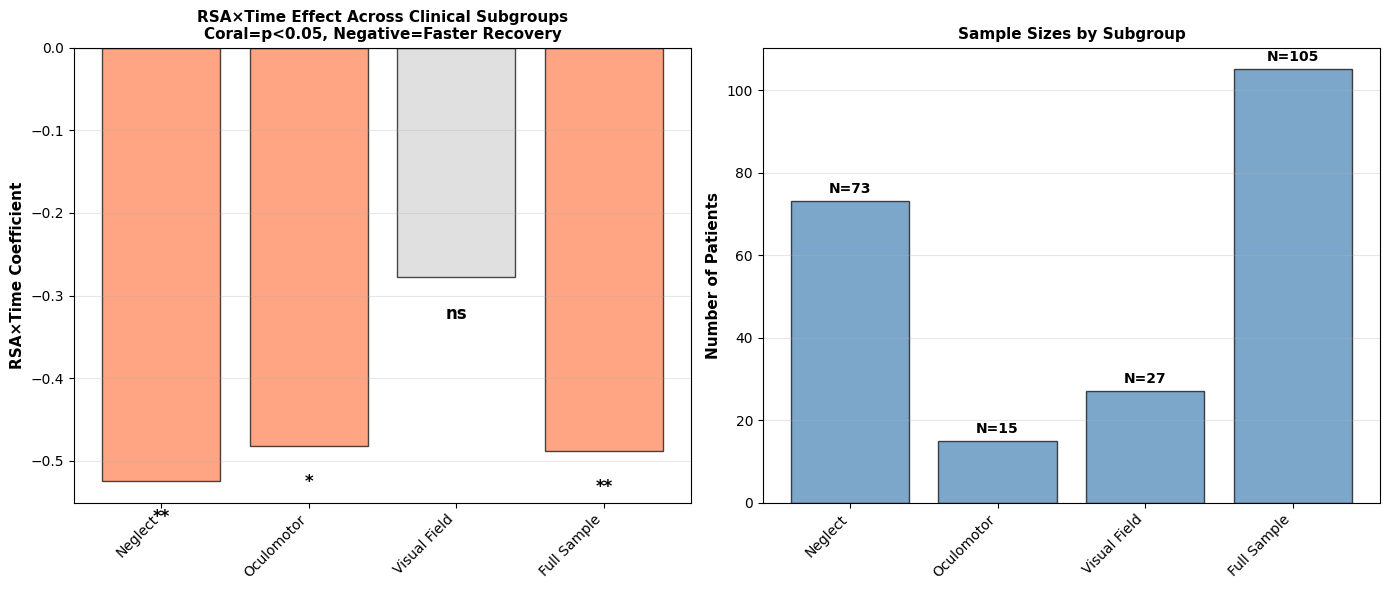

In [131]:
import pandas as pd
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.cov_struct import Exchangeable
from sklearn.preprocessing import StandardScaler

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def compute_variance(timeseries):
    if len(timeseries) < 2:
        return np.nan
    return np.var(timeseries)

def extract_rsa_variance(rsa_left, rsa_right):
    left = np.array(rsa_left).flatten()
    right = np.array(rsa_right).flatten()
    left = left[~np.isnan(left)]
    right = right[~np.isnan(right)]
    
    if len(left) < 10 or len(right) < 10:
        return None
    
    both = np.concatenate([left, right])
    return compute_variance(both)

# ============================================================
# LOAD DATA
# ============================================================
print("="*70)
print("SUBGROUP ANALYSIS: RSA×Time by Clinical Phenotype")
print("="*70)

with open('/mnt/compneuro/stroke_data_with_oculomotor_features_fixed.pkl', 'rb') as f:
    df = pd.DataFrame(pkl.load(f))

patients = df[df['subj_type'] == 0].copy()
acute = patients[patients['Session'] == 'acute']
followup_3mo = patients[patients['Session'] == 'followup']
followup_1yr = patients[patients['Session'] == 'followup2']

# ============================================================
# BUILD LONGITUDINAL DATASET
# ============================================================
print("\n" + "="*70)
print("BUILDING DATASET WITH CLINICAL PHENOTYPES")
print("="*70)

long_data = []

for patient_id in acute['ID'].unique():
    acute_row = acute[acute['ID'] == patient_id].iloc[0]
    
    # RSA
    rsa_var = extract_rsa_variance(acute_row.get('RSA_left'), 
                                    acute_row.get('RSA_right'))
    
    if rsa_var is None:
        continue
    
    # Demographics
    age = acute_row.get('age')
    gender = acute_row.get('gender')
    lesion_vol = acute_row.get('lesion_volume_mm3')
    
    if pd.isna(age) or pd.isna(gender) or pd.isna(lesion_vol):
        continue
    
    # CLINICAL PHENOTYPES (at acute)
    mes_tot_miss = acute_row.get('mes_tot_miss', np.nan)
    bit_tot_miss = acute_row.get('bit_tot_miss', np.nan)
    pos_acc_avg = acute_row.get('pos_acc_avg', np.nan)
    
    # Define groups (can overlap)
    has_neglect = mes_tot_miss > 0 if not pd.isna(mes_tot_miss) else False
    has_oculomotor = pos_acc_avg < 0.85 if not pd.isna(pos_acc_avg) else False
    # For visual field - check if we have specific measures
    # Otherwise use severe peripheral deficit as proxy
    has_vf_loss = mes_tot_miss > 10 if not pd.isna(mes_tot_miss) else False
    
    # Add timepoints
    def add_timepoint(session_row, timepoint, time_label):
        if session_row is None or len(session_row) == 0:
            return None
        
        row = session_row.iloc[0]
        
        nih_total = row.get('nih_total')
        if pd.isna(nih_total):
            return None
        
        return {
            'ID': patient_id,
            'timepoint': timepoint,
            'time_label': time_label,
            'nih_total': nih_total,
            'age': age,
            'gender': gender,
            'lesion_volume_mm3': lesion_vol,
            'RSA_both_var': rsa_var,
            'has_neglect': has_neglect,
            'has_oculomotor': has_oculomotor,
            'has_vf_loss': has_vf_loss,
            'mes_tot_miss_acute': mes_tot_miss,
            'pos_acc_avg_acute': pos_acc_avg
        }
    
    for session, tp, label in [(acute[acute['ID'] == patient_id], 0, 'acute'),
                               (followup_3mo[followup_3mo['ID'] == patient_id], 1, '3-month'),
                               (followup_1yr[followup_1yr['ID'] == patient_id], 2, '1-year')]:
        tp_data = add_timepoint(session, tp, label)
        if tp_data:
            long_data.append(tp_data)

long_df = pd.DataFrame(long_data)

print(f"\nTotal dataset: {long_df['ID'].nunique()} patients, {len(long_df)} observations")

# ============================================================
# DEFINE CLINICAL SUBGROUPS
# ============================================================
print("\n" + "="*70)
print("CLINICAL SUBGROUP DEFINITIONS")
print("="*70)

print("\n📋 Clinical Cutoffs (Standard Thresholds):")
print("  1. NEGLECT:        mes_tot_miss >0 (any neglect)")
print("  2. OCULOMOTOR:     pos_acc_avg <0.85 (below normal)")
print("  3. VISUAL FIELD:   mes_tot_miss >10 (severe peripheral deficit)")

# Count patients in each group
patient_groups = long_df.groupby('ID').first()

n_neglect = patient_groups['has_neglect'].sum()
n_oculomotor = patient_groups['has_oculomotor'].sum()
n_vf_loss = patient_groups['has_vf_loss'].sum()
n_total = len(patient_groups)

print(f"\n📊 Sample Sizes (can overlap):")
print(f"  Total patients:        {n_total}")
print(f"  WITH Neglect:          {n_neglect} ({n_neglect/n_total*100:.1f}%)")
print(f"  WITH Oculomotor def:   {n_oculomotor} ({n_oculomotor/n_total*100:.1f}%)")
print(f"  WITH Visual field:     {n_vf_loss} ({n_vf_loss/n_total*100:.1f}%)")

# Check overlap
has_all = (patient_groups['has_neglect'] & 
           patient_groups['has_oculomotor'] & 
           patient_groups['has_vf_loss']).sum()

print(f"\n  Multiple deficits (all 3): {has_all}")

# Descriptive stats by group
print("\n📈 Clinical Characteristics by Group:")

for group_name, group_col in [('Neglect', 'has_neglect'),
                               ('Oculomotor', 'has_oculomotor'),
                               ('Visual Field', 'has_vf_loss')]:
    
    group_pts = patient_groups[patient_groups[group_col]]
    
    if len(group_pts) > 0:
        print(f"\n  {group_name} (N={len(group_pts)}):")
        if 'mes_tot_miss_acute' in group_pts.columns:
            print(f"    mes_tot_miss: {group_pts['mes_tot_miss_acute'].mean():.1f} ± {group_pts['mes_tot_miss_acute'].std():.1f}")
        if 'pos_acc_avg_acute' in group_pts.columns:
            print(f"    pos_acc_avg:  {group_pts['pos_acc_avg_acute'].mean():.2f} ± {group_pts['pos_acc_avg_acute'].std():.2f}")

# ============================================================
# FIT GEE MODELS BY SUBGROUP
# ============================================================
print("\n" + "="*70)
print("GEE MODELS: RSA×Time BY CLINICAL SUBGROUP")
print("="*70)

results = []

def fit_gee_subgroup(data, group_name):
    """Fit GEE with RSA×time in subgroup"""
    
    if len(data) < 20:
        print(f"\n⚠️  {group_name}: Too few observations (N={len(data)})")
        return None
    
    # Standardize continuous predictors
    data_scaled = data.copy()
    continuous_vars = ['age', 'lesion_volume_mm3', 'RSA_both_var']
    scaler = StandardScaler()
    data_scaled[continuous_vars] = scaler.fit_transform(data[continuous_vars])
    
    # Create interaction
    data_scaled['rsa_time'] = data_scaled['RSA_both_var'] * data_scaled['timepoint']
    
    try:
        # Fit GEE
        model = GEE.from_formula(
            'nih_total ~ timepoint + age + gender + lesion_volume_mm3 + RSA_both_var + rsa_time',
            groups='ID',
            data=data_scaled,
            cov_struct=Exchangeable(),
            family=sm.families.Gaussian()
        )
        result = model.fit()
        
        return {
            'group': group_name,
            'n_patients': data['ID'].nunique(),
            'n_obs': len(data),
            'rsa_main_coef': result.params['RSA_both_var'],
            'rsa_main_p': result.pvalues['RSA_both_var'],
            'rsa_time_coef': result.params['rsa_time'],
            'rsa_time_p': result.pvalues['rsa_time'],
            'time_coef': result.params['timepoint'],
            'time_p': result.pvalues['timepoint'],
            'converged': result.converged
        }
    
    except Exception as e:
        print(f"\n⚠️  {group_name} failed: {e}")
        return None

# Test each subgroup
print("\n--- Testing RSA×Time in Each Clinical Subgroup ---")

# NEGLECT
print("\n🔍 NEGLECT GROUP")
data_neglect = long_df[long_df['has_neglect']].copy()
result_neglect = fit_gee_subgroup(data_neglect, 'Neglect')
if result_neglect:
    results.append(result_neglect)
    print(f"  N={result_neglect['n_patients']} patients, {result_neglect['n_obs']} obs")
    print(f"  RSA main:   β={result_neglect['rsa_main_coef']:.3f}, p={result_neglect['rsa_main_p']:.4f}")
    print(f"  RSA×time:   β={result_neglect['rsa_time_coef']:.3f}, p={result_neglect['rsa_time_p']:.4f}")

# OCULOMOTOR
print("\n🔍 OCULOMOTOR DEFICIT GROUP")
data_oculomotor = long_df[long_df['has_oculomotor']].copy()
result_oculomotor = fit_gee_subgroup(data_oculomotor, 'Oculomotor')
if result_oculomotor:
    results.append(result_oculomotor)
    print(f"  N={result_oculomotor['n_patients']} patients, {result_oculomotor['n_obs']} obs")
    print(f"  RSA main:   β={result_oculomotor['rsa_main_coef']:.3f}, p={result_oculomotor['rsa_main_p']:.4f}")
    print(f"  RSA×time:   β={result_oculomotor['rsa_time_coef']:.3f}, p={result_oculomotor['rsa_time_p']:.4f}")

# VISUAL FIELD
print("\n🔍 VISUAL FIELD LOSS GROUP")
data_vf = long_df[long_df['has_vf_loss']].copy()
result_vf = fit_gee_subgroup(data_vf, 'Visual Field')
if result_vf:
    results.append(result_vf)
    print(f"  N={result_vf['n_patients']} patients, {result_vf['n_obs']} obs")
    print(f"  RSA main:   β={result_vf['rsa_main_coef']:.3f}, p={result_vf['rsa_main_p']:.4f}")
    print(f"  RSA×time:   β={result_vf['rsa_time_coef']:.3f}, p={result_vf['rsa_time_p']:.4f}")

# FULL SAMPLE (for comparison)
print("\n🔍 FULL SAMPLE (reference)")
result_full = fit_gee_subgroup(long_df, 'Full Sample')
if result_full:
    results.append(result_full)
    print(f"  N={result_full['n_patients']} patients, {result_full['n_obs']} obs")
    print(f"  RSA main:   β={result_full['rsa_main_coef']:.3f}, p={result_full['rsa_main_p']:.4f}")
    print(f"  RSA×time:   β={result_full['rsa_time_coef']:.3f}, p={result_full['rsa_time_p']:.4f}")

# ============================================================
# COMPARISON TABLE
# ============================================================
print("\n" + "="*70)
print("SUMMARY: RSA×TIME ACROSS CLINICAL PHENOTYPES")
print("="*70)

if len(results) > 0:
    results_df = pd.DataFrame(results)
    
    # Display table
    display_cols = ['group', 'n_patients', 'n_obs', 'rsa_time_coef', 'rsa_time_p']
    print("\n" + results_df[display_cols].to_string(index=False))
    
    # Significance summary
    print("\n✅ Significant RSA×Time (p<0.05):")
    sig_results = results_df[results_df['rsa_time_p'] < 0.05]
    
    if len(sig_results) > 0:
        for idx, row in sig_results.iterrows():
            direction = "faster" if row['rsa_time_coef'] < 0 else "slower"
            print(f"  {row['group']:15s}: β={row['rsa_time_coef']:.3f}, p={row['rsa_time_p']:.4f} → {direction} recovery")
    else:
        print("  None")
    
    # ============================================================
    # VISUALIZATION
    # ============================================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: RSA×time coefficients
    groups = results_df['group'].tolist()
    coefs = results_df['rsa_time_coef'].tolist()
    pvals = results_df['rsa_time_p'].tolist()
    colors = ['coral' if p < 0.05 else 'lightgray' for p in pvals]
    
    axes[0].bar(range(len(groups)), coefs, color=colors, edgecolor='black', alpha=0.7)
    axes[0].set_xticks(range(len(groups)))
    axes[0].set_xticklabels(groups, fontsize=10, rotation=45, ha='right')
    axes[0].axhline(0, color='black', linewidth=1.5)
    axes[0].set_ylabel('RSA×Time Coefficient', fontweight='bold', fontsize=11)
    axes[0].set_title('RSA×Time Effect Across Clinical Subgroups\nCoral=p<0.05, Negative=Faster Recovery',
                     fontweight='bold', fontsize=11)
    axes[0].grid(alpha=0.3, axis='y')
    
    # Add p-values
    for i, (coef, p) in enumerate(zip(coefs, pvals)):
        sig_marker = '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        axes[0].text(i, coef + 0.05 if coef > 0 else coef - 0.05,
                    sig_marker, ha='center', fontsize=12, fontweight='bold')
    
    # Plot 2: Sample sizes
    n_patients = results_df['n_patients'].tolist()
    
    axes[1].bar(range(len(groups)), n_patients, color='steelblue', 
               edgecolor='black', alpha=0.7)
    axes[1].set_xticks(range(len(groups)))
    axes[1].set_xticklabels(groups, fontsize=10, rotation=45, ha='right')
    axes[1].set_ylabel('Number of Patients', fontweight='bold', fontsize=11)
    axes[1].set_title('Sample Sizes by Subgroup', fontweight='bold', fontsize=11)
    axes[1].grid(alpha=0.3, axis='y')
    
    # Add counts
    for i, n in enumerate(n_patients):
        axes[1].text(i, n + 2, f'N={n}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('/mnt/compneuro/subgroup_rsa_time.png', dpi=300, bbox_inches='tight')
    print(f"\n✅ Saved: subgroup_rsa_time.png")
    
    # Save results
    results_df.to_csv('/mnt/compneuro/subgroup_results.csv', index=False)
    print(f"✅ Saved: subgroup_results.csv")

print("\n" + "="*70)
print("SUBGROUP ANALYSIS COMPLETE")
print("="*70)
print("Question: Does RSA×time differ by clinical phenotype?")
print("="*70)

In [95]:
import pandas as pd
import numpy as np
import pickle as pkl

# Load data
with open('/mnt/compneuro/stroke_data_with_oculomotor_features_fixed.pkl', 'rb') as f:
    df = pd.DataFrame(pkl.load(f))

patients = df[df['subj_type'] == 0].copy()
acute = patients[patients['Session'] == 'acute']

print("Debugging data availability:")
print(f"\nTotal acute patients: {len(acute)}")

# Check RSA
sample = acute.iloc[0]
print(f"\nChecking first patient:")
print(f"  RSA_left: {type(sample.get('RSA_left'))}")
print(f"  RSA_right: {type(sample.get('RSA_right'))}")
print(f"  age: {sample.get('age')}")
print(f"  sex: {sample.get('sex')}")
print(f"  ed_func: {type(sample.get('ed_func_mean_corrected'))}")

# Check clinical variables
print(f"\n  mes_tot_miss: {sample.get('mes_tot_miss')}")
print(f"  bit_tot_miss: {sample.get('bit_tot_miss')}")
print(f"  pos_acc_avg: {sample.get('pos_acc_avg')}")

# Count availability
print(f"\nAvailability across all acute patients:")
print(f"  mes_tot_miss: {acute['mes_tot_miss'].notna().sum()}/{len(acute)}")
print(f"  bit_tot_miss: {acute['bit_tot_miss'].notna().sum()}/{len(acute)}")
print(f"  pos_acc_avg: {acute['pos_acc_avg'].notna().sum()}/{len(acute)}")

# Try at 3-month
followup_3mo = patients[patients['Session'] == 'followup']
print(f"\n3-month patients: {len(followup_3mo)}")
if len(followup_3mo) > 0:
    print(f"  mes_tot_miss: {followup_3mo['mes_tot_miss'].notna().sum()}/{len(followup_3mo)}")
    print(f"  bit_tot_miss: {followup_3mo['bit_tot_miss'].notna().sum()}/{len(followup_3mo)}")
    print(f"  pos_acc_avg: {followup_3mo['pos_acc_avg'].notna().sum()}/{len(followup_3mo)}")

Debugging data availability:

Total acute patients: 138

Checking first patient:
  RSA_left: <class 'numpy.ndarray'>
  RSA_right: <class 'numpy.ndarray'>
  age: 48.0
  sex: None
  ed_func: <class 'numpy.ndarray'>

  mes_tot_miss: 45.0
  bit_tot_miss: 14.0
  pos_acc_avg: 0.9275

Availability across all acute patients:
  mes_tot_miss: 135/138
  bit_tot_miss: 137/138
  pos_acc_avg: 115/138

3-month patients: 103
  mes_tot_miss: 101/103
  bit_tot_miss: 101/103
  pos_acc_avg: 89/103


In [2]:
stroke_csv.columns.values

array(['ID', 'Session', 'Run', 'Eyes', 'corrmats', 'gradient_corrmat',
       'lambda_corrmats', 'mean_corrmats', 'gradient_corrmat_mean',
       'lambda_corrmats_mean', 'corrmats_corrected',
       'gradient_corrmat_corrected', 'mean_corrmats_corrected',
       'gradient_corrmat_corrected_mean',
       'lambda_corrmats_corrected_mean', 'subj_type', 'inclusion_notes',
       'lesion_side', 'acute_beh', 'acute_scan', 'three_m_beh',
       'three_m_scan', 'one_y_beh', 'one_y_scan', 'v1_beh', 'v1_scan',
       'v2_beh', 'v2_scan', 'age', 'ethnicity', 'race', 'gender',
       'education', 'handed', 'smoke', 'neuro_pmh___0', 'neuro_pmh___1',
       'neuro_pmh___2', 'neuro_pmh___3', 'psy_pmh___0', 'psy_pmh___1',
       'psy_pmh___2', 'psy_pmh___3', 'psy_pmh___4', 'cardio_pmh___0',
       'cardio_pmh___1', 'cardio_pmh___2', 'cardio_pmh___3',
       'cardio_pmh___4', 'cardio_pmh___5', 'dm', 'vision_pmh___0',
       'vision_pmh___1', 'vision_pmh___2', 'vision_pmh___3',
       'date_stroke', 'tp

# Calculate the fMReye metrics

In [3]:
import pickle as pkl
import pandas as pd
import numpy as np
from scipy import signal
import re

# ============================================================
# LOAD DATA
# ============================================================
with open('/mnt/compneuro/stroke_clinical_and_neural_data_with_lesion_disconnectome.pkl', 'rb') as f:
    stroke_csv = pkl.load(f)

df = pd.DataFrame(stroke_csv)
print(f"Total rows: {len(df)}")
print(f"Unique subjects: {df['ID'].nunique()}")
print(f"Sessions: {df['Session'].unique()}")

# ============================================================
# FIX TR ORDERING (Critical Bug Fix!)
# ============================================================

def fix_tr_order(timeseries):
    """
    Fix misordered TRs (e.g., data_0, data_1, data_10, data_11, ..., data_2)
    Should be: data_0, data_1, data_2, ..., data_10, data_11
    """
    if timeseries is None or (isinstance(timeseries, float) and np.isnan(timeseries)):
        return None
    
    # If it's already a numpy array, return as-is
    if isinstance(timeseries, np.ndarray):
        return timeseries
    
    # If it's a dict with keys like 'data_0', 'data_1', etc.
    if isinstance(timeseries, dict):
        # Extract numeric indices
        keys_with_nums = []
        for key in timeseries.keys():
            match = re.search(r'(\d+)$', str(key))
            if match:
                num = int(match.group(1))
                keys_with_nums.append((num, key))
        
        # Sort by numeric index
        keys_with_nums.sort(key=lambda x: x[0])
        
        # Rebuild array in correct order
        ordered_values = [timeseries[key] for _, key in keys_with_nums]
        return np.array(ordered_values)
    
    # Otherwise try to convert directly
    try:
        return np.array(timeseries).flatten()
    except:
        return None

# ============================================================
# OCULOMOTOR FEATURE EXTRACTION FUNCTIONS
# ============================================================

def compute_ac1(timeseries):
    """Lag-1 autocorrelation"""
    if len(timeseries) < 2:
        return np.nan
    return np.corrcoef(timeseries[:-1], timeseries[1:])[0, 1]

def compute_mssd(timeseries):
    """Mean squared successive difference"""
    if len(timeseries) < 2:
        return np.nan
    diff = np.diff(timeseries)
    return np.mean(diff**2)

def compute_spectral_entropy(timeseries):
    """Spectral entropy from power spectral density"""
    if len(timeseries) < 10:
        return np.nan
    try:
        freqs, psd = signal.periodogram(timeseries, fs=1.0)
        psd_norm = psd / (psd.sum() + 1e-10)
        entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-10))
        return entropy
    except:
        return np.nan

def extract_features_from_timeseries(ts):
    """Extract SD, MSSD, AC1, spectral entropy from timeseries"""
    if ts is None or (isinstance(ts, float) and np.isnan(ts)):
        return {'sd': np.nan, 'mssd': np.nan, 'ac1': np.nan, 'spec_entropy': np.nan}
    
    # Fix TR ordering FIRST
    ts_fixed = fix_tr_order(ts)
    
    if ts_fixed is None:
        return {'sd': np.nan, 'mssd': np.nan, 'ac1': np.nan, 'spec_entropy': np.nan}
    
    ts_array = np.array(ts_fixed).flatten()
    ts_clean = ts_array[~np.isnan(ts_array)]
    
    if len(ts_clean) < 10:
        return {'sd': np.nan, 'mssd': np.nan, 'ac1': np.nan, 'spec_entropy': np.nan}
    
    return {
        'sd': np.std(ts_clean),
        'mssd': compute_mssd(ts_clean),
        'ac1': compute_ac1(ts_clean),
        'spec_entropy': compute_spectral_entropy(ts_clean)
    }

# ============================================================
# EXTRACT FEATURES FOR EACH ROW
# ============================================================

print("\n" + "="*60)
print("EXTRACTING OCULOMOTOR FEATURES (MVPA + RSA)")
print("="*60)
print("⚠️  Fixing TR ordering bug before feature extraction")

# Initialize feature columns
feature_cols = [
    # MVPA features
    'MVPA_L_sd', 'MVPA_R_sd', 'MVPA_L_mssd', 'MVPA_R_mssd',
    'MVPA_L_ac1', 'MVPA_R_ac1', 'MVPA_L_spec_entropy', 'MVPA_R_spec_entropy',
    'MVPA_LR_corr', 'MVPA_sd_asym',
    
    # RSA features
    'RSA_L_sd', 'RSA_R_sd', 'RSA_L_mssd', 'RSA_R_mssd',
    'RSA_L_ac1', 'RSA_R_ac1', 'RSA_L_spec_entropy', 'RSA_R_spec_entropy',
    'RSA_LR_corr', 'RSA_sd_asym',
    
    # Cross-modality (MVPA vs RSA)
    'corr_MVPA_RSA_L', 'corr_MVPA_RSA_R',
]

for col in feature_cols:
    df[col] = np.nan

# Extract features row by row
n_extracted_pca = 0
n_extracted_rsa = 0

for idx in range(len(df)):
    if idx % 50 == 0:
        print(f"Processing row {idx}/{len(df)}...")
    
    # ============================================================
    # EXTRACT MVPA FEATURES
    # ============================================================
    pca_l_raw = df.loc[idx, 'MVPA_left'] if 'MVPA_left' in df.columns else None
    pca_r_raw = df.loc[idx, 'MVPA_right'] if 'MVPA_right' in df.columns else None
    
    if pca_l_raw is not None and pca_r_raw is not None:
        # Fix TR order and extract features
        feat_l = extract_features_from_timeseries(pca_l_raw)
        feat_r = extract_features_from_timeseries(pca_r_raw)
        
        # Left eye MVPA
        df.loc[idx, 'MVPA_L_sd'] = feat_l['sd']
        df.loc[idx, 'MVPA_L_mssd'] = feat_l['mssd']
        df.loc[idx, 'MVPA_L_ac1'] = feat_l['ac1']
        df.loc[idx, 'MVPA_L_spec_entropy'] = feat_l['spec_entropy']
        
        # Right eye MVPA
        df.loc[idx, 'MVPA_R_sd'] = feat_r['sd']
        df.loc[idx, 'MVPA_R_mssd'] = feat_r['mssd']
        df.loc[idx, 'MVPA_R_ac1'] = feat_r['ac1']
        df.loc[idx, 'MVPA_R_spec_entropy'] = feat_r['spec_entropy']
        
        # Asymmetry
        if not np.isnan(feat_l['sd']) and not np.isnan(feat_r['sd']):
            df.loc[idx, 'MVPA_sd_asym'] = feat_l['sd'] - feat_r['sd']
        
        # Left-Right correlation
        try:
            pca_l_fixed = fix_tr_order(pca_l_raw)
            pca_r_fixed = fix_tr_order(pca_r_raw)
            
            if pca_l_fixed is not None and pca_r_fixed is not None:
                pca_l_clean = np.array(pca_l_fixed).flatten()
                pca_r_clean = np.array(pca_r_fixed).flatten()
                pca_l_clean = pca_l_clean[~np.isnan(pca_l_clean)]
                pca_r_clean = pca_r_clean[~np.isnan(pca_r_clean)]
                
                if len(pca_l_clean) > 1 and len(pca_r_clean) > 1:
                    min_len = min(len(pca_l_clean), len(pca_r_clean))
                    df.loc[idx, 'MVPA_LR_corr'] = np.corrcoef(
                        pca_l_clean[:min_len], 
                        pca_r_clean[:min_len]
                    )[0, 1]
        except:
            pass
        
        n_extracted_pca += 1
    
    # ============================================================
    # EXTRACT RSA FEATURES
    # ============================================================
    rsa_l_raw = df.loc[idx, 'RSA_left'] if 'RSA_left' in df.columns else None
    rsa_r_raw = df.loc[idx, 'RSA_right'] if 'RSA_right' in df.columns else None
    
    if rsa_l_raw is not None and rsa_r_raw is not None:
        # Fix TR order and extract features
        feat_l = extract_features_from_timeseries(rsa_l_raw)
        feat_r = extract_features_from_timeseries(rsa_r_raw)
        
        # Left eye RSA
        df.loc[idx, 'RSA_L_sd'] = feat_l['sd']
        df.loc[idx, 'RSA_L_mssd'] = feat_l['mssd']
        df.loc[idx, 'RSA_L_ac1'] = feat_l['ac1']
        df.loc[idx, 'RSA_L_spec_entropy'] = feat_l['spec_entropy']
        
        # Right eye RSA
        df.loc[idx, 'RSA_R_sd'] = feat_r['sd']
        df.loc[idx, 'RSA_R_mssd'] = feat_r['mssd']
        df.loc[idx, 'RSA_R_ac1'] = feat_r['ac1']
        df.loc[idx, 'RSA_R_spec_entropy'] = feat_r['spec_entropy']
        
        # Asymmetry
        if not np.isnan(feat_l['sd']) and not np.isnan(feat_r['sd']):
            df.loc[idx, 'RSA_sd_asym'] = feat_l['sd'] - feat_r['sd']
        
        # Left-Right correlation
        try:
            rsa_l_fixed = fix_tr_order(rsa_l_raw)
            rsa_r_fixed = fix_tr_order(rsa_r_raw)
            
            if rsa_l_fixed is not None and rsa_r_fixed is not None:
                rsa_l_clean = np.array(rsa_l_fixed).flatten()
                rsa_r_clean = np.array(rsa_r_fixed).flatten()
                rsa_l_clean = rsa_l_clean[~np.isnan(rsa_l_clean)]
                rsa_r_clean = rsa_r_clean[~np.isnan(rsa_r_clean)]
                
                if len(rsa_l_clean) > 1 and len(rsa_r_clean) > 1:
                    min_len = min(len(rsa_l_clean), len(rsa_r_clean))
                    df.loc[idx, 'RSA_LR_corr'] = np.corrcoef(
                        rsa_l_clean[:min_len],
                        rsa_r_clean[:min_len]
                    )[0, 1]
        except:
            pass
        
        n_extracted_rsa += 1
    
    # ============================================================
    # CROSS-MODALITY: MVPA vs RSA CORRELATION
    # ============================================================
    if pca_l_raw is not None and rsa_l_raw is not None:
        try:
            pca_l_fixed = fix_tr_order(pca_l_raw)
            rsa_l_fixed = fix_tr_order(rsa_l_raw)
            
            if pca_l_fixed is not None and rsa_l_fixed is not None:
                pca_l_clean = np.array(pca_l_fixed).flatten()
                rsa_l_clean = np.array(rsa_l_fixed).flatten()
                pca_l_clean = pca_l_clean[~np.isnan(pca_l_clean)]
                rsa_l_clean = rsa_l_clean[~np.isnan(rsa_l_clean)]
                
                if len(pca_l_clean) > 1 and len(rsa_l_clean) > 1:
                    min_len = min(len(pca_l_clean), len(rsa_l_clean))
                    df.loc[idx, 'corr_MVPA_RSA_L'] = np.corrcoef(
                        pca_l_clean[:min_len],
                        rsa_l_clean[:min_len]
                    )[0, 1]
        except:
            pass
    
    if pca_r_raw is not None and rsa_r_raw is not None:
        try:
            pca_r_fixed = fix_tr_order(pca_r_raw)
            rsa_r_fixed = fix_tr_order(rsa_r_raw)
            
            if pca_r_fixed is not None and rsa_r_fixed is not None:
                pca_r_clean = np.array(pca_r_fixed).flatten()
                rsa_r_clean = np.array(rsa_r_fixed).flatten()
                pca_r_clean = pca_r_clean[~np.isnan(pca_r_clean)]
                rsa_r_clean = rsa_r_clean[~np.isnan(rsa_r_clean)]
                
                if len(pca_r_clean) > 1 and len(rsa_r_clean) > 1:
                    min_len = min(len(pca_r_clean), len(rsa_r_clean))
                    df.loc[idx, 'corr_MVPA_RSA_R'] = np.corrcoef(
                        pca_r_clean[:min_len],
                        rsa_r_clean[:min_len]
                    )[0, 1]
        except:
            pass

print(f"\n✅ Extracted MVPA features for {n_extracted_pca} rows")
print(f"✅ Extracted RSA features for {n_extracted_rsa} rows")

# ============================================================
# SUMMARY STATISTICS
# ============================================================
print("\n" + "="*60)
print("OCULOMOTOR FEATURE SUMMARY (ACUTE PATIENTS)")
print("="*60)

acute_patients = df[(df['Session'] == 'acute') & (df['subj_type'] == 0)]
print(f"\nN acute patients: {len(acute_patients)}")

print("\n--- MVPA Features ---")
pca_feats = [f for f in feature_cols if f.startswith('MVPA_')]
for feat in pca_feats:
    valid = acute_patients[feat].notna().sum()
    mean = acute_patients[feat].mean()
    std = acute_patients[feat].std()
    print(f"{feat:25s}: {valid:3d} valid, mean={mean:8.3f}, std={std:8.3f}")

print("\n--- RSA Features ---")
rsa_feats = [f for f in feature_cols if f.startswith('RSA_')]
for feat in rsa_feats:
    valid = acute_patients[feat].notna().sum()
    mean = acute_patients[feat].mean()
    std = acute_patients[feat].std()
    print(f"{feat:25s}: {valid:3d} valid, mean={mean:8.3f}, std={std:8.3f}")

print("\n--- Cross-Modality Correlations ---")
cross_feats = [f for f in feature_cols if f.startswith('corr_')]
for feat in cross_feats:
    valid = acute_patients[feat].notna().sum()
    mean = acute_patients[feat].mean()
    std = acute_patients[feat].std()
    print(f"{feat:25s}: {valid:3d} valid, mean={mean:8.3f}, std={std:8.3f}")

# ============================================================
# COMPARE: Before vs After TR Fix (if possible)
# ============================================================
print("\n" + "="*60)
print("TR ORDERING FIX VALIDATION")
print("="*60)
print("\nExample: Check if temporal features changed")
print("(AC1 and MSSD should be most affected by ordering)")

# ============================================================
# SAVE ENHANCED DATASET
# ============================================================
output_path = '/mnt/compneuro/stroke_data_with_oculomotor_features_fixed.pkl'
with open(output_path, 'wb') as f:
    pkl.dump(df, f)

print(f"\n✅ Saved enhanced dataset to: {output_path}")
print(f"   Total columns: {len(df.columns)}")
print(f"   Added {len(feature_cols)} oculomotor features")
print(f"   MVPA features: {len(pca_feats)}")
print(f"   RSA features: {len(rsa_feats)}")
print(f"   Cross-modality: {len(cross_feats)}")

Total rows: 386
Unique subjects: 185
Sessions: ['control' 'control2' 'acute' 'followup' 'followup2']

EXTRACTING OCULOMOTOR FEATURES (MVPA + RSA)
⚠️  Fixing TR ordering bug before feature extraction
Processing row 0/386...
Processing row 50/386...
Processing row 100/386...
Processing row 150/386...
Processing row 200/386...
Processing row 250/386...
Processing row 300/386...
Processing row 350/386...

✅ Extracted MVPA features for 386 rows
✅ Extracted RSA features for 386 rows

OCULOMOTOR FEATURE SUMMARY (ACUTE PATIENTS)

N acute patients: 138

--- MVPA Features ---
MVPA_L_sd                : 137 valid, mean=   0.420, std=   0.155
MVPA_R_sd                : 137 valid, mean=   0.420, std=   0.154
MVPA_L_mssd              : 137 valid, mean=   0.055, std=   0.055
MVPA_R_mssd              : 137 valid, mean=   0.054, std=   0.072
MVPA_L_ac1               : 137 valid, mean=   0.773, std=   0.261
MVPA_R_ac1               : 137 valid, mean=   0.774, std=   0.280
MVPA_L_spec_entropy      : 137 

# Demo of the ocular features 

In [4]:
import pickle as pkl
import pandas as pd
import numpy as np

# ============================================================
# LOAD ENHANCED DATA
# ============================================================
with open('/mnt/compneuro/stroke_data_with_oculomotor_features_fixed.pkl', 'rb') as f:
    df = pkl.load(f)

df = pd.DataFrame(df)

# ============================================================
# SEPARATE PATIENTS AND CONTROLS
# ============================================================
print("="*60)
print("SAMPLE SIZE BREAKDOWN")
print("="*60)

controls = df[df['subj_type'] == 1].copy()
patients = df[df['subj_type'] == 0].copy()

print(f"\nControls: {len(controls)} rows ({controls['ID'].nunique()} unique)")
print(f"Patients: {len(patients)} rows ({patients['ID'].nunique()} unique)")

# Controls by session
ctrl_sess = controls.groupby('Session')['ID'].count()
print(f"\nControl sessions:")
for sess, count in ctrl_sess.items():
    print(f"  {sess:15s}: {count}")

# ============================================================
# PATIENT SAMPLE FOR PREDICTION
# ============================================================
print("\n" + "="*60)
print("PATIENT SAMPLE FOR PREDICTION ANALYSES")
print("="*60)

acute = patients[patients['Session'] == 'acute']
followup = patients[patients['Session'] == 'followup']
followup2 = patients[patients['Session'] == 'followup2']

print(f"\nPatients by session:")
print(f"  Acute:        {len(acute)} ({acute['ID'].nunique()} unique)")
print(f"  3-month:      {len(followup)} ({followup['ID'].nunique()} unique)")
print(f"  1-year:       {len(followup2)} ({followup2['ID'].nunique()} unique)")

# Matched patients
ids_acute = set(acute['ID'])
ids_3mo = set(followup['ID'])
ids_matched = ids_acute & ids_3mo

print(f"\n✅ Matched acute + 3-month: {len(ids_matched)} patients")

# ============================================================
# DATA COMPLETENESS
# ============================================================

visual_vars = [
    'pos_acc_avg', 'pos_acc_vf', 'pos_acc_disengage',
    'mes_tot_miss', 'mes_coc',
    'bit_tot_miss',
    'nih2', 'nih3', 'nih11'
]

# All oculomotor features (MVPA + RSA + cross-modality)
ocular_vars = [
    # MVPA features
    'MVPA_L_sd', 'MVPA_R_sd', 'MVPA_sd_asym',
    'MVPA_L_mssd', 'MVPA_R_mssd',
    'MVPA_L_ac1', 'MVPA_R_ac1',
    'MVPA_L_spec_entropy', 'MVPA_R_spec_entropy',
    'MVPA_LR_corr',
    
    # RSA features
    'RSA_L_sd', 'RSA_R_sd', 'RSA_sd_asym',
    'RSA_L_mssd', 'RSA_R_mssd',
    'RSA_L_ac1', 'RSA_R_ac1',
    'RSA_L_spec_entropy', 'RSA_R_spec_entropy',
    'RSA_LR_corr',
    
    # Cross-modality
    'corr_MVPA_RSA_L', 'corr_MVPA_RSA_R',
]

acute_matched = acute[acute['ID'].isin(ids_matched)]
followup_matched = followup[followup['ID'].isin(ids_matched)]

# Complete data
vis_acute_complete = acute_matched.dropna(subset=visual_vars)
vis_3mo_complete = followup_matched.dropna(subset=visual_vars)
ocular_complete = acute_matched.dropna(subset=ocular_vars)

ids_final = set(vis_acute_complete['ID']) & \
            set(vis_3mo_complete['ID']) & \
            set(ocular_complete['ID'])

print(f"\n✅ Complete visual + oculomotor data: {len(ids_final)} patients")

# ============================================================
# CONTROL NORMALIZATION VALUES
# ============================================================
print("\n" + "="*60)
print("CONTROL REFERENCE VALUES (for normalization)")
print("="*60)

# Use control session 1 as reference
ctrl_ref = controls[controls['Session'].isin(['control', 'control1', 'acute'])].copy()

print(f"\nControl reference (N={len(ctrl_ref)}):")

print(f"\n--- MVPA Features (mean ± SD) ---")
pca_vars = [v for v in ocular_vars if v.startswith('MVPA_')]
for var in pca_vars:
    mean = ctrl_ref[var].mean()
    std = ctrl_ref[var].std()
    n_valid = ctrl_ref[var].notna().sum()
    print(f"  {var:25s}: {mean:7.3f} ± {std:6.3f} (N={n_valid})")

print(f"\n--- RSA Features (mean ± SD) ---")
rsa_vars = [v for v in ocular_vars if v.startswith('RSA_')]
for var in rsa_vars:
    mean = ctrl_ref[var].mean()
    std = ctrl_ref[var].std()
    n_valid = ctrl_ref[var].notna().sum()
    print(f"  {var:25s}: {mean:7.3f} ± {std:6.3f} (N={n_valid})")

print(f"\n--- Cross-Modality (mean ± SD) ---")
cross_vars = [v for v in ocular_vars if v.startswith('corr_')]
for var in cross_vars:
    mean = ctrl_ref[var].mean()
    std = ctrl_ref[var].std()
    n_valid = ctrl_ref[var].notna().sum()
    print(f"  {var:25s}: {mean:7.3f} ± {std:6.3f} (N={n_valid})")

# ============================================================
# CREATE ANALYSIS DATASET WITH NORMALIZED FEATURES
# ============================================================
print("\n" + "="*60)
print("CREATING ANALYSIS DATASET")
print("="*60)

analysis_data = []

for patient_id in ids_final:
    # Acute data
    acute_row = acute[acute['ID'] == patient_id].iloc[0]
    followup_row = followup[followup['ID'] == patient_id].iloc[0]
    
    # Calculate visual composite (normalized 0-1, higher = better)
    vis_acute_vals = [
        acute_row['pos_acc_avg'],
        1 - acute_row['mes_tot_miss']/60,
        1 - acute_row['bit_tot_miss']/54,
        1 - acute_row['nih3']/3,
        1 - acute_row['nih11']/2
    ]
    vis_acute = np.nanmean([v for v in vis_acute_vals if not np.isnan(v)])
    
    vis_3mo_vals = [
        followup_row['pos_acc_avg'],
        1 - followup_row['mes_tot_miss']/60,
        1 - followup_row['bit_tot_miss']/54,
        1 - followup_row['nih3']/3,
        1 - followup_row['nih11']/2
    ]
    vis_3mo = np.nanmean([v for v in vis_3mo_vals if not np.isnan(v)])
    
    row = {
        'ID': patient_id,
        'age': acute_row['age'],
        'gender': acute_row['gender'],
        'nih_total': acute_row['nih_total'],
        'lesion_volume_mm3': acute_row['lesion_volume_mm3'],
        
        # Visual outcomes
        'visual_acute': vis_acute,
        'visual_3mo': vis_3mo,
        'delta_visual': vis_3mo - vis_acute,
        
        # Raw oculomotor features
        **{f'{col}_raw': acute_row[col] for col in ocular_vars},
        
        # Z-scored relative to controls
        **{f'{col}_z': (acute_row[col] - ctrl_ref[col].mean()) / (ctrl_ref[col].std() + 1e-10)
           for col in ocular_vars}
    }
    
    analysis_data.append(row)

analysis_df = pd.DataFrame(analysis_data)

# ============================================================
# FEATURE SUMMARY
# ============================================================
print(f"\nAnalysis dataset: N={len(analysis_df)}")
print(f"\nFeature groups:")
print(f"  Clinical:        3 (age, nih_total, lesion_volume)")
print(f"  Visual outcomes: 3 (acute, 3mo, delta)")
print(f"  MVPA features:    {len(pca_vars)} (raw + z-scored)")
print(f"  RSA features:    {len(rsa_vars)} (raw + z-scored)")
print(f"  Cross-modality:  {len(cross_vars)} (raw + z-scored)")
print(f"  Total oculomotor: {len(ocular_vars)}")

# ============================================================
# SAVE DATASETS
# ============================================================

# 1. Analysis dataset (patients with complete data)
output_path = '/mnt/compneuro/opus_analysis_dataset_with_rsa.csv'
analysis_df.to_csv(output_path, index=False)
print(f"\n✅ Saved: {output_path}")
print(f"   Shape: {analysis_df.shape}")
print(f"   Columns: clinical, visual outcomes, MVPA + RSA (raw + z-scored)")

# 2. Full dataset with controls (for visualization)
full_df = pd.concat([
    patients[patients['ID'].isin(ids_final)],
    controls
]).reset_index(drop=True)

full_df.to_csv('/mnt/compneuro/full_dataset_with_controls_rsa.csv', index=False)
print(f"\n✅ Saved: full_dataset_with_controls_rsa.csv")
print(f"   Includes: {len(ids_final)} patients (all timepoints) + {controls['ID'].nunique()} controls")

# 3. Control reference values
ctrl_stats = pd.DataFrame({
    'feature': ocular_vars,
    'control_mean': [ctrl_ref[v].mean() for v in ocular_vars],
    'control_sd': [ctrl_ref[v].std() for v in ocular_vars],
    'control_n': [ctrl_ref[v].notna().sum() for v in ocular_vars],
    'feature_type': [
        'MVPA' if v.startswith('MVPA_') else 
        'RSA' if v.startswith('RSA_') else 
        'Cross-modality' 
        for v in ocular_vars
    ]
})
ctrl_stats.to_csv('/mnt/compneuro/control_reference_values_rsa.csv', index=False)
print(f"\n✅ Saved: control_reference_values_rsa.csv")

# ============================================================
# CHECK FOR MISSING DATA
# ============================================================
print("\n" + "="*60)
print("DATA COMPLETENESS CHECK")
print("="*60)

print("\nMissing data in analysis dataset:")
missing_summary = []
for col in analysis_df.columns:
    n_missing = analysis_df[col].isna().sum()
    if n_missing > 0:
        pct_missing = 100 * n_missing / len(analysis_df)
        missing_summary.append({
            'variable': col,
            'n_missing': n_missing,
            'pct_missing': pct_missing
        })

if missing_summary:
    missing_df = pd.DataFrame(missing_summary).sort_values('n_missing', ascending=False)
    print("\n" + missing_df.to_string(index=False))
else:
    print("  ✅ No missing data!")

print(f"\n{'='*60}")
print(f"FINAL N FOR OPUS: {len(ids_final)} patients")
print(f"TOTAL FEATURES: {len(ocular_vars)} oculomotor features")
print(f"  - MVPA: {len(pca_vars)}")
print(f"  - RSA: {len(rsa_vars)}")
print(f"  - Cross-modality: {len(cross_vars)}")
print(f"{'='*60}")
print(f"\nReady for analysis!")

SAMPLE SIZE BREAKDOWN

Controls: 56 rows (31 unique)
Patients: 328 rows (153 unique)

Control sessions:
  control        : 28
  control2       : 28

PATIENT SAMPLE FOR PREDICTION ANALYSES

Patients by session:
  Acute:        138 (138 unique)
  3-month:      103 (103 unique)
  1-year:       87 (87 unique)

✅ Matched acute + 3-month: 97 patients

✅ Complete visual + oculomotor data: 58 patients

CONTROL REFERENCE VALUES (for normalization)

Control reference (N=28):

--- MVPA Features (mean ± SD) ---
  MVPA_L_sd                :   0.418 ±  0.159 (N=28)
  MVPA_R_sd                :   0.425 ±  0.164 (N=28)
  MVPA_sd_asym             :  -0.007 ±  0.057 (N=28)
  MVPA_L_mssd              :   0.082 ±  0.094 (N=28)
  MVPA_R_mssd              :   0.090 ±  0.123 (N=28)
  MVPA_L_ac1               :   0.686 ±  0.331 (N=28)
  MVPA_R_ac1               :   0.694 ±  0.302 (N=28)
  MVPA_L_spec_entropy      :   2.500 ±  0.623 (N=28)
  MVPA_R_spec_entropy      :   2.541 ±  0.587 (N=28)
  MVPA_LR_corr    

# Tier 1 - descriptive

Total acute patients: N=138
✅ MVPA features found

Sample: 72/138 patients with visual deficits

Total correlations: 180
Significant (FDR<0.05): 0

SIGNIFICANT CORRELATIONS (FDR q<0.05)

CREATING SCATTERPLOTS
✅ Saved: top15_correlations_impaired.png
✅ Saved: rsa_top12_correlations.png

CREATING COMPARISON PLOTS (All vs Impaired)
✅ Saved: tier1_correlations_impaired_only.csv

COMPLETE ANALYSIS WITH SCATTERPLOTS
Created visualization files:
  1. all_significant_correlations_impaired.png
  2. top15_correlations_impaired.png
  3. rsa_top12_correlations.png
  4. comparison_all_vs_impaired.png


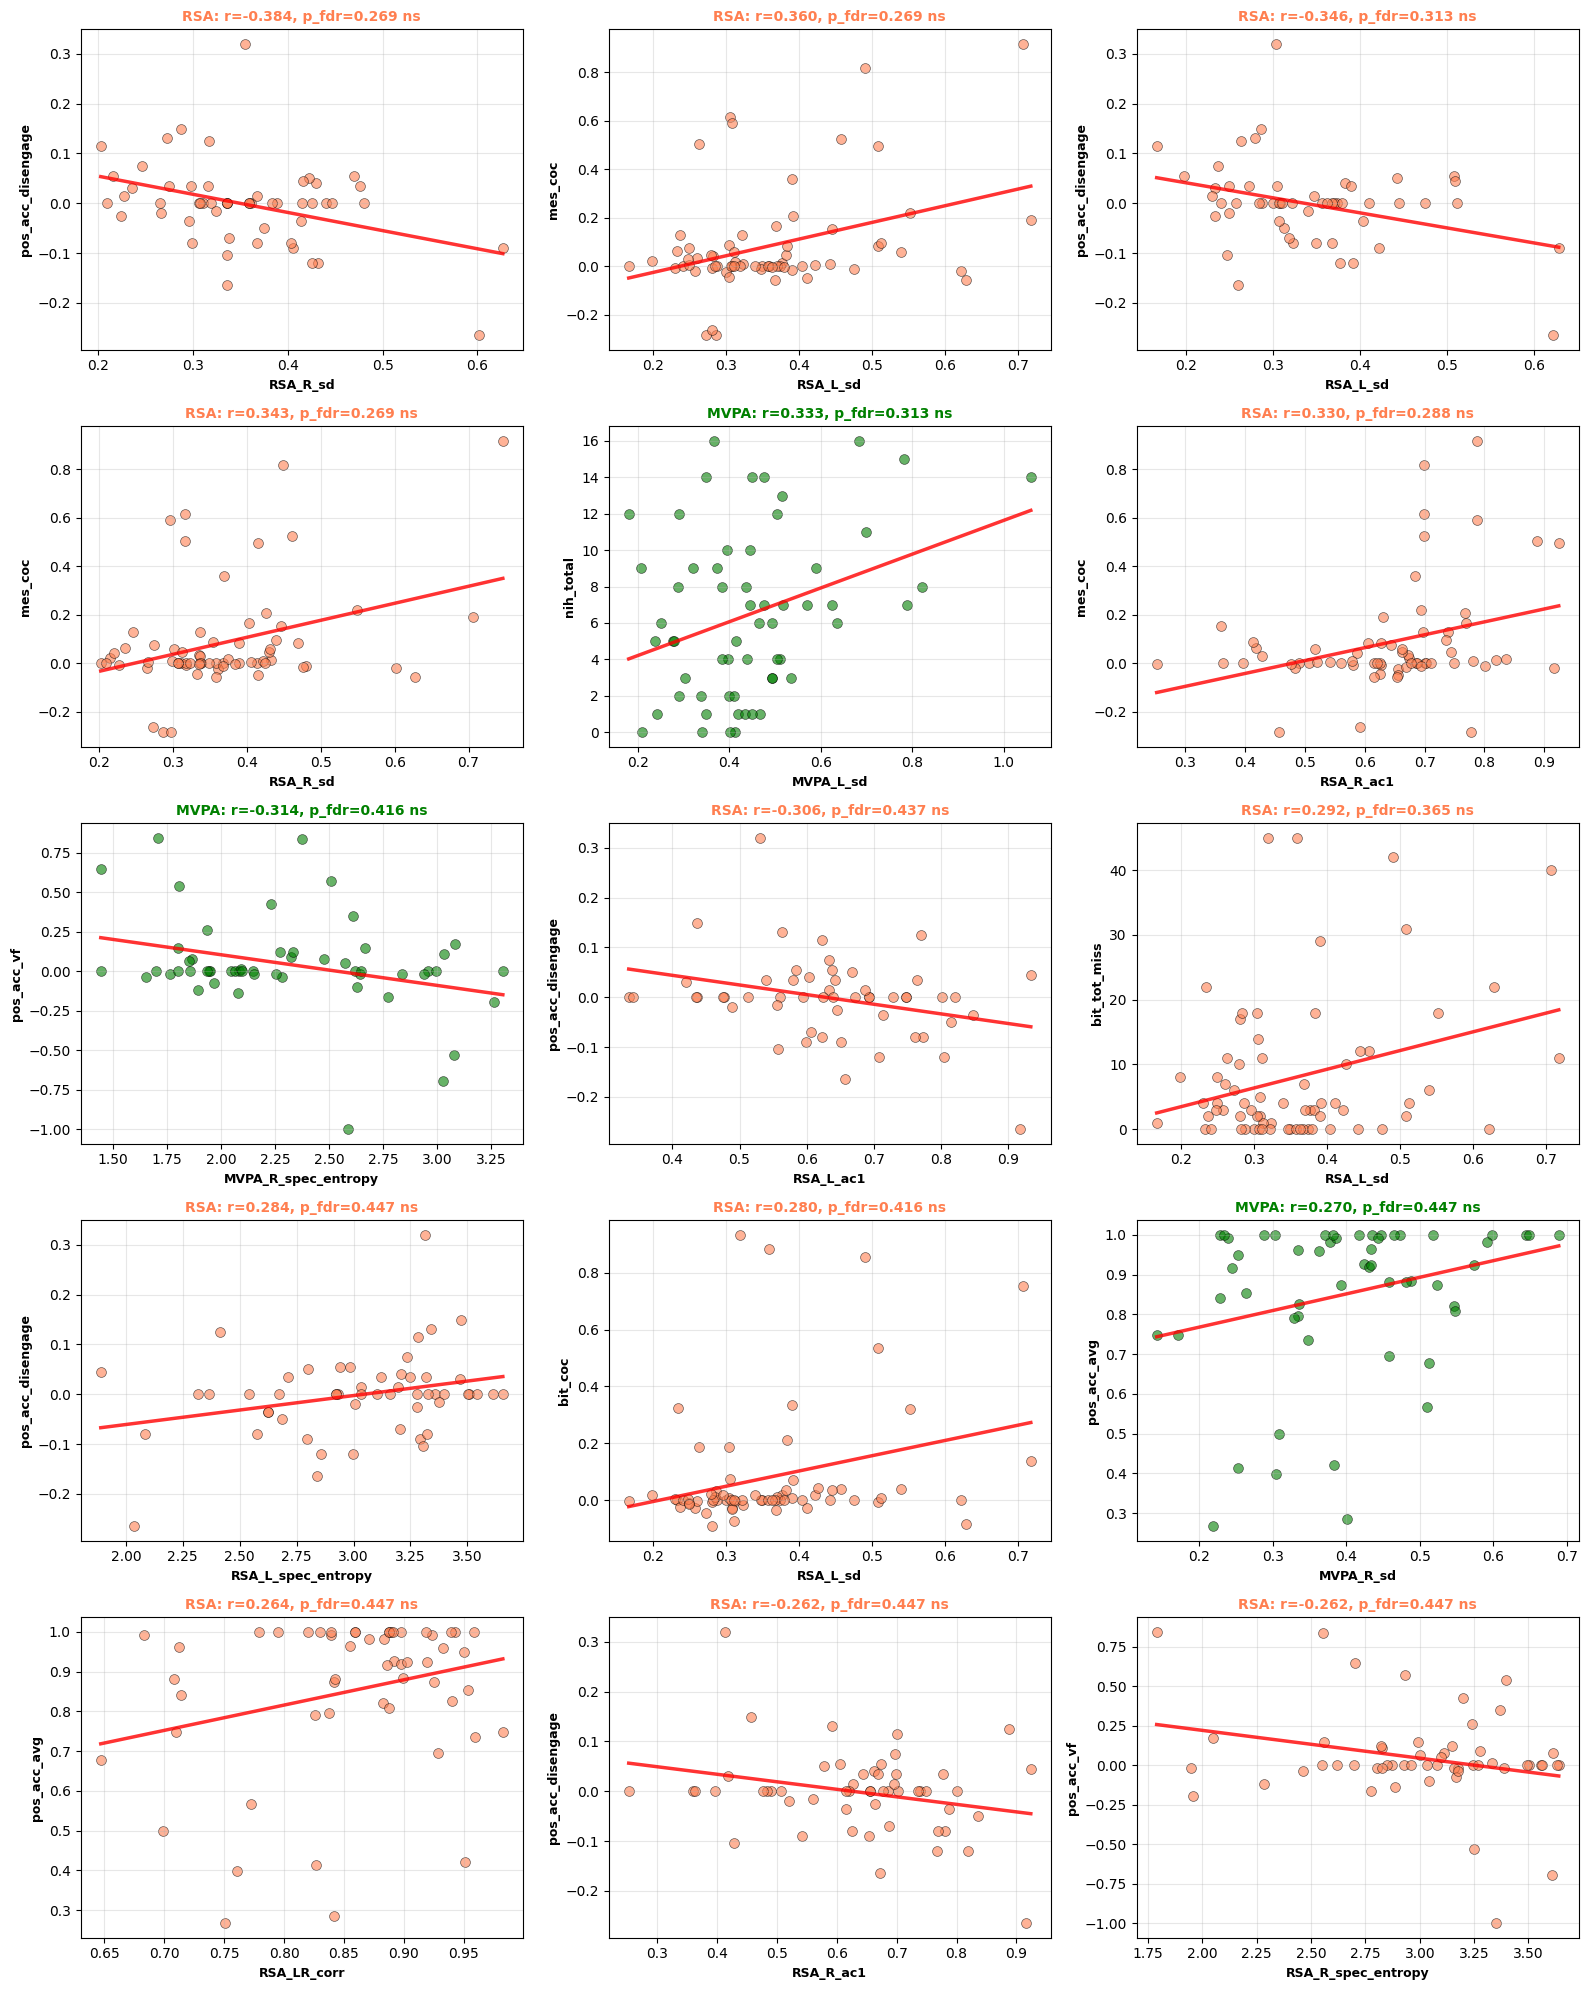

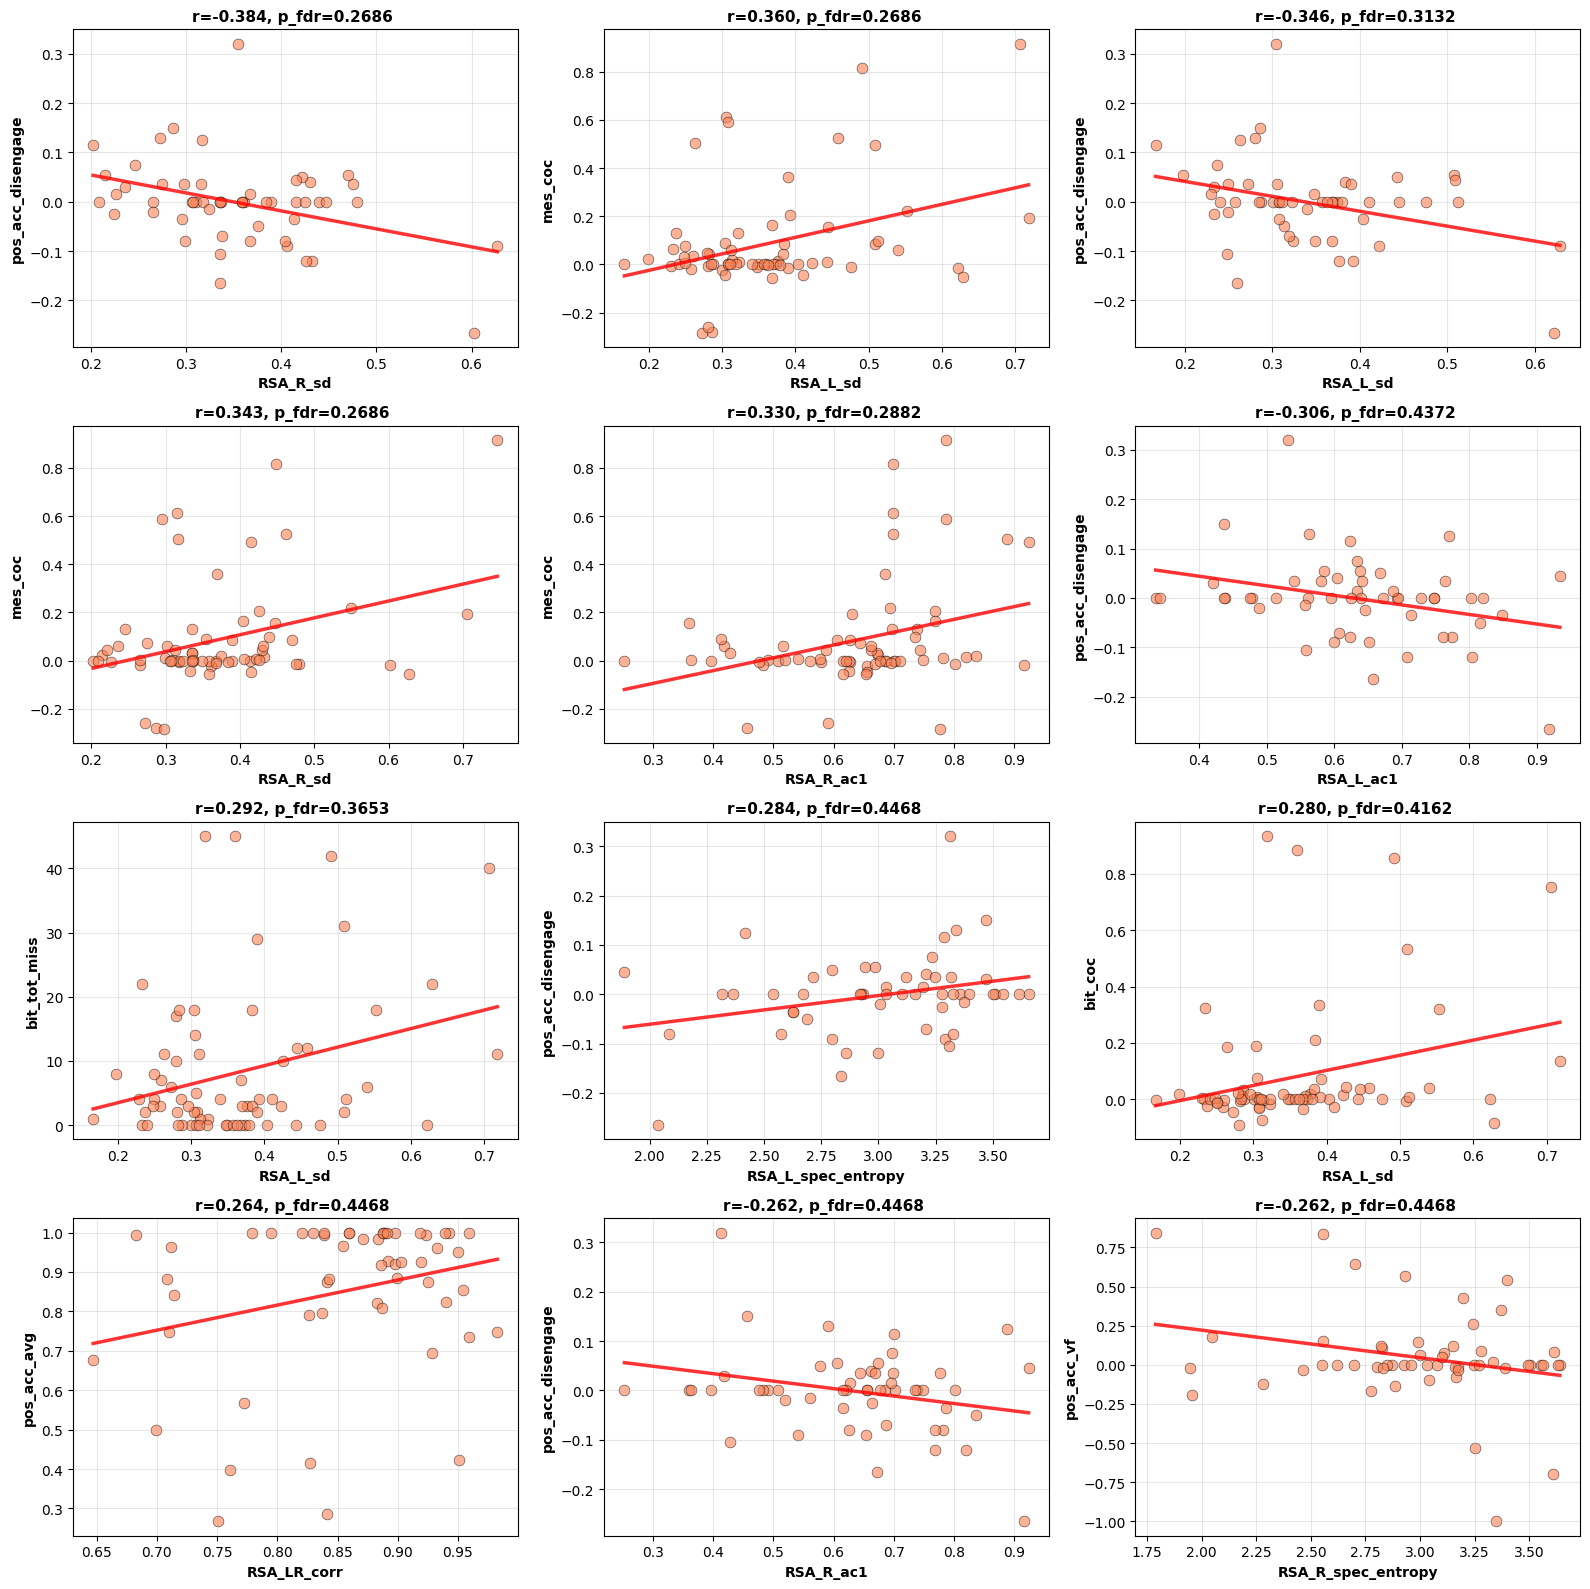

In [5]:
import pandas as pd
import numpy as np
import pickle as pkl
from scipy import stats
from scipy.stats import false_discovery_control
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# LOAD DATA
# ============================================================
with open('/mnt/compneuro/stroke_data_with_oculomotor_features_fixed.pkl', 'rb') as f:
    df = pd.DataFrame(pkl.load(f))

acute = df[(df['Session'] == 'acute') & (df['subj_type'] == 0)].copy()
print(f"Total acute patients: N={len(acute)}")

# ============================================================
# DEFINE VARIABLES
# ============================================================

OCULOMOTOR_FEATURES = [
    # PCA features
    'PCA_L_sd', 'PCA_R_sd', 'PCA_sd_asym',
    'PCA_L_mssd', 'PCA_R_mssd',
    'PCA_L_ac1', 'PCA_R_ac1',
    'PCA_L_spec_entropy', 'PCA_R_spec_entropy',
    'PCA_LR_corr',
    
    # RSA features
    'RSA_L_sd', 'RSA_R_sd', 'RSA_sd_asym',
    'RSA_L_mssd', 'RSA_R_mssd',
    'RSA_L_ac1', 'RSA_R_ac1',
    'RSA_L_spec_entropy', 'RSA_R_spec_entropy',
    'RSA_LR_corr',
    
    # Cross-modality
    'corr_PCA_RSA_L', 'corr_PCA_RSA_R',
]

# MVPA (if available)
MVPA_FEATURES = [
    'MVPA_L_sd', 'MVPA_R_sd', 'MVPA_sd_asym',
    'MVPA_L_mssd', 'MVPA_R_mssd',
    'MVPA_L_ac1', 'MVPA_R_ac1',
    'MVPA_L_spec_entropy', 'MVPA_R_spec_entropy',
    'MVPA_LR_corr',
]

mvpa_exists = any(col in acute.columns for col in MVPA_FEATURES)
if mvpa_exists:
    OCULOMOTOR_FEATURES.extend(MVPA_FEATURES)
    print("✅ MVPA features found")
else:
    print("⚠️  MVPA features not found")

# Clinical measures - NO ordinal variables
CLINICAL_MEASURES = [
    'nih_total',
    'lesion_volume_mm3',
    'mes_tot_miss',
    'mes_coc',
    'bit_tot_miss',
    'bit_coc',
    'pos_acc_avg',
    'pos_acc_vf',
    'pos_acc_disengage',
]

# ============================================================
# FILTER TO IMPAIRED PATIENTS
# ============================================================

impaired = acute[
    (acute['bit_tot_miss'] >= 3 ) |
    (acute['nih_total'] >= 4 ) |
    (acute['lesion_volume_mm3'] >= 40000 )
].copy()

print(f"\n" + "="*60)
print(f"Sample: {len(impaired)}/{len(acute)} patients with visual deficits")
print("="*60)

# ============================================================
# CORRELATION ANALYSIS
# ============================================================

available_features = [f for f in OCULOMOTOR_FEATURES if f in impaired.columns]

results = []

for ocular_feat in available_features:
    for clinical_feat in CLINICAL_MEASURES:
        valid = impaired[[ocular_feat, clinical_feat]].dropna()
        
        if len(valid) < 10:
            continue
        
        r, p = stats.(valid[ocular_feat], valid[clinical_feat])
        
        if ocular_feat.startswith('PCA_'):
            feat_type = 'PCA'
        elif ocular_feat.startswith('MVPA_'):
            feat_type = 'MVPA'
        elif ocular_feat.startswith('RSA_'):
            feat_type = 'RSA'
        else:
            feat_type = 'Cross-modality'
        
        results.append({
            'oculomotor_feature': ocular_feat,
            'clinical_measure': clinical_feat,
            'feature_type': feat_type,
            'r': r,
            'abs_r': abs(r),  # Add absolute value column
            'p': p,
            'n': len(valid)
        })

results_df = pd.DataFrame(results)
results_df['p_fdr'] = false_discovery_control(results_df['p'].values)
results_df['significant_fdr'] = results_df['p_fdr'] < 0.05

print(f"\nTotal correlations: {len(results_df)}")
print(f"Significant (FDR<0.05): {results_df['significant_fdr'].sum()}")

# ============================================================
# PRINT SIGNIFICANT RESULTS
# ============================================================
sig_results = results_df[results_df['significant_fdr']].sort_values('p_fdr')

print("\n" + "="*60)
print("SIGNIFICANT CORRELATIONS (FDR q<0.05)")
print("="*60)

if len(sig_results) > 0:
    for idx, row in sig_results.iterrows():
        print(f"{row['feature_type']:15s} | {row['oculomotor_feature']:25s} × {row['clinical_measure']:20s}")
        print(f"  r={row['r']:6.3f}, p={row['p']:.4f}, p_fdr={row['p_fdr']:.4f}, N={row['n']}\n")

# ============================================================
# PLOT 1: ALL SIGNIFICANT CORRELATIONS
# ============================================================
print("\n" + "="*60)
print("CREATING SCATTERPLOTS")
print("="*60)

if len(sig_results) > 0:
    n_plots = len(sig_results)
    n_cols = 3
    n_rows = int(np.ceil(n_plots / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, (idx, row) in enumerate(sig_results.iterrows()):
        ax = axes[i]
        
        ocular = row['oculomotor_feature']
        clinical = row['clinical_measure']
        
        valid = impaired[[ocular, clinical]].dropna()
        x = valid[ocular]
        y = valid[clinical]
        
        # Scatter with color by feature type
        colors = {'PCA': 'steelblue', 'RSA': 'coral', 'MVPA': 'green', 'Cross-modality': 'purple'}
        color = colors[row['feature_type']]
        
        ax.scatter(x, y, alpha=0.6, s=60, color=color, edgecolors='black', linewidth=0.5)
        
        # Fit line
        z = np.polyfit(x, y, 1)
        p_fit = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, p_fit(x_line), "r-", alpha=0.8, linewidth=2.5)
        
        ax.set_xlabel(ocular, fontsize=10, fontweight='bold')
        ax.set_ylabel(clinical, fontsize=10, fontweight='bold')
        ax.set_title(f"{row['feature_type']}: r={row['r']:.3f}, p_fdr={row['p_fdr']:.4f}", 
                    fontsize=11, fontweight='bold', color=color)
        ax.grid(alpha=0.3)
        
        # Add zero lines if relevant
        if y.min() < 0 < y.max():
            ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
        if x.min() < 0 < x.max():
            ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
    
    # Hide unused subplots
    for i in range(n_plots, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('/mnt/compneuro/all_significant_correlations_impaired.png', dpi=300, bbox_inches='tight')
    print(f"✅ Saved: all_significant_correlations_impaired.png")

# ============================================================
# PLOT 2: TOP 15 CORRELATIONS (by |r|)
# ============================================================
top_15 = results_df.nlargest(15, 'abs_r')  # Use abs_r column

fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()

for i, (idx, row) in enumerate(top_15.iterrows()):
    ax = axes[i]
    
    ocular = row['oculomotor_feature']
    clinical = row['clinical_measure']
    
    valid = impaired[[ocular, clinical]].dropna()
    x = valid[ocular]
    y = valid[clinical]
    
    colors = {'PCA': 'steelblue', 'RSA': 'coral', 'MVPA': 'green', 'Cross-modality': 'purple'}
    color = colors[row['feature_type']]
    
    ax.scatter(x, y, alpha=0.6, s=50, color=color, edgecolors='black', linewidth=0.5)
    
    z = np.polyfit(x, y, 1)
    p_fit = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p_fit(x_line), "r-", alpha=0.8, linewidth=2.5)
    
    ax.set_xlabel(ocular, fontsize=9, fontweight='bold')
    ax.set_ylabel(clinical, fontsize=9, fontweight='bold')
    
    sig_marker = "**" if row['significant_fdr'] else "ns"
    ax.set_title(f"{row['feature_type']}: r={row['r']:.3f}, p_fdr={row['p_fdr']:.3f} {sig_marker}", 
                fontsize=10, fontweight='bold', color=color)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/compneuro/top15_correlations_impaired.png', dpi=300, bbox_inches='tight')
print(f"✅ Saved: top15_correlations_impaired.png")

# ============================================================
# PLOT 3: RSA ONLY (top 12)
# ============================================================
rsa_results = results_df[results_df['feature_type']=='RSA'].nlargest(12, 'abs_r')

if len(rsa_results) > 0:
    fig, axes = plt.subplots(4, 3, figsize=(16, 16))
    axes = axes.flatten()
    
    for i, (idx, row) in enumerate(rsa_results.iterrows()):
        ax = axes[i]
        
        ocular = row['oculomotor_feature']
        clinical = row['clinical_measure']
        
        valid = impaired[[ocular, clinical]].dropna()
        x = valid[ocular]
        y = valid[clinical]
        
        ax.scatter(x, y, alpha=0.6, s=60, color='coral', edgecolors='black', linewidth=0.5)
        
        z = np.polyfit(x, y, 1)
        p_fit = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, p_fit(x_line), "r-", alpha=0.8, linewidth=2.5)
        
        ax.set_xlabel(ocular, fontsize=10, fontweight='bold')
        ax.set_ylabel(clinical, fontsize=10, fontweight='bold')
        
        sig_marker = "**" if row['significant_fdr'] else ""
        ax.set_title(f"r={row['r']:.3f}, p_fdr={row['p_fdr']:.4f} {sig_marker}", 
                    fontsize=11, fontweight='bold')
        ax.grid(alpha=0.3)
    
    # Hide unused
    for i in range(len(rsa_results), 12):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('/mnt/compneuro/rsa_top12_correlations.png', dpi=300, bbox_inches='tight')
    print(f"✅ Saved: rsa_top12_correlations.png")

# ============================================================
# PLOT 4: COMPARISON - All Patients vs Impaired Only
# ============================================================
print("\n" + "="*60)
print("CREATING COMPARISON PLOTS (All vs Impaired)")
print("="*60)

# Pick top 3 significant correlations
if len(sig_results) >= 3:
    comparison_pairs = sig_results.nlargest(3, 'abs_r')[['oculomotor_feature', 'clinical_measure']].values
    
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    
    for i, (ocular, clinical) in enumerate(comparison_pairs):
        # Left: All patients
        ax_all = axes[i, 0]
        valid_all = acute[[ocular, clinical]].dropna()
        x_all = valid_all[ocular]
        y_all = valid_all[clinical]
        
        ax_all.scatter(x_all, y_all, alpha=0.5, s=40, color='gray', edgecolors='black', linewidth=0.5)
        z = np.polyfit(x_all, y_all, 1)
        p_fit = np.poly1d(z)
        x_line = np.linspace(x_all.min(), x_all.max(), 100)
        ax_all.plot(x_line, p_fit(x_line), "r-", alpha=0.8, linewidth=2.5)
        
        r_all, p_all = stats.spearmanr(x_all, y_all)
        ax_all.set_xlabel(ocular, fontsize=10, fontweight='bold')
        ax_all.set_ylabel(clinical, fontsize=10, fontweight='bold')
        ax_all.set_title(f"ALL PATIENTS\nr={r_all:.3f}, p={p_all:.4f}, N={len(x_all)}", 
                        fontsize=11, fontweight='bold', color='gray')
        ax_all.grid(alpha=0.3)
        
        # Right: Impaired only
        ax_imp = axes[i, 1]
        valid_imp = impaired[[ocular, clinical]].dropna()
        x_imp = valid_imp[ocular]
        y_imp = valid_imp[clinical]
        
        ax_imp.scatter(x_imp, y_imp, alpha=0.6, s=60, color='coral', edgecolors='black', linewidth=0.5)
        z = np.polyfit(x_imp, y_imp, 1)
        p_fit = np.poly1d(z)
        x_line = np.linspace(x_imp.min(), x_imp.max(), 100)
        ax_imp.plot(x_line, p_fit(x_line), "r-", alpha=0.8, linewidth=2.5)
        
        r_imp, p_imp = stats.spearmanr(x_imp, y_imp)
        ax_imp.set_xlabel(ocular, fontsize=10, fontweight='bold')
        ax_imp.set_ylabel(clinical, fontsize=10, fontweight='bold')
        ax_imp.set_title(f"IMPAIRED ONLY\nr={r_imp:.3f}, p={p_imp:.4f}, N={len(x_imp)}", 
                        fontsize=11, fontweight='bold', color='coral')
        ax_imp.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/mnt/compneuro/comparison_all_vs_impaired.png', dpi=300, bbox_inches='tight')
    print(f"✅ Saved: comparison_all_vs_impaired.png")

# ============================================================
# SAVE RESULTS
# ============================================================
results_df.to_csv('/mnt/compneuro/tier1_correlations_impaired_only.csv', index=False)
print(f"✅ Saved: tier1_correlations_impaired_only.csv")

print("\n" + "="*60)
print("COMPLETE ANALYSIS WITH SCATTERPLOTS")
print("="*60)
print(f"Created visualization files:")
print(f"  1. all_significant_correlations_impaired.png")
print(f"  2. top15_correlations_impaired.png")
print(f"  3. rsa_top12_correlations.png")
print(f"  4. comparison_all_vs_impaired.png")
print("="*60)

Acute patients: N=138

Oculomotor features available: 22/36

CORRELATION ANALYSIS: Oculomotor Features vs Clinical Measures

Total correlations computed: 264

By feature type:
  PCA                 :   0 correlations,  0 significant
  MVPA                : 120 correlations,  0 significant
  RSA                 : 120 correlations,  7 significant
  Cross-modality      :  24 correlations,  0 significant

SIGNIFICANT CORRELATIONS (FDR q<0.05)

7 significant associations found:

RSA             | RSA_L_sd                  × nih11                    
  r= 0.364, p=0.0001, p_fdr=0.0168, N=110

RSA             | RSA_L_sd                  × mes_coc                  
  r= 0.321, p=0.0002, p_fdr=0.0168, N=133

RSA             | RSA_R_sd                  × mes_coc                  
  r= 0.307, p=0.0003, p_fdr=0.0168, N=133

RSA             | RSA_L_ac1                 × nih_total                
  r= 0.341, p=0.0003, p_fdr=0.0168, N=109

RSA             | RSA_R_ac1                 × nih_total      

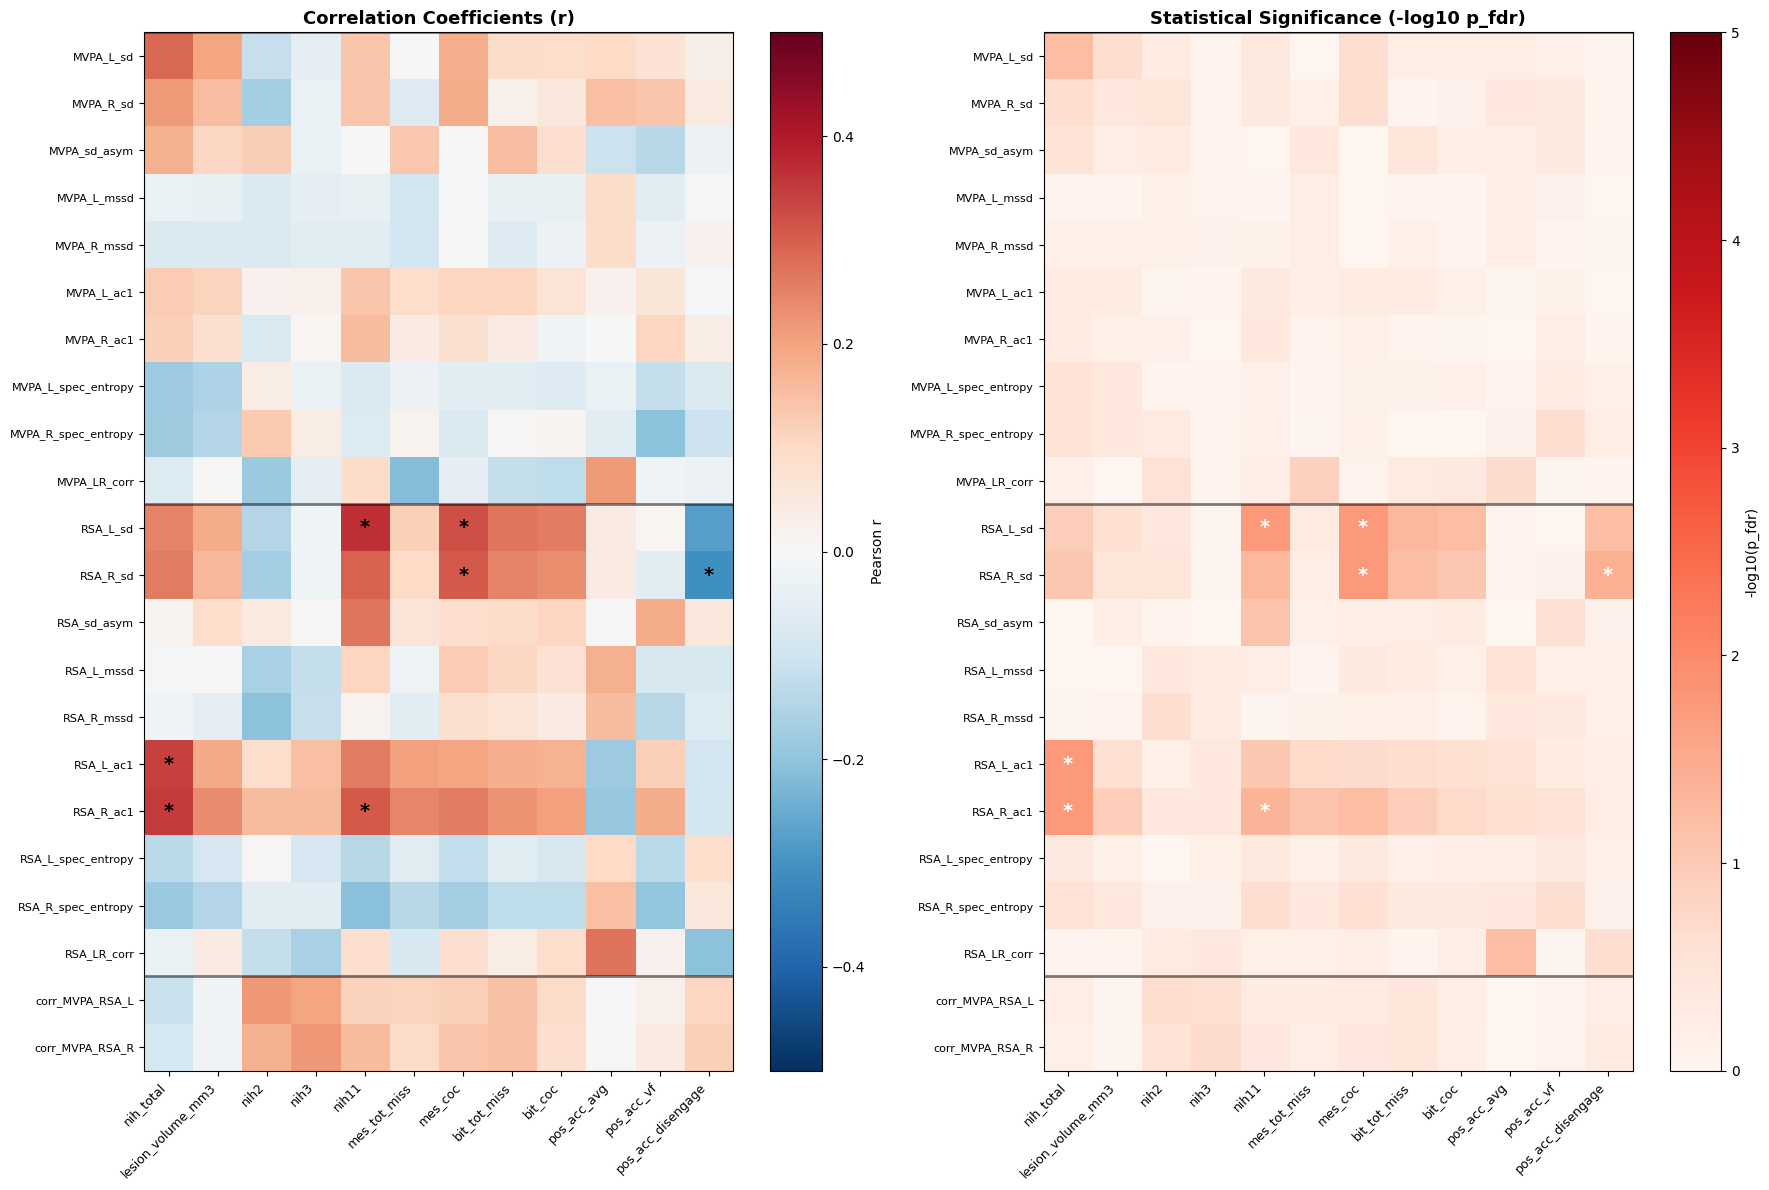

In [6]:
import pandas as pd
import numpy as np
import pickle as pkl
from scipy import stats
from scipy.stats import false_discovery_control
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# LOAD DATA
# ============================================================
with open('/mnt/compneuro/stroke_data_with_oculomotor_features_fixed.pkl', 'rb') as f:
    df = pd.DataFrame(pkl.load(f))

# Filter to acute patients only
acute = df[(df['Session'] == 'acute') & (df['subj_type'] == 0)].copy()
print(f"Acute patients: N={len(acute)}")

# ============================================================
# DEFINE VARIABLES
# ============================================================

# Oculomotor features - PCA, MVPA, and RSA
OCULOMOTOR_FEATURES = [
    # PCA features
    'PCA_L_sd', 'PCA_R_sd', 'PCA_sd_asym',
    'PCA_L_mssd', 'PCA_R_mssd',
    'PCA_L_ac1', 'PCA_R_ac1',
    'PCA_L_spec_entropy', 'PCA_R_spec_entropy',
    'PCA_LR_corr',
    
    # MVPA features (if you have them separately)
    'MVPA_L_sd', 'MVPA_R_sd', 'MVPA_sd_asym',
    'MVPA_L_mssd', 'MVPA_R_mssd',
    'MVPA_L_ac1', 'MVPA_R_ac1',
    'MVPA_L_spec_entropy', 'MVPA_R_spec_entropy',
    'MVPA_LR_corr',
    
    # RSA features
    'RSA_L_sd', 'RSA_R_sd', 'RSA_sd_asym',
    'RSA_L_mssd', 'RSA_R_mssd',
    'RSA_L_ac1', 'RSA_R_ac1',
    'RSA_L_spec_entropy', 'RSA_R_spec_entropy',
    'RSA_LR_corr',
    
    # Cross-modality correlations
    'corr_PCA_MVPA_L', 'corr_PCA_MVPA_R',
    'corr_PCA_RSA_L', 'corr_PCA_RSA_R',
    'corr_MVPA_RSA_L', 'corr_MVPA_RSA_R',
]

# Clinical severity measures
CLINICAL_MEASURES = [
    'nih_total',           # NIHSS total score
    'lesion_volume_mm3',   # Lesion volume
    
    # Visual battery scores
    'nih2',                # NIHSS Best Gaze
    'nih3',                # NIHSS Visual Fields
    'nih11',               # NIHSS Extinction
    'mes_tot_miss',        # Mesulam neglect
    'mes_coc',             # Mesulam center of cancellation
    'bit_tot_miss',        # BIT neglect
    'bit_coc',             # BIT center of cancellation
    'pos_acc_avg',         # Posner average accuracy
    'pos_acc_vf',          # Posner visual field effect
    'pos_acc_disengage',   # Posner disengagement
]

# Check which features actually exist in the data
available_features = [f for f in OCULOMOTOR_FEATURES if f in acute.columns]
print(f"\nOculomotor features available: {len(available_features)}/{len(OCULOMOTOR_FEATURES)}")

# ============================================================
# CORRELATION ANALYSIS
# ============================================================
print("\n" + "="*60)
print("CORRELATION ANALYSIS: Oculomotor Features vs Clinical Measures")
print("="*60)

results = []

for ocular_feat in available_features:
    for clinical_feat in CLINICAL_MEASURES:
        # Get valid pairs
        valid = acute[[ocular_feat, clinical_feat]].dropna()
        
        if len(valid) < 10:  # Need minimum sample size
            continue
        
        # Pearson correlation
        r, p = stats.pearsonr(valid[ocular_feat], valid[clinical_feat])
        
        # Determine feature type
        if ocular_feat.startswith('PCA_'):
            feat_type = 'PCA'
        elif ocular_feat.startswith('MVPA_'):
            feat_type = 'MVPA'
        elif ocular_feat.startswith('RSA_'):
            feat_type = 'RSA'
        elif ocular_feat.startswith('corr_'):
            feat_type = 'Cross-modality'
        else:
            feat_type = 'Other'
        
        results.append({
            'oculomotor_feature': ocular_feat,
            'clinical_measure': clinical_feat,
            'feature_type': feat_type,
            'r': r,
            'p': p,
            'n': len(valid)
        })

results_df = pd.DataFrame(results)

# FDR correction
results_df['p_fdr'] = false_discovery_control(results_df['p'].values)
results_df['significant_fdr'] = results_df['p_fdr'] < 0.05

print(f"\nTotal correlations computed: {len(results_df)}")
print(f"\nBy feature type:")
for feat_type in ['PCA', 'MVPA', 'RSA', 'Cross-modality']:
    n_type = (results_df['feature_type'] == feat_type).sum()
    n_sig = ((results_df['feature_type'] == feat_type) & results_df['significant_fdr']).sum()
    print(f"  {feat_type:20s}: {n_type:3d} correlations, {n_sig:2d} significant")

# ============================================================
# DISPLAY SIGNIFICANT RESULTS
# ============================================================
print("\n" + "="*60)
print("SIGNIFICANT CORRELATIONS (FDR q<0.05)")
print("="*60)

sig_results = results_df[results_df['significant_fdr']].sort_values('p_fdr')

if len(sig_results) > 0:
    print(f"\n{len(sig_results)} significant associations found:\n")
    for idx, row in sig_results.iterrows():
        print(f"{row['feature_type']:15s} | {row['oculomotor_feature']:25s} × {row['clinical_measure']:25s}")
        print(f"  r={row['r']:6.3f}, p={row['p']:.4f}, p_fdr={row['p_fdr']:.4f}, N={row['n']}")
        print()
else:
    print("\nNo significant correlations after FDR correction.")

# ============================================================
# DISPLAY TOP CORRELATIONS BY FEATURE TYPE
# ============================================================
print("\n" + "="*60)
print("TOP CORRELATIONS BY FEATURE TYPE")
print("="*60)

for feat_type in ['PCA', 'MVPA', 'RSA']:
    print(f"\n--- Top 5 {feat_type} Correlations ---")
    type_results = results_df[results_df['feature_type'] == feat_type].nlargest(5, 'r')
    if len(type_results) > 0:
        print(type_results[['oculomotor_feature', 'clinical_measure', 'r', 'p', 'p_fdr']].to_string(index=False))
    else:
        print(f"  No {feat_type} features available")

# ============================================================
# FOCUSED ANALYSIS: NIHSS + Lesion Volume
# ============================================================
print("\n" + "="*60)
print("FOCUSED ANALYSIS: NIHSS Total + Lesion Volume")
print("="*60)

key_measures = ['nih_total', 'lesion_volume_mm3']
focused_results = results_df[results_df['clinical_measure'].isin(key_measures)]

for measure in key_measures:
    print(f"\n--- Correlations with {measure} ---")
    measure_corr = focused_results[focused_results['clinical_measure']==measure].sort_values('p')
    print(measure_corr[['feature_type', 'oculomotor_feature', 'r', 'p', 'p_fdr']].to_string(index=False))

# ============================================================
# VISUALIZATION: CORRELATION HEATMAP
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 12))

# Create correlation matrix
corr_matrix = np.zeros((len(available_features), len(CLINICAL_MEASURES)))
p_matrix = np.ones((len(available_features), len(CLINICAL_MEASURES)))

for i, ocular in enumerate(available_features):
    for j, clinical in enumerate(CLINICAL_MEASURES):
        row = results_df[(results_df['oculomotor_feature']==ocular) & 
                         (results_df['clinical_measure']==clinical)]
        if len(row) > 0:
            corr_matrix[i, j] = row.iloc[0]['r']
            p_matrix[i, j] = row.iloc[0]['p_fdr']

# Plot 1: Correlation coefficients
im1 = axes[0].imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-0.5, vmax=0.5)
axes[0].set_xticks(range(len(CLINICAL_MEASURES)))
axes[0].set_yticks(range(len(available_features)))
axes[0].set_xticklabels(CLINICAL_MEASURES, rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(available_features, fontsize=8)
axes[0].set_title('Correlation Coefficients (r)', fontsize=13, fontweight='bold')

# Add horizontal lines to separate feature types
pca_end = sum(1 for f in available_features if f.startswith('PCA_'))
mvpa_end = pca_end + sum(1 for f in available_features if f.startswith('MVPA_'))
rsa_end = mvpa_end + sum(1 for f in available_features if f.startswith('RSA_'))

for y_pos in [pca_end - 0.5, mvpa_end - 0.5, rsa_end - 0.5]:
    axes[0].axhline(y_pos, color='black', linewidth=2, alpha=0.5)
    axes[1].axhline(y_pos, color='black', linewidth=2, alpha=0.5)

# Mark significant correlations
for i in range(len(available_features)):
    for j in range(len(CLINICAL_MEASURES)):
        if p_matrix[i, j] < 0.05:
            axes[0].text(j, i, '*', ha='center', va='center', 
                        color='black', fontsize=14, fontweight='bold')

plt.colorbar(im1, ax=axes[0], label='Pearson r')

# Plot 2: -log10(p_fdr)
log_p = -np.log10(p_matrix + 1e-300)  # Avoid log(0)
log_p[log_p > 5] = 5  # Cap at 5

im2 = axes[1].imshow(log_p, cmap='Reds', aspect='auto', vmin=0, vmax=5)
axes[1].set_xticks(range(len(CLINICAL_MEASURES)))
axes[1].set_yticks(range(len(available_features)))
axes[1].set_xticklabels(CLINICAL_MEASURES, rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(available_features, fontsize=8)
axes[1].set_title('Statistical Significance (-log10 p_fdr)', fontsize=13, fontweight='bold')

# Mark FDR significant
for i in range(len(available_features)):
    for j in range(len(CLINICAL_MEASURES)):
        if p_matrix[i, j] < 0.05:
            axes[1].text(j, i, '*', ha='center', va='center', 
                        color='white', fontsize=14, fontweight='bold')

plt.colorbar(im2, ax=axes[1], label='-log10(p_fdr)')

plt.tight_layout()
plt.savefig('/mnt/compneuro/tier1_correlation_heatmap_pca_mvpa_rsa.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: tier1_correlation_heatmap_pca_mvpa_rsa.png")

# ============================================================
# FEATURE TYPE COMPARISON
# ============================================================
print("\n" + "="*60)
print("FEATURE TYPE COMPARISON")
print("="*60)

# Compare average |r| by feature type for key measures
comparison_data = []
for feat_type in ['PCA', 'MVPA', 'RSA']:
    for measure in ['nih_total', 'lesion_volume_mm3']:
        subset = results_df[(results_df['feature_type'] == feat_type) & 
                           (results_df['clinical_measure'] == measure)]
        if len(subset) > 0:
            avg_abs_r = subset['r'].abs().mean()
            max_abs_r = subset['r'].abs().max()
            n_sig = subset['significant_fdr'].sum()
            comparison_data.append({
                'feature_type': feat_type,
                'measure': measure,
                'mean_|r|': avg_abs_r,
                'max_|r|': max_abs_r,
                'n_significant': n_sig
            })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# ============================================================
# SAVE RESULTS TABLE
# ============================================================
results_df.to_csv('/mnt/compneuro/tier1_correlation_results_pca_mvpa_rsa.csv', index=False)
print(f"\n✅ Saved: tier1_correlation_results_pca_mvpa_rsa.csv")

print("\n" + "="*60)
print("TIER 1 ANALYSIS COMPLETE")
print(f"Total features analyzed: {len(available_features)}")
print(f"  PCA:   {sum(1 for f in available_features if f.startswith('PCA_'))}")
print(f"  MVPA:  {sum(1 for f in available_features if f.startswith('MVPA_'))}")
print(f"  RSA:   {sum(1 for f in available_features if f.startswith('RSA_'))}")
print(f"  Cross: {sum(1 for f in available_features if f.startswith('corr_'))}")
print("="*60)

In [7]:
import pickle as pkl
import pandas as pd
import numpy as np

# ============================================================
# LOAD ENHANCED DATA
# ============================================================
with open('/mnt/compneuro/stroke_data_with_oculomotor_features_fixed.pkl', 'rb') as f:
    df = pkl.load(f)

df = pd.DataFrame(df)

# ============================================================
# SEPARATE PATIENTS AND CONTROLS
# ============================================================
print("="*60)
print("SAMPLE SIZE BREAKDOWN")
print("="*60)

controls = df[df['subj_type'] == 1].copy()
patients = df[df['subj_type'] == 0].copy()

print(f"\nControls: {len(controls)} rows ({controls['ID'].nunique()} unique)")
print(f"Patients: {len(patients)} rows ({patients['ID'].nunique()} unique)")

# Controls by session
ctrl_sess = controls.groupby('Session')['ID'].count()
print(f"\nControl sessions:")
for sess, count in ctrl_sess.items():
    print(f"  {sess:15s}: {count}")

# ============================================================
# PATIENT SAMPLE FOR PREDICTION
# ============================================================
print("\n" + "="*60)
print("PATIENT SAMPLE FOR PREDICTION ANALYSES")
print("="*60)

acute = patients[patients['Session'] == 'acute']
followup = patients[patients['Session'] == 'followup']
followup2 = patients[patients['Session'] == 'followup2']

print(f"\nPatients by session:")
print(f"  Acute:        {len(acute)} ({acute['ID'].nunique()} unique)")
print(f"  3-month:      {len(followup)} ({followup['ID'].nunique()} unique)")
print(f"  1-year:       {len(followup2)} ({followup2['ID'].nunique()} unique)")

# Matched patients
ids_acute = set(acute['ID'])
ids_3mo = set(followup['ID'])
ids_matched = ids_acute & ids_3mo

print(f"\n✅ Matched acute + 3-month: {len(ids_matched)} patients")

# ============================================================
# DATA COMPLETENESS
# ============================================================

visual_vars = [
    'pos_acc_avg', 'pos_acc_vf', 'pos_acc_disengage',
    'mes_tot_miss', 'mes_coc',
    'bit_tot_miss',
    'nih2', 'nih3', 'nih11'
]

# All oculomotor features (MVPA + RSA + cross-modality)
ocular_vars = [
    # MVPA features
    'MVPA_L_sd', 'MVPA_R_sd', 'MVPA_sd_asym',
    'MVPA_L_mssd', 'MVPA_R_mssd',
    'MVPA_L_ac1', 'MVPA_R_ac1',
    'MVPA_L_spec_entropy', 'MVPA_R_spec_entropy',
    'MVPA_LR_corr',
    
    # RSA features
    'RSA_L_sd', 'RSA_R_sd', 'RSA_sd_asym',
    'RSA_L_mssd', 'RSA_R_mssd',
    'RSA_L_ac1', 'RSA_R_ac1',
    'RSA_L_spec_entropy', 'RSA_R_spec_entropy',
    'RSA_LR_corr',
    
    # Cross-modality
    'corr_MVPA_RSA_L', 'corr_MVPA_RSA_R',
]

acute_matched = acute[acute['ID'].isin(ids_matched)]
followup_matched = followup[followup['ID'].isin(ids_matched)]

# Complete data
vis_acute_complete = acute_matched.dropna(subset=visual_vars)
vis_3mo_complete = followup_matched.dropna(subset=visual_vars)
ocular_complete = acute_matched.dropna(subset=ocular_vars)

ids_final = set(vis_acute_complete['ID']) & \
            set(vis_3mo_complete['ID']) & \
            set(ocular_complete['ID'])

print(f"\n✅ Complete visual + oculomotor data: {len(ids_final)} patients")

# ============================================================
# CONTROL NORMALIZATION VALUES
# ============================================================
print("\n" + "="*60)
print("CONTROL REFERENCE VALUES (for normalization)")
print("="*60)

# Use control session 1 as reference
ctrl_ref = controls[controls['Session'].isin(['control', 'control1', 'acute'])].copy()

print(f"\nControl reference (N={len(ctrl_ref)}):")

print(f"\n--- MVPA Features (mean ± SD) ---")
pca_vars = [v for v in ocular_vars if v.startswith('MVPA_')]
for var in pca_vars:
    mean = ctrl_ref[var].mean()
    std = ctrl_ref[var].std()
    n_valid = ctrl_ref[var].notna().sum()
    print(f"  {var:25s}: {mean:7.3f} ± {std:6.3f} (N={n_valid})")

print(f"\n--- RSA Features (mean ± SD) ---")
rsa_vars = [v for v in ocular_vars if v.startswith('RSA_')]
for var in rsa_vars:
    mean = ctrl_ref[var].mean()
    std = ctrl_ref[var].std()
    n_valid = ctrl_ref[var].notna().sum()
    print(f"  {var:25s}: {mean:7.3f} ± {std:6.3f} (N={n_valid})")

print(f"\n--- Cross-Modality (mean ± SD) ---")
cross_vars = [v for v in ocular_vars if v.startswith('corr_')]
for var in cross_vars:
    mean = ctrl_ref[var].mean()
    std = ctrl_ref[var].std()
    n_valid = ctrl_ref[var].notna().sum()
    print(f"  {var:25s}: {mean:7.3f} ± {std:6.3f} (N={n_valid})")

# ============================================================
# CREATE ANALYSIS DATASET WITH NORMALIZED FEATURES
# ============================================================
print("\n" + "="*60)
print("CREATING ANALYSIS DATASET")
print("="*60)

analysis_data = []

for patient_id in ids_final:
    # Acute data
    acute_row = acute[acute['ID'] == patient_id].iloc[0]
    followup_row = followup[followup['ID'] == patient_id].iloc[0]
    
    # Calculate visual composite (normalized 0-1, higher = better)
    vis_acute_vals = [
        acute_row['pos_acc_avg'],
        1 - acute_row['mes_tot_miss']/60,
        1 - acute_row['bit_tot_miss']/54,
        1 - acute_row['nih3']/3,
        1 - acute_row['nih11']/2
    ]
    vis_acute = np.nanmean([v for v in vis_acute_vals if not np.isnan(v)])
    
    vis_3mo_vals = [
        followup_row['pos_acc_avg'],
        1 - followup_row['mes_tot_miss']/60,
        1 - followup_row['bit_tot_miss']/54,
        1 - followup_row['nih3']/3,
        1 - followup_row['nih11']/2
    ]
    vis_3mo = np.nanmean([v for v in vis_3mo_vals if not np.isnan(v)])
    
    row = {
        'ID': patient_id,
        'age': acute_row['age'],
        'gender': acute_row['gender'],
        'nih_total': acute_row['nih_total'],
        'lesion_volume_mm3': acute_row['lesion_volume_mm3'],
        
        # Visual outcomes
        'visual_acute': vis_acute,
        'visual_3mo': vis_3mo,
        'delta_visual': vis_3mo - vis_acute,
        
        # Raw oculomotor features
        **{f'{col}_raw': acute_row[col] for col in ocular_vars},
        
        # Z-scored relative to controls
        **{f'{col}_z': (acute_row[col] - ctrl_ref[col].mean()) / (ctrl_ref[col].std() + 1e-10)
           for col in ocular_vars}
    }
    
    analysis_data.append(row)

analysis_df = pd.DataFrame(analysis_data)

# ============================================================
# FEATURE SUMMARY
# ============================================================
print(f"\nAnalysis dataset: N={len(analysis_df)}")
print(f"\nFeature groups:")
print(f"  Clinical:        3 (age, nih_total, lesion_volume)")
print(f"  Visual outcomes: 3 (acute, 3mo, delta)")
print(f"  MVPA features:    {len(pca_vars)} (raw + z-scored)")
print(f"  RSA features:    {len(rsa_vars)} (raw + z-scored)")
print(f"  Cross-modality:  {len(cross_vars)} (raw + z-scored)")
print(f"  Total oculomotor: {len(ocular_vars)}")

# ============================================================
# SAVE DATASETS
# ============================================================

# 1. Analysis dataset (patients with complete data)
output_path = '/mnt/compneuro/opus_analysis_dataset_with_rsa.csv'
analysis_df.to_csv(output_path, index=False)
print(f"\n✅ Saved: {output_path}")
print(f"   Shape: {analysis_df.shape}")
print(f"   Columns: clinical, visual outcomes, MVPA + RSA (raw + z-scored)")

# 2. Full dataset with controls (for visualization)
full_df = pd.concat([
    patients[patients['ID'].isin(ids_final)],
    controls
]).reset_index(drop=True)

full_df.to_csv('/mnt/compneuro/full_dataset_with_controls_rsa.csv', index=False)
print(f"\n✅ Saved: full_dataset_with_controls_rsa.csv")
print(f"   Includes: {len(ids_final)} patients (all timepoints) + {controls['ID'].nunique()} controls")

# 3. Control reference values
ctrl_stats = pd.DataFrame({
    'feature': ocular_vars,
    'control_mean': [ctrl_ref[v].mean() for v in ocular_vars],
    'control_sd': [ctrl_ref[v].std() for v in ocular_vars],
    'control_n': [ctrl_ref[v].notna().sum() for v in ocular_vars],
    'feature_type': [
        'MVPA' if v.startswith('MVPA_') else 
        'RSA' if v.startswith('RSA_') else 
        'Cross-modality' 
        for v in ocular_vars
    ]
})
ctrl_stats.to_csv('/mnt/compneuro/control_reference_values_rsa.csv', index=False)
print(f"\n✅ Saved: control_reference_values_rsa.csv")

# ============================================================
# CHECK FOR MISSING DATA
# ============================================================
print("\n" + "="*60)
print("DATA COMPLETENESS CHECK")
print("="*60)

print("\nMissing data in analysis dataset:")
missing_summary = []
for col in analysis_df.columns:
    n_missing = analysis_df[col].isna().sum()
    if n_missing > 0:
        pct_missing = 100 * n_missing / len(analysis_df)
        missing_summary.append({
            'variable': col,
            'n_missing': n_missing,
            'pct_missing': pct_missing
        })

if missing_summary:
    missing_df = pd.DataFrame(missing_summary).sort_values('n_missing', ascending=False)
    print("\n" + missing_df.to_string(index=False))
else:
    print("  ✅ No missing data!")

print(f"\n{'='*60}")
print(f"FINAL N FOR OPUS: {len(ids_final)} patients")
print(f"TOTAL FEATURES: {len(ocular_vars)} oculomotor features")
print(f"  - MVPA: {len(pca_vars)}")
print(f"  - RSA: {len(rsa_vars)}")
print(f"  - Cross-modality: {len(cross_vars)}")
print(f"{'='*60}")
print(f"\nReady for analysis!")

SAMPLE SIZE BREAKDOWN

Controls: 56 rows (31 unique)
Patients: 328 rows (153 unique)

Control sessions:
  control        : 28
  control2       : 28

PATIENT SAMPLE FOR PREDICTION ANALYSES

Patients by session:
  Acute:        138 (138 unique)
  3-month:      103 (103 unique)
  1-year:       87 (87 unique)

✅ Matched acute + 3-month: 97 patients

✅ Complete visual + oculomotor data: 58 patients

CONTROL REFERENCE VALUES (for normalization)

Control reference (N=28):

--- MVPA Features (mean ± SD) ---
  MVPA_L_sd                :   0.418 ±  0.159 (N=28)
  MVPA_R_sd                :   0.425 ±  0.164 (N=28)
  MVPA_sd_asym             :  -0.007 ±  0.057 (N=28)
  MVPA_L_mssd              :   0.082 ±  0.094 (N=28)
  MVPA_R_mssd              :   0.090 ±  0.123 (N=28)
  MVPA_L_ac1               :   0.686 ±  0.331 (N=28)
  MVPA_R_ac1               :   0.694 ±  0.302 (N=28)
  MVPA_L_spec_entropy      :   2.500 ±  0.623 (N=28)
  MVPA_R_spec_entropy      :   2.541 ±  0.587 (N=28)
  MVPA_LR_corr    

In [39]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl

with open('/mnt/compneuro/stroke_data_with_oculomotor_features.pkl', 'rb') as f:
    df = pd.DataFrame(pkl.load(f))

acute = df[(df['Session'] == 'acute') & (df['subj_type'] == 0)].copy()

print("="*60)
print("DIAGNOSTIC CHECKS: Are Correlations Robust?")
print("="*60)

# ============================================================
# 1. COMPARE PEARSON vs SPEARMAN (outlier-robust)
# ============================================================
print("\n--- Pearson vs Spearman Correlation ---")

pairs = [
    ('RSA_L_sd', 'nih_total'),
    ('PCA_L_sd', 'lesion_volume_mm3'),
    ('PCA_L_sd', 'nih_total')
]

for feat1, feat2 in pairs:
    valid = acute[[feat1, feat2]].dropna()
    
    r_pearson, p_pearson = stats.pearsonr(valid[feat1], valid[feat2])
    r_spearman, p_spearman = stats.spearmanr(valid[feat1], valid[feat2])
    
    print(f"\n{feat1} × {feat2}:")
    print(f"  Pearson:  r={r_pearson:.3f}, p={p_pearson:.4f}")
    print(f"  Spearman: r={r_spearman:.3f}, p={p_spearman:.4f}")
    
    if abs(r_pearson - r_spearman) > 0.10:
        print(f"  ⚠️  Large difference → outliers/non-linearity affecting Pearson")

# ============================================================
# 2. STRATIFY BY SEVERITY (Mild vs Severe)
# ============================================================
print("\n" + "="*60)
print("STRATIFIED ANALYSIS: Mild vs Severe Strokes")
print("="*60)

# Define mild vs severe
acute['severity'] = acute['nih_total'].apply(lambda x: 'Severe' if x >= 5 else 'Mild')

print(f"\nMild (NIHSS<5): N={len(acute[acute['severity']=='Mild'])}")
print(f"Severe (NIHSS≥5): N={len(acute[acute['severity']=='Severe'])}")

print("\n--- Correlations in Mild Strokes Only ---")
for feat1, feat2 in pairs:
    mild = acute[acute['severity']=='Mild']
    valid = mild[[feat1, feat2]].dropna()
    
    if len(valid) < 10:
        continue
    
    r, p = stats.pearsonr(valid[feat1], valid[feat2])
    print(f"{feat1} × {feat2}: r={r:.3f}, p={p:.4f} (N={len(valid)})")

print("\n--- Correlations in Severe Strokes Only ---")
for feat1, feat2 in pairs:
    severe = acute[acute['severity']=='Severe']
    valid = severe[[feat1, feat2]].dropna()
    
    if len(valid) < 10:
        print(f"{feat1} × {feat2}: N={len(valid)} too small")
        continue
    
    r, p = stats.pearsonr(valid[feat1], valid[feat2])
    print(f"{feat1} × {feat2}: r={r:.3f}, p={p:.4f} (N={len(valid)})")

# ============================================================
# 3. GROUP COMPARISON (Mild vs Severe)
# ============================================================
print("\n" + "="*60)
print("GROUP COMPARISON: Mild vs Severe")
print("="*60)

for feat in ['RSA_L_sd', 'PCA_L_sd']:
    mild_vals = acute[acute['severity']=='Mild'][feat].dropna()
    severe_vals = acute[acute['severity']=='Severe'][feat].dropna()
    
    t_stat, p_val = stats.ttest_ind(severe_vals, mild_vals)
    cohens_d = (severe_vals.mean() - mild_vals.mean()) / np.sqrt(
        ((len(severe_vals)-1)*severe_vals.std()**2 + (len(mild_vals)-1)*mild_vals.std()**2) / 
        (len(severe_vals) + len(mild_vals) - 2)
    )
    
    print(f"\n{feat}:")
    print(f"  Mild:   {mild_vals.mean():.3f} ± {mild_vals.std():.3f} (N={len(mild_vals)})")
    print(f"  Severe: {severe_vals.mean():.3f} ± {severe_vals.std():.3f} (N={len(severe_vals)})")
    print(f"  t={t_stat:.2f}, p={p_val:.4f}")
    print(f"  Cohen's d={cohens_d:.3f}", end="")
    
    if abs(cohens_d) < 0.2:
        print(" [negligible]")
    elif abs(cohens_d) < 0.5:
        print(" [small]")
    elif abs(cohens_d) < 0.8:
        print(" [medium]")
    else:
        print(" [large]")

# ============================================================
# 4. OUTLIER SENSITIVITY
# ============================================================
print("\n" + "="*60)
print("OUTLIER SENSITIVITY: Remove Top 10% Severity")
print("="*60)

for feat1, feat2 in pairs:
    valid = acute[[feat1, feat2]].dropna()
    
    # Remove top 10% by clinical measure (feat2)
    threshold_90 = valid[feat2].quantile(0.90)
    trimmed = valid[valid[feat2] <= threshold_90]
    
    r_full, p_full = stats.pearsonr(valid[feat1], valid[feat2])
    r_trim, p_trim = stats.pearsonr(trimmed[feat1], trimmed[feat2])
    
    print(f"\n{feat1} × {feat2}:")
    print(f"  Full data (N={len(valid)}):    r={r_full:.3f}, p={p_full:.4f}")
    print(f"  Trimmed (N={len(trimmed)}): r={r_trim:.3f}, p={p_trim:.4f}")
    
    if abs(r_full - r_trim) > 0.15:
        print(f"  ⚠️  Correlation drops by {abs(r_full - r_trim):.2f} → driven by outliers")

print("\n" + "="*60)
print("DIAGNOSTICS COMPLETE")
print("="*60)

DIAGNOSTIC CHECKS: Are Correlations Robust?

--- Pearson vs Spearman Correlation ---

RSA_L_sd × nih_total:
  Pearson:  r=0.247, p=0.0096
  Spearman: r=0.130, p=0.1772
  ⚠️  Large difference → outliers/non-linearity affecting Pearson

PCA_L_sd × lesion_volume_mm3:
  Pearson:  r=0.297, p=0.0011
  Spearman: r=0.208, p=0.0244

PCA_L_sd × nih_total:
  Pearson:  r=0.257, p=0.0069
  Spearman: r=0.215, p=0.0249

STRATIFIED ANALYSIS: Mild vs Severe Strokes

Mild (NIHSS<5): N=102
Severe (NIHSS≥5): N=36

--- Correlations in Mild Strokes Only ---
RSA_L_sd × nih_total: r=0.066, p=0.5801 (N=73)
PCA_L_sd × lesion_volume_mm3: r=0.027, p=0.8076 (N=82)
PCA_L_sd × nih_total: r=0.081, p=0.4949 (N=73)

--- Correlations in Severe Strokes Only ---
RSA_L_sd × nih_total: r=0.259, p=0.1274 (N=36)
PCA_L_sd × lesion_volume_mm3: r=0.395, p=0.0188 (N=35)
PCA_L_sd × nih_total: r=0.357, p=0.0327 (N=36)

GROUP COMPARISON: Mild vs Severe

RSA_L_sd:
  Mild:   0.337 ± 0.080 (N=101)
  Severe: 0.383 ± 0.132 (N=36)
  t=2.4

TOP 15 CORRELATIONS (by |r|)

    oculomotor          clinical         r        p
      RSA_L_sd             nih11  0.363687 0.000094
      RSA_L_sd           mes_coc  0.321491 0.000161
      RSA_R_sd           mes_coc  0.307478 0.000318
      RSA_R_sd pos_acc_disengage -0.307238 0.000884
      PCA_L_sd lesion_volume_mm3  0.297351 0.001131
      RSA_R_sd             nih11  0.296536 0.001657
   PCA_sd_asym        pos_acc_vf -0.276736 0.002877
      PCA_R_sd lesion_volume_mm3  0.274848 0.002709
      RSA_L_sd pos_acc_disengage -0.273827 0.003198
corr_PCA_RSA_R      bit_tot_miss -0.270945 0.001420
   RSA_LR_corr       pos_acc_avg  0.270668 0.003583
      RSA_L_sd      bit_tot_miss  0.266512 0.001711
corr_PCA_RSA_R lesion_volume_mm3 -0.266360 0.003698
      PCA_R_sd        pos_acc_vf  0.265850 0.004252
   RSA_sd_asym             nih11  0.265631 0.005036

✅ Saved: top_15_correlations_scatterplots.png

CORRELATION PATTERNS BY FEATURE TYPE

--- SD (Variability) Features ---
oculomotor        

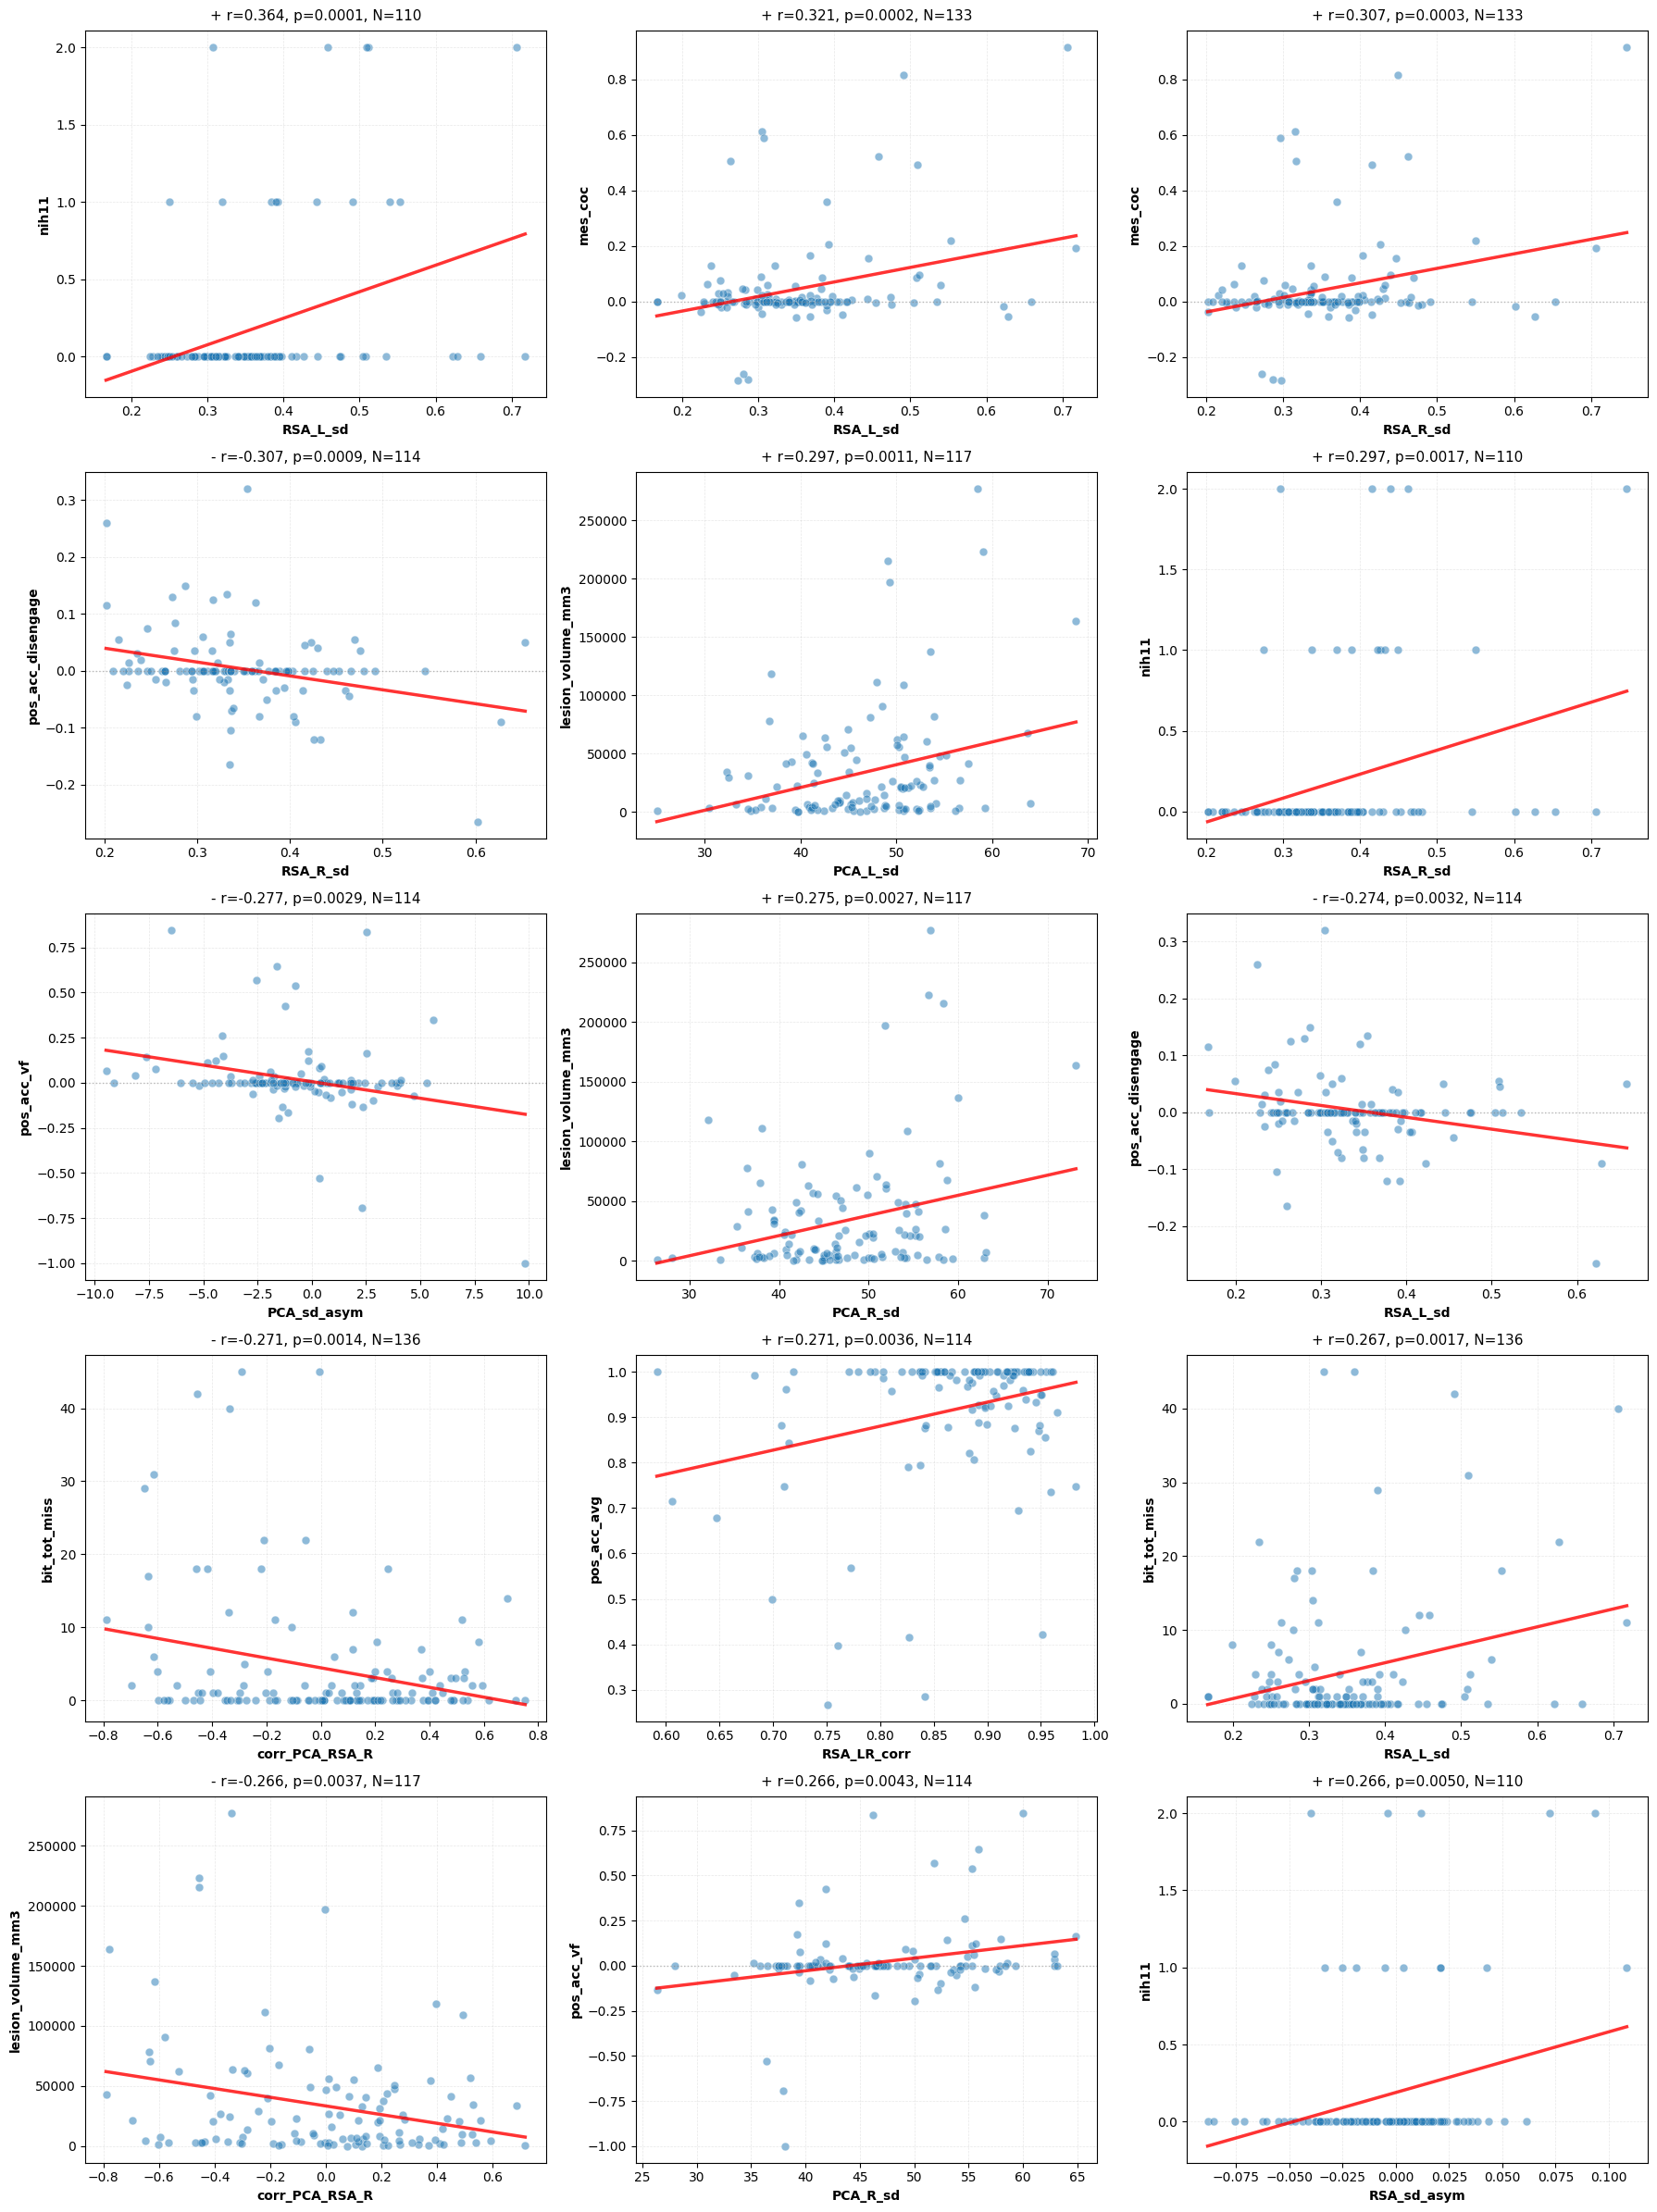

In [8]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl

# Load data
with open('/mnt/compneuro/stroke_data_with_oculomotor_features.pkl', 'rb') as f:
    df = pd.DataFrame(pkl.load(f))

acute = df[(df['Session'] == 'acute') & (df['subj_type'] == 0)].copy()

# ============================================================
# IDENTIFY TOP CORRELATIONS FROM HEATMAP
# ============================================================

OCULOMOTOR_FEATURES = [
    'PCA_L_sd', 'PCA_R_sd', 'PCA_sd_asym',
    'PCA_L_mssd', 'PCA_R_mssd',
    'PCA_L_ac1', 'PCA_R_ac1',
    'PCA_L_spec_entropy', 'PCA_R_spec_entropy',
    'RSA_L_sd', 'RSA_R_sd', 'RSA_sd_asym',
    'PCA_LR_corr', 'RSA_LR_corr',
    'corr_PCA_RSA_L', 'corr_PCA_RSA_R'
]

CLINICAL_MEASURES = [
    'nih_total', 'lesion_volume_mm3',
    'nih2', 'nih3', 'nih11',
    'mes_tot_miss', 'mes_coc',
    'bit_tot_miss', 'bit_coc',
    'pos_acc_avg', 'pos_acc_vf', 'pos_acc_disengage',
]

# Compute all correlations
results = []
for ocular in OCULOMOTOR_FEATURES:
    for clinical in CLINICAL_MEASURES:
        valid = acute[[ocular, clinical]].dropna()
        if len(valid) < 10:
            continue
        r, p = stats.pearsonr(valid[ocular], valid[clinical])
        results.append({
            'oculomotor': ocular,
            'clinical': clinical,
            'r': r,
            'p': p,
            'abs_r': abs(r),
            'n': len(valid)
        })

results_df = pd.DataFrame(results)

# Get top 15 by absolute correlation
top_15 = results_df.nlargest(15, 'abs_r')

print("="*60)
print("TOP 15 CORRELATIONS (by |r|)")
print("="*60)
print("\n" + top_15[['oculomotor', 'clinical', 'r', 'p']].to_string(index=False))

# ============================================================
# CREATE SCATTERPLOT GRID
# ============================================================

fig, axes = plt.subplots(5, 3, figsize=(18, 24))
axes = axes.flatten()

for i, (idx, row) in enumerate(top_15.iterrows()):
    if i >= 15:
        break
    
    ax = axes[i]
    ocular = row['oculomotor']
    clinical = row['clinical']
    
    # Get valid data
    valid = acute[[ocular, clinical]].dropna()
    x = valid[ocular]
    y = valid[clinical]
    
    # Scatterplot
    ax.scatter(x, y, alpha=0.5, s=40, edgecolors='white', linewidth=0.5)
    
    # Fit line
    z = np.polyfit(x, y, 1)
    p_fit = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p_fit(x_line), "r-", alpha=0.8, linewidth=2.5)
    
    # Labels and title
    ax.set_xlabel(ocular, fontsize=10, fontweight='bold')
    ax.set_ylabel(clinical, fontsize=10, fontweight='bold')
    
    # Title with stats
    direction = "+" if row['r'] > 0 else "-"
    title = f"{direction} r={row['r']:.3f}, p={row['p']:.4f}, N={row['n']}"
    ax.set_title(title, fontsize=11, pad=8)
    ax.grid(alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Add reference line for y=0 if relevant
    if y.min() < 0 < y.max():
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('/mnt/compneuro/top_15_correlations_scatterplots.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: top_15_correlations_scatterplots.png")

# ============================================================
# CATEGORIZE CORRELATION PATTERNS
# ============================================================

print("\n" + "="*60)
print("CORRELATION PATTERNS BY FEATURE TYPE")
print("="*60)

print("\n--- SD (Variability) Features ---")
sd_corr = results_df[results_df['oculomotor'].str.contains('_sd')].nlargest(5, 'abs_r')
print(sd_corr[['oculomotor', 'clinical', 'r', 'p']].to_string(index=False))

print("\n--- AC1 (Autocorrelation) Features ---")
ac1_corr = results_df[results_df['oculomotor'].str.contains('_ac1')].nlargest(5, 'abs_r')
print(ac1_corr[['oculomotor', 'clinical', 'r', 'p']].to_string(index=False))

print("\n--- Spectral Entropy Features ---")
entropy_corr = results_df[results_df['oculomotor'].str.contains('entropy')].nlargest(5, 'abs_r')
print(entropy_corr[['oculomotor', 'clinical', 'r', 'p']].to_string(index=False))

print("\n--- MSSD (Successive Difference) Features ---")
mssd_corr = results_df[results_df['oculomotor'].str.contains('mssd')].nlargest(5, 'abs_r')
print(mssd_corr[['oculomotor', 'clinical', 'r', 'p']].to_string(index=False))

# ============================================================
# INTERESTING NEGATIVE CORRELATIONS
# ============================================================

print("\n" + "="*60)
print("NEGATIVE CORRELATIONS (Entropy)")
print("="*60)

neg_corr = results_df[results_df['r'] < 0].nlargest(10, 'abs_r')
print("\n" + neg_corr[['oculomotor', 'clinical', 'r', 'p']].to_string(index=False))

# ============================================================
# DOMAIN-SPECIFIC PATTERNS
# ============================================================

print("\n" + "="*60)
print("CORRELATIONS BY CLINICAL DOMAIN")
print("="*60)

print("\n--- Visual Field Deficits (nih3) ---")
nih3_corr = results_df[results_df['clinical']=='nih3'].nlargest(5, 'abs_r')
print(nih3_corr[['oculomotor', 'r', 'p']].to_string(index=False))

print("\n--- Neglect (mes_tot_miss) ---")
neglect_corr = results_df[results_df['clinical']=='mes_tot_miss'].nlargest(5, 'abs_r')
print(neglect_corr[['oculomotor', 'r', 'p']].to_string(index=False))

print("\n--- Attention (pos_acc_avg) ---")
attention_corr = results_df[results_df['clinical']=='pos_acc_avg'].nlargest(5, 'abs_r')
print(attention_corr[['oculomotor', 'r', 'p']].to_string(index=False))

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

TOP 15 CORRELATIONS (by |r|)

    oculomotor          clinical         r        p
      RSA_L_sd             nih11  0.363687 0.000094
      RSA_L_sd           mes_coc  0.321491 0.000161
      RSA_R_sd           mes_coc  0.307478 0.000318
      RSA_R_sd pos_acc_disengage -0.307238 0.000884
      PCA_L_sd lesion_volume_mm3  0.297351 0.001131
      RSA_R_sd             nih11  0.296536 0.001657
   PCA_sd_asym        pos_acc_vf -0.276736 0.002877
      PCA_R_sd lesion_volume_mm3  0.274848 0.002709
      RSA_L_sd pos_acc_disengage -0.273827 0.003198
corr_PCA_RSA_R      bit_tot_miss -0.270945 0.001420
   RSA_LR_corr       pos_acc_avg  0.270668 0.003583
      RSA_L_sd      bit_tot_miss  0.266512 0.001711
corr_PCA_RSA_R lesion_volume_mm3 -0.266360 0.003698
      PCA_R_sd        pos_acc_vf  0.265850 0.004252
   RSA_sd_asym             nih11  0.265631 0.005036

✅ Saved: top_15_correlations_scatterplots.png

CORRELATION PATTERNS BY FEATURE TYPE

--- SD (Variability) Features ---
oculomotor        

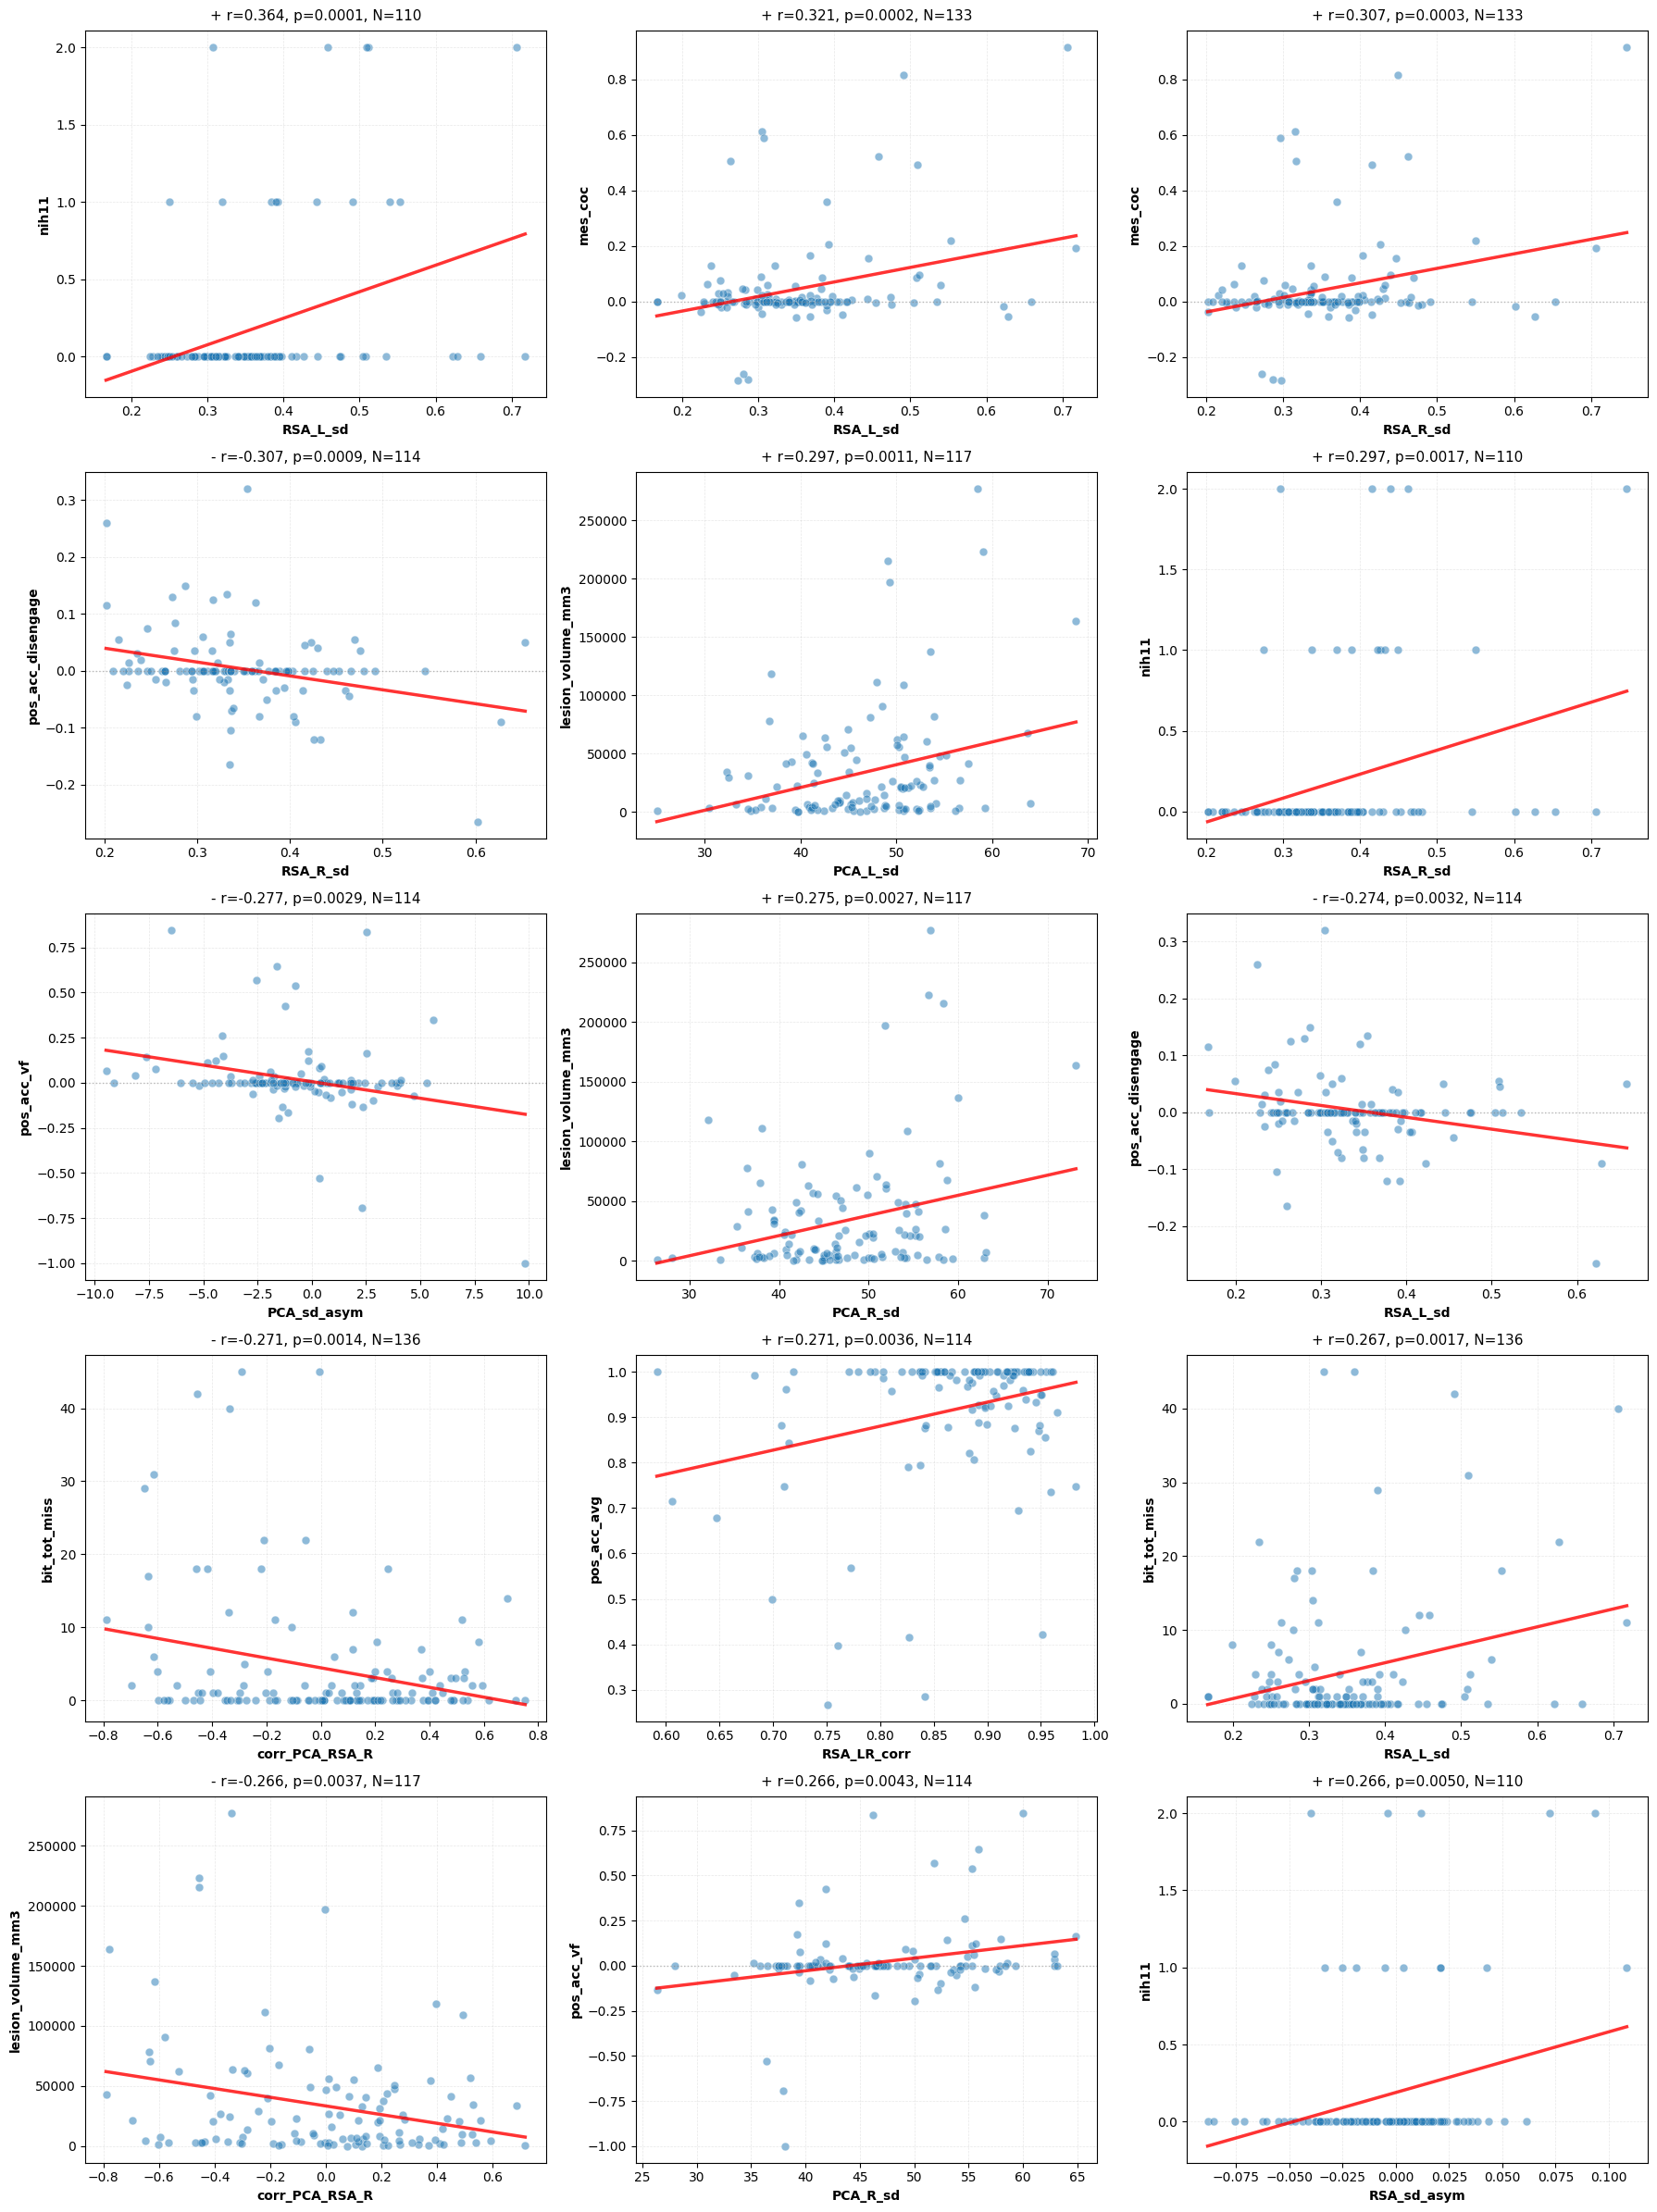

In [19]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl

# Load data
with open('/mnt/compneuro/stroke_data_with_oculomotor_features.pkl', 'rb') as f:
    df = pd.DataFrame(pkl.load(f))

acute = df[(df['Session'] == 'acute') & (df['subj_type'] == 0)].copy()

# ============================================================
# IDENTIFY TOP CORRELATIONS FROM HEATMAP
# ============================================================

OCULOMOTOR_FEATURES = [
    'PCA_L_sd', 'PCA_R_sd', 'PCA_sd_asym',
    'PCA_L_mssd', 'PCA_R_mssd',
    'PCA_L_ac1', 'PCA_R_ac1',
    'PCA_L_spec_entropy', 'PCA_R_spec_entropy',
    'RSA_L_sd', 'RSA_R_sd', 'RSA_sd_asym',
    'PCA_LR_corr', 'RSA_LR_corr',
    'corr_PCA_RSA_L', 'corr_PCA_RSA_R'
]

CLINICAL_MEASURES = [
    'nih_total', 'lesion_volume_mm3',
    'nih2', 'nih3', 'nih11',
    'mes_tot_miss', 'mes_coc',
    'bit_tot_miss', 'bit_coc',
    'pos_acc_avg', 'pos_acc_vf', 'pos_acc_disengage',
]

# Compute all correlations
results = []
for ocular in OCULOMOTOR_FEATURES:
    for clinical in CLINICAL_MEASURES:
        valid = acute[[ocular, clinical]].dropna()
        if len(valid) < 10:
            continue
        r, p = stats.pearsonr(valid[ocular], valid[clinical])
        results.append({
            'oculomotor': ocular,
            'clinical': clinical,
            'r': r,
            'p': p,
            'abs_r': abs(r),
            'n': len(valid)
        })

results_df = pd.DataFrame(results)

# Get top 15 by absolute correlation
top_15 = results_df.nlargest(15, 'abs_r')

print("="*60)
print("TOP 15 CORRELATIONS (by |r|)")
print("="*60)
print("\n" + top_15[['oculomotor', 'clinical', 'r', 'p']].to_string(index=False))

# ============================================================
# CREATE SCATTERPLOT GRID
# ============================================================

fig, axes = plt.subplots(5, 3, figsize=(18, 24))
axes = axes.flatten()

for i, (idx, row) in enumerate(top_15.iterrows()):
    if i >= 15:
        break
    
    ax = axes[i]
    ocular = row['oculomotor']
    clinical = row['clinical']
    
    # Get valid data
    valid = acute[[ocular, clinical]].dropna()
    x = valid[ocular]
    y = valid[clinical]
    
    # Scatterplot
    ax.scatter(x, y, alpha=0.5, s=40, edgecolors='white', linewidth=0.5)
    
    # Fit line
    z = np.polyfit(x, y, 1)
    p_fit = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p_fit(x_line), "r-", alpha=0.8, linewidth=2.5)
    
    # Labels and title
    ax.set_xlabel(ocular, fontsize=10, fontweight='bold')
    ax.set_ylabel(clinical, fontsize=10, fontweight='bold')
    
    # Title with stats
    direction = "+" if row['r'] > 0 else "-"
    title = f"{direction} r={row['r']:.3f}, p={row['p']:.4f}, N={row['n']}"
    ax.set_title(title, fontsize=11, pad=8)
    ax.grid(alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Add reference line for y=0 if relevant
    if y.min() < 0 < y.max():
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('/mnt/compneuro/top_15_correlations_scatterplots.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: top_15_correlations_scatterplots.png")

# ============================================================
# CATEGORIZE CORRELATION PATTERNS
# ============================================================

print("\n" + "="*60)
print("CORRELATION PATTERNS BY FEATURE TYPE")
print("="*60)

print("\n--- SD (Variability) Features ---")
sd_corr = results_df[results_df['oculomotor'].str.contains('_sd')].nlargest(5, 'abs_r')
print(sd_corr[['oculomotor', 'clinical', 'r', 'p']].to_string(index=False))

print("\n--- AC1 (Autocorrelation) Features ---")
ac1_corr = results_df[results_df['oculomotor'].str.contains('_ac1')].nlargest(5, 'abs_r')
print(ac1_corr[['oculomotor', 'clinical', 'r', 'p']].to_string(index=False))

print("\n--- Spectral Entropy Features ---")
entropy_corr = results_df[results_df['oculomotor'].str.contains('entropy')].nlargest(5, 'abs_r')
print(entropy_corr[['oculomotor', 'clinical', 'r', 'p']].to_string(index=False))

print("\n--- MSSD (Successive Difference) Features ---")
mssd_corr = results_df[results_df['oculomotor'].str.contains('mssd')].nlargest(5, 'abs_r')
print(mssd_corr[['oculomotor', 'clinical', 'r', 'p']].to_string(index=False))

# ============================================================
# INTERESTING NEGATIVE CORRELATIONS
# ============================================================

print("\n" + "="*60)
print("NEGATIVE CORRELATIONS (Entropy)")
print("="*60)

neg_corr = results_df[results_df['r'] < 0].nlargest(10, 'abs_r')
print("\n" + neg_corr[['oculomotor', 'clinical', 'r', 'p']].to_string(index=False))

# ============================================================
# DOMAIN-SPECIFIC PATTERNS
# ============================================================

print("\n" + "="*60)
print("CORRELATIONS BY CLINICAL DOMAIN")
print("="*60)

print("\n--- Visual Field Deficits (nih3) ---")
nih3_corr = results_df[results_df['clinical']=='nih3'].nlargest(5, 'abs_r')
print(nih3_corr[['oculomotor', 'r', 'p']].to_string(index=False))

print("\n--- Neglect (mes_tot_miss) ---")
neglect_corr = results_df[results_df['clinical']=='mes_tot_miss'].nlargest(5, 'abs_r')
print(neglect_corr[['oculomotor', 'r', 'p']].to_string(index=False))

print("\n--- Attention (pos_acc_avg) ---")
attention_corr = results_df[results_df['clinical']=='pos_acc_avg'].nlargest(5, 'abs_r')
print(attention_corr[['oculomotor', 'r', 'p']].to_string(index=False))

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

# Ablation on prediction 

Patients with acute + 3-month: N=97

CREATING RECOVERY PREDICTION DATASET

Total patients with recovery data: 96
Visual score at acute: 0.919 ± 0.115

After excluding ceiling (visual_acute ≥ 0.95):
  N = 38
  Visual acute: 0.816 ± 0.126
  Delta visual: 0.113 ± 0.113

Final N with complete data: 27

RECOVERY PREDICTION MODELS

Sample size: N=27
Outcome variance: 0.012906

--- Model 1: Baseline (age + NIHSS + lesion volume) ---
  Cross-validated R²: -0.240 ± 0.883
  Individual folds: ['-1.953', '0.357', '0.074', '-0.147', '0.468']

  Coefficients:
    age                 : -0.0180
    nih_total           :  0.0119
    lesion_volume_mm3   :  0.0667

--- Model 2: Baseline + Oculomotor ---
  Cross-validated R²: -0.497 ± 1.430
  Individual folds: ['-3.285', '-0.143', '0.277', '-0.083', '0.751']

  Coefficients:
    age                 : -0.0266
    nih_total           :  0.0189
    lesion_volume_mm3   :  0.0680
    RSA_L_sd            :  0.0071
    PCA_L_sd            : -0.0169
    PCA_L_ac1

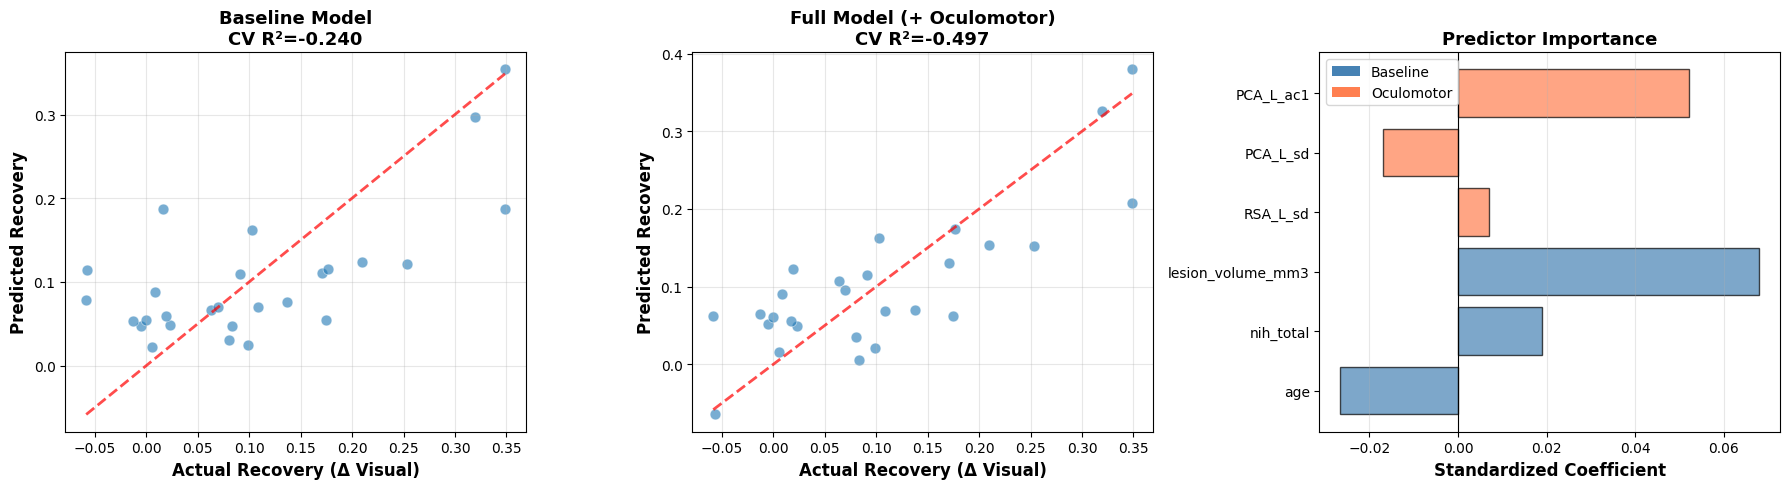

In [20]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl

# ============================================================
# LOAD DATA
# ============================================================
with open('/mnt/compneuro/stroke_data_with_oculomotor_features.pkl', 'rb') as f:
    df = pd.DataFrame(pkl.load(f))

# Get acute and 3-month data
acute = df[(df['Session'] == 'acute') & (df['subj_type'] == 0)].copy()
followup = df[(df['Session'] == 'followup') & (df['subj_type'] == 0)].copy()

# Match patients with both timepoints
ids_matched = set(acute['ID']) & set(followup['ID'])
print(f"Patients with acute + 3-month: N={len(ids_matched)}")

# ============================================================
# CREATE RECOVERY DATASET
# ============================================================
print("\n" + "="*60)
print("CREATING RECOVERY PREDICTION DATASET")
print("="*60)

recovery_data = []

for patient_id in ids_matched:
    acute_row = acute[acute['ID'] == patient_id].iloc[0]
    followup_row = followup[followup['ID'] == patient_id].iloc[0]
    
    # Calculate visual composite scores
    def calc_visual_score(row):
        scores = []
        if pd.notna(row.get('pos_acc_avg')): scores.append(row['pos_acc_avg'])
        if pd.notna(row.get('mes_tot_miss')): scores.append(1 - row['mes_tot_miss']/60)
        if pd.notna(row.get('bit_tot_miss')): scores.append(1 - row['bit_tot_miss']/54)
        if pd.notna(row.get('nih3')): scores.append(1 - row['nih3']/3)
        if pd.notna(row.get('nih11')): scores.append(1 - row['nih11']/2)
        return np.mean(scores) if len(scores) >= 3 else np.nan
    
    vis_acute = calc_visual_score(acute_row)
    vis_3mo = calc_visual_score(followup_row)
    
    if pd.isna(vis_acute) or pd.isna(vis_3mo):
        continue
    
    delta_visual = vis_3mo - vis_acute
    
    # Baseline predictors
    age = acute_row.get('age')
    nih_total = acute_row.get('nih_total')
    lesion_vol = acute_row.get('lesion_volume_mm3')
    
    # Oculomotor features (select key ones)
    mvpa_l_sd = acute_row.get('RSA_L_sd')
    pca_l_sd = acute_row.get('PCA_L_sd')
    pca_l_ac1 = acute_row.get('PCA_L_ac1')
    
    recovery_data.append({
        'ID': patient_id,
        'visual_acute': vis_acute,
        'visual_3mo': vis_3mo,
        'delta_visual': delta_visual,
        'age': age,
        'nih_total': nih_total,
        'lesion_volume_mm3': lesion_vol,
        'RSA_L_sd': mvpa_l_sd,
        'PCA_L_sd': pca_l_sd,
        'PCA_L_ac1': pca_l_ac1,
    })

recovery_df = pd.DataFrame(recovery_data)

# ============================================================
# EXCLUDE CEILING PATIENTS (Critical!)
# ============================================================
print(f"\nTotal patients with recovery data: {len(recovery_df)}")
print(f"Visual score at acute: {recovery_df['visual_acute'].mean():.3f} ± {recovery_df['visual_acute'].std():.3f}")

# Exclude patients at ceiling (visual_acute > 0.95)
CEILING_THRESHOLD = 0.95
recovery_df_impaired = recovery_df[recovery_df['visual_acute'] < CEILING_THRESHOLD].copy()

print(f"\nAfter excluding ceiling (visual_acute ≥ {CEILING_THRESHOLD}):")
print(f"  N = {len(recovery_df_impaired)}")
print(f"  Visual acute: {recovery_df_impaired['visual_acute'].mean():.3f} ± {recovery_df_impaired['visual_acute'].std():.3f}")
print(f"  Delta visual: {recovery_df_impaired['delta_visual'].mean():.3f} ± {recovery_df_impaired['delta_visual'].std():.3f}")

# Drop rows with missing data
BASELINE_PREDICTORS = ['age', 'nih_total', 'lesion_volume_mm3']
OCULOMOTOR_PREDICTORS = ['RSA_L_sd', 'PCA_L_sd', 'PCA_L_ac1']
OUTCOME = 'delta_visual'

data_complete = recovery_df_impaired[BASELINE_PREDICTORS + OCULOMOTOR_PREDICTORS + [OUTCOME]].dropna()
print(f"\nFinal N with complete data: {len(data_complete)}")

if len(data_complete) < 20:
    print("\n⚠️  WARNING: Sample size very small (N<20)")
    print("Results may be unstable. Consider using all patients (including ceiling).")

# ============================================================
# PREDICTION MODELS
# ============================================================
print("\n" + "="*60)
print("RECOVERY PREDICTION MODELS")
print("="*60)

X_baseline = data_complete[BASELINE_PREDICTORS].values
X_oculomotor = data_complete[OCULOMOTOR_PREDICTORS].values
X_full = np.hstack([X_baseline, X_oculomotor])
y = data_complete[OUTCOME].values

n_samples = len(y)
print(f"\nSample size: N={n_samples}")
print(f"Outcome variance: {np.var(y):.6f}")

# Standardize predictors
scaler_base = StandardScaler()
scaler_ocular = StandardScaler()
X_baseline_scaled = scaler_base.fit_transform(X_baseline)
X_oculomotor_scaled = scaler_ocular.fit_transform(X_oculomotor)
X_full_scaled = np.hstack([X_baseline_scaled, X_oculomotor_scaled])

# ============================================================
# MODEL 1: BASELINE ONLY
# ============================================================
print("\n--- Model 1: Baseline (age + NIHSS + lesion volume) ---")

# Cross-validated R²
cv = KFold(n_splits=min(5, n_samples), shuffle=True, random_state=42)
r2_baseline_cv = cross_val_score(LinearRegression(), X_baseline_scaled, y, cv=cv, scoring='r2')

print(f"  Cross-validated R²: {r2_baseline_cv.mean():.3f} ± {r2_baseline_cv.std():.3f}")
print(f"  Individual folds: {[f'{r:.3f}' for r in r2_baseline_cv]}")

# Train on full data for coefficients
model_baseline = LinearRegression().fit(X_baseline_scaled, y)
print(f"\n  Coefficients:")
for i, pred in enumerate(BASELINE_PREDICTORS):
    print(f"    {pred:20s}: {model_baseline.coef_[i]:7.4f}")

# ============================================================
# MODEL 2: BASELINE + OCULOMOTOR
# ============================================================
print("\n--- Model 2: Baseline + Oculomotor ---")

r2_full_cv = cross_val_score(LinearRegression(), X_full_scaled, y, cv=cv, scoring='r2')

print(f"  Cross-validated R²: {r2_full_cv.mean():.3f} ± {r2_full_cv.std():.3f}")
print(f"  Individual folds: {[f'{r:.3f}' for r in r2_full_cv]}")

# Train on full data
model_full = LinearRegression().fit(X_full_scaled, y)
print(f"\n  Coefficients:")
all_predictors = BASELINE_PREDICTORS + OCULOMOTOR_PREDICTORS
for i, pred in enumerate(all_predictors):
    print(f"    {pred:20s}: {model_full.coef_[i]:7.4f}")

# ============================================================
# MODEL COMPARISON
# ============================================================
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

delta_r2_cv = r2_full_cv.mean() - r2_baseline_cv.mean()

print(f"\nCross-validated R²:")
print(f"  Baseline:          {r2_baseline_cv.mean():.3f}")
print(f"  Full (+ oculomotor): {r2_full_cv.mean():.3f}")
print(f"  ΔR² (improvement):  {delta_r2_cv:+.3f}")

# Nested F-test
rss_baseline = np.sum((y - model_baseline.predict(X_baseline_scaled))**2)
rss_full = np.sum((y - model_full.predict(X_full_scaled))**2)

p_baseline = len(BASELINE_PREDICTORS)
p_full = len(BASELINE_PREDICTORS) + len(OCULOMOTOR_PREDICTORS)

f_stat = ((rss_baseline - rss_full) / (p_full - p_baseline)) / (rss_full / (n_samples - p_full - 1))
p_value = 1 - stats.f.cdf(f_stat, p_full - p_baseline, n_samples - p_full - 1)

print(f"\nNested F-test:")
print(f"  F-statistic = {f_stat:.3f}")
print(f"  p-value = {p_value:.4f}")

if p_value < 0.05:
    print(f"  ✅ Oculomotor features significantly improve prediction (p<0.05)")
elif p_value < 0.10:
    print(f"  ⚠️  Marginal improvement (p<0.10)")
else:
    print(f"  ❌ No significant improvement (p≥0.10)")

# ============================================================
# VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Predicted vs Actual (Baseline)
y_pred_baseline = model_baseline.predict(X_baseline_scaled)
axes[0].scatter(y, y_pred_baseline, alpha=0.6, s=60, edgecolors='white', linewidth=0.5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, alpha=0.7)
axes[0].set_xlabel('Actual Recovery (Δ Visual)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Recovery', fontsize=12, fontweight='bold')
axes[0].set_title(f'Baseline Model\nCV R²={r2_baseline_cv.mean():.3f}', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# Plot 2: Predicted vs Actual (Full)
y_pred_full = model_full.predict(X_full_scaled)
axes[1].scatter(y, y_pred_full, alpha=0.6, s=60, edgecolors='white', linewidth=0.5)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, alpha=0.7)
axes[1].set_xlabel('Actual Recovery (Δ Visual)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Recovery', fontsize=12, fontweight='bold')
axes[1].set_title(f'Full Model (+ Oculomotor)\nCV R²={r2_full_cv.mean():.3f}', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

# Plot 3: Coefficient comparison
coef_labels = BASELINE_PREDICTORS + OCULOMOTOR_PREDICTORS
coef_values = model_full.coef_

colors = ['steelblue']*len(BASELINE_PREDICTORS) + ['coral']*len(OCULOMOTOR_PREDICTORS)
bars = axes[2].barh(range(len(coef_values)), coef_values, color=colors, alpha=0.7, edgecolor='black')
axes[2].set_yticks(range(len(coef_labels)))
axes[2].set_yticklabels(coef_labels, fontsize=10)
axes[2].axvline(0, color='black', linestyle='-', linewidth=0.8)
axes[2].set_xlabel('Standardized Coefficient', fontsize=12, fontweight='bold')
axes[2].set_title('Predictor Importance', fontsize=13, fontweight='bold')
axes[2].grid(alpha=0.3, axis='x')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Baseline'),
                   Patch(facecolor='coral', label='Oculomotor')]
axes[2].legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.savefig('/mnt/compneuro/recovery_prediction_results.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: recovery_prediction_results.png")

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "="*60)
print("SUMMARY FOR OPUS GRANT")
print("="*60)

summary = pd.DataFrame({
    'Model': ['Baseline', 'Full (+ Oculomotor)'],
    'Predictors': [
        'Age, NIHSS, Lesion Volume',
        'Age, NIHSS, Lesion Volume, RSA_L_sd, PCA_L_sd, PCA_L_ac1'
    ],
    'N': [n_samples, n_samples],
    'R² (CV)': [f"{r2_baseline_cv.mean():.3f}", f"{r2_full_cv.mean():.3f}"],
    'ΔR²': ['—', f"{delta_r2_cv:+.3f}"],
    'p-value': ['—', f"{p_value:.4f}"]
})

print("\n" + summary.to_string(index=False))

print("\n" + "="*60)
print("ANALYSIS 2 COMPLETE")
print("="*60)

# Stepmix

Clustering on 9 CLINICAL features (NO oculomotor):
  - nih2
  - nih3
  - nih11
  - mes_tot_miss
  - mes_coc
  - bit_tot_miss
  - pos_acc_avg
  - pos_acc_vf
  - pos_acc_disengage

Data prepared: X shape (58, 9), Z shape (58, 2)

MODEL SELECTION: k=2 to k=5
Feature types: 5 continuous, 2 binary, 2 categorical

Fitting k=2...
Fitting StepMix...


Initializations (n_init) : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 38.51it/s, max_LL=282, max_avg_LL=4.87]


  BIC=-284.4, min cluster size=23

Fitting k=3...
Fitting StepMix...


Initializations (n_init) : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 22.35it/s, max_LL=471, max_avg_LL=8.12]


  BIC=-517.8, min cluster size=11

Fitting k=4...
Fitting StepMix...


Initializations (n_init) : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 22.78it/s, max_LL=559, max_avg_LL=9.63]


  BIC=-546.4, min cluster size=7

Fitting k=5...
Fitting StepMix...


Initializations (n_init) : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 21.26it/s, max_LL=588, max_avg_LL=10.1]


  BIC=-460.3, min cluster size=1

 n_clusters         bic         aic  entropy  min_cluster_size
          2 -284.397129 -422.446811 0.001285                23
          3 -517.783205 -727.948392 0.002011                11
          4 -546.365188 -828.645881 0.000557                 7
          5 -460.333856 -814.730054 0.000100                 1

✅ Optimal k = 2

CLUSTER CHARACTERISTICS (k=2)

CLUSTER 0 (N=23, 39.7%)
Age: 55.7 ± 10.2
NIHSS total: 3.7 ± 3.2
Visual recovery: 0.07 ± 0.10

Clinical Visual Profile:
  nih2                     :   0.09   
  nih3                     :   0.04   
  nih11                    :   0.13   
  mes_tot_miss             :  12.17 ↑↑
  mes_coc                  :   0.01   
  bit_tot_miss             :   3.83 ↑↑
  pos_acc_avg              :   0.85 ↓↓
  pos_acc_vf               :  -0.08   
  pos_acc_disengage        :   0.00   

Oculomotor Profile (fMRI):
  PCA_L_sd_raw             :  45.461  
  PCA_L_ac1_raw            :   0.822  
  RSA_L_sd_raw            

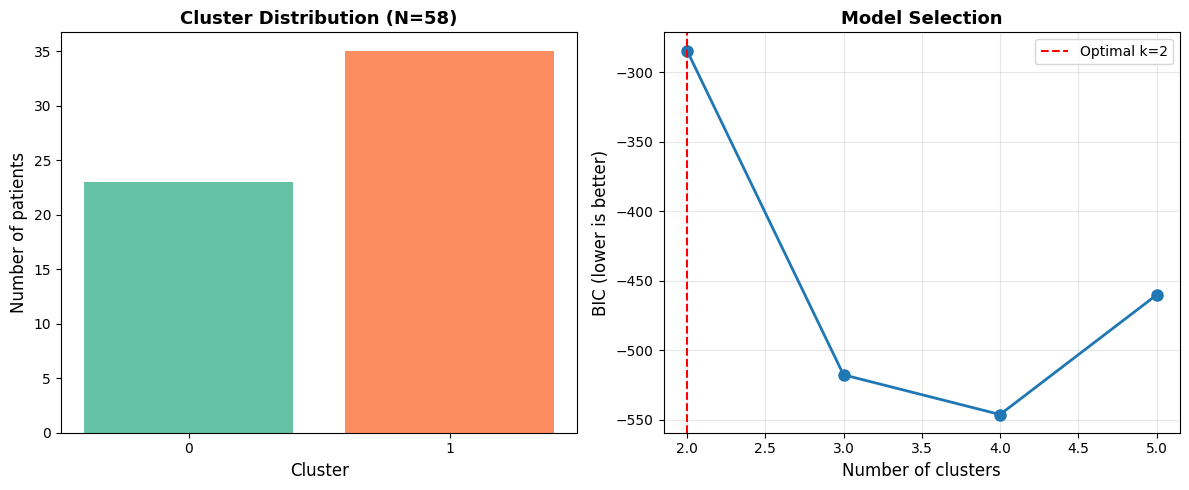

In [21]:
import pandas as pd
import numpy as np
from stepmix.stepmix import StepMix
from stepmix.utils import get_mixed_descriptor
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv('/mnt/compneuro/opus_analysis_dataset.csv')
full_df = pd.read_csv('/mnt/compneuro/full_dataset_with_controls.csv')
acute_full = full_df[full_df['Session'] == 'acute']

# Merge clinical visual tests
visual_tests = ['nih2', 'nih3', 'nih11', 'mes_tot_miss', 'mes_coc', 
                'bit_tot_miss', 'pos_acc_avg', 'pos_acc_vf', 'pos_acc_disengage']

df_merged = df.merge(
    acute_full[['ID'] + visual_tests], 
    on='ID', 
    how='left'
)

# ============================================================
# CLUSTERING FEATURES (CLINICAL ONLY - NO OCULOMOTOR)
# ============================================================
CLUSTERING_FEATURES = [
    # Domain 1: Oculomotor/Gaze (clinical)
    'nih2',  # NIHSS Best Gaze
    
    # Domain 2: Visual Fields
    'nih3',  # NIHSS Visual Fields
    
    # Domain 3: Neglect/Spatial Attention
    'nih11',         # Extinction
    'mes_tot_miss',  # Mesulam severity
    'mes_coc',       # Mesulam spatial bias
    'bit_tot_miss',  # BIT severity
    
    # Domain 4: Attentional Performance
    'pos_acc_avg',        # Overall accuracy
    'pos_acc_vf',         # Visual field bias
    'pos_acc_disengage'   # Disengagement deficit
]

# Covariates
COVARIATES = ['age', 'gender']

print(f"Clustering on {len(CLUSTERING_FEATURES)} CLINICAL features (NO oculomotor):")
for feat in CLUSTERING_FEATURES:
    print(f"  - {feat}")

# ============================================================
# PREPARE DATA
# ============================================================
X = df_merged[CLUSTERING_FEATURES].copy()
Z = df_merged[COVARIATES].copy()

# Impute missing
for col in X.columns:
    if X[col].nunique() == 2:
        X[col] = X[col].fillna(X[col].mode()[0])
    else:
        X[col] = X[col].fillna(X[col].median())

for col in Z.columns:
    Z[col] = Z[col].fillna(Z[col].median())

print(f"\nData prepared: X shape {X.shape}, Z shape {Z.shape}")

# ============================================================
# MODEL SELECTION
# ============================================================
print("\n" + "="*60)
print("MODEL SELECTION: k=2 to k=5")
print("="*60)

continuous = [c for c in X.columns if X[c].nunique() > 10]
binary = [c for c in X.columns if X[c].nunique() == 2]
categorical = [c for c in X.columns if 2 < X[c].nunique() <= 10]

print(f"Feature types: {len(continuous)} continuous, {len(binary)} binary, {len(categorical)} categorical")

mixed_data, mixed_descriptor = get_mixed_descriptor(
    dataframe=X,
    continuous=continuous,
    binary=binary,
    categorical=categorical
)

results = []
models = {}

for n_clusters in range(2, 6):
    print(f"\nFitting k={n_clusters}...")
    
    model = StepMix(
        n_components=n_clusters,
        measurement=mixed_descriptor,
        structural="covariate",
        n_steps=1,
        n_init=100,
        random_state=42,
        verbose=0
    )
    
    model.fit(mixed_data, Z)
    
    bic = model.bic(mixed_data)
    aic = model.aic(mixed_data)
    probs = model.predict_proba(mixed_data)
    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1).mean()
    labels = model.predict(mixed_data)
    sizes = pd.Series(labels).value_counts().sort_index()
    
    results.append({
        'n_clusters': n_clusters,
        'bic': bic,
        'aic': aic,
        'entropy': entropy,
        'min_cluster_size': sizes.min()
    })
    
    models[n_clusters] = (model, labels)
    print(f"  BIC={bic:.1f}, min cluster size={sizes.min()}")

results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))

# Select optimal k
valid_k = results_df[results_df['min_cluster_size'] >= 12]
if len(valid_k) > 0:
    optimal_k = valid_k.loc[valid_k['bic'].idxmin(), 'n_clusters']
else:
    optimal_k = results_df.loc[results_df['bic'].idxmin(), 'n_clusters']

print(f"\n✅ Optimal k = {optimal_k}")

# ============================================================
# EXTRACT CLUSTERING & CHARACTERIZE
# ============================================================
best_model, cluster_labels = models[optimal_k]
df_merged['cluster'] = cluster_labels

print("\n" + "="*60)
print(f"CLUSTER CHARACTERISTICS (k={optimal_k})")
print("="*60)

for k in range(optimal_k):
    mask = cluster_labels == k
    n = mask.sum()
    
    print(f"\n{'='*40}")
    print(f"CLUSTER {k} (N={n}, {100*n/len(df_merged):.1f}%)")
    print(f"{'='*40}")
    
    print(f"Age: {df_merged.loc[mask, 'age'].mean():.1f} ± {df_merged.loc[mask, 'age'].std():.1f}")
    print(f"NIHSS total: {df_merged.loc[mask, 'nih_total'].mean():.1f} ± {df_merged.loc[mask, 'nih_total'].std():.1f}")
    print(f"Visual recovery: {df_merged.loc[mask, 'delta_visual'].mean():.2f} ± {df_merged.loc[mask, 'delta_visual'].std():.2f}")
    
    print(f"\nClinical Visual Profile:")
    for feat in CLUSTERING_FEATURES:
        cluster_mean = df_merged.loc[mask, feat].mean()
        overall_mean = df_merged[feat].mean()
        diff = cluster_mean - overall_mean
        
        if abs(diff) > 0.5 * df_merged[feat].std():
            marker = "↑↑" if diff > 0 else "↓↓"
        else:
            marker = "  "
        
        print(f"  {feat:25s}: {cluster_mean:6.2f} {marker}")
    
    print(f"\nOculomotor Profile (fMRI):")
    for feat in ['PCA_L_sd_raw', 'PCA_L_ac1_raw', 'RSA_L_sd_raw', 'PCA_LR_corr_raw']:
        cluster_mean = df_merged.loc[mask, feat].mean()
        overall_mean = df_merged[feat].mean()
        diff = cluster_mean - overall_mean
        marker = "↑" if diff > 0.3*df_merged[feat].std() else ("↓" if diff < -0.3*df_merged[feat].std() else " ")
        print(f"  {feat:25s}: {cluster_mean:7.3f} {marker}")

# Save
df_merged.to_csv('/mnt/compneuro/analysis_with_clusters.csv', index=False)
print(f"\n✅ Saved: analysis_with_clusters.csv")

# ============================================================
# VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sizes = pd.Series(cluster_labels).value_counts().sort_index()
axes[0].bar(range(optimal_k), sizes.values, color=sns.color_palette('Set2', optimal_k))
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Number of patients', fontsize=12)
axes[0].set_title(f'Cluster Distribution (N={len(df_merged)})', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(optimal_k))

axes[1].plot(results_df['n_clusters'], results_df['bic'], 'o-', linewidth=2, markersize=8)
axes[1].axvline(optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
axes[1].set_xlabel('Number of clusters', fontsize=12)
axes[1].set_ylabel('BIC (lower is better)', fontsize=12)
axes[1].set_title('Model Selection', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/compneuro/clustering_results_clinical_only.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: clustering_results_clinical_only.png")

print("\n" + "="*60)
print("NOW: Clusters defined by CLINICAL data")
print("NEXT: Test if OCULOMOTOR features predict recovery")
print("="*60)

Analysis dataset: N=58
Cluster 0: 23
Cluster 1: 35

OVERALL PREDICTION (N=58)

--- Baseline Model (age + NIHSS + lesion volume) ---
  N = 50
  R² (training) = 0.359
  R² (LOOCV)    = 0.107
  R² (adjusted) = 0.317
  RMSE (LOOCV)  = 0.070

--- Full Model (baseline + oculomotor) ---
  N = 50
  R² (training) = 0.390
  R² (LOOCV)    = -0.189
  R² (adjusted) = 0.271
  RMSE (LOOCV)  = 0.081

--- Model Comparison ---
  ΔR² (oculomotor added value) = 0.031
  F-statistic = 0.41
  p-value = 0.8357
  ⚠️  Oculomotor features do not significantly improve prediction

CLUSTER-SPECIFIC PREDICTION

CLUSTER 0 (N=23)

--- Baseline Model ---
  R² (LOOCV) = -0.076
  RMSE       = 0.101

--- Full Model (+ oculomotor) ---
  R² (LOOCV) = -3.618
  RMSE       = 0.210

--- Model Comparison ---
  ΔR² = 0.102
  p-value = 0.7888

CLUSTER 1 (N=35)

--- Baseline Model ---
  R² (LOOCV) = -0.235
  RMSE       = 0.017

--- Full Model (+ oculomotor) ---
  R² (LOOCV) = -0.614
  RMSE       = 0.019

--- Model Comparison ---
  

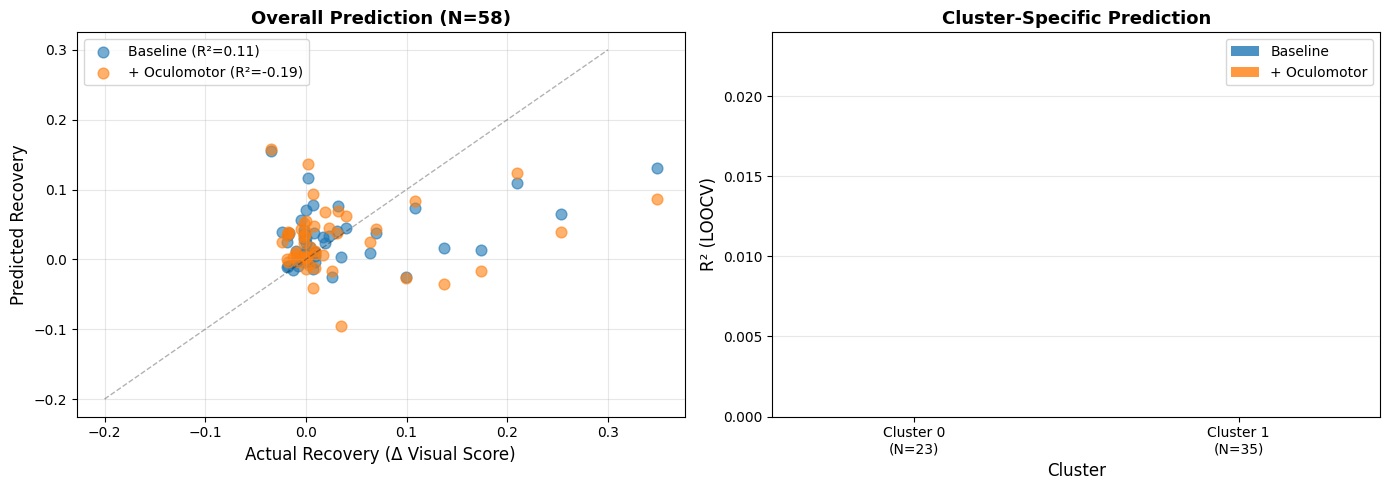

In [22]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# LOAD DATA WITH CLUSTERS
# ============================================================
df = pd.read_csv('/mnt/compneuro/analysis_with_clusters.csv')
print(f"Analysis dataset: N={len(df)}")
print(f"Cluster 0: {(df['cluster']==0).sum()}")
print(f"Cluster 1: {(df['cluster']==1).sum()}")

# ============================================================
# DEFINE PREDICTORS
# ============================================================

# Baseline clinical predictors
BASELINE_PREDICTORS = ['age', 'nih_total', 'lesion_volume_mm3']

# Oculomotor predictors (key features from VPH abstract)
OCULOMOTOR_PREDICTORS = [
    'PCA_L_sd_raw',
    'PCA_L_ac1_raw',
    'PCA_sd_asym_raw',
    'RSA_L_sd_raw',
    'PCA_LR_corr_raw'
]

# Full model = baseline + oculomotor
FULL_PREDICTORS = BASELINE_PREDICTORS + OCULOMOTOR_PREDICTORS

# Outcome
OUTCOME = 'delta_visual'

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def loocv_r2(X, y):
    """Leave-one-out cross-validated R²"""
    loo = LeaveOneOut()
    y_pred = np.zeros(len(y))
    
    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx]
        
        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred[test_idx] = model.predict(X_test)
    
    # Calculate R²
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot)
    
    return r2, y_pred

def fit_and_evaluate(df_subset, predictors, outcome):
    """Fit model and return metrics"""
    # Prepare data (drop missing)
    data = df_subset[predictors + [outcome]].dropna()
    X = data[predictors].values
    y = data[outcome].values
    n = len(y)
    p = len(predictors)
    
    if n < p + 2:
        return None  # Not enough data
    
    # LOOCV R²
    r2_cv, y_pred = loocv_r2(X, y)
    
    # Fit full model for coefficients
    model = LinearRegression()
    model.fit(X, y)
    y_pred_full = model.predict(X)
    
    # Training R²
    ss_res = np.sum((y - y_pred_full)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2_train = 1 - (ss_res / ss_tot)
    
    # Adjusted R²
    r2_adj = 1 - (1 - r2_train) * (n - 1) / (n - p - 1)
    
    # RMSE (cross-validated)
    rmse_cv = np.sqrt(np.mean((y - y_pred)**2))
    
    return {
        'n': n,
        'p': p,
        'r2_train': r2_train,
        'r2_cv': r2_cv,
        'r2_adj': r2_adj,
        'rmse_cv': rmse_cv,
        'y_true': y,
        'y_pred': y_pred,
        'coefficients': dict(zip(predictors, model.coef_))
    }

def compare_models(df_subset, baseline_preds, full_preds, outcome):
    """Compare nested models using F-test"""
    data = df_subset[full_preds + [outcome]].dropna()
    X_baseline = data[baseline_preds].values
    X_full = data[full_preds].values
    y = data[outcome].values
    
    n = len(y)
    p_baseline = len(baseline_preds)
    p_full = len(full_preds)
    
    # Fit both models
    model_baseline = LinearRegression().fit(X_baseline, y)
    model_full = LinearRegression().fit(X_full, y)
    
    # RSS
    rss_baseline = np.sum((y - model_baseline.predict(X_baseline))**2)
    rss_full = np.sum((y - model_full.predict(X_full))**2)
    
    # F-test for nested models
    f_stat = ((rss_baseline - rss_full) / (p_full - p_baseline)) / (rss_full / (n - p_full - 1))
    p_value = 1 - stats.f.cdf(f_stat, p_full - p_baseline, n - p_full - 1)
    
    # ΔR²
    r2_baseline = 1 - rss_baseline / np.sum((y - np.mean(y))**2)
    r2_full = 1 - rss_full / np.sum((y - np.mean(y))**2)
    delta_r2 = r2_full - r2_baseline
    
    return {
        'delta_r2': delta_r2,
        'f_stat': f_stat,
        'p_value': p_value
    }

# ============================================================
# OVERALL PREDICTION (ALL N=58)
# ============================================================
print("\n" + "="*60)
print("OVERALL PREDICTION (N=58)")
print("="*60)

# Baseline model
print("\n--- Baseline Model (age + NIHSS + lesion volume) ---")
baseline_results = fit_and_evaluate(df, BASELINE_PREDICTORS, OUTCOME)
if baseline_results:
    print(f"  N = {baseline_results['n']}")
    print(f"  R² (training) = {baseline_results['r2_train']:.3f}")
    print(f"  R² (LOOCV)    = {baseline_results['r2_cv']:.3f}")
    print(f"  R² (adjusted) = {baseline_results['r2_adj']:.3f}")
    print(f"  RMSE (LOOCV)  = {baseline_results['rmse_cv']:.3f}")

# Full model
print("\n--- Full Model (baseline + oculomotor) ---")
full_results = fit_and_evaluate(df, FULL_PREDICTORS, OUTCOME)
if full_results:
    print(f"  N = {full_results['n']}")
    print(f"  R² (training) = {full_results['r2_train']:.3f}")
    print(f"  R² (LOOCV)    = {full_results['r2_cv']:.3f}")
    print(f"  R² (adjusted) = {full_results['r2_adj']:.3f}")
    print(f"  RMSE (LOOCV)  = {full_results['rmse_cv']:.3f}")

# Model comparison
if baseline_results and full_results:
    comparison = compare_models(df, BASELINE_PREDICTORS, FULL_PREDICTORS, OUTCOME)
    print("\n--- Model Comparison ---")
    print(f"  ΔR² (oculomotor added value) = {comparison['delta_r2']:.3f}")
    print(f"  F-statistic = {comparison['f_stat']:.2f}")
    print(f"  p-value = {comparison['p_value']:.4f}")
    
    if comparison['p_value'] < 0.05:
        print("  ✅ Oculomotor features significantly improve prediction")
    else:
        print("  ⚠️  Oculomotor features do not significantly improve prediction")

# ============================================================
# CLUSTER-SPECIFIC PREDICTION
# ============================================================
print("\n" + "="*60)
print("CLUSTER-SPECIFIC PREDICTION")
print("="*60)

cluster_results = {}

for cluster_id in [0, 1]:
    df_cluster = df[df['cluster'] == cluster_id]
    n_cluster = len(df_cluster)
    
    print(f"\n{'='*40}")
    print(f"CLUSTER {cluster_id} (N={n_cluster})")
    print(f"{'='*40}")
    
    # Baseline
    print(f"\n--- Baseline Model ---")
    baseline_cluster = fit_and_evaluate(df_cluster, BASELINE_PREDICTORS, OUTCOME)
    if baseline_cluster:
        print(f"  R² (LOOCV) = {baseline_cluster['r2_cv']:.3f}")
        print(f"  RMSE       = {baseline_cluster['rmse_cv']:.3f}")
    
    # Full
    print(f"\n--- Full Model (+ oculomotor) ---")
    full_cluster = fit_and_evaluate(df_cluster, FULL_PREDICTORS, OUTCOME)
    if full_cluster:
        print(f"  R² (LOOCV) = {full_cluster['r2_cv']:.3f}")
        print(f"  RMSE       = {full_cluster['rmse_cv']:.3f}")
    
    # Comparison
    if baseline_cluster and full_cluster and n_cluster >= 15:
        comparison_cluster = compare_models(df_cluster, BASELINE_PREDICTORS, FULL_PREDICTORS, OUTCOME)
        print(f"\n--- Model Comparison ---")
        print(f"  ΔR² = {comparison_cluster['delta_r2']:.3f}")
        print(f"  p-value = {comparison_cluster['p_value']:.4f}")
    else:
        print(f"\n  ⚠️  N={n_cluster} too small for reliable comparison")
    
    cluster_results[cluster_id] = {
        'baseline': baseline_cluster,
        'full': full_cluster
    }

# ============================================================
# VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Overall prediction (baseline vs full)
if baseline_results and full_results:
    y_true = baseline_results['y_true']
    y_pred_baseline = baseline_results['y_pred']
    y_pred_full = full_results['y_pred']
    
    axes[0].scatter(y_true, y_pred_baseline, alpha=0.6, s=60, label=f"Baseline (R²={baseline_results['r2_cv']:.2f})")
    axes[0].scatter(y_true, y_pred_full, alpha=0.6, s=60, label=f"+ Oculomotor (R²={full_results['r2_cv']:.2f})")
    axes[0].plot([-0.2, 0.3], [-0.2, 0.3], 'k--', alpha=0.3, linewidth=1)
    axes[0].set_xlabel('Actual Recovery (Δ Visual Score)', fontsize=12)
    axes[0].set_ylabel('Predicted Recovery', fontsize=12)
    axes[0].set_title('Overall Prediction (N=58)', fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

# Plot 2: Cluster-specific R²
cluster_ids = [0, 1]
baseline_r2s = [cluster_results[c]['baseline']['r2_cv'] if cluster_results[c]['baseline'] else 0 for c in cluster_ids]
full_r2s = [cluster_results[c]['full']['r2_cv'] if cluster_results[c]['full'] else 0 for c in cluster_ids]

x = np.arange(len(cluster_ids))
width = 0.35

axes[1].bar(x - width/2, baseline_r2s, width, label='Baseline', alpha=0.8)
axes[1].bar(x + width/2, full_r2s, width, label='+ Oculomotor', alpha=0.8)
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('R² (LOOCV)', fontsize=12)
axes[1].set_title('Cluster-Specific Prediction', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Cluster {c}\n(N={len(df[df["cluster"]==c])})' for c in cluster_ids])
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_ylim([0, max(max(baseline_r2s), max(full_r2s)) + 0.1])

plt.tight_layout()
plt.savefig('/mnt/compneuro/prediction_results.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: prediction_results.png")

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)

summary_data = []

# Overall
if baseline_results and full_results:
    comparison_overall = compare_models(df, BASELINE_PREDICTORS, FULL_PREDICTORS, OUTCOME)
    summary_data.append({
        'Group': 'Overall',
        'N': baseline_results['n'],
        'Baseline R²': f"{baseline_results['r2_cv']:.3f}",
        'Full R²': f"{full_results['r2_cv']:.3f}",
        'ΔR²': f"{comparison_overall['delta_r2']:.3f}",
        'p-value': f"{comparison_overall['p_value']:.4f}"
    })

# Clusters
for c in [0, 1]:
    if cluster_results[c]['baseline'] and cluster_results[c]['full']:
        n_c = len(df[df['cluster']==c])
        if n_c >= 15:
            comp_c = compare_models(df[df['cluster']==c], BASELINE_PREDICTORS, FULL_PREDICTORS, OUTCOME)
            summary_data.append({
                'Group': f'Cluster {c}',
                'N': cluster_results[c]['baseline']['n'],
                'Baseline R²': f"{cluster_results[c]['baseline']['r2_cv']:.3f}",
                'Full R²': f"{cluster_results[c]['full']['r2_cv']:.3f}",
                'ΔR²': f"{comp_c['delta_r2']:.3f}",
                'p-value': f"{comp_c['p_value']:.4f}"
            })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

DIAGNOSTIC ANALYSIS

--- Outcome Variable: delta_visual ---

Overall (N=58):
  Mean:     0.0279
  Std:      0.0718
  Min:      -0.0350
  Max:      0.3486
  Range:    0.3836

Cluster 0 (N=23):
  Mean:     0.0718
  Std:      0.0985
  Min:      -0.0350
  Max:      0.3486
  Range:    0.3836

Cluster 1 (N=35):
  Mean:     -0.0009
  Std:      0.0144
  Min:      -0.0237
  Max:      0.0633
  Range:    0.0870
  ⚠️  WARNING: Variance too low to predict!

CORRELATIONS WITH OUTCOME

Overall correlations with delta_visual:
  age                      : r=-0.047, p=0.7272   
  nih_total                : r= 0.395, p=0.0024 **
  lesion_volume_mm3        : r= 0.546, p=0.0000 **
  PCA_L_sd_raw             : r=-0.159, p=0.2341   
  PCA_L_ac1_raw            : r= 0.064, p=0.6341   
  PCA_sd_asym_raw          : r= 0.174, p=0.1908   
  MVPA_L_sd_raw            : r=-0.095, p=0.4773   
  PCA_LR_corr_raw          : r= 0.035, p=0.7916   

ALTERNATIVE OUTCOME: visual_3mo (absolute, not change)

Overall:
  Mean:  0

/tmp/ipykernel_3425616/1166731364.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot([df[df['cluster']==0]['delta_visual'].dropna(),



✅ Saved: diagnostic_plots.png

DIAGNOSIS COMPLETE - Check results above


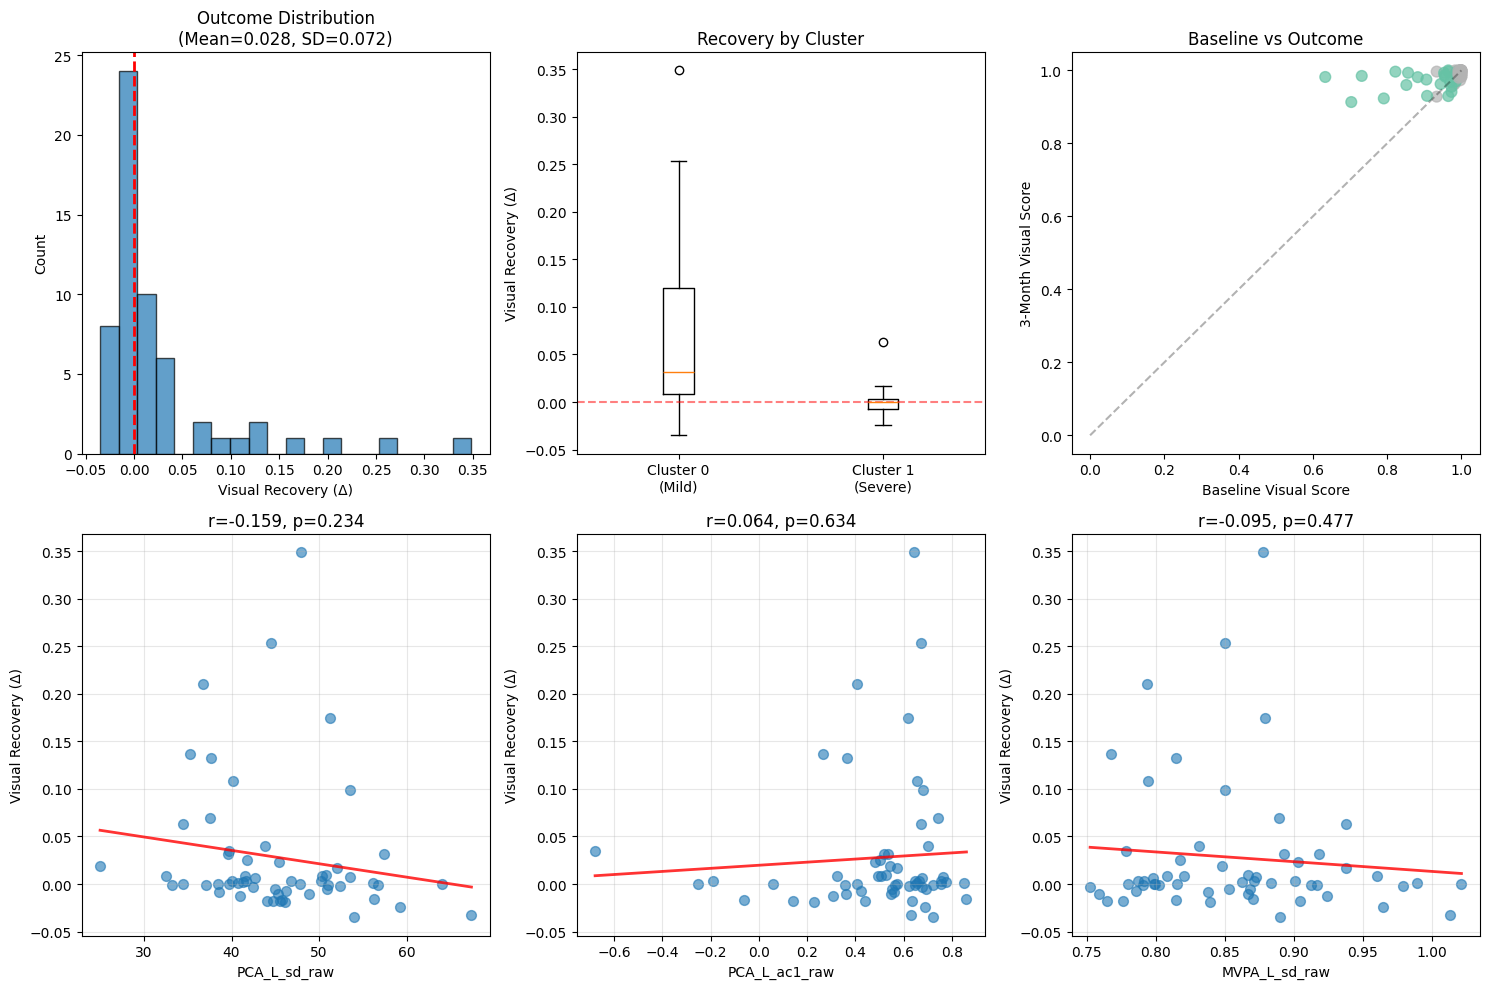

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('/mnt/compneuro/analysis_with_clusters.csv')

print("="*60)
print("DIAGNOSTIC ANALYSIS")
print("="*60)

# ============================================================
# 1. OUTCOME VARIANCE CHECK
# ============================================================
print("\n--- Outcome Variable: delta_visual ---")
print(f"\nOverall (N={len(df)}):")
print(f"  Mean:     {df['delta_visual'].mean():.4f}")
print(f"  Std:      {df['delta_visual'].std():.4f}")
print(f"  Min:      {df['delta_visual'].min():.4f}")
print(f"  Max:      {df['delta_visual'].max():.4f}")
print(f"  Range:    {df['delta_visual'].max() - df['delta_visual'].min():.4f}")

for cluster_id in [0, 1]:
    df_c = df[df['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} (N={len(df_c)}):")
    print(f"  Mean:     {df_c['delta_visual'].mean():.4f}")
    print(f"  Std:      {df_c['delta_visual'].std():.4f}")
    print(f"  Min:      {df_c['delta_visual'].min():.4f}")
    print(f"  Max:      {df_c['delta_visual'].max():.4f}")
    print(f"  Range:    {df_c['delta_visual'].max() - df_c['delta_visual'].min():.4f}")
    
    # Check if variance is near zero
    if df_c['delta_visual'].std() < 0.02:
        print(f"  ⚠️  WARNING: Variance too low to predict!")

# ============================================================
# 2. CORRELATION MATRIX
# ============================================================
print("\n" + "="*60)
print("CORRELATIONS WITH OUTCOME")
print("="*60)

predictors = ['age', 'nih_total', 'lesion_volume_mm3',
              'PCA_L_sd_raw', 'PCA_L_ac1_raw', 'PCA_sd_asym_raw',
              'MVPA_L_sd_raw', 'PCA_LR_corr_raw']

print("\nOverall correlations with delta_visual:")
for pred in predictors:
    if pred in df.columns:
        valid = df[[pred, 'delta_visual']].dropna()
        if len(valid) > 0:
            r, p = stats.pearsonr(valid[pred], valid['delta_visual'])
            marker = "**" if p < 0.05 else ("*" if p < 0.10 else "  ")
            print(f"  {pred:25s}: r={r:6.3f}, p={p:.4f} {marker}")

# ============================================================
# 3. ALTERNATIVE OUTCOME: Absolute Score at 3-Month
# ============================================================
print("\n" + "="*60)
print("ALTERNATIVE OUTCOME: visual_3mo (absolute, not change)")
print("="*60)

print(f"\nOverall:")
print(f"  Mean:  {df['visual_3mo'].mean():.4f}")
print(f"  Std:   {df['visual_3mo'].std():.4f}")
print(f"  Range: {df['visual_3mo'].max() - df['visual_3mo'].min():.4f}")

for cluster_id in [0, 1]:
    df_c = df[df['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(f"  Mean:  {df_c['visual_3mo'].mean():.4f}")
    print(f"  Std:   {df_c['visual_3mo'].std():.4f}")
    print(f"  Range: {df_c['visual_3mo'].max() - df_c['visual_3mo'].min():.4f}")

# Correlations with visual_3mo
print("\nCorrelations with visual_3mo (absolute score):")
for pred in predictors:
    if pred in df.columns:
        valid = df[[pred, 'visual_3mo']].dropna()
        if len(valid) > 0:
            r, p = stats.pearsonr(valid[pred], valid['visual_3mo'])
            marker = "**" if p < 0.05 else ("*" if p < 0.10 else "  ")
            print(f"  {pred:25s}: r={r:6.3f}, p={p:.4f} {marker}")

# ============================================================
# 4. VISUALIZATION
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Delta visual distribution
axes[0,0].hist(df['delta_visual'], bins=20, alpha=0.7, edgecolor='black')
axes[0,0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0,0].set_xlabel('Visual Recovery (Δ)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title(f'Outcome Distribution\n(Mean={df["delta_visual"].mean():.3f}, SD={df["delta_visual"].std():.3f})')

# Plot 2: Delta visual by cluster
axes[0,1].boxplot([df[df['cluster']==0]['delta_visual'].dropna(),
                    df[df['cluster']==1]['delta_visual'].dropna()],
                   labels=['Cluster 0\n(Mild)', 'Cluster 1\n(Severe)'])
axes[0,1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0,1].set_ylabel('Visual Recovery (Δ)')
axes[0,1].set_title('Recovery by Cluster')

# Plot 3: Baseline vs 3-month
axes[0,2].scatter(df['visual_acute'], df['visual_3mo'], 
                  c=df['cluster'], cmap='Set2', s=60, alpha=0.7)
axes[0,2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0,2].set_xlabel('Baseline Visual Score')
axes[0,2].set_ylabel('3-Month Visual Score')
axes[0,2].set_title('Baseline vs Outcome')

# Plot 4-6: Top 3 oculomotor predictors vs delta_visual
ocular_feats = ['PCA_L_sd_raw', 'PCA_L_ac1_raw', 'MVPA_L_sd_raw']
for i, feat in enumerate(ocular_feats):
    ax = axes[1, i]
    valid = df[[feat, 'delta_visual']].dropna()
    ax.scatter(valid[feat], valid['delta_visual'], alpha=0.6, s=50)
    
    # Fit line
    z = np.polyfit(valid[feat], valid['delta_visual'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid[feat].min(), valid[feat].max(), 100)
    ax.plot(x_line, p(x_line), "r-", alpha=0.8, linewidth=2)
    
    r, pval = stats.pearsonr(valid[feat], valid['delta_visual'])
    ax.set_xlabel(feat)
    ax.set_ylabel('Visual Recovery (Δ)')
    ax.set_title(f'r={r:.3f}, p={pval:.3f}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/compneuro/diagnostic_plots.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: diagnostic_plots.png")

print("\n" + "="*60)
print("DIAGNOSIS COMPLETE - Check results above")
print("="*60)

In [24]:
pip install stepmix

  Using cached stepmix-3.0.0-py3-none-any.whl.metadata (7.2 kB)
Using cached stepmix-3.0.0-py3-none-any.whl (44 kB)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /mnt/compneuro/venvs/deepmreye-gpu/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
from stepmix.stepmix import StepMix 

ModuleNotFoundError: No module named 'stepmix'

### Perplexity 

In [23]:
import pandas as pd
import numpy as np

# ============================================================
# Load the data
# ============================================================
# UPDATE THIS PATH to your actual file location
#stroke_csv = pd.read_csv("stroke_csv.csv")  # <-- adjust path

# ============================================================
# Define columns for 3 visual deficit categories
# (BJH Admission timepoint only + standardized tests/NIHSS)
# ============================================================

visual_deficit_columns = {
    "Eye Movement Deficit": {
        "visual_acute_ad___2": "Diplopia (BJH Admission)",
        "visual_acute_ad___3": "Other visual problem: nystagmus, strabismus, etc. (BJH Admission)",
        "nih2": "NIHSS 2: Best Gaze (0-2)",
    },
    "Visual Field Impairment": {
        "visual_acute_ad___1": "Field cut: hemianopsia, quadrantanopsia, scotoma (BJH Admission)",
        "nih3": "NIHSS 3: Visual Fields (0-3)",
        "visual_fields_description": "Visual field deficit classification (0-9 categorical)",
        "perimetry_lqc": "Perimetry left eye QC",
        "perimetry_rqc": "Perimetry right eye QC",
        "attention1vf_f": "Attention Visual Fields factor (L/R coded)",
        "attention1vf_fic": "Attention Visual Fields factor (ipsi/contra coded)",
        "revised_attvf_factor": "Revised Attention VF Factor Score",
    },
    "Perceptual Deficit": {
        "attention_acute_ad___1": "Neglect (BJH Admission)",
        "nih11": "NIHSS 11: Extinction and Inattention (0-2)",
        "mes_l_miss": "Mesulam Left Misses",
        "mes_r_miss": "Mesulam Right Misses",
        "mes_tot_miss": "Mesulam Total Misses",
        "mes_coc": "Mesulam Center of Cancellation",
        "bit_l1_miss": "BIT Stars Left Col 1 Misses",
        "bit_l2_miss": "BIT Stars Left Col 2 Misses",
        "bit_l3_miss": "BIT Stars Left Col 3 Misses",
        "bit_r1_miss": "BIT Stars Right Col 1 Misses",
        "bit_r2_miss": "BIT Stars Right Col 2 Misses",
        "bit_r3_miss": "BIT Stars Right Col 3 Misses",
        "bit_ltot_miss": "BIT Stars Total Left Misses",
        "bit_rtot_miss": "BIT Stars Total Right Misses",
        "bit_tot_miss": "BIT Stars Total Misses",
        "bit_coc": "BIT Stars Center of Cancellation",
        "clock": "Clock Drawing (0-15)",
        "pos_acc_vf": "Posner Accuracy Visual Field effect",
        "pos_acc_disengage": "Posner Accuracy Disengagement effect",
        "pos_rt_vf": "Posner RT Visual Field effect",
        "pos_rt_disengage": "Posner RT Disengagement effect",
        "pos_acc_avg": "Posner Accuracy Average",
        "pos_rt_avg": "Posner RT Average",
        "revised_attave_factor": "Revised Attention Average factor",
        "revised_attvaldis_factor": "Revised Attention Validity/Disengagement factor",
        "test_factorscore": "Test Factor Score (Posner composite)",
    },
}

# ============================================================
# Identify subject type from the 'subj_type' column
# Adjust these labels if your encoding differs
# ============================================================
# Expected: subj_type == 0 -> Stroke, subj_type == 1 -> Control
# Or string labels like 'stroke'/'control' — auto-detect:

if stroke_csv["subj_type"].dtype == object:
    is_patient = stroke_csv["subj_type"].str.lower().str.contains("stroke|patient|pat")
    is_control = stroke_csv["subj_type"].str.lower().str.contains("control|con|healthy")
else:
    is_patient = stroke_csv["subj_type"] == 0
    is_control = stroke_csv["subj_type"] == 1

# ============================================================
# Basic dataset overview
# ============================================================
n_total_rows = len(stroke_csv)
n_patient_rows = is_patient.sum()
n_control_rows = is_control.sum()
n_unique_patients = stroke_csv.loc[is_patient, "ID"].nunique()
n_unique_controls = stroke_csv.loc[is_control, "ID"].nunique()

print("=" * 110)
print("  DATASET OVERVIEW")
print("=" * 110)
print(f"  Total rows:           {n_total_rows}")
print(f"  Patient rows:         {n_patient_rows}  ({n_unique_patients} unique subjects)")
print(f"  Control rows:         {n_control_rows}  ({n_unique_controls} unique subjects)")
print(f"  Other/unclassified:   {n_total_rows - n_patient_rows - n_control_rows}")
print()

# ============================================================
# Check NaN values — overall + split by patient/control
# ============================================================
results = []

for category, col_dict in visual_deficit_columns.items():
    for col, description in col_dict.items():
        if col in stroke_csv.columns:
            row = {
                "Category": category,
                "Column": col,
                "Description": description,
            }
            for label, mask in [("All", pd.Series(True, index=stroke_csv.index)),
                                ("Patients", is_patient),
                                ("Controls", is_control)]:
                subset = stroke_csv.loc[mask, col]
                n = mask.sum()
                n_valid = subset.notna().sum()
                n_nan = subset.isna().sum()
                pct = round((n_valid / n) * 100, 1) if n > 0 else 0
                row[f"{label}_N"] = n
                row[f"{label}_Valid"] = n_valid
                row[f"{label}_NaN"] = n_nan
                row[f"{label}_Valid%"] = pct
            results.append(row)
        else:
            results.append({
                "Category": category,
                "Column": col,
                "Description": description,
                "All_N": n_total_rows, "All_Valid": "NOT FOUND",
                "All_NaN": "NOT FOUND", "All_Valid%": "NOT FOUND",
                "Patients_N": "—", "Patients_Valid": "NOT FOUND",
                "Patients_NaN": "NOT FOUND", "Patients_Valid%": "NOT FOUND",
                "Controls_N": "—", "Controls_Valid": "NOT FOUND",
                "Controls_NaN": "NOT FOUND", "Controls_Valid%": "NOT FOUND",
            })

df_results = pd.DataFrame(results)

# ============================================================
# Print results grouped by category
# ============================================================
display_cols = ["Column", "Description",
                "Patients_Valid", "Patients_NaN", "Patients_Valid%",
                "Controls_Valid", "Controls_NaN", "Controls_Valid%"]

for category in visual_deficit_columns.keys():
    subset = df_results[df_results["Category"] == category]
    print(f"\n{'=' * 110}")
    print(f"  {category}")
    print(f"{'=' * 110}")
    print(subset[display_cols].to_string(index=False))
    print()

# ============================================================
# Save full results
# ============================================================
#df_results.to_csv("output/visual_deficit_nan_check.csv", index=False)
print("\nFull results saved to: output/visual_deficit_nan_check.csv")


  DATASET OVERVIEW
  Total rows:           386
  Patient rows:         328  (153 unique subjects)
  Control rows:         56  (31 unique subjects)
  Other/unclassified:   2


  Eye Movement Deficit
             Column                                                       Description  Patients_Valid  Patients_NaN  Patients_Valid%  Controls_Valid  Controls_NaN  Controls_Valid%
visual_acute_ad___2                                          Diplopia (BJH Admission)             328             0            100.0               0            56              0.0
visual_acute_ad___3 Other visual problem: nystagmus, strabismus, etc. (BJH Admission)             328             0            100.0               0            56              0.0
               nih2                                          NIHSS 2: Best Gaze (0-2)             289            39             88.1               0            56              0.0


  Visual Field Impairment
                   Column                             

In [6]:
import pandas as pd
import numpy as np
from itertools import product

# ============================================================
# Load data & fix PAT046
# ============================================================
#stroke_csv = pd.read_csv("stroke_csv.csv")  # <-- adjust path

if stroke_csv["subj_type"].dtype == object:
    stroke_csv.loc[stroke_csv["ID"] == "PAT046", "subj_type"] = "stroke"
    is_patient = stroke_csv["subj_type"].str.lower().str.contains("stroke|patient|pat", na=False)
    is_control = stroke_csv["subj_type"].str.lower().str.contains("control|con|healthy", na=False)
else:
    stroke_csv.loc[stroke_csv["ID"] == "PAT046", "subj_type"] = 0
    is_patient = stroke_csv["subj_type"] == 0
    is_control = stroke_csv["subj_type"] == 1

# ============================================================
# Filter: acute session (patients), initial session (controls)
# ============================================================
pat = stroke_csv[is_patient & (stroke_csv["Session"].str.lower() == "acute")].copy()
ctrl = stroke_csv[is_control & (stroke_csv["Session"].str.lower() == "control")].copy()
pat = pat.groupby("ID").first().reset_index()
ctrl = ctrl.groupby("ID").first().reset_index()

# ============================================================
# CONTROL-DERIVED THRESHOLDS (Mean + 2SD from control data)
# ============================================================
MES_MISS_CUTOFF = 6     # control mean+2SD = 5.41, 95th pctile = 6
BIT_MISS_CUTOFF = 2     # control mean+2SD = 2.05
MES_COC_CUTOFF  = 0.04  # control max = 0.04, so >0.04 = beyond any control
BIT_COC_CUTOFF  = 0.02  # control max = 0.02, so >0.02 = beyond any control

# ============================================================
# LABEL CREATION — PATIENTS
# ============================================================

# 1. Eye Movement Deficit
pat["has_eye_movement_deficit"] = (
    (pat["visual_acute_ad___2"] == 1) |     # diplopia
    (pat["visual_acute_ad___3"] == 1) |     # nystagmus/strabismus/etc.
    (pat["nih2"] > 0)                        # NIHSS gaze abnormality
).astype(int)

# 2. Visual Field Impairment
pat["has_visual_field_impairment"] = (
    (pat["visual_acute_ad___1"] == 1) |     # field cut in chart
    (pat["nih3"] > 0) |                      # NIHSS visual fields
    (pat["visual_fields_description"].isin([1,2,3,4,5,6,7]))  # perimetry classification
).astype(int)

# 3. Perceptual Deficit (control-derived thresholds)
pat["has_perceptual_deficit"] = (
    (pat["attention_acute_ad___1"] == 1) |         # chart-documented neglect
    (pat["nih11"] > 0) |                            # NIHSS extinction/inattention
    (pat["mes_tot_miss"] > MES_MISS_CUTOFF) |       # Mesulam misses > 6
    (pat["bit_tot_miss"] > BIT_MISS_CUTOFF) |       # BIT misses > 2
    (pat["mes_coc"].abs() > MES_COC_CUTOFF) |       # Mesulam CoC > 0.04
    (pat["bit_coc"].abs() > BIT_COC_CUTOFF)         # BIT CoC > 0.02
).astype(int)

# ============================================================
# LABEL CREATION — CONTROLS (all = 0)
# ============================================================
ctrl["has_eye_movement_deficit"] = 0
ctrl["has_visual_field_impairment"] = 0
ctrl["has_perceptual_deficit"] = 0

# ============================================================
# COMBINED GROUP LABEL
# ============================================================
deficit_cols = ["has_eye_movement_deficit", "has_visual_field_impairment", "has_perceptual_deficit"]
deficit_labels = ["Eye Movement", "Visual Field", "Perceptual"]

for df in [pat, ctrl]:
    df["n_deficits"] = df[deficit_cols].sum(axis=1)

def assign_group_label(row):
    if row.name in ctrl.index:
        return "Control"
    labels = [l for col, l in zip(deficit_cols, deficit_labels) if row[col] == 1]
    if not labels:
        return "No Visual Deficit"
    return " + ".join(labels)

pat["visual_deficit_group"] = pat.apply(
    lambda row: " + ".join([l for col, l in zip(deficit_cols, deficit_labels) if row[col] == 1]) or "No Visual Deficit",
    axis=1
)
ctrl["visual_deficit_group"] = "Control"

# ============================================================
# RESULTS
# ============================================================
print("=" * 80)
print("  FINAL LABELS — PATIENT DEFICIT PREVALENCE (N={})".format(len(pat)))
print("  Thresholds: Mesulam miss>6, BIT miss>2, Mesulam CoC>0.04, BIT CoC>0.02")
print("=" * 80)
for col, label in zip(deficit_cols, deficit_labels):
    n = pat[col].sum()
    pct = round(n / len(pat) * 100, 1)
    print(f"  {label:25s}: {n:4d} / {len(pat)} ({pct}%)")

print(f"\n{'=' * 80}")
print("  DEFICIT COUNT DISTRIBUTION")
print("=" * 80)
for i in range(4):
    n = (pat["n_deficits"] == i).sum()
    pct = round(n / len(pat) * 100, 1)
    print(f"  {i} deficit(s): {n:4d} patients ({pct}%)")

print(f"\n{'=' * 80}")
print("  COMORBIDITY PATTERNS")
print("=" * 80)
for combo in product([0, 1], repeat=3):
    mask = pd.Series(True, index=pat.index)
    for col, val in zip(deficit_cols, combo):
        mask = mask & (pat[col] == val)
    n = mask.sum()
    if n > 0:
        labels_present = [l for l, v in zip(deficit_labels, combo) if v == 1]
        label_str = " + ".join(labels_present) if labels_present else "No Visual Deficit"
        pct = round(n / len(pat) * 100, 1)
        print(f"  {label_str:55s}: {n:4d} ({pct}%)")

print(f"\n{'=' * 80}")
print("  FULL GROUP DISTRIBUTION (Patients + Controls)")
print("=" * 80)
combined = pd.concat([pat, ctrl], ignore_index=True)
group_counts = combined["visual_deficit_group"].value_counts()
for group, n in group_counts.items():
    print(f"  {group:55s}: {n:4d}")

print(f"\n  Total subjects: {len(combined)}")


  FINAL LABELS — PATIENT DEFICIT PREVALENCE (N=139)
  Thresholds: Mesulam miss>6, BIT miss>2, Mesulam CoC>0.04, BIT CoC>0.02
  Eye Movement             :   22 / 139 (15.8%)
  Visual Field             :   28 / 139 (20.1%)
  Perceptual               :   64 / 139 (46.0%)

  DEFICIT COUNT DISTRIBUTION
  0 deficit(s):   58 patients (41.7%)
  1 deficit(s):   54 patients (38.8%)
  2 deficit(s):   21 patients (15.1%)
  3 deficit(s):    6 patients (4.3%)

  COMORBIDITY PATTERNS
  No Visual Deficit                                      :   58 (41.7%)
  Perceptual                                             :   38 (27.3%)
  Visual Field                                           :    7 (5.0%)
  Visual Field + Perceptual                              :   14 (10.1%)
  Eye Movement                                           :    9 (6.5%)
  Eye Movement + Perceptual                              :    6 (4.3%)
  Eye Movement + Visual Field                            :    1 (0.7%)
  Eye Movement + Visual Fi

In [25]:
import pickle as pkl
import pandas as pd
import numpy as np
from itertools import product

# ============================================================
# Load data
# ============================================================


features_df = pd.read_csv("ocular_features_per_run.csv")

# ============================================================
# Recreate deficit labels (acute patients + initial controls)
# ============================================================
if stroke_csv["subj_type"].dtype == object:
    stroke_csv.loc[stroke_csv["ID"] == "PAT046", "subj_type"] = "stroke"
    is_patient = stroke_csv["subj_type"].str.lower().str.contains("stroke|patient|pat", na=False)
    is_control = stroke_csv["subj_type"].str.lower().str.contains("control|con|healthy", na=False)
else:
    stroke_csv.loc[stroke_csv["ID"] == "PAT046", "subj_type"] = 0
    is_patient = stroke_csv["subj_type"] == 0
    is_control = stroke_csv["subj_type"] == 1

pat = stroke_csv[is_patient & (stroke_csv["Session"].str.lower() == "acute")].copy()
ctrl = stroke_csv[is_control & (stroke_csv["Session"].str.lower() == "control")].copy()
pat  = pat.groupby("ID").first().reset_index()
ctrl = ctrl.groupby("ID").first().reset_index()

# Thresholds (control-derived)
MES_MISS_CUTOFF = 6
BIT_MISS_CUTOFF = 2
MES_COC_CUTOFF  = 0.04
BIT_COC_CUTOFF  = 0.02

pat["has_eye_movement_deficit"] = (
    (pat["visual_acute_ad___2"] == 1) |
    (pat["visual_acute_ad___3"] == 1) |
    (pat["nih2"] > 0)
).astype(int)

pat["has_visual_field_impairment"] = (
    (pat["visual_acute_ad___1"] == 1) |
    (pat["nih3"] > 0) |
    (pat["visual_fields_description"].isin([1,2,3,4,5,6,7]))
).astype(int)

pat["has_perceptual_deficit"] = (
    (pat["attention_acute_ad___1"] == 1) |
    (pat["nih11"] > 0) |
    (pat["mes_tot_miss"] > MES_MISS_CUTOFF) |
    (pat["bit_tot_miss"] > BIT_MISS_CUTOFF) |
    (pat["mes_coc"].abs() > MES_COC_CUTOFF) |
    (pat["bit_coc"].abs() > BIT_COC_CUTOFF)
).astype(int)

for col in ["has_eye_movement_deficit","has_visual_field_impairment","has_perceptual_deficit"]:
    ctrl[col] = 0

# Count and group label
deficit_cols   = ["has_eye_movement_deficit","has_visual_field_impairment","has_perceptual_deficit"]
deficit_labels = ["Eye Movement","Visual Field","Perceptual"]

for df in [pat, ctrl]:
    df["n_deficits"] = df[deficit_cols].sum(axis=1)

def make_group_label(row):
    labels = [l for col, l in zip(deficit_cols, deficit_labels) if row[col] == 1]
    return " + ".join(labels) if labels else "No Visual Deficit"

pat["visual_deficit_group"]  = pat.apply(make_group_label, axis=1)
ctrl["visual_deficit_group"] = "Control"

# Plotting group (collapsed for small cells)
def make_plot_group(row):
    if row["visual_deficit_group"] == "Control":
        return "Control"
    if row["n_deficits"] == 0:
        return "No Deficit"
    if row["n_deficits"] >= 2:
        return "Multiple Deficits"
    if row["has_perceptual_deficit"]:
        return "Perceptual Only"
    if row["has_visual_field_impairment"]:
        return "Visual Field Only"
    if row["has_eye_movement_deficit"]:
        return "Eye Movement Only"
    return "Other"

for df in [pat, ctrl]:
    df["plot_group"] = df.apply(make_plot_group, axis=1)

# ============================================================
# Build labels dataframe: one row per subject
# ============================================================
label_cols = ["ID"] + deficit_cols + ["n_deficits","visual_deficit_group","plot_group"]
labels_df = pd.concat([
    pat[label_cols].assign(group_type="patient"),
    ctrl[label_cols].assign(group_type="control")
], ignore_index=True)

print("Labels shape:", labels_df.shape)
print(labels_df["plot_group"].value_counts())

# ============================================================
# Merge features (all sessions) with labels (from acute/control)
# Labels are fixed at acute — applied to ALL sessions of each subject
# ============================================================
analysis_df = features_df.merge(labels_df, on="ID", how="left")

# Assign clean session order for plotting/modelling
session_order = {"control": 0, "control2": 1,
                 "acute": 0, "followup": 1, "followup2": 2}
analysis_df["session_num"] = analysis_df["Session"].str.lower().map(session_order)

# Separate patient and control analysis frames
pat_df  = analysis_df[analysis_df["group_type"] == "patient"].copy()
ctrl_df = analysis_df[analysis_df["group_type"] == "control"].copy()

print(f"\nPatient rows (all sessions): {len(pat_df)}")
print(f"Control rows (all sessions): {len(ctrl_df)}")
print(f"Total rows in analysis_df:  {len(analysis_df)}")

# Check session distribution for patients
print("\nPatient session distribution:")
print(pat_df["Session"].value_counts())

# ============================================================
# Save
# ============================================================
analysis_df.to_csv("analysis_df_full.csv", index=False)
#print("\nSaved analysis_df_full.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'ocular_features_per_run.csv'

In [10]:
import numpy as np
import pandas as pd

# Network membership (1-indexed ROI → network)
roi_full_names = {
    **{i: "Vis"         for i in range(1,   32)},   # LH Vis 1-31
    **{i: "SomMot"      for i in range(32,  69)},   # LH SomMot 32-68
    **{i: "DorsAttn"    for i in range(69,  92)},   # LH DorsAttn 69-91
    **{i: "SalVentAttn" for i in range(92, 114)},   # LH SalVentAttn 92-113
    **{i: "Limbic"      for i in range(114,127)},   # LH Limbic 114-126
    **{i: "Cont"        for i in range(127,149)},   # LH Cont 127-148
    **{i: "Default"     for i in range(149,201)},   # LH Default 149-200
    **{i: "Vis"         for i in range(201,231)},   # RH Vis 201-230
    **{i: "SomMot"      for i in range(231,271)},   # RH SomMot 231-270
    **{i: "DorsAttn"    for i in range(271,294)},   # RH DorsAttn 271-293
    **{i: "SalVentAttn" for i in range(294,319)},   # RH SalVentAttn 294-318
    **{i: "Limbic"      for i in range(319,332)},   # RH Limbic 319-331
    **{i: "Cont"        for i in range(332,362)},   # RH Cont 332-361
    **{i: "Default"     for i in range(362,401)},   # RH Default 362-400
}

NETWORKS = ["Vis","SomMot","DorsAttn","SalVentAttn","Limbic","Cont","Default"]

rows = []
for idx, row in stroke_csv.iterrows():
    vec = row["ed_func_mean_corrected"]
    out = {"ID": row["ID"], "Session": row["Session"]}

    if isinstance(vec, float):  # NaN row
        out.update({f"brain_{net}": np.nan for net in NETWORKS})
    else:
        vec = np.asarray(vec, dtype=float)  # shape (400,)
        for net in NETWORKS:
            # Grab all ROIs (both hemispheres) belonging to this network
            indices = [i-1 for i, n in roi_full_names.items() if n == net]
            out[f"brain_{net}"] = float(np.nanmean(vec[indices]))

    rows.append(out)

brain_df = pd.DataFrame(rows)
brain_df.to_csv("brain_network_features.csv", index=False)
print(f"Saved brain_network_features.csv: {len(brain_df)} rows, "
      f"{len(brain_df.columns)-2} brain network features")
print("Columns:", list(brain_df.columns))


Saved brain_network_features.csv: 386 rows, 7 brain network features
Columns: ['ID', 'Session', 'brain_Vis', 'brain_SomMot', 'brain_DorsAttn', 'brain_SalVentAttn', 'brain_Limbic', 'brain_Cont', 'brain_Default']


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

analysis_df = pd.read_csv("analysis_df_full.csv")

OCULAR_FEATURES = [
    ("PCA Left SD",       "PCA_L_sd"),
    ("PCA Right SD",      "PCA_R_sd"),
    ("PCA LR Corr",       "PCA_LR_corr"),
    ("PCA SD Asym",       "PCA_sd_asym"),
    ("PCA Left MSSD",     "PCA_L_mssd"),
    ("PCA Right MSSD",    "PCA_R_mssd"),
    ("PCA Left AC1",      "PCA_L_ac1"),
    ("PCA Right AC1",     "PCA_R_ac1"),
    ("PCA Left SpecEnt",  "PCA_L_spec_entropy"),
    ("PCA Right SpecEnt", "PCA_R_spec_entropy"),
    ("PCA-MVPA Corr L",   "corr_PCA_MVPA_L"),
    ("MVPA Left SD",      "MVPA_L_sd"),
]

# ============================================================
# Step A: Flag outliers using Tukey's extreme fence
# Rule: outlier if > Q3 + 3*IQR  or  < Q1 - 3*IQR
# (3x IQR = "extreme" outliers, not just mild ones)
# ============================================================
feat_cols = [col for _, col in OCULAR_FEATURES]

for col in feat_cols:
    Q1 = analysis_df[col].quantile(0.25)
    Q3 = analysis_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo = Q1 - 3 * IQR
    hi = Q3 + 3 * IQR
    analysis_df[f"{col}_outlier"] = (
        (analysis_df[col] < lo) | (analysis_df[col] > hi)
    )

outlier_cols = [f"{col}_outlier" for col in feat_cols]
analysis_df["any_outlier"] = analysis_df[outlier_cols].any(axis=1)

# ============================================================
# Step B: Report how many rows and subjects are affected
# ============================================================
print("=" * 60)
print("  OUTLIER SUMMARY (Tukey extreme fence: ±3*IQR)")
print("=" * 60)
print(f"  Total rows:          {len(analysis_df)}")
print(f"  Rows with any outlier: {analysis_df['any_outlier'].sum()}")
print(f"  Clean rows:          {(~analysis_df['any_outlier']).sum()}")
print()
print("  Per-feature outlier counts:")
for _, col in OCULAR_FEATURES:
    n = analysis_df[f"{col}_outlier"].sum()
    if n > 0:
        ids = analysis_df.loc[analysis_df[f"{col}_outlier"], "ID"].unique()
        print(f"    {col:25s}: {n:3d} rows  —  subjects: {list(ids)[:5]}")

# ============================================================
# Step C: Visual inspection — boxplots with outliers highlighted
# ============================================================
n_cols = 3
n_rows = int(np.ceil(len(OCULAR_FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, (feat_label, feat_col) in enumerate(OCULAR_FEATURES):
    ax = axes[i]
    clean   = analysis_df.loc[~analysis_df[f"{feat_col}_outlier"], feat_col].dropna()
    outlier = analysis_df.loc[ analysis_df[f"{feat_col}_outlier"], feat_col].dropna()

    ax.boxplot(clean, positions=[1], widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor="#4C72B0", alpha=0.6),
               medianprops=dict(color="black", linewidth=2),
               flierprops=dict(marker="", linestyle="none"))
    if len(outlier) > 0:
        ax.scatter(np.ones(len(outlier)) * 1 +
                   np.random.uniform(-0.05, 0.05, len(outlier)),
                   outlier, color="red", s=30, zorder=5,
                   label=f"Outliers (n={len(outlier)})")
        ax.legend(fontsize=7)

    ax.set_title(feat_label, fontsize=10, fontweight="bold")
    ax.set_xticks([])
    ax.set_ylabel("Value", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

for j in range(len(OCULAR_FEATURES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Outlier Inspection — Red = Tukey Extreme Outliers (±3×IQR)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'analysis_df_full.csv'

In [12]:

feat_cols = ["PCA_L_sd","PCA_R_sd","PCA_LR_corr","PCA_sd_asym",
             "PCA_L_mssd","PCA_R_mssd","PCA_L_ac1","PCA_R_ac1",
             "PCA_L_spec_entropy","PCA_R_spec_entropy",
             "corr_PCA_MVPA_L","MVPA_L_sd"]

# Re-flag outliers
for col in feat_cols:
    Q1, Q3 = analysis_df[col].quantile(0.25), analysis_df[col].quantile(0.75)
    IQR = Q3 - Q1
    analysis_df[f"{col}_outlier"] = (
        (analysis_df[col] < Q1 - 3*IQR) | (analysis_df[col] > Q3 + 3*IQR)
    )

outlier_flag_cols = [f"{col}_outlier" for col in feat_cols]
analysis_df["any_outlier"] = analysis_df[outlier_flag_cols].any(axis=1)
analysis_df["n_outlier_features"] = analysis_df[outlier_flag_cols].sum(axis=1)

# Show all outlier runs with which features are flagged
outlier_runs = analysis_df[analysis_df["any_outlier"]].copy()
outlier_runs["flagged_features"] = outlier_runs[outlier_flag_cols].apply(
    lambda row: [col.replace("_outlier","") for col in outlier_flag_cols if row[col]],
    axis=1
)

print(f"Total outlier runs: {len(outlier_runs)} / {len(analysis_df)}")
print(f"Unique subjects with outlier runs: {outlier_runs['ID'].nunique()}\n")

print("=" * 80)
print("  OUTLIER RUNS — ID | Session | N flagged features | Which features")
print("=" * 80)
display_cols = ["ID","Session","n_outlier_features","flagged_features","plot_group"]
print(outlier_runs[display_cols].sort_values("n_outlier_features", ascending=False).to_string(index=False))

# Check if LR_corr outliers overlap with AC1 outliers (both = likely artifact)
both = analysis_df["PCA_LR_corr_outlier"] & (
    analysis_df["PCA_L_ac1_outlier"] | analysis_df["PCA_R_ac1_outlier"])
print(f"\nRuns flagged by BOTH LR Corr AND AC1: {both.sum()} — almost certainly artifacts")

NameError: name 'analysis_df' is not defined

In [16]:
import pandas as pd
import numpy as np

analysis_df = pd.read_csv("analysis_df_full.csv")

feat_cols = ["PCA_L_sd","PCA_R_sd","PCA_LR_corr","PCA_sd_asym",
             "PCA_L_mssd","PCA_R_mssd","PCA_L_ac1","PCA_R_ac1",
             "PCA_L_spec_entropy","PCA_R_spec_entropy",
             "corr_PCA_MVPA_L","MVPA_L_sd"]

# Re-flag outliers
for col in feat_cols:
    Q1, Q3 = analysis_df[col].quantile(0.25), analysis_df[col].quantile(0.75)
    IQR = Q3 - Q1
    analysis_df[f"{col}_outlier"] = (
        (analysis_df[col] < Q1 - 3*IQR) | (analysis_df[col] > Q3 + 3*IQR)
    )

# ============================================================
# RULE 1: Exclude runs with co-occurring MSSD + AC1 outliers
# (both left or right MSSD AND at least one AC1 flagged)
# ============================================================
mssd_flagged = analysis_df["PCA_L_mssd_outlier"] | analysis_df["PCA_R_mssd_outlier"]
ac1_flagged  = analysis_df["PCA_L_ac1_outlier"]  | analysis_df["PCA_R_ac1_outlier"]
artifact_mask = mssd_flagged & ac1_flagged

n_artifact = artifact_mask.sum()
print(f"Runs excluded as artifacts (MSSD + AC1 co-flagged): {n_artifact}")
print("Excluded runs:")
print(analysis_df.loc[artifact_mask, ["ID","Session","plot_group"]].to_string(index=False))

analysis_clean = analysis_df[~artifact_mask].copy()
print(f"\nRows after artifact exclusion: {len(analysis_clean)} / {len(analysis_df)}")

# ============================================================
# RULE 2: Winsorize MVPA_L_sd only
# ============================================================
col = "MVPA_L_sd"
Q1, Q3 = analysis_clean[col].quantile(0.25), analysis_clean[col].quantile(0.75)
IQR = Q3 - Q1
lo, hi = Q1 - 3*IQR, Q3 + 3*IQR
n_winsorized = ((analysis_clean[col] < lo) | (analysis_clean[col] > hi)).sum()
analysis_clean[col] = analysis_clean[col].clip(lower=lo, upper=hi)
print(f"\nWinsorized MVPA_L_sd: {n_winsorized} values capped at [{lo:.3f}, {hi:.3f}]")

# ============================================================
# RULE 3: Keep PCA_LR_corr as-is (real biological variation)
# ============================================================
print(f"\nPCA_LR_corr kept as-is — {analysis_clean['PCA_LR_corr_outlier'].sum()} "
      f"runs with low LR corr preserved as meaningful signal")

# ============================================================
# Save clean dataset
# ============================================================
analysis_clean.to_csv("analysis_df_clean.csv", index=False)
print(f"\nSaved analysis_df_clean.csv: {len(analysis_clean)} rows")

# Final group distribution check
print("\nGroup distribution after cleaning:")
print(analysis_clean[analysis_clean["session_num"]==0]["plot_group"].value_counts())


Runs excluded as artifacts (MSSD + AC1 co-flagged): 16
Excluded runs:
    ID   Session        plot_group
CON007   control           Control
CON016   control           Control
CON022   control           Control
PAT024 followup2   Perceptual Only
PAT031  followup   Perceptual Only
PAT061     acute Multiple Deficits
PAT071     acute        No Deficit
PAT100     acute        No Deficit
PAT102     acute Multiple Deficits
PAT103     acute   Perceptual Only
PAT125     acute Eye Movement Only
PAT154     acute        No Deficit
PAT170     acute Multiple Deficits
PAT177     acute Eye Movement Only
PAT177  followup Eye Movement Only
PAT187     acute        No Deficit

Rows after artifact exclusion: 368 / 384

Winsorized MVPA_L_sd: 4 values capped at [0.519, 1.183]

PCA_LR_corr kept as-is — 47 runs with low LR corr preserved as meaningful signal

Saved analysis_df_clean.csv: 368 rows

Group distribution after cleaning:
plot_group
No Deficit           54
Perceptual Only      36
Control             

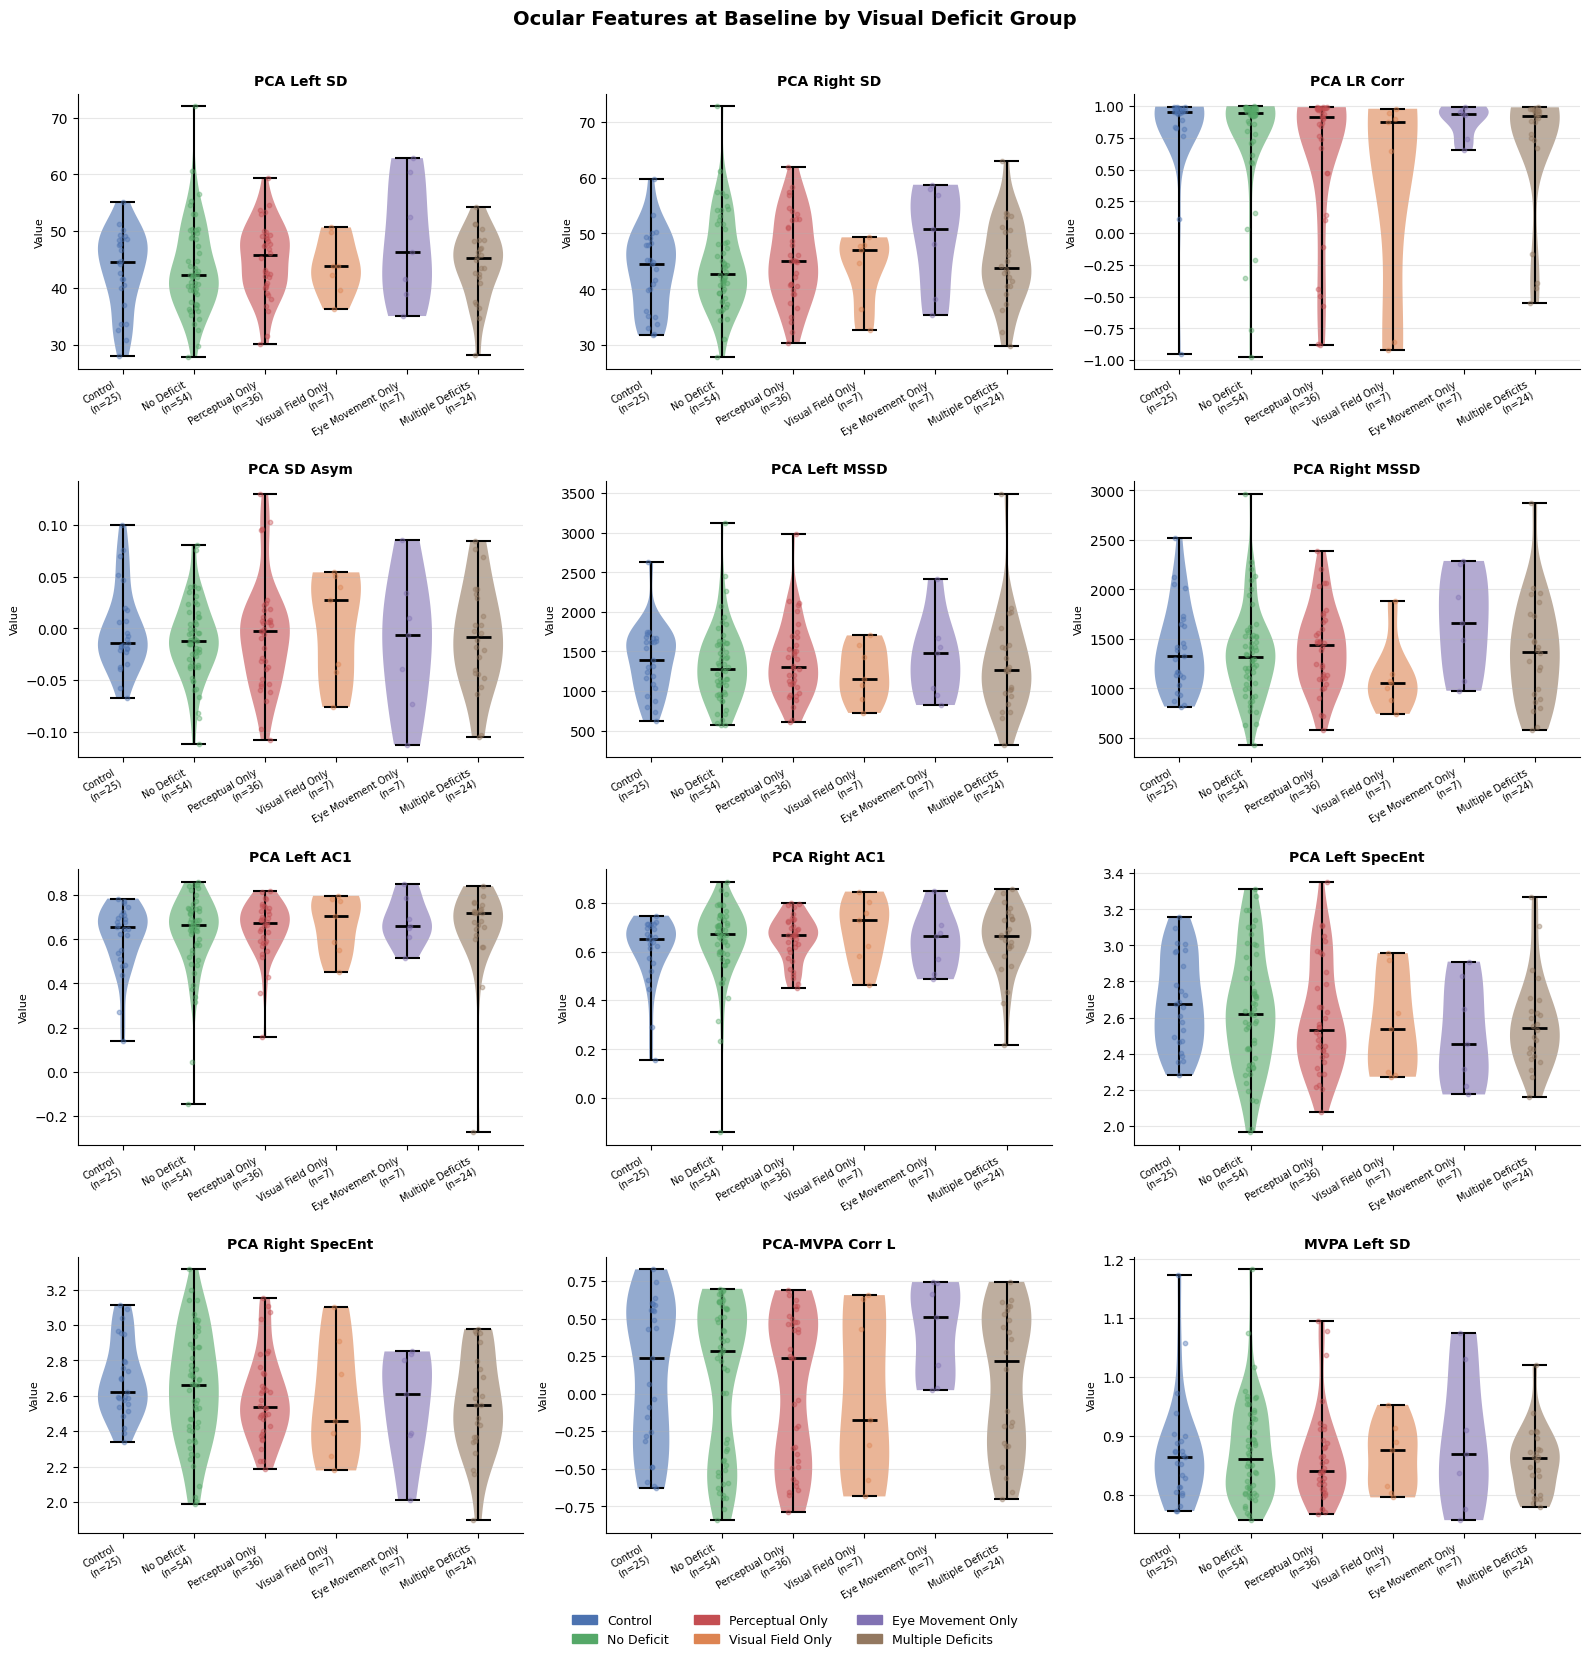

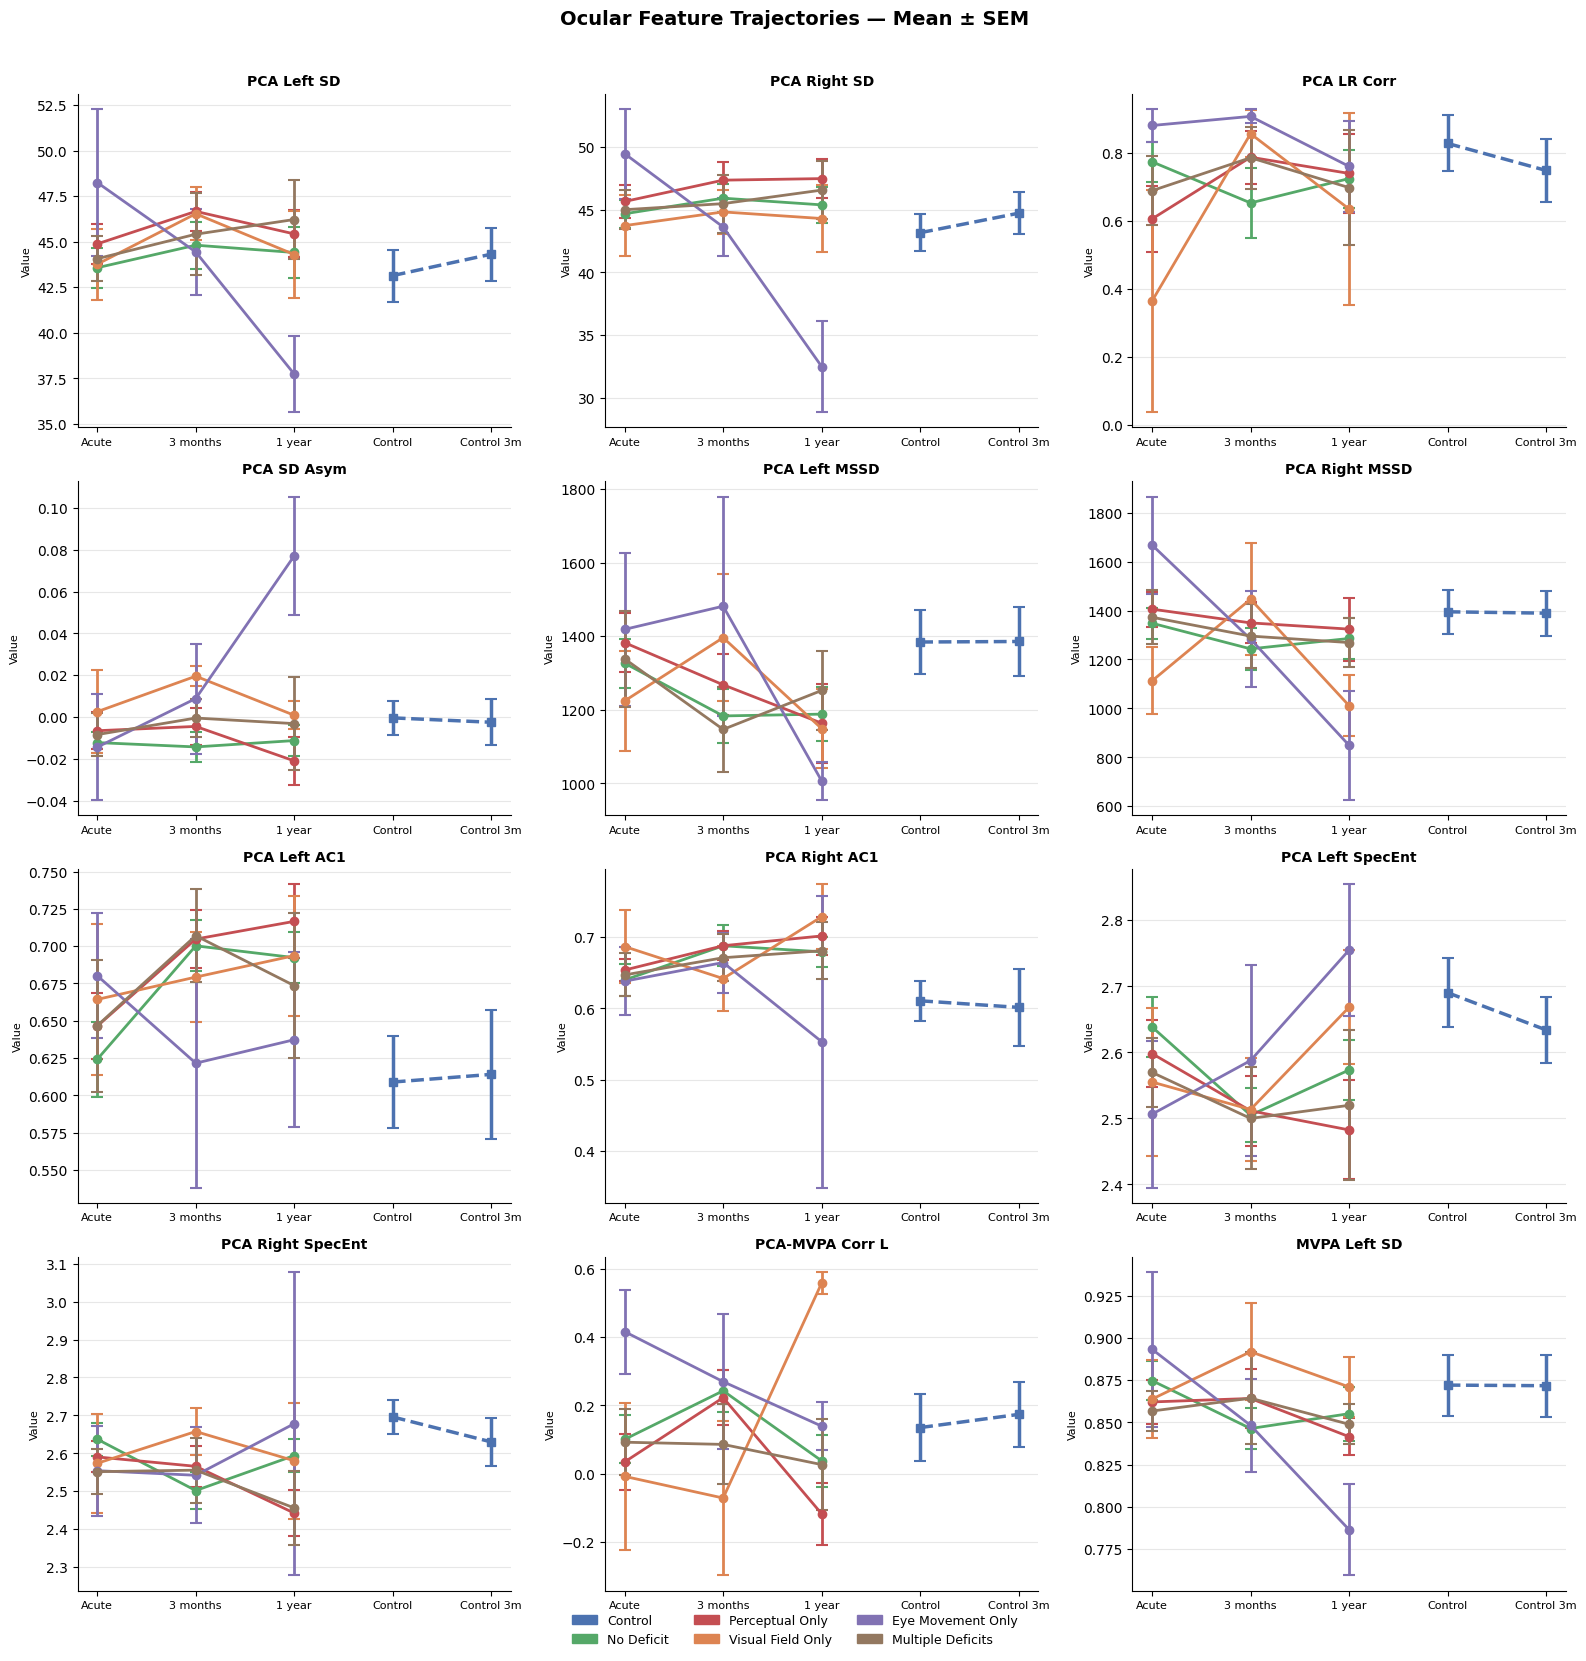

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

analysis_df = pd.read_csv("analysis_df_clean.csv")

GROUP_ORDER  = ["Control","No Deficit","Perceptual Only",
                "Visual Field Only","Eye Movement Only","Multiple Deficits"]
GROUP_COLORS = {"Control":          "#4C72B0",
                "No Deficit":       "#55A868",
                "Perceptual Only":  "#C44E52",
                "Visual Field Only":"#DD8452",
                "Eye Movement Only":"#8172B3",
                "Multiple Deficits":"#937860"}

OCULAR_FEATURES = [
    ("PCA Left SD",        "PCA_L_sd"),
    ("PCA Right SD",       "PCA_R_sd"),
    ("PCA LR Corr",        "PCA_LR_corr"),
    ("PCA SD Asym",        "PCA_sd_asym"),
    ("PCA Left MSSD",      "PCA_L_mssd"),
    ("PCA Right MSSD",     "PCA_R_mssd"),
    ("PCA Left AC1",       "PCA_L_ac1"),
    ("PCA Right AC1",      "PCA_R_ac1"),
    ("PCA Left SpecEnt",   "PCA_L_spec_entropy"),
    ("PCA Right SpecEnt",  "PCA_R_spec_entropy"),
    ("PCA-MVPA Corr L",    "corr_PCA_MVPA_L"),
    ("MVPA Left SD",       "MVPA_L_sd"),
]

SESSION_LABELS_PAT  = {0: "Acute",    1: "3 months", 2: "1 year"}
SESSION_LABELS_CTRL = {0: "Control",  1: "Control 3m"}

n_cols = 3
n_rows = int(np.ceil(len(OCULAR_FEATURES) / n_cols))

# ============================================================
# PLOT 1: Cross-sectional violin plots at baseline
# ============================================================
acute_df = analysis_df[
    (analysis_df["session_num"] == 0) &
    (analysis_df["plot_group"].isin(GROUP_ORDER))
].copy()

fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes1 = axes1.flatten()

for i, (feat_label, feat_col) in enumerate(OCULAR_FEATURES):
    ax = axes1[i]
    data_per_group = []
    labels = []
    colors = []

    for g in GROUP_ORDER:
        vals = acute_df[acute_df["plot_group"] == g][feat_col].dropna().values
        if len(vals) == 0:
            continue
        data_per_group.append(vals)
        labels.append(f"{g}\n(n={len(vals)})")
        colors.append(GROUP_COLORS[g])

    parts = ax.violinplot(data_per_group, showmedians=True,
                          showextrema=True, widths=0.7)

    for j, (pc, color) in enumerate(zip(parts["bodies"], colors)):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)
    parts["cbars"].set_color("black")
    parts["cmaxes"].set_color("black")
    parts["cmins"].set_color("black")

    # Overlay strip plot
    for j, (vals, color) in enumerate(zip(data_per_group, colors)):
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(np.full(len(vals), j + 1) + jitter, vals,
                   color=color, alpha=0.4, s=10, zorder=3)

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=7, rotation=30, ha="right")
    ax.set_title(feat_label, fontsize=10, fontweight="bold")
    ax.set_ylabel("Value", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

# Hide unused subplots
for j in range(len(OCULAR_FEATURES), len(axes1)):
    axes1[j].set_visible(False)

# Legend
patches = [mpatches.Patch(color=GROUP_COLORS[g], label=g) for g in GROUP_ORDER]
fig1.legend(handles=patches, loc="lower center", ncol=3,
            fontsize=9, frameon=False,
            bbox_to_anchor=(0.5, -0.02))

fig1.suptitle("Ocular Features at Baseline by Visual Deficit Group",
              fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: Trajectory plots
# ============================================================
pat_traj  = analysis_df[analysis_df["group_type"] == "patient"].copy()
ctrl_traj = analysis_df[analysis_df["group_type"] == "control"].copy()
ctrl_traj["plot_group"] = "Control"

def group_mean_sem(df, feat_col, group_col, session_col):
    return (df.groupby([group_col, session_col])[feat_col]
              .agg(mean="mean",
                   sem=lambda x: x.std(ddof=1) / np.sqrt(len(x)))
              .reset_index())

fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes2 = axes2.flatten()

for i, (feat_label, feat_col) in enumerate(OCULAR_FEATURES):
    ax = axes2[i]

    # Patient groups
    stats_pat = group_mean_sem(pat_traj, feat_col, "plot_group", "session_num")
    for g in [g for g in GROUP_ORDER if g != "Control"]:
        gdf = stats_pat[stats_pat["plot_group"] == g].sort_values("session_num")
        if len(gdf) == 0:
            continue
        xlabels = [SESSION_LABELS_PAT[s] for s in gdf["session_num"]]
        ax.errorbar(xlabels, gdf["mean"], yerr=gdf["sem"],
                    label=g, color=GROUP_COLORS[g],
                    marker="o", linewidth=2, markersize=6,
                    capsize=4, capthick=1.5)

    # Controls (dotted)
    stats_ctrl = group_mean_sem(ctrl_traj, feat_col, "plot_group", "session_num")
    gdf = stats_ctrl.sort_values("session_num")
    if len(gdf) > 0:
        xlabels = [SESSION_LABELS_CTRL[s] for s in gdf["session_num"]]
        ax.errorbar(xlabels, gdf["mean"], yerr=gdf["sem"],
                    label="Control", color=GROUP_COLORS["Control"],
                    marker="s", linewidth=2.5, markersize=6,
                    linestyle="--", capsize=4, capthick=1.5)

    ax.set_title(feat_label, fontsize=10, fontweight="bold")
    ax.set_ylabel("Value", fontsize=8)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

for j in range(len(OCULAR_FEATURES), len(axes2)):
    axes2[j].set_visible(False)

patches = [mpatches.Patch(color=GROUP_COLORS[g], label=g) for g in GROUP_ORDER]
fig2.legend(handles=patches, loc="lower center", ncol=3,
            fontsize=9, frameon=False,
            bbox_to_anchor=(0.5, -0.02))

fig2.suptitle("Ocular Feature Trajectories — Mean ± SEM",
              fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


  OK: PCA Left SD (n=263 observations, 103 subjects)
  OK: PCA Right SD (n=263 observations, 103 subjects)
  OK: PCA LR Corr (n=263 observations, 103 subjects)
  OK: PCA SD Asym (n=263 observations, 103 subjects)
  OK: PCA Left MSSD (n=263 observations, 103 subjects)
  OK: PCA Right MSSD (n=263 observations, 103 subjects)
  OK: PCA Left AC1 (n=263 observations, 103 subjects)
  OK: PCA Right AC1 (n=263 observations, 103 subjects)
  OK: PCA Left SpecEnt (n=263 observations, 103 subjects)
  OK: PCA Right SpecEnt (n=263 observations, 103 subjects)
  OK: PCA-MVPA Corr L (n=263 observations, 103 subjects)
  OK: MVPA Left SD (n=263 observations, 103 subjects)

  GEE RESULTS — SIGNIFICANT EFFECTS (FDR < 0.05)
  No significant effects after FDR correction.


FULL RESULTS (all terms, sorted by raw p):
          feature          term_label      coef       se   pval  pval_fdr  significant
      PCA SD Asym        Visual Field    0.0250   0.0102 0.0140    0.5039        False
  PCA-MVPA Corr L Time 

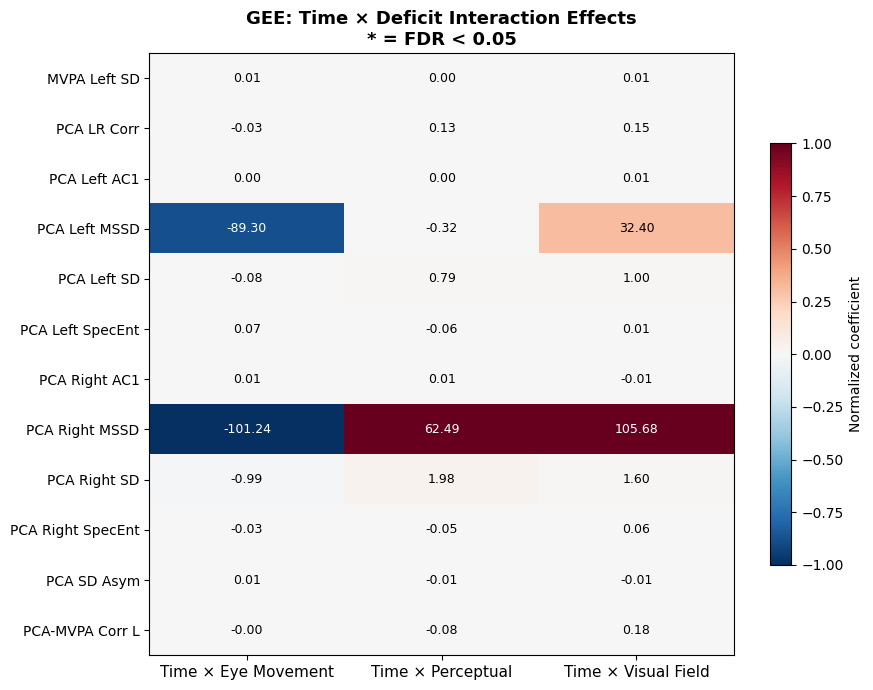

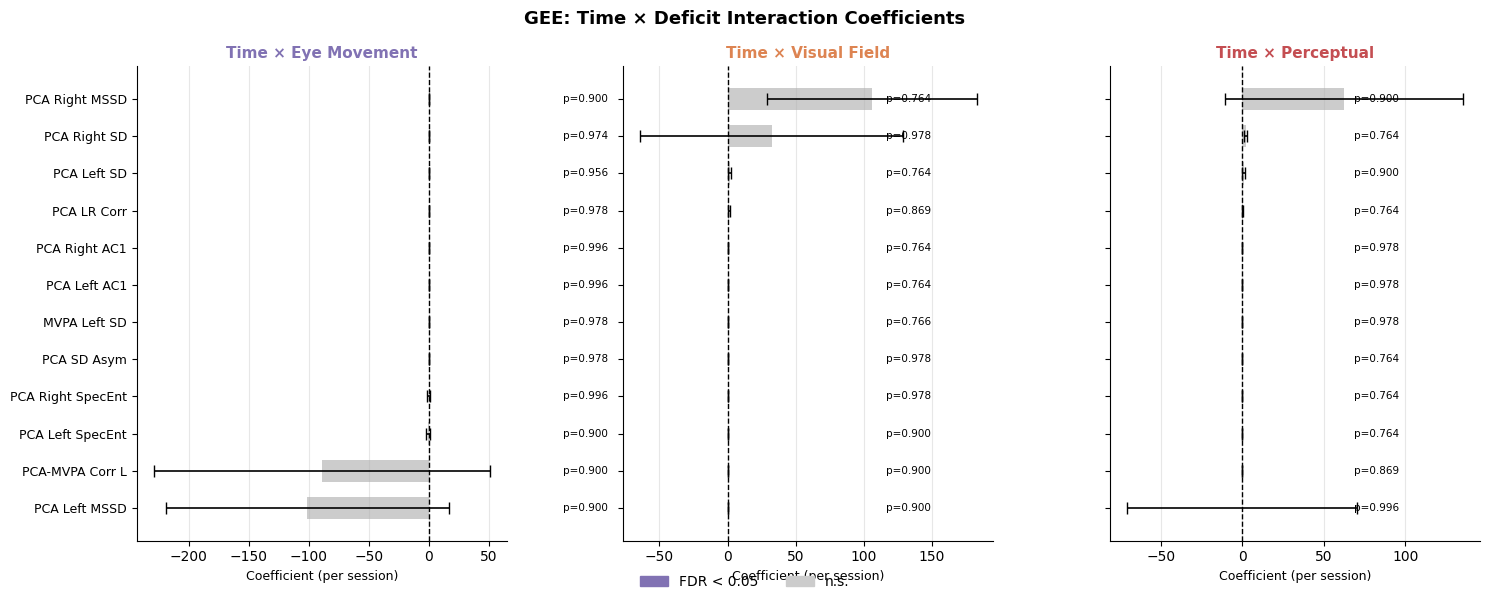

In [21]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Gaussian
from statsmodels.genmod.cov_struct import Exchangeable
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

analysis_df = pd.read_csv("analysis_df_clean.csv")

OCULAR_FEATURES = [
    ("PCA Left SD",        "PCA_L_sd"),
    ("PCA Right SD",       "PCA_R_sd"),
    ("PCA LR Corr",        "PCA_LR_corr"),
    ("PCA SD Asym",        "PCA_sd_asym"),
    ("PCA Left MSSD",      "PCA_L_mssd"),
    ("PCA Right MSSD",     "PCA_R_mssd"),
    ("PCA Left AC1",       "PCA_L_ac1"),
    ("PCA Right AC1",      "PCA_R_ac1"),
    ("PCA Left SpecEnt",   "PCA_L_spec_entropy"),
    ("PCA Right SpecEnt",  "PCA_R_spec_entropy"),
    ("PCA-MVPA Corr L",    "corr_PCA_MVPA_L"),
    ("MVPA Left SD",       "MVPA_L_sd"),
]

DEFICIT_VARS = [
    ("Eye Movement", "has_eye_movement_deficit"),
    ("Visual Field",  "has_visual_field_impairment"),
    ("Perceptual",    "has_perceptual_deficit"),
]

pat_df = analysis_df[analysis_df["group_type"] == "patient"].copy()
pat_df["session_num"] = pat_df["session_num"].astype(float)
for _, dv in DEFICIT_VARS:
    pat_df[dv] = pat_df[dv].astype(float)

# Sort by ID then session — required for GEE
pat_df = pat_df.sort_values(["ID", "session_num"]).reset_index(drop=True)

# ============================================================
# GEE model per feature
# ============================================================
results = []

for feat_label, feat_col in OCULAR_FEATURES:
    df_sub = pat_df[["ID", feat_col, "session_num",
                      "has_eye_movement_deficit",
                      "has_visual_field_impairment",
                      "has_perceptual_deficit"]].dropna()

    # Need at least 2 timepoints per subject
    counts = df_sub.groupby("ID").size()
    df_sub = df_sub[df_sub["ID"].isin(counts[counts >= 2].index)]

    if len(df_sub) < 30:
        print(f"  Skipping {feat_label} — too few observations ({len(df_sub)})")
        continue

    formula = (
        f"{feat_col} ~ session_num "
        f"+ has_eye_movement_deficit "
        f"+ has_visual_field_impairment "
        f"+ has_perceptual_deficit "
        f"+ session_num:has_eye_movement_deficit "
        f"+ session_num:has_visual_field_impairment "
        f"+ session_num:has_perceptual_deficit"
    )

    try:
        model = GEE.from_formula(
            formula,
            groups="ID",
            data=df_sub,
            family=Gaussian(),
            cov_struct=Exchangeable()   # assumes equal correlation between timepoints
        )
        result = model.fit()

        for term in result.params.index:
            if term == "Intercept":
                continue
            results.append({
                "feature":   feat_label,
                "feat_col":  feat_col,
                "term":      term,
                "coef":      result.params[term],
                "se":        result.bse[term],
                "pval":      result.pvalues[term],
            })
        print(f"  OK: {feat_label} (n={len(df_sub)} observations, "
              f"{df_sub['ID'].nunique()} subjects)")

    except Exception as e:
        print(f"  FAILED: {feat_label} — {e}")

results_df = pd.DataFrame(results)

# ============================================================
# Classify and label terms
# ============================================================
def classify_term(term):
    if "session_num:" in term or ":session_num" in term:
        return "interaction"
    elif term == "session_num":
        return "time_main"
    else:
        return "deficit_main"

term_map = {
    "session_num":                               "Time",
    "has_eye_movement_deficit":                  "Eye Movement",
    "has_visual_field_impairment":               "Visual Field",
    "has_perceptual_deficit":                    "Perceptual",
    "session_num:has_eye_movement_deficit":      "Time × Eye Movement",
    "session_num:has_visual_field_impairment":   "Time × Visual Field",
    "session_num:has_perceptual_deficit":        "Time × Perceptual",
}
results_df["term_type"]  = results_df["term"].apply(classify_term)
results_df["term_label"] = results_df["term"].map(term_map).fillna(results_df["term"])

# ============================================================
# FDR correction — separately per term type
# ============================================================
for term_type in ["interaction", "deficit_main", "time_main"]:
    mask = results_df["term_type"] == term_type
    if mask.sum() == 0:
        continue
    _, pvals_fdr, _, _ = multipletests(results_df.loc[mask, "pval"].values, method="fdr_bh")
    results_df.loc[mask, "pval_fdr"] = pvals_fdr

results_df["significant"] = results_df["pval_fdr"] < 0.05

# ============================================================
# Print results
# ============================================================
print("\n" + "=" * 90)
print("  GEE RESULTS — SIGNIFICANT EFFECTS (FDR < 0.05)")
print("=" * 90)
sig = results_df[results_df["significant"]].sort_values(["term_type","pval_fdr"])
if len(sig) == 0:
    print("  No significant effects after FDR correction.")
else:
    print(sig[["feature","term_label","coef","se","pval","pval_fdr"]]
          .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n\nFULL RESULTS (all terms, sorted by raw p):")
print(results_df[["feature","term_label","coef","se","pval","pval_fdr","significant"]]
      .sort_values("pval")
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

results_df.to_csv("gee_results.csv", index=False)
print("\nSaved: gee_results.csv")

# ============================================================
# PLOT 1: Heatmap of interaction terms
# ============================================================
interactions = results_df[results_df["term_type"] == "interaction"].copy()
pivot_coef = interactions.pivot(index="feature", columns="term_label", values="coef")
pivot_sig  = interactions.pivot(index="feature", columns="term_label", values="significant")
pivot_fdr  = interactions.pivot(index="feature", columns="term_label", values="pval_fdr")

fig, ax = plt.subplots(figsize=(9, 7))
coef_norm = pivot_coef.copy()
for col in coef_norm.columns:
    maxabs = coef_norm[col].abs().max()
    if maxabs > 0:
        coef_norm[col] = coef_norm[col] / maxabs

im = ax.imshow(coef_norm.values, cmap="RdBu_r", aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(pivot_coef.columns)))
ax.set_xticklabels(pivot_coef.columns, fontsize=11)
ax.set_yticks(range(len(pivot_coef.index)))
ax.set_yticklabels(pivot_coef.index, fontsize=10)

for i, feat in enumerate(pivot_coef.index):
    for j, term in enumerate(pivot_coef.columns):
        coef_val = pivot_coef.loc[feat, term]
        sig_val  = pivot_sig.loc[feat, term]
        if pd.isna(coef_val):
            continue
        star = " *" if sig_val else ""
        ax.text(j, i, f"{coef_val:.2f}{star}",
                ha="center", va="center", fontsize=9,
                color="white" if abs(coef_norm.loc[feat, term]) > 0.6 else "black",
                fontweight="bold" if sig_val else "normal")

plt.colorbar(im, ax=ax, label="Normalized coefficient", shrink=0.7)
ax.set_title("GEE: Time × Deficit Interaction Effects\n* = FDR < 0.05",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: Forest plot — interaction terms
# ============================================================
DEFICIT_COLORS = {
    "Time × Eye Movement": "#8172B3",
    "Time × Visual Field": "#DD8452",
    "Time × Perceptual":   "#C44E52",
}

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
for ax, (deficit_name, _) in zip(axes2, DEFICIT_VARS):
    term_name = f"Time × {deficit_name}"
    sub = results_df[results_df["term_label"] == term_name].copy().sort_values("coef")
    if len(sub) == 0:
        continue
    colors = [DEFICIT_COLORS[term_name] if s else "#cccccc" for s in sub["significant"]]
    y_pos = range(len(sub))
    ax.barh(list(y_pos), sub["coef"], xerr=sub["se"],
            color=colors, capsize=4, height=0.6,
            error_kw=dict(elinewidth=1.2, ecolor="black"))
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(sub["feature"], fontsize=9)
    ax.set_title(term_name, fontsize=11, fontweight="bold",
                 color=DEFICIT_COLORS[term_name])
    ax.set_xlabel("Coefficient (per session)", fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)
    for i, (_, row) in enumerate(sub.iterrows()):
        label = f"p={row['pval_fdr']:.3f}" + (" *" if row["significant"] else "")
        x_pos = sub["coef"].abs().max() * 1.1
        ax.text(x_pos, i, label, va="center", fontsize=7.5)

sig_patch   = mpatches.Patch(color="#8172B3", label="FDR < 0.05")
insig_patch = mpatches.Patch(color="#cccccc", label="n.s.")
fig2.legend(handles=[sig_patch, insig_patch], loc="lower center",
            ncol=2, fontsize=10, frameon=False)
fig2.suptitle("GEE: Time × Deficit Interaction Coefficients",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [22]:
results_focused = []

for feat_label, feat_col in OCULAR_FEATURES:
    for deficit_name, deficit_var in DEFICIT_VARS:
        df_sub = pat_df[["ID", feat_col, "session_num", deficit_var]].dropna()
        counts = df_sub.groupby("ID").size()
        df_sub = df_sub[df_sub["ID"].isin(counts[counts >= 2].index)]

        formula = f"{feat_col} ~ session_num + {deficit_var} + session_num:{deficit_var}"

        try:
            model  = GEE.from_formula(formula, groups="ID", data=df_sub,
                                       family=Gaussian(), cov_struct=Exchangeable())
            result = model.fit()

            for term in result.params.index:
                if term == "Intercept":
                    continue
                results_focused.append({
                    "feature":      feat_label,
                    "deficit":      deficit_name,
                    "term":         term,
                    "coef":         result.params[term],
                    "se":           result.bse[term],
                    "pval":         result.pvalues[term],
                })
        except Exception as e:
            print(f"  FAILED: {feat_label} × {deficit_name} — {e}")

focused_df = pd.DataFrame(results_focused)

# Label terms
term_map = {
    "session_num": "Time",
    deficit_var:   deficit_name,
    f"session_num:{deficit_var}": f"Time × {deficit_name}"
}
# Map dynamically
def label_term(row):
    if "session_num:" in row["term"] or ":session_num" in row["term"]:
        return f"Time × {row['deficit']}"
    elif row["term"] == "session_num":
        return "Time"
    else:
        return row["deficit"]

focused_df["term_label"] = focused_df.apply(label_term, axis=1)
focused_df["term_type"]  = focused_df["term_label"].apply(
    lambda x: "interaction" if "×" in x else ("time_main" if x == "Time" else "deficit_main")
)

# FDR correction across all interactions (12 features × 3 deficits = 36 tests)
for tt in ["interaction","deficit_main","time_main"]:
    mask = focused_df["term_type"] == tt
    if mask.sum() == 0:
        continue
    _, fdr, _, _ = multipletests(focused_df.loc[mask,"pval"].values, method="fdr_bh")
    focused_df.loc[mask, "pval_fdr"] = fdr

focused_df["significant"] = focused_df["pval_fdr"] < 0.05

print("FOCUSED MODEL — FDR < 0.05:")
sig = focused_df[focused_df["significant"]].sort_values("pval_fdr")
print(sig[["feature","deficit","term_label","coef","se","pval","pval_fdr"]].to_string(index=False,
      float_format=lambda x: f"{x:.4f}"))

print("\nFOCUSED MODEL — p_raw < 0.05:")
nom = focused_df[focused_df["pval"] < 0.05].sort_values("pval")
print(nom[["feature","deficit","term_label","coef","se","pval","pval_fdr"]].to_string(index=False,
      float_format=lambda x: f"{x:.4f}"))

focused_df.to_csv("gee_focused_results.csv", index=False)
results_focused = []

for feat_label, feat_col in OCULAR_FEATURES:
    for deficit_name, deficit_var in DEFICIT_VARS:
        df_sub = pat_df[["ID", feat_col, "session_num", deficit_var]].dropna()
        counts = df_sub.groupby("ID").size()
        df_sub = df_sub[df_sub["ID"].isin(counts[counts >= 2].index)]

        formula = f"{feat_col} ~ session_num + {deficit_var} + session_num:{deficit_var}"

        try:
            model  = GEE.from_formula(formula, groups="ID", data=df_sub,
                                       family=Gaussian(), cov_struct=Exchangeable())
            result = model.fit()

            for term in result.params.index:
                if term == "Intercept":
                    continue
                results_focused.append({
                    "feature":      feat_label,
                    "deficit":      deficit_name,
                    "term":         term,
                    "coef":         result.params[term],
                    "se":           result.bse[term],
                    "pval":         result.pvalues[term],
                })
        except Exception as e:
            print(f"  FAILED: {feat_label} × {deficit_name} — {e}")

focused_df = pd.DataFrame(results_focused)

# Label terms
term_map = {
    "session_num": "Time",
    deficit_var:   deficit_name,
    f"session_num:{deficit_var}": f"Time × {deficit_name}"
}
# Map dynamically
def label_term(row):
    if "session_num:" in row["term"] or ":session_num" in row["term"]:
        return f"Time × {row['deficit']}"
    elif row["term"] == "session_num":
        return "Time"
    else:
        return row["deficit"]

focused_df["term_label"] = focused_df.apply(label_term, axis=1)
focused_df["term_type"]  = focused_df["term_label"].apply(
    lambda x: "interaction" if "×" in x else ("time_main" if x == "Time" else "deficit_main")
)

# FDR correction across all interactions (12 features × 3 deficits = 36 tests)
for tt in ["interaction","deficit_main","time_main"]:
    mask = focused_df["term_type"] == tt
    if mask.sum() == 0:
        continue
    _, fdr, _, _ = multipletests(focused_df.loc[mask,"pval"].values, method="fdr_bh")
    focused_df.loc[mask, "pval_fdr"] = fdr

focused_df["significant"] = focused_df["pval_fdr"] < 0.05

print("FOCUSED MODEL — FDR < 0.05:")
sig = focused_df[focused_df["significant"]].sort_values("pval_fdr")
print(sig[["feature","deficit","term_label","coef","se","pval","pval_fdr"]].to_string(index=False,
      float_format=lambda x: f"{x:.4f}"))

print("\nFOCUSED MODEL — p_raw < 0.05:")
nom = focused_df[focused_df["pval"] < 0.05].sort_values("pval")
print(nom[["feature","deficit","term_label","coef","se","pval","pval_fdr"]].to_string(index=False,
      float_format=lambda x: f"{x:.4f}"))

focused_df.to_csv("gee_focused_results.csv", index=False)


FOCUSED MODEL — FDR < 0.05:
     feature      deficit term_label   coef     se   pval  pval_fdr
PCA Left AC1 Eye Movement       Time 0.0336 0.0104 0.0012    0.0433

FOCUSED MODEL — p_raw < 0.05:
          feature      deficit   term_label     coef      se   pval  pval_fdr
     PCA Left AC1 Eye Movement         Time   0.0336  0.0104 0.0012    0.0433
     PCA Left AC1 Visual Field         Time   0.0327  0.0115 0.0045    0.0809
      PCA SD Asym Visual Field Visual Field   0.0270  0.0098 0.0059    0.2106
    PCA Right AC1 Visual Field         Time   0.0282  0.0112 0.0120    0.1031
     PCA Left AC1   Perceptual         Time   0.0330  0.0134 0.0139    0.1031
    PCA Left MSSD Visual Field         Time -94.7137 40.0593 0.0181    0.1031
PCA Right SpecEnt Visual Field         Time  -0.0549  0.0233 0.0185    0.1031
    PCA Right AC1 Eye Movement         Time   0.0238  0.0102 0.0200    0.1031
    PCA Left MSSD Eye Movement         Time -79.4346 37.3287 0.0333    0.1500
     PCA Right SD Visual 

  COHEN'S d + MANN-WHITNEY U — BASELINE (ACUTE) GROUP DIFFERENCES
  Deficit-present vs. Deficit-absent patients

Feature                Deficit           n1   n0   Mean(D+)   Mean(D-)       d Size            p_raw    p_FDR   Sig
-----------------------------------------------------------------------------------------------
PCA LR Corr            Eye Movement      18  110      0.595      0.711  -0.224 small          0.1173   0.9918      
PCA Right AC1          Eye Movement      18  110      0.624      0.651  -0.194 negligible     0.5305   0.9918      
PCA Right SpecEnt      Eye Movement      18  110      2.554      2.607  -0.182 negligible     0.6535   0.9918      
PCA Left MSSD          Eye Movement      18  110   1413.083   1332.778   0.157 negligible     0.9208   0.9918      
PCA Right MSSD         Eye Movement      18  110   1436.883   1363.114   0.156 negligible     0.9372   0.9918      
PCA Left SpecEnt       Eye Movement      18  110      2.564      2.609  -0.146 negligible     0

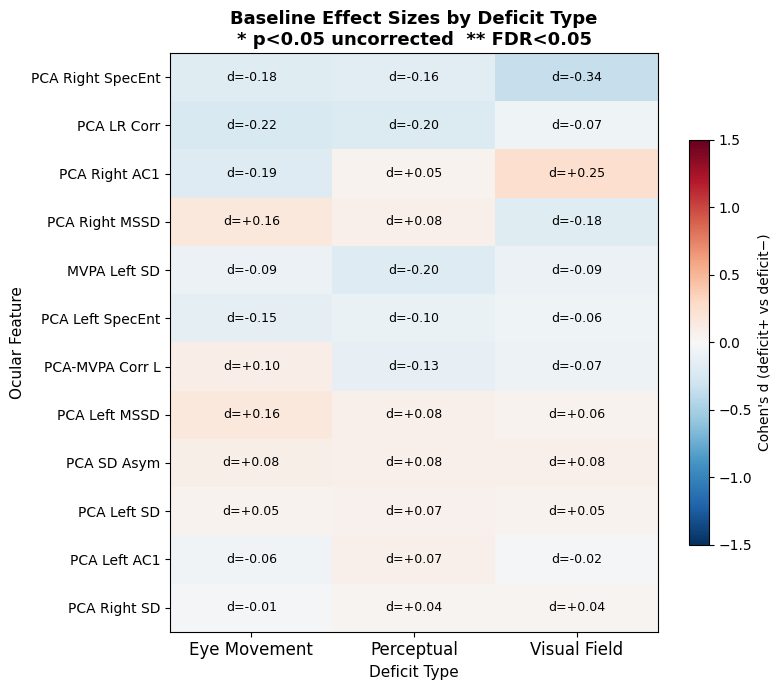

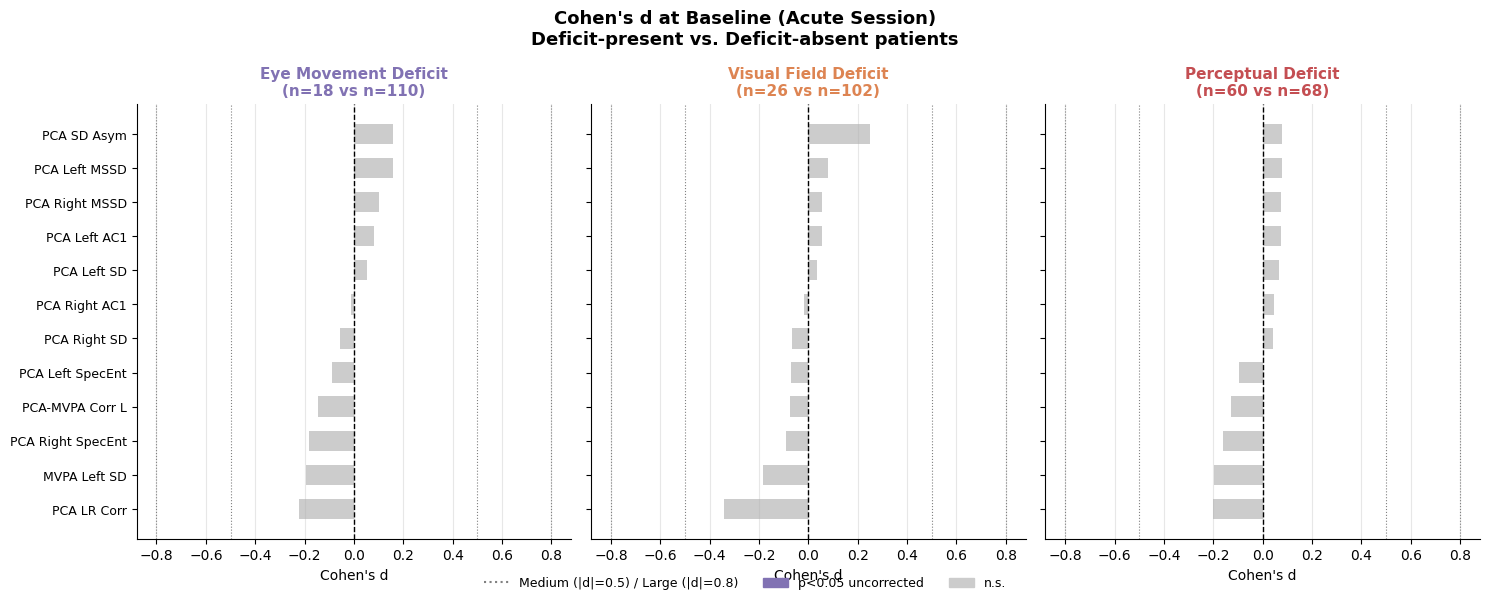

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

analysis_df = pd.read_csv("analysis_df_clean.csv")

OCULAR_FEATURES = [
    ("PCA Left SD",        "PCA_L_sd"),
    ("PCA Right SD",       "PCA_R_sd"),
    ("PCA LR Corr",        "PCA_LR_corr"),
    ("PCA SD Asym",        "PCA_sd_asym"),
    ("PCA Left MSSD",      "PCA_L_mssd"),
    ("PCA Right MSSD",     "PCA_R_mssd"),
    ("PCA Left AC1",       "PCA_L_ac1"),
    ("PCA Right AC1",      "PCA_R_ac1"),
    ("PCA Left SpecEnt",   "PCA_L_spec_entropy"),
    ("PCA Right SpecEnt",  "PCA_R_spec_entropy"),
    ("PCA-MVPA Corr L",    "corr_PCA_MVPA_L"),
    ("MVPA Left SD",       "MVPA_L_sd"),
]

DEFICIT_VARS = [
    ("Eye Movement", "has_eye_movement_deficit"),
    ("Visual Field",  "has_visual_field_impairment"),
    ("Perceptual",    "has_perceptual_deficit"),
]

# Acute session patients only
acute = analysis_df[
    (analysis_df["group_type"] == "patient") &
    (analysis_df["session_num"] == 0)
].copy()

# ============================================================
# Compute Cohen's d + Mann-Whitney U per feature × deficit
# ============================================================
rows = []
for feat_label, feat_col in OCULAR_FEATURES:
    for deficit_name, deficit_var in DEFICIT_VARS:
        g1 = acute[acute[deficit_var] == 1][feat_col].dropna()
        g0 = acute[acute[deficit_var] == 0][feat_col].dropna()

        if len(g1) < 3 or len(g0) < 3:
            continue

        # Cohen's d (pooled SD)
        pooled_sd = np.sqrt(
            ((len(g1)-1) * g1.var(ddof=1) + (len(g0)-1) * g0.var(ddof=1))
            / (len(g1) + len(g0) - 2)
        )
        d = (g1.mean() - g0.mean()) / pooled_sd if pooled_sd > 0 else np.nan

        # Mann-Whitney U (non-parametric, appropriate for small groups)
        stat, pval = stats.mannwhitneyu(g1, g0, alternative="two-sided")

        rows.append({
            "feature":     feat_label,
            "feat_col":    feat_col,
            "deficit":     deficit_name,
            "deficit_var": deficit_var,
            "n_deficit":   len(g1),
            "n_no_deficit":len(g0),
            "mean_deficit":    g1.mean(),
            "mean_no_deficit": g0.mean(),
            "cohens_d":    d,
            "abs_d":       abs(d),
            "mwu_pval":    pval,
        })

effect_df = pd.DataFrame(rows)

# FDR correction across all MWU tests
from statsmodels.stats.multitest import multipletests
_, fdr, _, _ = multipletests(effect_df["mwu_pval"].values, method="fdr_bh")
effect_df["mwu_pval_fdr"] = fdr
effect_df["significant_fdr"] = effect_df["mwu_pval_fdr"] < 0.05
effect_df["significant_nom"] = effect_df["mwu_pval"] < 0.05

# Effect size classification
def classify_d(d):
    d = abs(d)
    if d >= 0.8:  return "large"
    if d >= 0.5:  return "medium"
    if d >= 0.2:  return "small"
    return "negligible"

effect_df["effect_size"] = effect_df["cohens_d"].apply(classify_d)

# ============================================================
# Print summary
# ============================================================
print("=" * 95)
print("  COHEN'S d + MANN-WHITNEY U — BASELINE (ACUTE) GROUP DIFFERENCES")
print("  Deficit-present vs. Deficit-absent patients")
print("=" * 95)
print(f"\n{'Feature':<22} {'Deficit':<15} {'n1':>4} {'n0':>4} "
      f"{'Mean(D+)':>10} {'Mean(D-)':>10} {'d':>7} {'Size':<12} {'p_raw':>8} {'p_FDR':>8} {'Sig':>5}")
print("-" * 95)

for _, row in effect_df.sort_values(["deficit","abs_d"], ascending=[True, False]).iterrows():
    sig = "***" if row["significant_fdr"] else ("*" if row["significant_nom"] else "")
    print(f"{row['feature']:<22} {row['deficit']:<15} {row['n_deficit']:>4} {row['n_no_deficit']:>4} "
          f"{row['mean_deficit']:>10.3f} {row['mean_no_deficit']:>10.3f} "
          f"{row['cohens_d']:>7.3f} {row['effect_size']:<12} "
          f"{row['mwu_pval']:>8.4f} {row['mwu_pval_fdr']:>8.4f} {sig:>5}")

effect_df.to_csv("effect_sizes_baseline.csv", index=False)
print("\nSaved: effect_sizes_baseline.csv")

# ============================================================
# PLOT: Cohen's d heatmap (features × deficit types)
# ============================================================
pivot_d    = effect_df.pivot(index="feature", columns="deficit", values="cohens_d")
pivot_sig  = effect_df.pivot(index="feature", columns="deficit", values="significant_nom")
pivot_fdr  = effect_df.pivot(index="feature", columns="deficit", values="significant_fdr")

# Sort features by mean absolute d
row_order = pivot_d.abs().mean(axis=1).sort_values(ascending=False).index
pivot_d   = pivot_d.loc[row_order]
pivot_sig = pivot_sig.loc[row_order]
pivot_fdr = pivot_fdr.loc[row_order]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(pivot_d.values, cmap="RdBu_r", aspect="auto", vmin=-1.5, vmax=1.5)

ax.set_xticks(range(len(pivot_d.columns)))
ax.set_xticklabels(pivot_d.columns, fontsize=12)
ax.set_yticks(range(len(pivot_d.index)))
ax.set_yticklabels(pivot_d.index, fontsize=10)

for i, feat in enumerate(pivot_d.index):
    for j, deficit in enumerate(pivot_d.columns):
        d_val   = pivot_d.loc[feat, deficit]
        sig_nom = pivot_sig.loc[feat, deficit]
        sig_fdr = pivot_fdr.loc[feat, deficit]
        if pd.isna(d_val):
            continue
        star = "**" if sig_fdr else ("*" if sig_nom else "")
        txt_color = "white" if abs(d_val) > 0.9 else "black"
        ax.text(j, i, f"d={d_val:+.2f}{star}",
                ha="center", va="center", fontsize=9,
                color=txt_color,
                fontweight="bold" if sig_nom else "normal")

plt.colorbar(im, ax=ax, label="Cohen's d (deficit+ vs deficit−)", shrink=0.7)
ax.set_title("Baseline Effect Sizes by Deficit Type\n* p<0.05 uncorrected  ** FDR<0.05",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Deficit Type", fontsize=11)
ax.set_ylabel("Ocular Feature", fontsize=11)
plt.tight_layout()
plt.show()

# ============================================================
# PLOT: Forest plot of Cohen's d per deficit type
# ============================================================
DEFICIT_COLORS = {
    "Eye Movement": "#8172B3",
    "Visual Field":  "#DD8452",
    "Perceptual":    "#C44E52",
}

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
for ax, (deficit_name, _) in zip(axes2, DEFICIT_VARS):
    sub = effect_df[effect_df["deficit"] == deficit_name].copy().sort_values("cohens_d")
    colors = [DEFICIT_COLORS[deficit_name] if s else "#cccccc"
              for s in sub["significant_nom"]]
    y_pos = range(len(sub))
    ax.barh(list(y_pos), sub["cohens_d"], color=colors, height=0.6)
    ax.axvline(0,    color="black",  linewidth=1,   linestyle="--")
    ax.axvline(0.5,  color="gray",   linewidth=0.8, linestyle=":")
    ax.axvline(-0.5, color="gray",   linewidth=0.8, linestyle=":")
    ax.axvline(0.8,  color="gray",   linewidth=0.8, linestyle=":")
    ax.axvline(-0.8, color="gray",   linewidth=0.8, linestyle=":")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(sub["feature"], fontsize=9)
    ax.set_title(f"{deficit_name} Deficit\n(n={int(sub['n_deficit'].iloc[0])} vs "
                 f"n={int(sub['n_no_deficit'].iloc[0])})",
                 fontsize=11, fontweight="bold", color=DEFICIT_COLORS[deficit_name])
    ax.set_xlabel("Cohen's d", fontsize=10)
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

    # Annotate p-values
    for i, (_, row) in enumerate(sub.iterrows()):
        star = "**" if row["significant_fdr"] else ("*" if row["significant_nom"] else "")
        if star:
            ax.text(row["cohens_d"] + (0.05 if row["cohens_d"] >= 0 else -0.05),
                    i, star, va="center", fontsize=11,
                    color=DEFICIT_COLORS[deficit_name])

# Reference lines legend
from matplotlib.lines import Line2D
ref_lines = [
    Line2D([0],[0], color="gray", linestyle=":", label="Medium (|d|=0.5) / Large (|d|=0.8)"),
    mpatches.Patch(color=list(DEFICIT_COLORS.values())[0], label="p<0.05 uncorrected"),
    mpatches.Patch(color="#cccccc", label="n.s."),
]
fig2.legend(handles=ref_lines, loc="lower center", ncol=3, fontsize=9, frameon=False)
fig2.suptitle("Cohen's d at Baseline (Acute Session)\nDeficit-present vs. Deficit-absent patients",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Note: scikit-posthocs not installed. Run: pip install scikit-posthocs
Falling back to pairwise Mann-Whitney U for post-hoc tests.

  FIGURE 1 — KRUSKAL-WALLIS (6 groups at baseline)
          feature  kw_stat  kw_pval  kw_pval_fdr  kw_sig
      PCA Left SD   2.3175   0.8037       0.9607   False
     PCA Right SD   3.6768   0.5968       0.9607   False
      PCA LR Corr   6.8921   0.2288       0.9607   False
      PCA SD Asym   1.1214   0.9522       0.9607   False
    PCA Left MSSD   1.5853   0.9030       0.9607   False
   PCA Right MSSD   6.1226   0.2945       0.9607   False
     PCA Left AC1   3.2014   0.6690       0.9607   False
    PCA Right AC1   2.4538   0.7834       0.9607   False
 PCA Left SpecEnt   4.7268   0.4501       0.9607   False
PCA Right SpecEnt   4.2379   0.5157       0.9607   False
  PCA-MVPA Corr L   4.6576   0.4591       0.9607   False
     MVPA Left SD   1.0227   0.9607       0.9607   False


FDR-SIGNIFICANT POST-HOC PAIRS (p_fdr < 0.05):
  None significant

NOMINALL

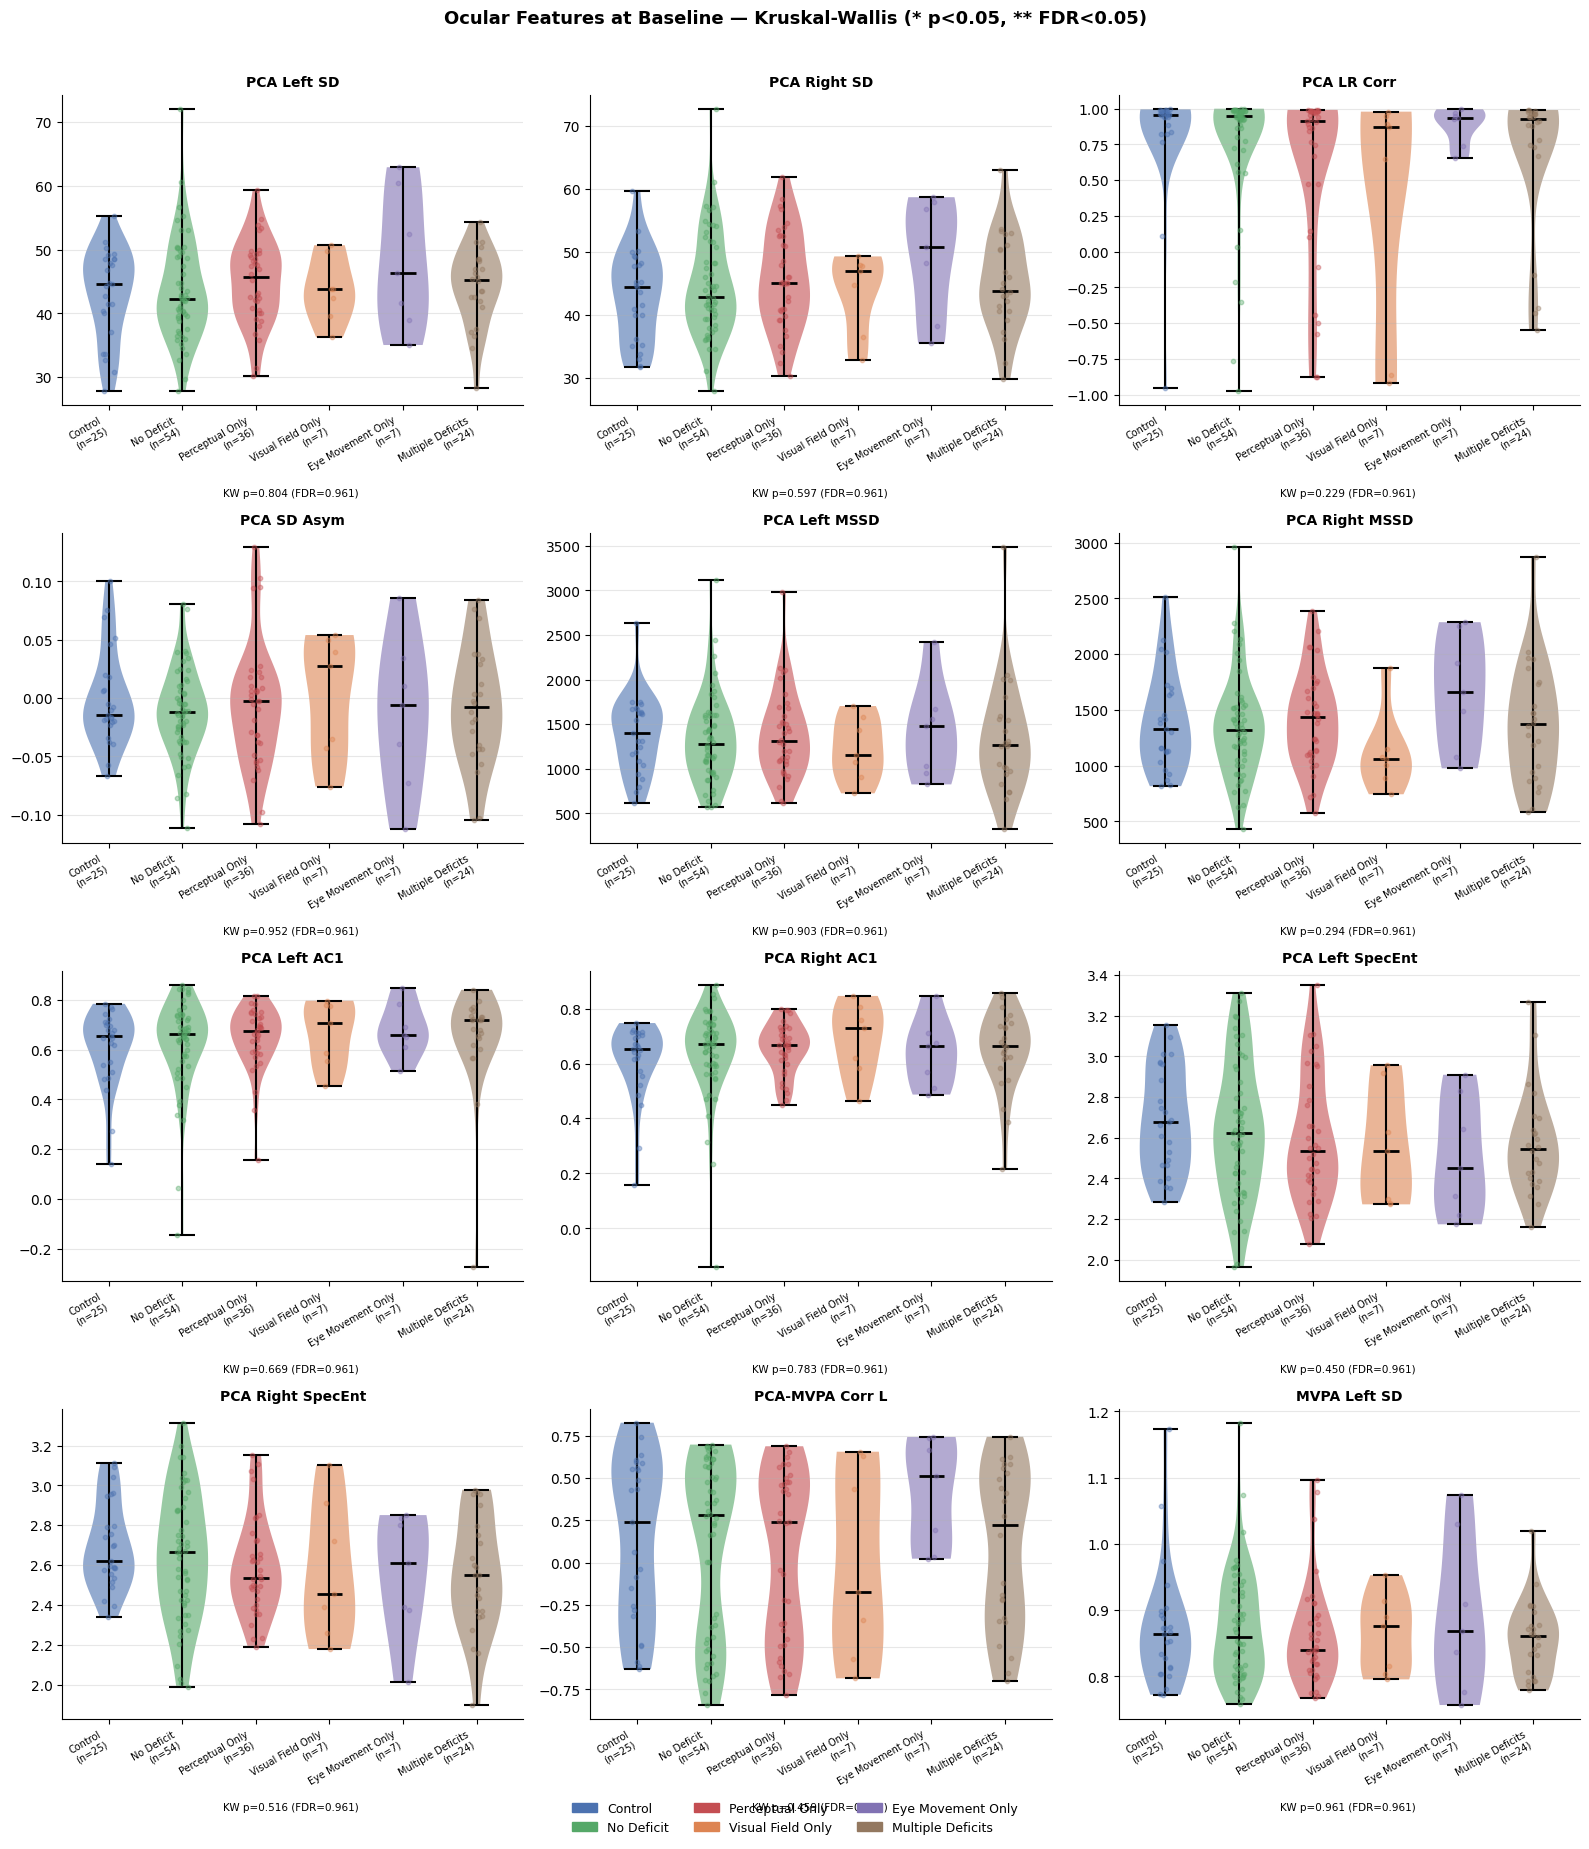

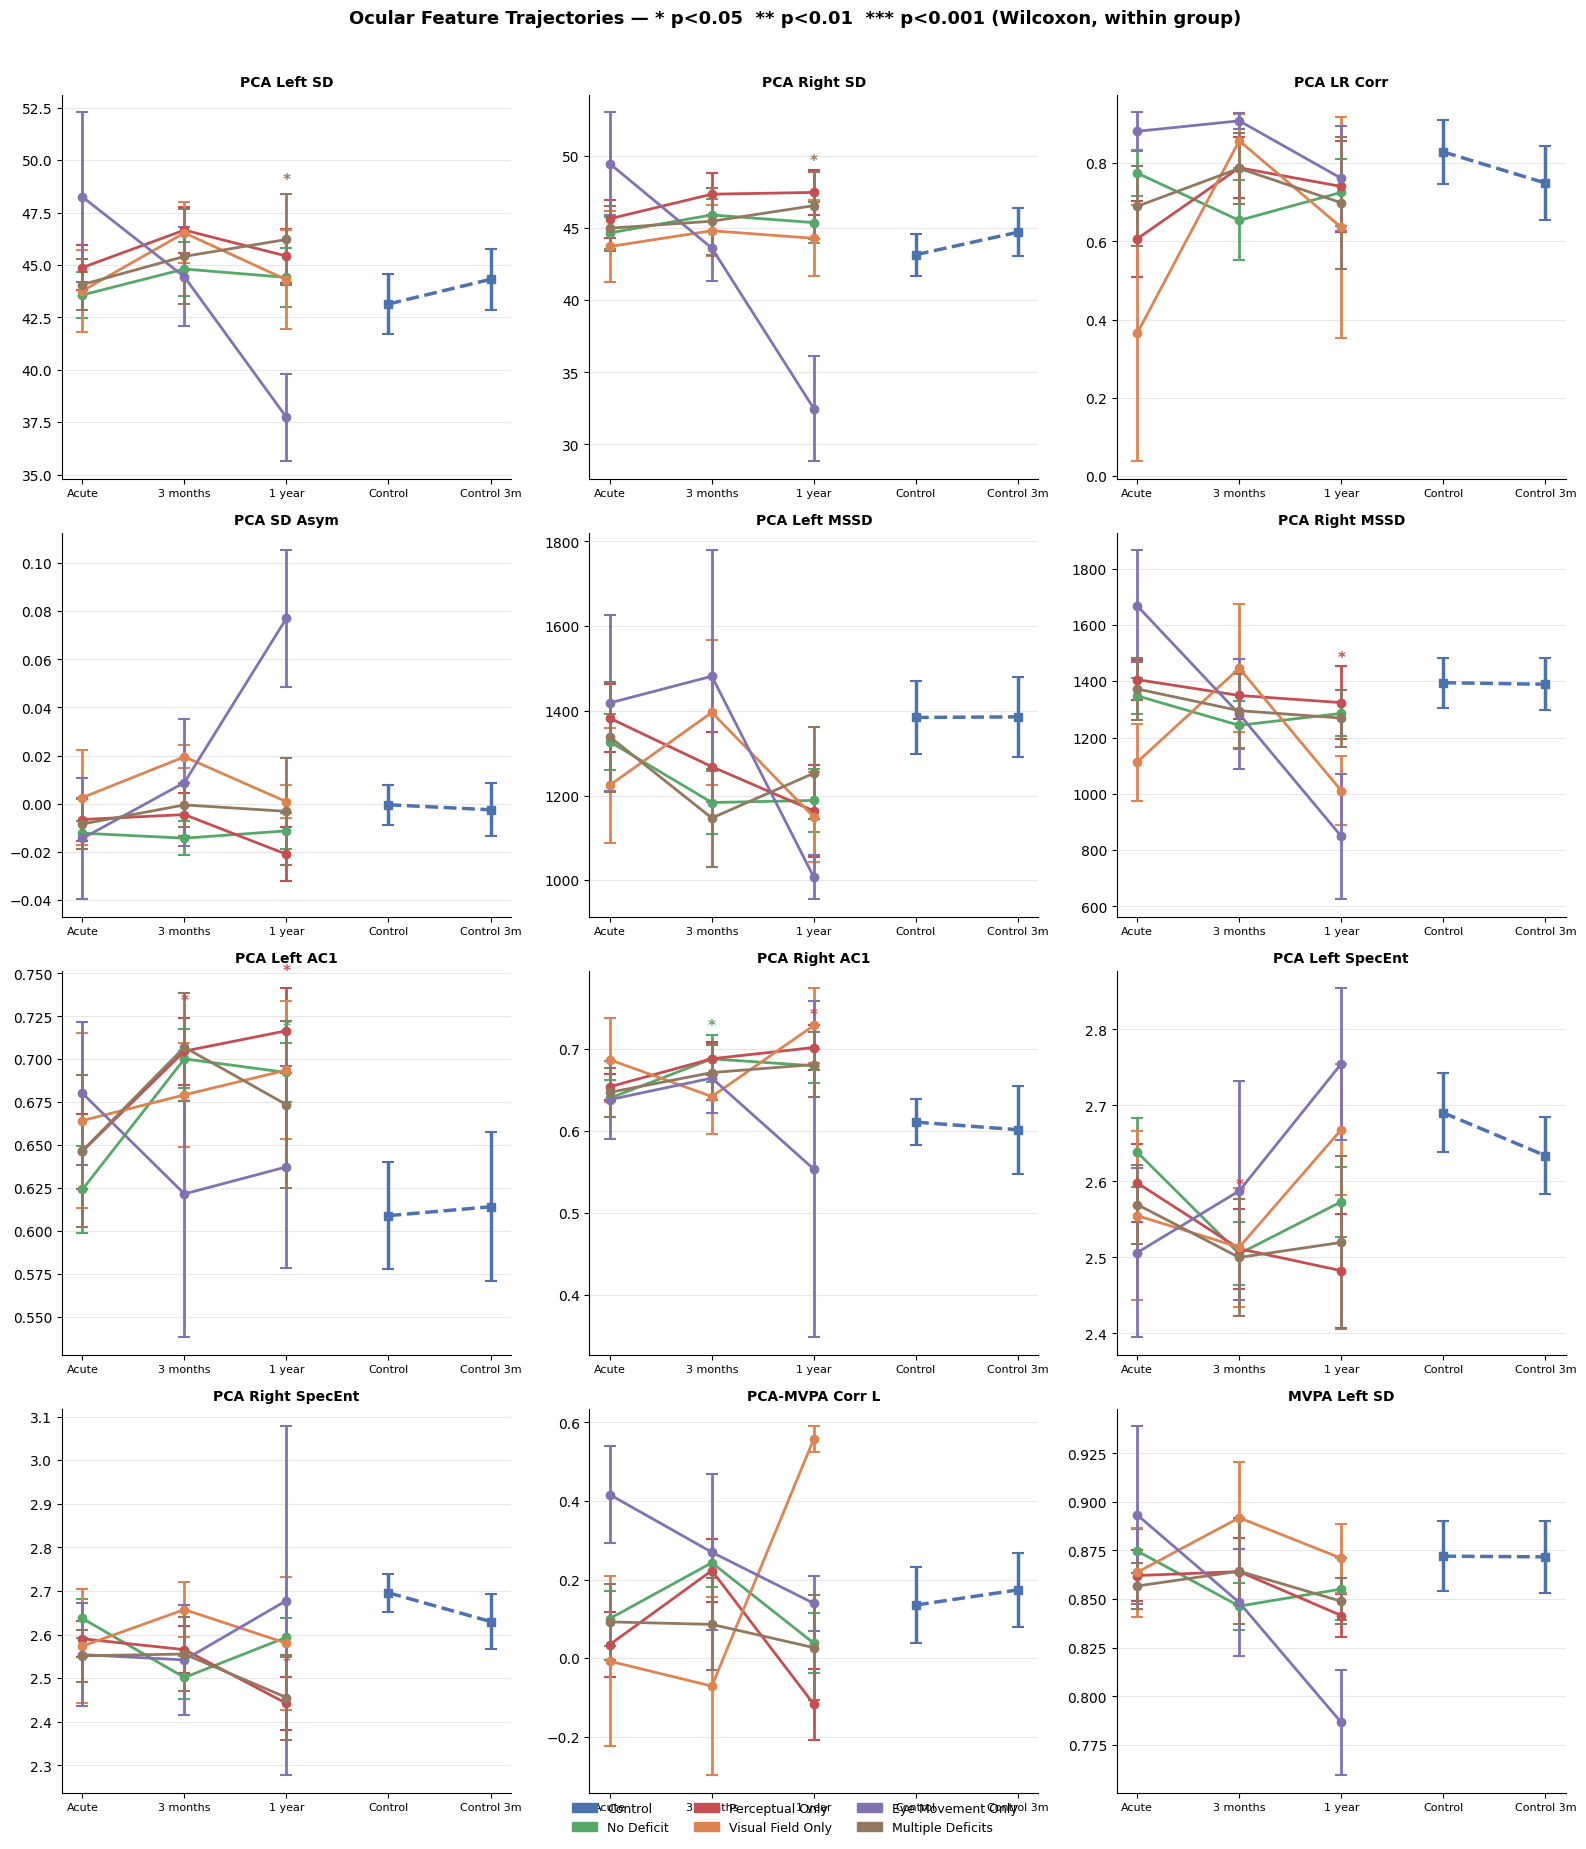

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations
import warnings
warnings.filterwarnings("ignore")

try:
    from scikit_posthocs import posthoc_dunn
    HAS_DUNN = True
except ImportError:
    HAS_DUNN = False
    print("Note: scikit-posthocs not installed. Run: pip install scikit-posthocs")
    print("Falling back to pairwise Mann-Whitney U for post-hoc tests.\n")

analysis_df = pd.read_csv("analysis_df_clean.csv")

OCULAR_FEATURES = [
    ("PCA Left SD",        "PCA_L_sd"),
    ("PCA Right SD",       "PCA_R_sd"),
    ("PCA LR Corr",        "PCA_LR_corr"),
    ("PCA SD Asym",        "PCA_sd_asym"),
    ("PCA Left MSSD",      "PCA_L_mssd"),
    ("PCA Right MSSD",     "PCA_R_mssd"),
    ("PCA Left AC1",       "PCA_L_ac1"),
    ("PCA Right AC1",      "PCA_R_ac1"),
    ("PCA Left SpecEnt",   "PCA_L_spec_entropy"),
    ("PCA Right SpecEnt",  "PCA_R_spec_entropy"),
    ("PCA-MVPA Corr L",    "corr_PCA_MVPA_L"),
    ("MVPA Left SD",       "MVPA_L_sd"),
]

GROUP_ORDER = ["Control","No Deficit","Perceptual Only",
               "Visual Field Only","Eye Movement Only","Multiple Deficits"]

# ============================================================
# FIGURE 1: Kruskal-Wallis + post-hoc across groups at baseline
# ============================================================
acute_df = analysis_df[
    (analysis_df["session_num"] == 0) &
    (analysis_df["plot_group"].isin(GROUP_ORDER))
].copy()

kw_results = []
posthoc_results = []

for feat_label, feat_col in OCULAR_FEATURES:
    groups_data = {g: acute_df[acute_df["plot_group"] == g][feat_col].dropna().values
                   for g in GROUP_ORDER}
    groups_data = {g: v for g, v in groups_data.items() if len(v) >= 3}

    if len(groups_data) < 2:
        continue

    # Kruskal-Wallis
    stat, pval = stats.kruskal(*groups_data.values())
    kw_results.append({
        "feature": feat_label,
        "feat_col": feat_col,
        "kw_stat": stat,
        "kw_pval": pval,
        "n_groups": len(groups_data)
    })

    # Post-hoc: Dunn or pairwise MWU
    if HAS_DUNN:
        all_vals   = np.concatenate(list(groups_data.values()))
        all_labels = np.concatenate([[g]*len(v) for g, v in groups_data.items()])
        dunn = posthoc_dunn(
            pd.DataFrame({"val": all_vals, "group": all_labels}),
            val_col="val", group_col="group", p_adjust="fdr_bh"
        )
        for g1, g2 in combinations(groups_data.keys(), 2):
            posthoc_results.append({
                "feature": feat_label,
                "feat_col": feat_col,
                "group1": g1, "group2": g2,
                "pval": dunn.loc[g1, g2]
            })
    else:
        # Pairwise MWU fallback
        pair_pvals = []
        pairs = list(combinations(groups_data.keys(), 2))
        for g1, g2 in pairs:
            s, p = stats.mannwhitneyu(groups_data[g1], groups_data[g2],
                                      alternative="two-sided")
            pair_pvals.append(p)
        _, pair_pvals_fdr, _, _ = multipletests(pair_pvals, method="fdr_bh")
        for (g1, g2), p in zip(pairs, pair_pvals_fdr):
            posthoc_results.append({
                "feature": feat_label,
                "feat_col": feat_col,
                "group1": g1, "group2": g2,
                "pval": p
            })

kw_df = pd.DataFrame(kw_results)
_, kw_fdr, _, _ = multipletests(kw_df["kw_pval"].values, method="fdr_bh")
kw_df["kw_pval_fdr"] = kw_fdr
kw_df["kw_sig"] = kw_df["kw_pval_fdr"] < 0.05

posthoc_df = pd.DataFrame(posthoc_results)

print("=" * 70)
print("  FIGURE 1 — KRUSKAL-WALLIS (6 groups at baseline)")
print("=" * 70)
print(kw_df[["feature","kw_stat","kw_pval","kw_pval_fdr","kw_sig"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n\nFDR-SIGNIFICANT POST-HOC PAIRS (p_fdr < 0.05):")
sig_ph = posthoc_df[posthoc_df["pval"] < 0.05].sort_values("pval")
if len(sig_ph) == 0:
    print("  None significant")
else:
    print(sig_ph[["feature","group1","group2","pval"]]
          .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\nNOMINALLY SIGNIFICANT POST-HOC PAIRS (p_raw/Dunn < 0.05):")
nom_ph = posthoc_df[posthoc_df["pval"] < 0.05]
print(nom_ph[["feature","group1","group2","pval"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ============================================================
# FIGURE 2: Wilcoxon signed-rank per group across time
# ============================================================
# For each group × feature: acute vs 3m, acute vs 1y
# Only include subjects with data at BOTH timepoints (paired)

SESSION_PAIRS = [
    ("Acute → 3 months", 0, 1),
    ("Acute → 1 year",   0, 2),
]

wilcox_results = []

pat_df = analysis_df[analysis_df["group_type"] == "patient"].copy()

for feat_label, feat_col in OCULAR_FEATURES:
    for group in GROUP_ORDER:
        if group == "Control":
            continue
        gdf = pat_df[pat_df["plot_group"] == group][
            ["ID", "session_num", feat_col]].dropna()

        for label, t0, t1 in SESSION_PAIRS:
            df0 = gdf[gdf["session_num"] == t0].set_index("ID")[feat_col]
            df1 = gdf[gdf["session_num"] == t1].set_index("ID")[feat_col]
            common = df0.index.intersection(df1.index)

            if len(common) < 5:
                continue

            v0 = df0.loc[common].values
            v1 = df1.loc[common].values

            stat, pval = stats.wilcoxon(v0, v1, alternative="two-sided")
            wilcox_results.append({
                "feature":    feat_label,
                "feat_col":   feat_col,
                "group":      group,
                "comparison": label,
                "n_pairs":    len(common),
                "mean_t0":    v0.mean(),
                "mean_t1":    v1.mean(),
                "delta":      v1.mean() - v0.mean(),
                "w_stat":     stat,
                "pval":       pval,
            })

wilcox_df = pd.DataFrame(wilcox_results)

# FDR across all Wilcoxon tests
_, wfdr, _, _ = multipletests(wilcox_df["pval"].values, method="fdr_bh")
wilcox_df["pval_fdr"] = wfdr
wilcox_df["sig_fdr"]  = wilcox_df["pval_fdr"] < 0.05
wilcox_df["sig_nom"]  = wilcox_df["pval"] < 0.05

print("\n\n" + "=" * 80)
print("  FIGURE 2 — WILCOXON SIGNED-RANK (within-group change over time)")
print("=" * 80)

print("\nFDR-SIGNIFICANT (p_fdr < 0.05):")
sig_w = wilcox_df[wilcox_df["sig_fdr"]].sort_values("pval_fdr")
if len(sig_w) == 0:
    print("  None")
else:
    print(sig_w[["feature","group","comparison","n_pairs",
                 "mean_t0","mean_t1","delta","pval","pval_fdr"]]
          .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\nNOMINALLY SIGNIFICANT (p_raw < 0.05):")
nom_w = wilcox_df[wilcox_df["sig_nom"]].sort_values("pval")
print(nom_w[["feature","group","comparison","n_pairs",
             "mean_t0","mean_t1","delta","pval","pval_fdr"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ============================================================
# SAVE
# ============================================================
kw_df.to_csv("fig1_kruskal_wallis.csv", index=False)
posthoc_df.to_csv("fig1_posthoc.csv", index=False)
wilcox_df.to_csv("fig2_wilcoxon.csv", index=False)
print("\nSaved: fig1_kruskal_wallis.csv, fig1_posthoc.csv, fig2_wilcoxon.csv")

# ============================================================
# PLOT: Annotated violin plot with KW p-values on top
# ============================================================
GROUP_COLORS = {"Control":          "#4C72B0",
                "No Deficit":       "#55A868",
                "Perceptual Only":  "#C44E52",
                "Visual Field Only":"#DD8452",
                "Eye Movement Only":"#8172B3",
                "Multiple Deficits":"#937860"}

n_cols = 3
n_rows = int(np.ceil(len(OCULAR_FEATURES) / n_cols))

fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
axes1 = axes1.flatten()

for i, (feat_label, feat_col) in enumerate(OCULAR_FEATURES):
    ax = axes1[i]
    data_per_group, labels, colors = [], [], []

    for g in GROUP_ORDER:
        vals = acute_df[acute_df["plot_group"] == g][feat_col].dropna().values
        if len(vals) < 3:
            continue
        data_per_group.append(vals)
        labels.append(f"{g}\n(n={len(vals)})")
        colors.append(GROUP_COLORS[g])

    parts = ax.violinplot(data_per_group, showmedians=True,
                          showextrema=True, widths=0.7)
    for pc, color in zip(parts["bodies"], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)
    for key in ["cbars","cmaxes","cmins"]:
        parts[key].set_color("black")

    for j, (vals, color) in enumerate(zip(data_per_group, colors)):
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(np.full(len(vals), j+1) + jitter, vals,
                   color=color, alpha=0.4, s=10, zorder=3)

    ax.set_xticks(range(1, len(labels)+1))
    ax.set_xticklabels(labels, fontsize=7, rotation=30, ha="right")
    ax.set_title(feat_label, fontsize=10, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

    # Add KW p-value
    row_kw = kw_df[kw_df["feat_col"] == feat_col]
    if len(row_kw) > 0:
        p = row_kw.iloc[0]["kw_pval"]
        pfdr = row_kw.iloc[0]["kw_pval_fdr"]
        sig_marker = "**" if pfdr < 0.05 else ("*" if p < 0.05 else "")
        ax.set_xlabel(f"KW p={p:.3f} (FDR={pfdr:.3f}) {sig_marker}", fontsize=7.5)

for j in range(len(OCULAR_FEATURES), len(axes1)):
    axes1[j].set_visible(False)

patches = [mpatches.Patch(color=GROUP_COLORS[g], label=g) for g in GROUP_ORDER]
fig1.legend(handles=patches, loc="lower center", ncol=3,
            fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig1.suptitle("Ocular Features at Baseline — Kruskal-Wallis (* p<0.05, ** FDR<0.05)",
              fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ============================================================
# PLOT: Trajectory plot with Wilcoxon significance annotations
# ============================================================
def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

SESSION_LABELS_PAT  = {0: "Acute", 1: "3 months", 2: "1 year"}
SESSION_LABELS_CTRL = {0: "Control", 1: "Control 3m"}

ctrl_df = analysis_df[analysis_df["group_type"] == "control"].copy()
ctrl_df["plot_group"] = "Control"

def group_mean_sem(df, feat_col, group_col, session_col):
    return (df.groupby([group_col, session_col])[feat_col]
              .agg(mean="mean", sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)))
              .reset_index())

fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
axes2 = axes2.flatten()

for i, (feat_label, feat_col) in enumerate(OCULAR_FEATURES):
    ax = axes2[i]
    stats_pat = group_mean_sem(pat_df, feat_col, "plot_group", "session_num")

    for g in [g for g in GROUP_ORDER if g != "Control"]:
        gdf = stats_pat[stats_pat["plot_group"] == g].sort_values("session_num")
        if len(gdf) == 0:
            continue
        xlabels = [SESSION_LABELS_PAT[s] for s in gdf["session_num"]]
        ax.errorbar(xlabels, gdf["mean"], yerr=gdf["sem"],
                    label=g, color=GROUP_COLORS[g],
                    marker="o", linewidth=2, markersize=6,
                    capsize=4, capthick=1.5)

        # Annotate Wilcoxon stars between acute and each followup
        for comp_label, t0, t1 in SESSION_PAIRS:
            row_w = wilcox_df[
                (wilcox_df["feat_col"] == feat_col) &
                (wilcox_df["group"] == g) &
                (wilcox_df["comparison"] == comp_label)
            ]
            if len(row_w) == 0:
                continue
            stars = sig_stars(row_w.iloc[0]["pval"])
            if stars == "":
                continue
            # Get y position for annotation
            t1_data = gdf[gdf["session_num"] == t1]
            if len(t1_data) == 0:
                continue
            y_val = t1_data["mean"].values[0]
            y_err = t1_data["sem"].values[0]
            x_pos = SESSION_LABELS_PAT[t1]
            ax.annotate(stars, xy=(x_pos, y_val + y_err + 0.01 * abs(y_val)),
                        ha="center", fontsize=11,
                        color=GROUP_COLORS[g], fontweight="bold")

    # Controls (dotted)
    stats_ctrl = group_mean_sem(ctrl_df, feat_col, "plot_group", "session_num")
    gdf_c = stats_ctrl.sort_values("session_num")
    if len(gdf_c) > 0:
        xlabels_c = [SESSION_LABELS_CTRL[s] for s in gdf_c["session_num"]]
        ax.errorbar(xlabels_c, gdf_c["mean"], yerr=gdf_c["sem"],
                    label="Control", color=GROUP_COLORS["Control"],
                    marker="s", linewidth=2.5, markersize=6,
                    linestyle="--", capsize=4, capthick=1.5)

    ax.set_title(feat_label, fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

for j in range(len(OCULAR_FEATURES), len(axes2)):
    axes2[j].set_visible(False)

patches = [mpatches.Patch(color=GROUP_COLORS[g], label=g) for g in GROUP_ORDER]
fig2.legend(handles=patches, loc="lower center", ncol=3,
            fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig2.suptitle("Ocular Feature Trajectories — * p<0.05  ** p<0.01  *** p<0.001 (Wilcoxon, within group)",
              fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


Brain features extracted: 386 rows
       brain_Vis  brain_SomMot  brain_DorsAttn  brain_SalVentAttn  \
count    386.000       386.000         386.000            386.000   
mean       0.044         0.044           0.049              0.045   
std        0.010         0.012           0.009              0.009   
min        0.023         0.023           0.031              0.026   
25%        0.036         0.035           0.043              0.038   
50%        0.042         0.042           0.048              0.043   
75%        0.049         0.051           0.055              0.050   
max        0.081         0.088           0.079              0.079   

       brain_Limbic  brain_Cont  brain_Default  
count       386.000     386.000        386.000  
mean          0.040       0.045          0.046  
std           0.016       0.008          0.011  
min           0.012       0.029          0.026  
25%           0.029       0.040          0.038  
50%           0.037       0.044          0.044  


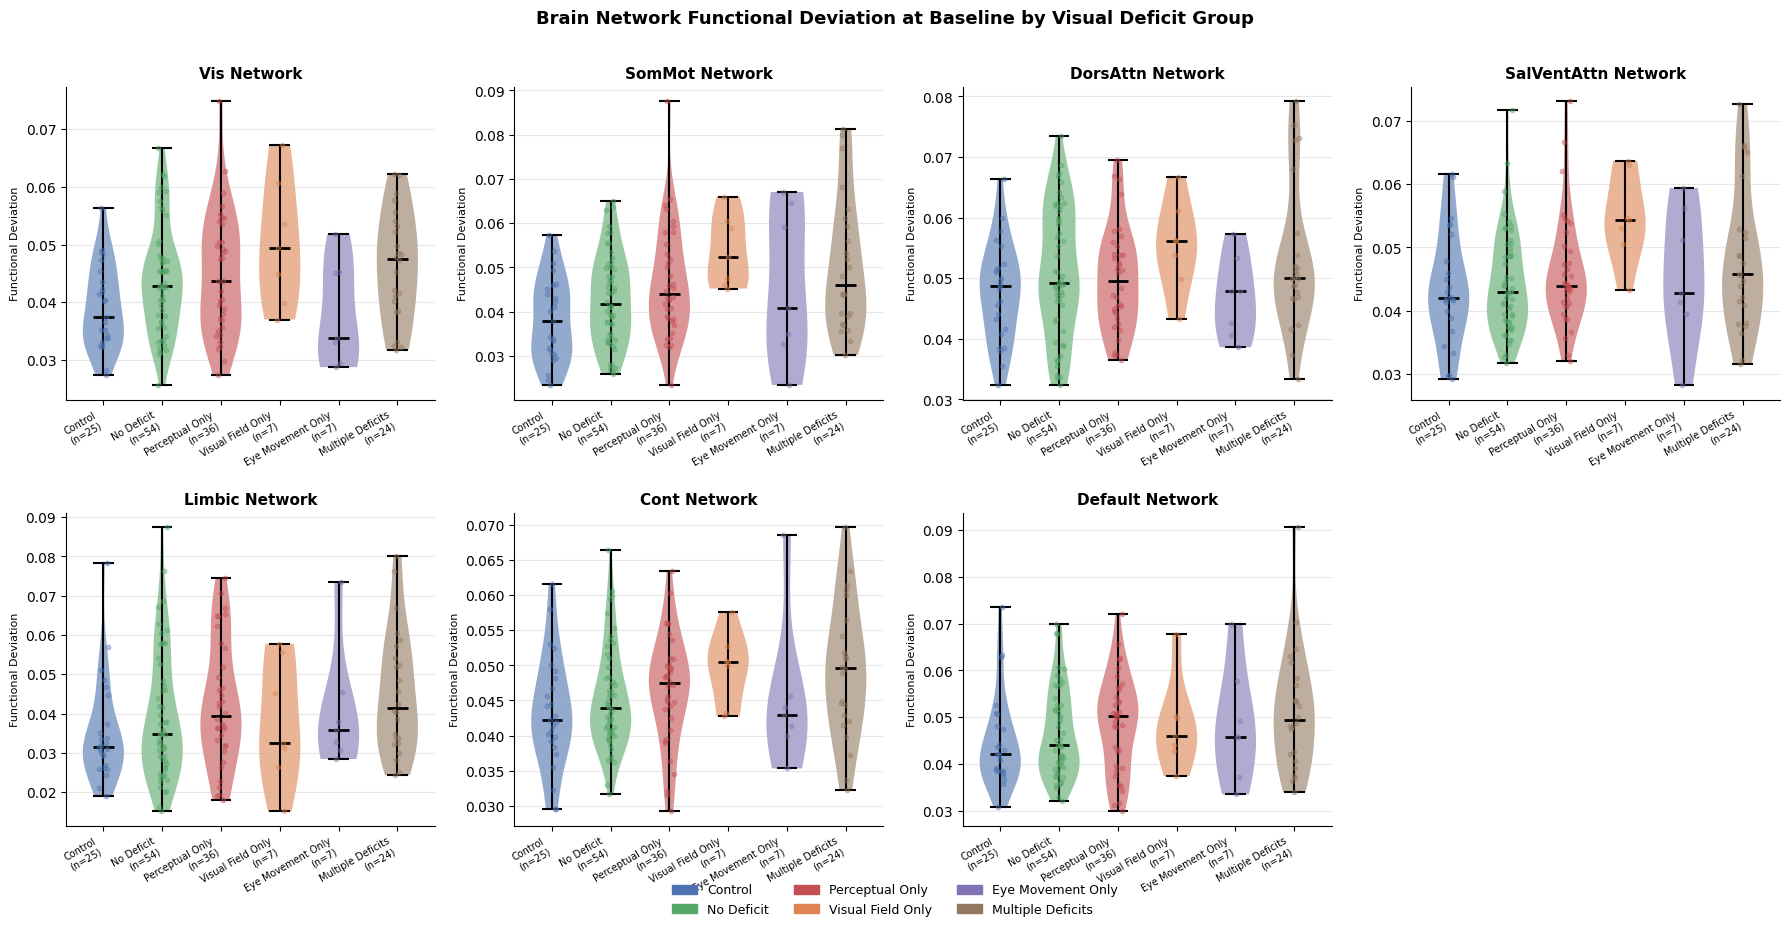

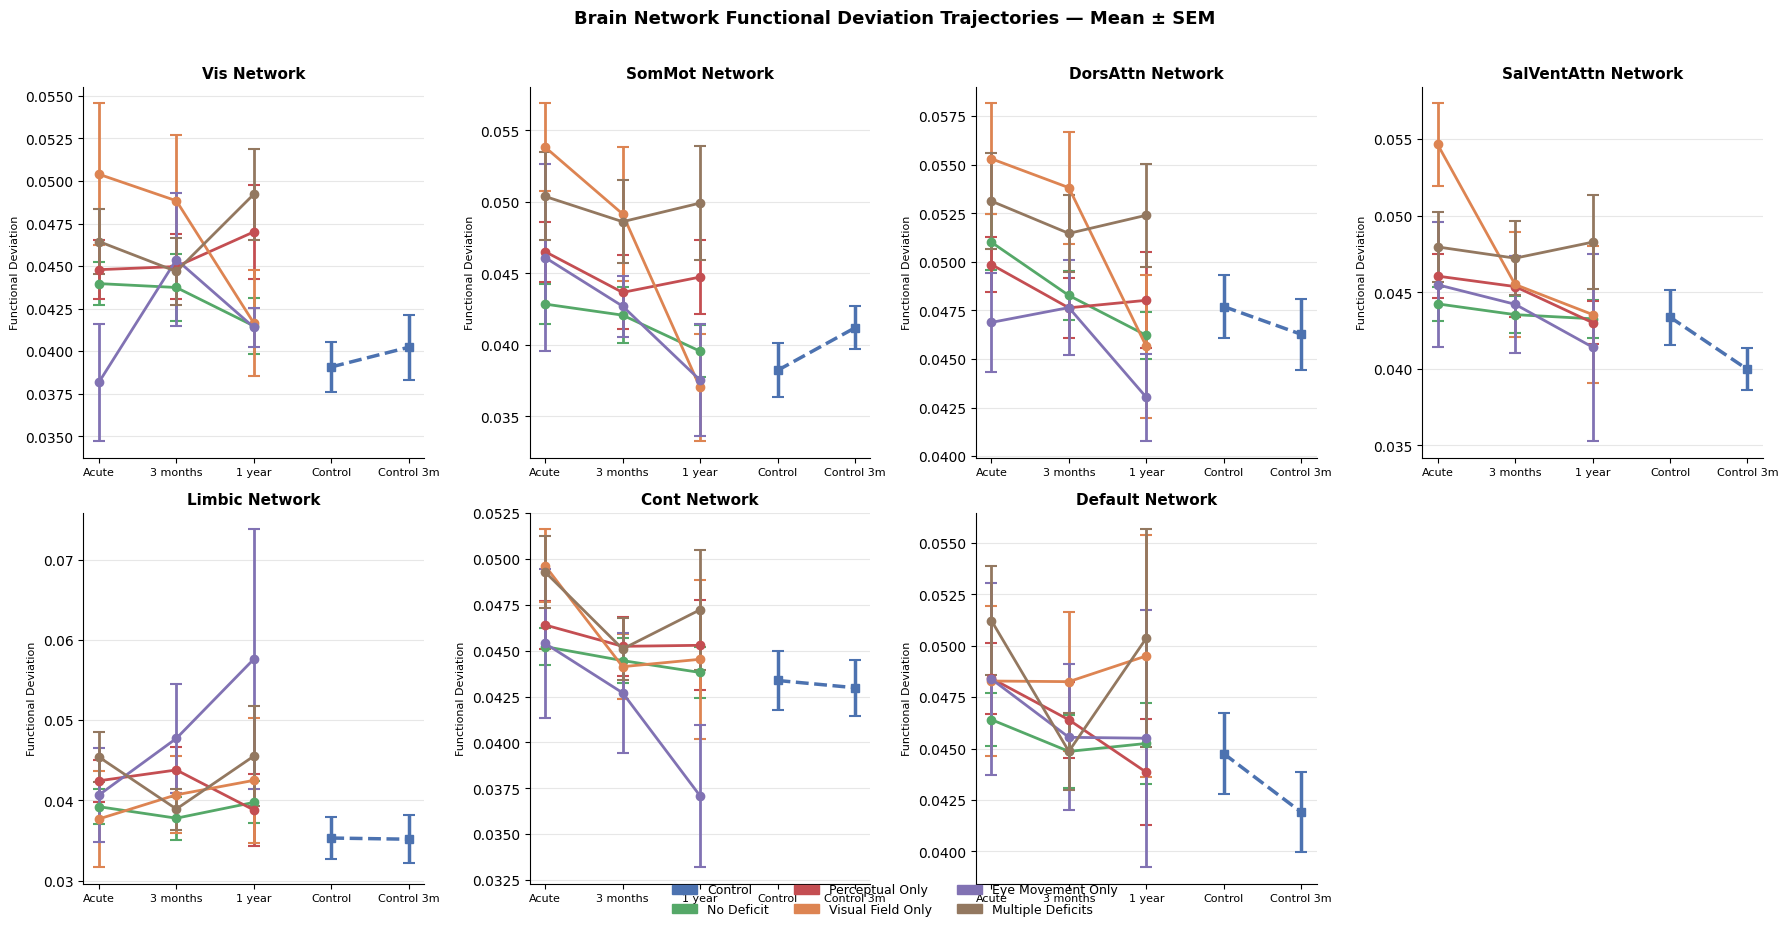

  KRUSKAL-WALLIS — BRAIN NETWORKS AT BASELINE
    feature  kw_stat  kw_pval  kw_pval_fdr  kw_sig
        Vis  12.5916   0.0275       0.0963   False
     SomMot  16.5261   0.0055       0.0384    True
   DorsAttn   5.9207   0.3140       0.3663   False
SalVentAttn  11.0565   0.0503       0.1104   False
     Limbic   8.0483   0.1536       0.2150   False
       Cont  10.4658   0.0631       0.1104   False
    Default   5.0599   0.4086       0.4086   False

SIGNIFICANT POST-HOC PAIRS (pairwise MWU, FDR<0.05):
    feature          feat_col     group1            group2  pval_fdr
     SomMot      brain_SomMot    Control   Perceptual Only    0.0379
     SomMot      brain_SomMot    Control Visual Field Only    0.0083
     SomMot      brain_SomMot    Control Multiple Deficits    0.0349
     SomMot      brain_SomMot No Deficit Visual Field Only    0.0379
SalVentAttn brain_SalVentAttn    Control Visual Field Only    0.0268
SalVentAttn brain_SalVentAttn No Deficit Visual Field Only    0.0182


  WILCO

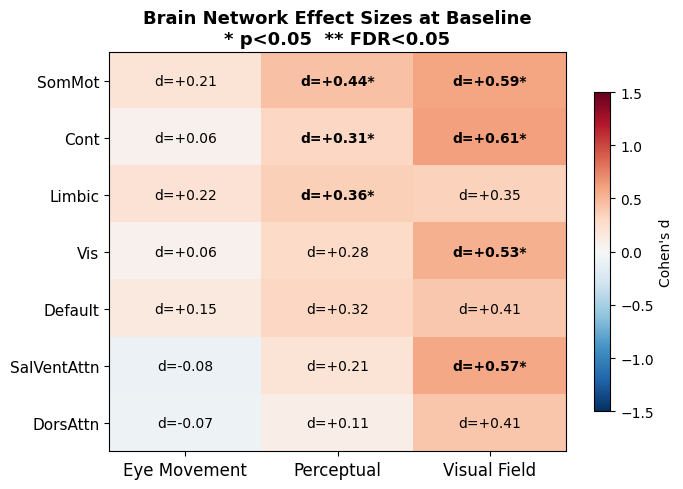


Saved: brain_kw_results.csv, brain_wilcoxon_results.csv, brain_gee_results.csv, brain_effect_sizes.csv


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.signal import welch
from statsmodels.stats.multitest import multipletests
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Gaussian
from statsmodels.genmod.cov_struct import Exchangeable
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# STEP 1: Extract 7-network features from ed_func_mean_corrected
# stroke_csv already loaded in memory
# ============================================================

# ROI-to-network mapping (1-indexed, LH+RH averaged per network)
roi_network_map = {
    **{i: "Vis"         for i in range(1,   32)},   # LH Vis 1-31
    **{i: "SomMot"      for i in range(32,  69)},   # LH SomMot 32-68
    **{i: "DorsAttn"    for i in range(69,  92)},   # LH DorsAttn 69-91
    **{i: "SalVentAttn" for i in range(92, 114)},   # LH SalVentAttn 92-113
    **{i: "Limbic"      for i in range(114,127)},   # LH Limbic 114-126
    **{i: "Cont"        for i in range(127,149)},   # LH Cont 127-148
    **{i: "Default"     for i in range(149,201)},   # LH Default 149-200
    **{i: "Vis"         for i in range(201,231)},   # RH Vis 201-230
    **{i: "SomMot"      for i in range(231,271)},   # RH SomMot 231-270
    **{i: "DorsAttn"    for i in range(271,294)},   # RH DorsAttn 271-293
    **{i: "SalVentAttn" for i in range(294,319)},   # RH SalVentAttn 294-318
    **{i: "Limbic"      for i in range(319,332)},   # RH Limbic 319-331
    **{i: "Cont"        for i in range(332,362)},   # RH Cont 332-361
    **{i: "Default"     for i in range(362,401)},   # RH Default 362-400
}

NETWORKS = ["Vis","SomMot","DorsAttn","SalVentAttn","Limbic","Cont","Default"]
NET_INDICES = {net: [i-1 for i, n in roi_network_map.items() if n == net]
               for net in NETWORKS}

rows = []
for idx, row in stroke_csv.iterrows():
    vec = row["ed_func_mean_corrected"]
    out = {"ID": row["ID"], "Session": row["Session"], "Run": row.get("Run", np.nan)}
    if isinstance(vec, float):  # NaN
        out.update({f"brain_{net}": np.nan for net in NETWORKS})
    else:
        vec = np.asarray(vec, dtype=float)
        for net in NETWORKS:
            out[f"brain_{net}"] = float(np.nanmean(vec[NET_INDICES[net]]))
    rows.append(out)

brain_features_df = pd.DataFrame(rows)
print(f"Brain features extracted: {len(brain_features_df)} rows")
print(brain_features_df[[f"brain_{n}" for n in NETWORKS]].describe().round(3))

# ============================================================
# STEP 2: Merge with deficit labels from analysis_df_clean
# ============================================================
analysis_df = pd.read_csv("analysis_df_clean.csv")
label_cols  = ["ID","plot_group","group_type","session_num",
               "has_eye_movement_deficit","has_visual_field_impairment",
               "has_perceptual_deficit","n_deficits","visual_deficit_group"]

# session_num mapping
session_order = {"control": 0, "control2": 1,
                 "acute": 0,   "followup": 1, "followup2": 2}
brain_features_df["session_num"] = brain_features_df["Session"].str.lower().map(session_order)

brain_df = brain_features_df.merge(
    analysis_df[label_cols].drop_duplicates(subset=["ID","session_num"]),
    on=["ID","session_num"], how="left"
)

print(f"\nMerged brain_df: {len(brain_df)} rows")
print(brain_df["plot_group"].value_counts())

brain_df.to_csv("brain_analysis_df.csv", index=False)

# ============================================================
# Settings
# ============================================================
BRAIN_FEATURES = [(f"brain_{net}", net) for net in NETWORKS]
# swap to (label, col) format matching ocular convention
BRAIN_FEATS = [(net, f"brain_{net}") for net in NETWORKS]

GROUP_ORDER  = ["Control","No Deficit","Perceptual Only",
                "Visual Field Only","Eye Movement Only","Multiple Deficits"]
GROUP_COLORS = {"Control":          "#4C72B0",
                "No Deficit":       "#55A868",
                "Perceptual Only":  "#C44E52",
                "Visual Field Only":"#DD8452",
                "Eye Movement Only":"#8172B3",
                "Multiple Deficits":"#937860"}
DEFICIT_VARS = [
    ("Eye Movement", "has_eye_movement_deficit"),
    ("Visual Field",  "has_visual_field_impairment"),
    ("Perceptual",    "has_perceptual_deficit"),
]
SESSION_LABELS_PAT  = {0: "Acute",   1: "3 months", 2: "1 year"}
SESSION_LABELS_CTRL = {0: "Control", 1: "Control 3m"}

# ============================================================
# STEP 3: Cross-sectional violin plots at baseline
# ============================================================
acute_brain = brain_df[
    (brain_df["session_num"] == 0) &
    (brain_df["plot_group"].isin(GROUP_ORDER))
].copy()

n_cols = 4
n_rows = int(np.ceil(len(BRAIN_FEATS) / n_cols))

fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes1 = axes1.flatten()

for i, (feat_label, feat_col) in enumerate(BRAIN_FEATS):
    ax = axes1[i]
    data_per_group, labels, colors = [], [], []
    for g in GROUP_ORDER:
        vals = acute_brain[acute_brain["plot_group"] == g][feat_col].dropna().values
        if len(vals) < 3:
            continue
        data_per_group.append(vals)
        labels.append(f"{g}\n(n={len(vals)})")
        colors.append(GROUP_COLORS[g])

    parts = ax.violinplot(data_per_group, showmedians=True,
                          showextrema=True, widths=0.7)
    for pc, color in zip(parts["bodies"], colors):
        pc.set_facecolor(color); pc.set_alpha(0.6)
    parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(2)
    for key in ["cbars","cmaxes","cmins"]:
        parts[key].set_color("black")
    for j, (vals, color) in enumerate(zip(data_per_group, colors)):
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(np.full(len(vals), j+1) + jitter, vals,
                   color=color, alpha=0.4, s=10, zorder=3)

    ax.set_xticks(range(1, len(labels)+1))
    ax.set_xticklabels(labels, fontsize=7, rotation=30, ha="right")
    ax.set_title(f"{feat_label} Network", fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)
    ax.set_ylabel("Functional Deviation", fontsize=8)

for j in range(len(BRAIN_FEATS), len(axes1)):
    axes1[j].set_visible(False)

patches = [mpatches.Patch(color=GROUP_COLORS[g], label=g) for g in GROUP_ORDER]
fig1.legend(handles=patches, loc="lower center", ncol=3, fontsize=9,
            frameon=False, bbox_to_anchor=(0.5, -0.01))
fig1.suptitle("Brain Network Functional Deviation at Baseline by Visual Deficit Group",
              fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 4: Trajectory plots
# ============================================================
pat_brain  = brain_df[brain_df["group_type"] == "patient"].copy()
ctrl_brain = brain_df[brain_df["group_type"] == "control"].copy()
ctrl_brain["plot_group"] = "Control"

def group_mean_sem(df, feat_col, group_col, session_col):
    return (df.groupby([group_col, session_col])[feat_col]
              .agg(mean="mean", sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)))
              .reset_index())

fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes2 = axes2.flatten()

for i, (feat_label, feat_col) in enumerate(BRAIN_FEATS):
    ax = axes2[i]
    stats_pat = group_mean_sem(pat_brain, feat_col, "plot_group", "session_num")
    for g in [g for g in GROUP_ORDER if g != "Control"]:
        gdf = stats_pat[stats_pat["plot_group"] == g].sort_values("session_num")
        if len(gdf) == 0: continue
        xlabels = [SESSION_LABELS_PAT[s] for s in gdf["session_num"]]
        ax.errorbar(xlabels, gdf["mean"], yerr=gdf["sem"],
                    label=g, color=GROUP_COLORS[g],
                    marker="o", linewidth=2, markersize=6,
                    capsize=4, capthick=1.5)

    stats_ctrl = group_mean_sem(ctrl_brain, feat_col, "plot_group", "session_num")
    gdf_c = stats_ctrl.sort_values("session_num")
    if len(gdf_c) > 0:
        xlabels_c = [SESSION_LABELS_CTRL[s] for s in gdf_c["session_num"]]
        ax.errorbar(xlabels_c, gdf_c["mean"], yerr=gdf_c["sem"],
                    label="Control", color=GROUP_COLORS["Control"],
                    marker="s", linewidth=2.5, markersize=6,
                    linestyle="--", capsize=4, capthick=1.5)

    ax.set_title(f"{feat_label} Network", fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", labelsize=8)
    ax.set_ylabel("Functional Deviation", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

for j in range(len(BRAIN_FEATS), len(axes2)):
    axes2[j].set_visible(False)

patches = [mpatches.Patch(color=GROUP_COLORS[g], label=g) for g in GROUP_ORDER]
fig2.legend(handles=patches, loc="lower center", ncol=3, fontsize=9,
            frameon=False, bbox_to_anchor=(0.5, -0.01))
fig2.suptitle("Brain Network Functional Deviation Trajectories — Mean ± SEM",
              fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 5: Kruskal-Wallis at baseline + Wilcoxon trajectories
# ============================================================
kw_results, posthoc_results, wilcox_results = [], [], []

for feat_label, feat_col in BRAIN_FEATS:
    # --- KW ---
    groups_data = {g: acute_brain[acute_brain["plot_group"] == g][feat_col].dropna().values
                   for g in GROUP_ORDER}
    groups_data = {g: v for g, v in groups_data.items() if len(v) >= 3}
    if len(groups_data) >= 2:
        stat, pval = stats.kruskal(*groups_data.values())
        kw_results.append({"feature": feat_label, "feat_col": feat_col,
                            "kw_stat": stat, "kw_pval": pval})
        # Pairwise MWU post-hoc
        from itertools import combinations
        pairs = list(combinations(groups_data.keys(), 2))
        pair_pvals = [stats.mannwhitneyu(groups_data[g1], groups_data[g2],
                                         alternative="two-sided")[1]
                      for g1, g2 in pairs]
        _, pair_fdr, _, _ = multipletests(pair_pvals, method="fdr_bh")
        for (g1, g2), p in zip(pairs, pair_fdr):
            posthoc_results.append({"feature": feat_label, "feat_col": feat_col,
                                     "group1": g1, "group2": g2, "pval_fdr": p})

    # --- Wilcoxon ---
    for group in [g for g in GROUP_ORDER if g != "Control"]:
        gdf = pat_brain[pat_brain["plot_group"] == group][
            ["ID","session_num",feat_col]].dropna()
        for comp_label, t0, t1 in [("Acute → 3 months",0,1),("Acute → 1 year",0,2)]:
            df0 = gdf[gdf["session_num"]==t0].set_index("ID")[feat_col]
            df1 = gdf[gdf["session_num"]==t1].set_index("ID")[feat_col]
            common = df0.index.intersection(df1.index)
            if len(common) < 5: continue
            v0, v1 = df0.loc[common].values, df1.loc[common].values
            stat, pval = stats.wilcoxon(v0, v1, alternative="two-sided")
            wilcox_results.append({
                "feature": feat_label, "feat_col": feat_col,
                "group": group, "comparison": comp_label,
                "n_pairs": len(common),
                "mean_t0": v0.mean(), "mean_t1": v1.mean(),
                "delta": v1.mean()-v0.mean(), "pval": pval
            })

kw_df      = pd.DataFrame(kw_results)
posthoc_df = pd.DataFrame(posthoc_results)
wilcox_df  = pd.DataFrame(wilcox_results)

_, kw_fdr, _, _ = multipletests(kw_df["kw_pval"].values, method="fdr_bh")
kw_df["kw_pval_fdr"] = kw_fdr
kw_df["kw_sig"] = kw_df["kw_pval_fdr"] < 0.05

_, wfdr, _, _ = multipletests(wilcox_df["pval"].values, method="fdr_bh")
wilcox_df["pval_fdr"] = wfdr
wilcox_df["sig_fdr"] = wilcox_df["pval_fdr"] < 0.05
wilcox_df["sig_nom"] = wilcox_df["pval"] < 0.05

print("=" * 70)
print("  KRUSKAL-WALLIS — BRAIN NETWORKS AT BASELINE")
print("=" * 70)
print(kw_df[["feature","kw_stat","kw_pval","kw_pval_fdr","kw_sig"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\nSIGNIFICANT POST-HOC PAIRS (pairwise MWU, FDR<0.05):")
sig_ph = posthoc_df[posthoc_df["pval_fdr"] < 0.05]
print(sig_ph.to_string(index=False, float_format=lambda x: f"{x:.4f}") if len(sig_ph) else "  None")

print("\n\n" + "=" * 70)
print("  WILCOXON — BRAIN NETWORK CHANGE OVER TIME")
print("=" * 70)
print("\nFDR-SIGNIFICANT:")
sig_w = wilcox_df[wilcox_df["sig_fdr"]].sort_values("pval_fdr")
print(sig_w[["feature","group","comparison","n_pairs","mean_t0","mean_t1","delta","pval","pval_fdr"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}") if len(sig_w) else "  None")

print("\nNOMINALLY SIGNIFICANT (p<0.05):")
nom_w = wilcox_df[wilcox_df["sig_nom"]].sort_values("pval")
print(nom_w[["feature","group","comparison","n_pairs","mean_t0","mean_t1","delta","pval","pval_fdr"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ============================================================
# STEP 6: GEE focused models (one deficit at a time)
# ============================================================
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Gaussian
from statsmodels.genmod.cov_struct import Exchangeable

pat_brain_sorted = pat_brain.sort_values(["ID","session_num"]).reset_index(drop=True)
for _, dv in DEFICIT_VARS:
    pat_brain_sorted[dv] = pat_brain_sorted[dv].astype(float)

gee_results = []
for feat_label, feat_col in BRAIN_FEATS:
    for deficit_name, deficit_var in DEFICIT_VARS:
        df_sub = pat_brain_sorted[["ID",feat_col,"session_num",deficit_var]].dropna()
        counts = df_sub.groupby("ID").size()
        df_sub = df_sub[df_sub["ID"].isin(counts[counts >= 2].index)]
        if len(df_sub) < 30: continue
        formula = f"{feat_col} ~ session_num + {deficit_var} + session_num:{deficit_var}"
        try:
            model  = GEE.from_formula(formula, groups="ID", data=df_sub,
                                       family=Gaussian(), cov_struct=Exchangeable())
            result = model.fit()
            for term in result.params.index:
                if term == "Intercept": continue
                gee_results.append({
                    "feature": feat_label, "feat_col": feat_col,
                    "deficit": deficit_name, "term": term,
                    "coef": result.params[term],
                    "se":   result.bse[term],
                    "pval": result.pvalues[term],
                })
        except Exception as e:
            print(f"  GEE failed: {feat_label} × {deficit_name} — {e}")

gee_df = pd.DataFrame(gee_results)

def label_term(row):
    if "session_num:" in row["term"] or ":session_num" in row["term"]:
        return f"Time × {row['deficit']}"
    elif row["term"] == "session_num":
        return "Time"
    return row["deficit"]

gee_df["term_label"] = gee_df.apply(label_term, axis=1)
gee_df["term_type"]  = gee_df["term_label"].apply(
    lambda x: "interaction" if "×" in x else ("time_main" if x=="Time" else "deficit_main"))

for tt in ["interaction","deficit_main","time_main"]:
    mask = gee_df["term_type"] == tt
    if mask.sum() == 0: continue
    _, fdr, _, _ = multipletests(gee_df.loc[mask,"pval"].values, method="fdr_bh")
    gee_df.loc[mask,"pval_fdr"] = fdr

gee_df["sig_fdr"] = gee_df["pval_fdr"] < 0.05
gee_df["sig_nom"] = gee_df["pval"] < 0.05

print("\n\n" + "=" * 80)
print("  GEE FOCUSED MODELS — BRAIN NETWORKS")
print("=" * 80)
print("\nFDR-SIGNIFICANT:")
sig_g = gee_df[gee_df["sig_fdr"]].sort_values("pval_fdr")
print(sig_g[["feature","deficit","term_label","coef","se","pval","pval_fdr"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}") if len(sig_g) else "  None")

print("\nNOMINALLY SIGNIFICANT (p<0.05):")
nom_g = gee_df[gee_df["sig_nom"]].sort_values("pval")
print(nom_g[["feature","deficit","term_label","coef","se","pval","pval_fdr"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ============================================================
# STEP 7: Cohen's d at baseline
# ============================================================
d_rows = []
for feat_label, feat_col in BRAIN_FEATS:
    for deficit_name, deficit_var in DEFICIT_VARS:
        g1 = acute_brain[acute_brain[deficit_var] == 1][feat_col].dropna()
        g0 = acute_brain[acute_brain[deficit_var] == 0][feat_col].dropna()
        if len(g1) < 3 or len(g0) < 3: continue
        pooled_sd = np.sqrt(((len(g1)-1)*g1.var(ddof=1) + (len(g0)-1)*g0.var(ddof=1))
                            / (len(g1)+len(g0)-2))
        d = (g1.mean()-g0.mean()) / pooled_sd if pooled_sd > 0 else np.nan
        stat, pval = stats.mannwhitneyu(g1, g0, alternative="two-sided")
        d_rows.append({"feature": feat_label, "feat_col": feat_col,
                        "deficit": deficit_name, "n_deficit": len(g1),
                        "n_no_deficit": len(g0),
                        "mean_deficit": g1.mean(), "mean_no_deficit": g0.mean(),
                        "cohens_d": d, "abs_d": abs(d), "mwu_pval": pval})

d_df = pd.DataFrame(d_rows)
_, dfdr, _, _ = multipletests(d_df["mwu_pval"].values, method="fdr_bh")
d_df["mwu_pval_fdr"] = dfdr
d_df["sig_fdr"] = d_df["mwu_pval_fdr"] < 0.05
d_df["sig_nom"] = d_df["mwu_pval"] < 0.05

print("\n\n" + "=" * 80)
print("  COHEN'S d — BRAIN NETWORKS AT BASELINE")
print("=" * 80)
print(f"\n{'Feature':<15} {'Deficit':<15} {'n+':<5} {'n-':<5} "
      f"{'d':>7} {'|d|':>6} {'p_raw':>8} {'p_FDR':>8} {'Sig':>5}")
print("-" * 80)
for _, row in d_df.sort_values(["deficit","abs_d"], ascending=[True,False]).iterrows():
    sig = "***" if row["sig_fdr"] else ("*" if row["sig_nom"] else "")
    print(f"{row['feature']:<15} {row['deficit']:<15} {int(row['n_deficit']):<5} "
          f"{int(row['n_no_deficit']):<5} {row['cohens_d']:>7.3f} {row['abs_d']:>6.3f} "
          f"{row['mwu_pval']:>8.4f} {row['mwu_pval_fdr']:>8.4f} {sig:>5}")

# ============================================================
# Cohen's d heatmap
# ============================================================
pivot_d   = d_df.pivot(index="feature", columns="deficit", values="cohens_d")
pivot_sig = d_df.pivot(index="feature", columns="deficit", values="sig_nom")
pivot_fdr = d_df.pivot(index="feature", columns="deficit", values="sig_fdr")

row_order = pivot_d.abs().mean(axis=1).sort_values(ascending=False).index
pivot_d, pivot_sig, pivot_fdr = (p.loc[row_order]
                                  for p in [pivot_d, pivot_sig, pivot_fdr])

fig3, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot_d.values, cmap="RdBu_r", aspect="auto", vmin=-1.5, vmax=1.5)
ax.set_xticks(range(len(pivot_d.columns)))
ax.set_xticklabels(pivot_d.columns, fontsize=12)
ax.set_yticks(range(len(pivot_d.index)))
ax.set_yticklabels(pivot_d.index, fontsize=11)
for i, feat in enumerate(pivot_d.index):
    for j, deficit in enumerate(pivot_d.columns):
        d_val = pivot_d.loc[feat, deficit]
        if pd.isna(d_val): continue
        star = "**" if pivot_fdr.loc[feat, deficit] else \
               ("*" if pivot_sig.loc[feat, deficit] else "")
        txt_color = "white" if abs(d_val) > 0.9 else "black"
        ax.text(j, i, f"d={d_val:+.2f}{star}", ha="center", va="center",
                fontsize=10, color=txt_color,
                fontweight="bold" if pivot_sig.loc[feat, deficit] else "normal")
plt.colorbar(im, ax=ax, label="Cohen's d", shrink=0.8)
ax.set_title("Brain Network Effect Sizes at Baseline\n* p<0.05  ** FDR<0.05",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Save all results
kw_df.to_csv("brain_kw_results.csv", index=False)
wilcox_df.to_csv("brain_wilcoxon_results.csv", index=False)
gee_df.to_csv("brain_gee_results.csv", index=False)
d_df.to_csv("brain_effect_sizes.csv", index=False)
print("\nSaved: brain_kw_results.csv, brain_wilcoxon_results.csv, "
      "brain_gee_results.csv, brain_effect_sizes.csv")


Clinical variables at acute:
       nih_total  lesion_size
count    110.000      116.000
mean       4.009     4302.810
std        4.336     6072.021
min        0.000       13.000
25%        1.000      415.000
50%        2.000     2513.500
75%        6.750     5928.750
max       16.000    34627.000

NaN counts — nih_total: 29, lesion_size: 23

Unified acute dataset: 128 subjects
Columns: ['ID', 'PCA_L_sd', 'PCA_R_sd', 'PCA_LR_corr', 'PCA_sd_asym', 'PCA_L_mssd', 'PCA_R_mssd', 'PCA_L_ac1', 'PCA_R_ac1', 'PCA_L_spec_entropy', 'PCA_R_spec_entropy', 'corr_PCA_MVPA_L', 'MVPA_L_sd', 'brain_Vis', 'brain_SomMot', 'brain_DorsAttn', 'brain_SalVentAttn', 'brain_Limbic', 'brain_Cont', 'brain_Default', 'nih_total', 'lesion_size']

  OPTION A — OCULAR × BRAIN NETWORK CORRELATIONS (Spearman)

FDR-SIGNIFICANT (p_fdr < 0.05):
  None

NOMINALLY SIGNIFICANT (p < 0.05):
           ocular       brain       r   pval  pval_fdr
     PCA Left AC1 SalVentAttn  0.2792 0.0014    0.0909
 PCA Left SpecEnt SalVentAttn 

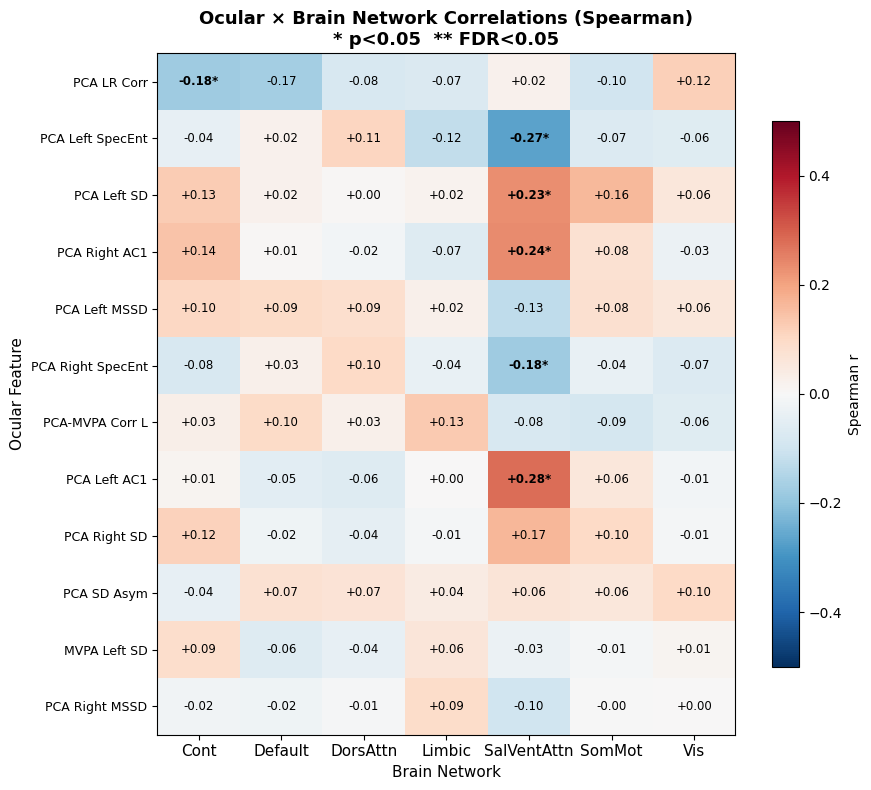



  OPTION B — CLINICAL CORRELATIONS (Spearman)
  Variables: nih_total, lesion_size

--- nih_total ---
Feature                Type           r    p_raw    p_FDR   Sig
------------------------------------------------------------
MVPA Left SD           ocular     0.305   0.0021   0.0267   ***
PCA Left SD            ocular     0.216   0.0317   0.1094     *
PCA Right SD           ocular     0.209   0.0375   0.1188     *
Cont                   brain      0.200   0.0476   0.1292     *
SomMot                 brain      0.165   0.1016   0.2575      
PCA Right SpecEnt      ocular    -0.151   0.1366   0.3053      
PCA Left SpecEnt       ocular    -0.139   0.1706   0.3601      
PCA Right AC1          ocular     0.122   0.2290   0.4579      
DorsAttn               brain      0.116   0.2520   0.4787      
PCA Left AC1           ocular     0.112   0.2683   0.4854      
PCA Left MSSD          ocular     0.105   0.3001   0.4958      
PCA Right MSSD         ocular     0.085   0.4033   0.6131      
Limb

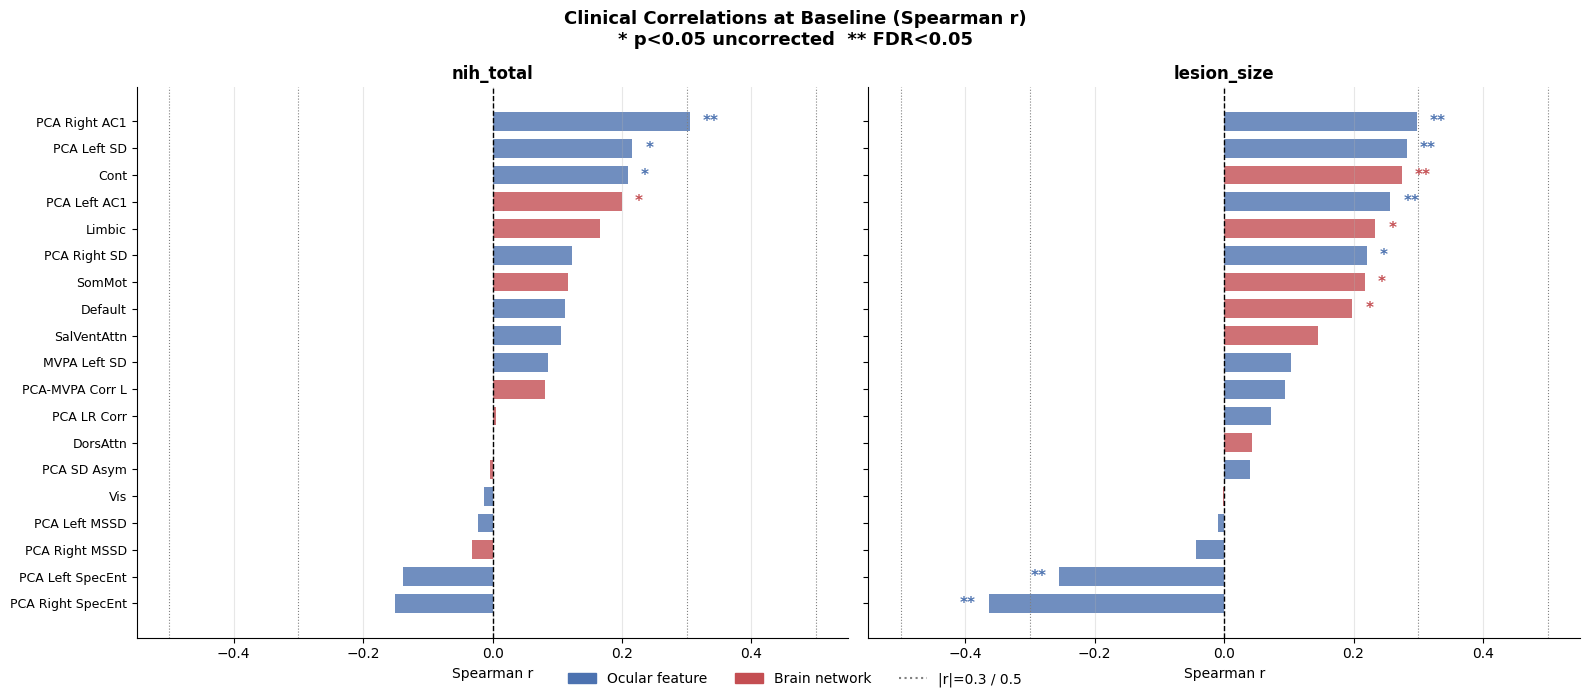

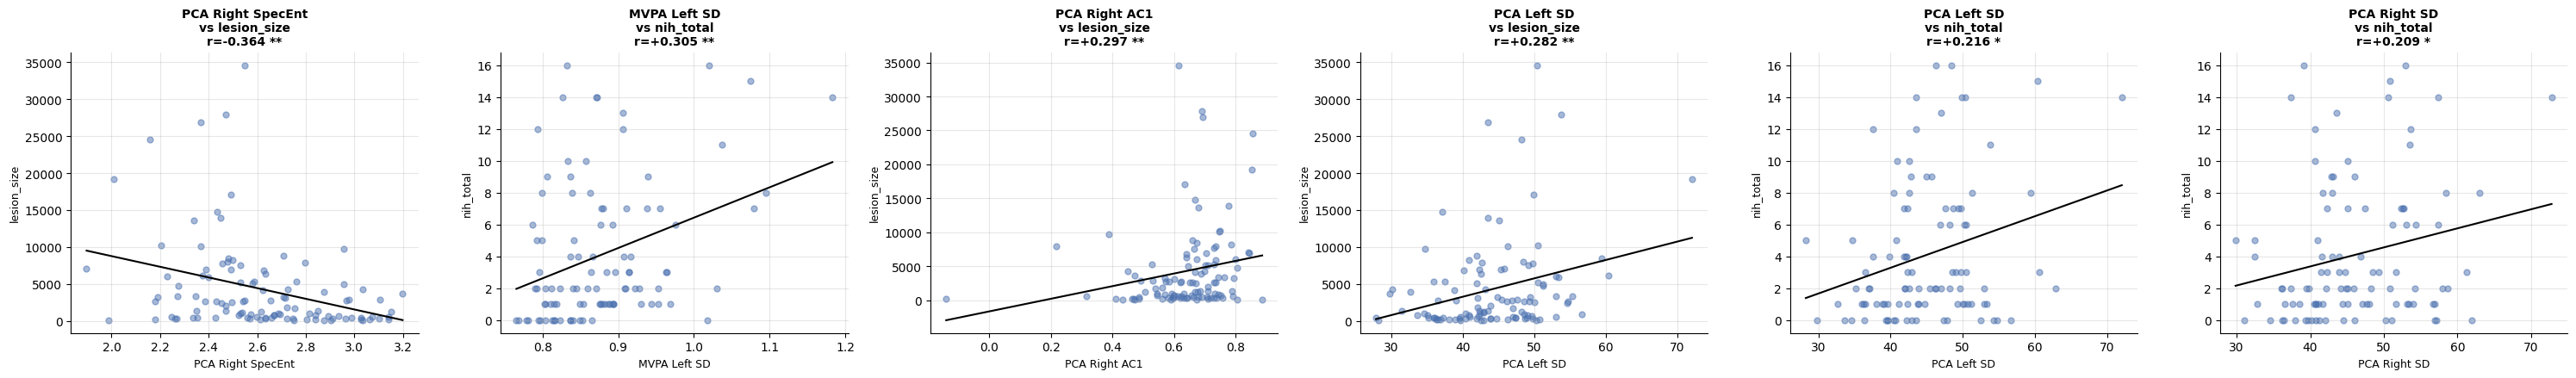


Saved: optionA_ocular_brain_correlations.csv, optionB_clinical_correlations.csv


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Load data
# ============================================================
analysis_df = pd.read_csv("analysis_df_clean.csv")
brain_df    = pd.read_csv("brain_analysis_df.csv")

# Get nih_total and lesion_size from stroke_csv (already in memory)
# Take acute session values per patient
clinical = stroke_csv[stroke_csv["Session"].str.lower() == "acute"][
    ["ID","nih_total","lesion_size"]
].drop_duplicates(subset="ID").copy()

print("Clinical variables at acute:")
print(clinical[["nih_total","lesion_size"]].describe().round(3))
print(f"\nNaN counts — nih_total: {clinical['nih_total'].isna().sum()}, "
      f"lesion_size: {clinical['lesion_size'].isna().sum()}")

# ============================================================
# Build a unified acute-session dataframe
# (one row per subject, ocular + brain + clinical + labels)
# ============================================================
OCULAR_COLS = ["PCA_L_sd","PCA_R_sd","PCA_LR_corr","PCA_sd_asym",
               "PCA_L_mssd","PCA_R_mssd","PCA_L_ac1","PCA_R_ac1",
               "PCA_L_spec_entropy","PCA_R_spec_entropy",
               "corr_PCA_MVPA_L","MVPA_L_sd"]
BRAIN_COLS  = [f"brain_{net}" for net in
               ["Vis","SomMot","DorsAttn","SalVentAttn","Limbic","Cont","Default"]]

OCULAR_LABELS = {
    "PCA_L_sd":          "PCA Left SD",
    "PCA_R_sd":          "PCA Right SD",
    "PCA_LR_corr":       "PCA LR Corr",
    "PCA_sd_asym":       "PCA SD Asym",
    "PCA_L_mssd":        "PCA Left MSSD",
    "PCA_R_mssd":        "PCA Right MSSD",
    "PCA_L_ac1":         "PCA Left AC1",
    "PCA_R_ac1":         "PCA Right AC1",
    "PCA_L_spec_entropy":"PCA Left SpecEnt",
    "PCA_R_spec_entropy":"PCA Right SpecEnt",
    "corr_PCA_MVPA_L":   "PCA-MVPA Corr L",
    "MVPA_L_sd":         "MVPA Left SD",
}
BRAIN_LABELS = {f"brain_{n}": n for n in
                ["Vis","SomMot","DorsAttn","SalVentAttn","Limbic","Cont","Default"]}

# Merge ocular (acute patients)
acute_ocular = analysis_df[
    (analysis_df["group_type"] == "patient") &
    (analysis_df["session_num"] == 0)
][["ID"] + OCULAR_COLS].copy()

# Merge brain (acute patients)
acute_brain = brain_df[
    (brain_df["group_type"] == "patient") &
    (brain_df["session_num"] == 0)
][["ID"] + BRAIN_COLS].copy()

# Build unified table
unified = (acute_ocular
           .merge(acute_brain, on="ID", how="inner")
           .merge(clinical,    on="ID", how="left"))

print(f"\nUnified acute dataset: {len(unified)} subjects")
print(f"Columns: {list(unified.columns)}")

# ============================================================
# OPTION A: Ocular ↔ Brain correlations
# Spearman r for all ocular × brain pairs
# ============================================================
print("\n" + "=" * 70)
print("  OPTION A — OCULAR × BRAIN NETWORK CORRELATIONS (Spearman)")
print("=" * 70)

corr_rows = []
for ocol in OCULAR_COLS:
    for bcol in BRAIN_COLS:
        mask = unified[[ocol, bcol]].notna().all(axis=1)
        if mask.sum() < 10:
            continue
        r, p = stats.spearmanr(unified.loc[mask, ocol],
                                unified.loc[mask, bcol])
        corr_rows.append({
            "ocular":   OCULAR_LABELS[ocol],
            "ocol":     ocol,
            "brain":    BRAIN_LABELS[bcol],
            "bcol":     bcol,
            "r":        r,
            "abs_r":    abs(r),
            "pval":     p,
        })

corr_df = pd.DataFrame(corr_rows)
_, cfdr, _, _ = multipletests(corr_df["pval"].values, method="fdr_bh")
corr_df["pval_fdr"] = cfdr
corr_df["sig_fdr"]  = corr_df["pval_fdr"] < 0.05
corr_df["sig_nom"]  = corr_df["pval"] < 0.05

print("\nFDR-SIGNIFICANT (p_fdr < 0.05):")
sig_c = corr_df[corr_df["sig_fdr"]].sort_values("pval_fdr")
print(sig_c[["ocular","brain","r","pval","pval_fdr"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}") if len(sig_c) else "  None")

print("\nNOMINALLY SIGNIFICANT (p < 0.05):")
nom_c = corr_df[corr_df["sig_nom"]].sort_values("pval")
print(nom_c[["ocular","brain","r","pval","pval_fdr"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

corr_df.to_csv("optionA_ocular_brain_correlations.csv", index=False)

# Heatmap: r values (ocular × brain)
pivot_r   = corr_df.pivot(index="ocular", columns="brain", values="r")
pivot_sig = corr_df.pivot(index="ocular", columns="brain", values="sig_nom")
pivot_fdr = corr_df.pivot(index="ocular", columns="brain", values="sig_fdr")

# Sort rows by mean absolute r
row_order = pivot_r.abs().mean(axis=1).sort_values(ascending=False).index
pivot_r   = pivot_r.loc[row_order]
pivot_sig = pivot_sig.loc[row_order]
pivot_fdr = pivot_fdr.loc[row_order]

fig1, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(pivot_r.values, cmap="RdBu_r", aspect="auto", vmin=-0.5, vmax=0.5)
ax.set_xticks(range(len(pivot_r.columns)))
ax.set_xticklabels(pivot_r.columns, fontsize=11)
ax.set_yticks(range(len(pivot_r.index)))
ax.set_yticklabels(pivot_r.index, fontsize=9)

for i, olab in enumerate(pivot_r.index):
    for j, blab in enumerate(pivot_r.columns):
        r_val = pivot_r.loc[olab, blab]
        if pd.isna(r_val): continue
        star = "**" if pivot_fdr.loc[olab, blab] else \
               ("*" if pivot_sig.loc[olab, blab] else "")
        txt_color = "white" if abs(r_val) > 0.3 else "black"
        ax.text(j, i, f"{r_val:+.2f}{star}", ha="center", va="center",
                fontsize=8.5, color=txt_color,
                fontweight="bold" if pivot_sig.loc[olab, blab] else "normal")

plt.colorbar(im, ax=ax, label="Spearman r", shrink=0.8)
ax.set_title("Ocular × Brain Network Correlations (Spearman)\n* p<0.05  ** FDR<0.05",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Brain Network", fontsize=11)
ax.set_ylabel("Ocular Feature", fontsize=11)
plt.tight_layout()
plt.show()

# ============================================================
# OPTION B: Clinical correlates — nih_total and lesion_size
# Spearman r with all ocular + brain features
# ============================================================
print("\n\n" + "=" * 70)
print("  OPTION B — CLINICAL CORRELATIONS (Spearman)")
print("  Variables: nih_total, lesion_size")
print("=" * 70)

CLINICAL_VARS = ["nih_total", "lesion_size"]
ALL_FEATURES  = [(OCULAR_LABELS[c], c) for c in OCULAR_COLS] + \
                [(BRAIN_LABELS[c], c) for c in BRAIN_COLS]

clin_rows = []
for clin_var in CLINICAL_VARS:
    for feat_label, feat_col in ALL_FEATURES:
        mask = unified[[feat_col, clin_var]].notna().all(axis=1)
        if mask.sum() < 10:
            continue
        r, p = stats.spearmanr(unified.loc[mask, feat_col],
                                unified.loc[mask, clin_var])
        clin_rows.append({
            "clinical":    clin_var,
            "feature":     feat_label,
            "feat_col":    feat_col,
            "feat_type":   "ocular" if feat_col in OCULAR_COLS else "brain",
            "r":           r,
            "abs_r":       abs(r),
            "pval":        p,
            "n":           mask.sum(),
        })

clin_df = pd.DataFrame(clin_rows)
_, clfdr, _, _ = multipletests(clin_df["pval"].values, method="fdr_bh")
clin_df["pval_fdr"] = clfdr
clin_df["sig_fdr"]  = clin_df["pval_fdr"] < 0.05
clin_df["sig_nom"]  = clin_df["pval"] < 0.05

for cvar in CLINICAL_VARS:
    print(f"\n--- {cvar} ---")
    sub = clin_df[clin_df["clinical"] == cvar].sort_values("abs_r", ascending=False)
    print(f"{'Feature':<22} {'Type':<8} {'r':>7} {'p_raw':>8} {'p_FDR':>8} {'Sig':>5}")
    print("-" * 60)
    for _, row in sub.iterrows():
        sig = "***" if row["sig_fdr"] else ("*" if row["sig_nom"] else "")
        print(f"{row['feature']:<22} {row['feat_type']:<8} "
              f"{row['r']:>7.3f} {row['pval']:>8.4f} "
              f"{row['pval_fdr']:>8.4f} {sig:>5}")

clin_df.to_csv("optionB_clinical_correlations.csv", index=False)

# ============================================================
# PLOT B1: Bar chart of Spearman r by clinical variable
# ============================================================
fig2, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
FEAT_COLORS = {"ocular": "#4C72B0", "brain": "#C44E52"}

for ax, cvar in zip(axes, CLINICAL_VARS):
    sub = clin_df[clin_df["clinical"] == cvar].sort_values("r")
    colors = [FEAT_COLORS[t] for t in sub["feat_type"]]
    y_pos = range(len(sub))
    ax.barh(list(y_pos), sub["r"], color=colors, height=0.7, alpha=0.8)
    ax.axvline(0,    color="black", linewidth=1,   linestyle="--")
    ax.axvline(0.3,  color="gray",  linewidth=0.8, linestyle=":")
    ax.axvline(-0.3, color="gray",  linewidth=0.8, linestyle=":")
    ax.axvline(0.5,  color="gray",  linewidth=0.8, linestyle=":")
    ax.axvline(-0.5, color="gray",  linewidth=0.8, linestyle=":")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(sub["feature"], fontsize=9)
    ax.set_title(cvar, fontsize=12, fontweight="bold")
    ax.set_xlabel("Spearman r", fontsize=10)
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

    for i, (_, row) in enumerate(sub.iterrows()):
        star = "**" if row["sig_fdr"] else ("*" if row["sig_nom"] else "")
        if star:
            x_offset = 0.02 if row["r"] >= 0 else -0.02
            ha = "left" if row["r"] >= 0 else "right"
            ax.text(row["r"] + x_offset, i, star, va="center",
                    fontsize=11, fontweight="bold",
                    color=FEAT_COLORS[row["feat_type"]], ha=ha)

patches = [mpatches.Patch(color=FEAT_COLORS["ocular"], label="Ocular feature"),
           mpatches.Patch(color=FEAT_COLORS["brain"],  label="Brain network"),
           plt.Line2D([0],[0], color="gray", linestyle=":", label="|r|=0.3 / 0.5")]
fig2.legend(handles=patches, loc="lower center", ncol=3,
            fontsize=10, frameon=False)
fig2.suptitle("Clinical Correlations at Baseline (Spearman r)\n"
              "* p<0.05 uncorrected  ** FDR<0.05",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ============================================================
# PLOT B2: Scatter plots for strongest correlations
# ============================================================
# Find top 3 features per clinical variable by |r|
top_pairs = (clin_df[clin_df["sig_nom"]]
             .sort_values("abs_r", ascending=False)
             .groupby("clinical").head(3))

if len(top_pairs) > 0:
    n_scatter = len(top_pairs)
    fig3, axes3 = plt.subplots(1, n_scatter, figsize=(5 * n_scatter, 4.5))
    if n_scatter == 1:
        axes3 = [axes3]

    for ax, (_, row) in zip(axes3, top_pairs.iterrows()):
        x = unified[row["feat_col"]].values
        y = unified[row["clinical"]].values
        mask = ~(np.isnan(x) | np.isnan(y))
        ax.scatter(x[mask], y[mask], alpha=0.5, s=25,
                   color=FEAT_COLORS[row["feat_type"]])
        # Regression line
        m, b = np.polyfit(x[mask], y[mask], 1)
        xr = np.linspace(np.nanmin(x[mask]), np.nanmax(x[mask]), 100)
        ax.plot(xr, m*xr+b, color="black", linewidth=1.5)
        star = "**" if row["sig_fdr"] else "*"
        ax.set_title(f"{row['feature']}\nvs {row['clinical']}\n"
                     f"r={row['r']:+.3f} {star}", fontsize=10, fontweight="bold")
        ax.set_xlabel(row["feature"], fontsize=9)
        ax.set_ylabel(row["clinical"], fontsize=9)
        ax.grid(alpha=0.3)
        ax.spines[["top","right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

print("\nSaved: optionA_ocular_brain_correlations.csv, optionB_clinical_correlations.csv")
